# Attempting to analyze cases

For now, eliminate pretor window and just go up until first tornado report.

In [1]:
from case_functions import *


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [179]:
from cartopy import crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
import seaborn.objects as so
from scipy import stats
from scipy.stats import permutation_test
import warnings
warnings.filterwarnings("ignore")
from matplotlib.lines import Line2D

# Functions

In [3]:
def hodo_plot(u_list, v_list, heights, component_range, title, color_list, label_list, lower_limit, upper_limit, legend_position, figsizex, figsizey):
    '''
    component_range = single number, how far you want the hodograph plot to extent in m/s
    colors = list of strings of desired colors for hodograph, amount of colors must be = to # of boundary intervals
    '''
    
    from matplotlib import rcParams, rcParamsDefault
    rcParams.update(rcParamsDefault)
    fig, ax = plt.subplots(1, 1, figsize=(figsizex, figsizey))
    hodo = metpy.plots.Hodograph(ax, component_range=component_range)
    hodo.add_grid(increment=5)
    ax.set_xlim(-upper_limit, lower_limit)  # Only negative x values
    ax.set_ylim(-lower_limit, upper_limit)     
    for speed in np.arange(10, 40, 10):  # Adjust range according to your increment and component range
        x = speed / np.sqrt(2)
        y = speed / np.sqrt(2)
        ax.text(-x, y, f'{speed} m/s', color='gray', fontsize=10, ha='center', va='bottom')
    
    #colors = [[0.8,0.3,0.3,1],[0.2,0.7,0.3,1],[0.4,0.9,0.8,1], [0.7,0.4,0.7,1]]
    boundaries = [50, 500, 1000, 1500, 2000]
    
    for u, v, color, label in zip(u_list, v_list, color_list, label_list):
        h = hodo.plot_colormapped(u, v, heights, color= color, label=label, linewidth=3)
    # hodo.wind_vectors(nearfield_u_grady[0], nearfield_v_grady[0], label = 'Storm-Relative Wind Vector (m/s)')
    # hodo.wind_vectors(nearfield_u_grady[99], nearfield_v_grady[99])
    # hodo.wind_vectors(nearfield_u_grady[195], nearfield_v_grady[195])
    
    #ax.scatter(0,0, 'ko')
    ax.set_xlabel('Average U-component Wind (m/s)', fontsize=13)
    ax.set_ylabel('Average V-component Wind (m/s)', fontsize=13)
    ax.set_title(f'{title}', fontsize=13,fontweight='bold')

    for u,v in zip(u_list, v_list):
        
        #for i,z in zip([0, 0.5, 1, 2], enumerate([0,45,95,195])):
        for i,z in zip([0, 0.5, 1, 2], [0,45,95,195]):
            try:
                if np.isnan(u[z]):
                    pass
                else:
                    circle = plt.Circle((u[z], v[z]), radius=0.5,color='k',zorder=30)
                    ax.add_patch(circle)
                    label = ax.annotate(i, xy=(u[z], v[z]), fontsize=8, ha="center",va='center',color='white',zorder=30,weight="bold")
            except: pass
    
    ax.text(0.71, 0.96, 'Storm-Relative', transform = ax.transAxes, fontsize = 13, verticalalignment='center', color='white', bbox=dict(facecolor='blue', alpha=0.5))
    #plt.colorbar(h, label = 'Height (m above sea level)', shrink = 0.80)
    
    plt.plot(0,0, 'x', markersize = 20, label = 'Storm Motion', color = 'black', markeredgewidth = 3)
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)
    plt.legend(loc=legend_position, fontsize=13)
    #plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/{title}', bbox_inches='tight')
    plt.show()

Why not just make a nf ff column instead of pretor_nf, pretor_ff, etc... I think I'm dumb for only just thinking of that...

In [4]:
import pandas as pd
import numpy as np

#def comp_per_case(csv_name, kas, dates, nf_dist, ff_dist, angle0, angle1, tor_time):

def comp_per_case(csv_name, kas, dates, nf_dist, ff_dist, angle0, angle1, angle2, tor_time):
    '''
    angle2 = angle above 0 degrees that you want to be greater than (upper right quadrant)
    '''
    df_tor = pd.DataFrame()
    df_nontor = pd.DataFrame()
    df_all_tor = pd.DataFrame()
    df_all_nontor = pd.DataFrame()
    
    try:
        print(csv_name)
        df = pd.read_csv(csv_name)
        print(f'CSV size: {np.shape(df)}')

        # Filter data based on distance and angle
        nf = df[(df['Distance'] <= nf_dist) & ((df['Angle'] <= angle1) & (df['Angle'] >= angle0) | (df['Angle'] >= angle2))]
        ff = df[(df['Distance'] > ff_dist) & ((df['Angle'] <= angle1) & (df['Angle'] >= angle0) | (df['Angle'] >= angle2))]

        inflow = df[((df['Angle'] <= angle1) & (df['Angle'] >= angle0) | (df['Angle'] >= angle2))]
        # Check if the dataset contains tornadic cases
        if df['Time From Tor (min)'].ne('nontor').any():
            # nf AND ff
            tor = inflow
            pretor = inflow[inflow['Time From Tor (min)'] < tor_time]
            dtor = inflow[inflow['Time From Tor (min)'] == tor_time]
            posttor = inflow[inflow['Time From Tor (min)'] > tor_time]

            #nf
            tor_nf = nf
            pretor_nf = nf[nf['Time From Tor (min)'] < tor_time]
            dtor_nf = nf[nf['Time From Tor (min)'] == tor_time]
            posttor_nf = nf[nf['Time From Tor (min)'] > tor_time]

            # ff
            tor_ff = ff
            pretor_ff = ff[ff['Time From Tor (min)'] < tor_time]
            dtor_ff = ff[ff['Time From Tor (min)'] == tor_time]
            posttor_ff = ff[ff['Time From Tor (min)'] > tor_time]

            tor_inflow = [tor, pretor, dtor, posttor]
            inflow_labels = ['tor', 'pretor', 'dtor', 'posttor']
            tor_seg = [tor_nf, pretor_nf, dtor_nf, posttor_nf, tor_ff, pretor_ff, dtor_ff, posttor_ff]
            labels = ['tor nf','pretor nf', 'dtor nf', 'posttor nf', 'tor ff', 'pretor ff', 'dtor ff', 'posttor ff']

            # tor_inflow = [pretor, dtor, posttor]
            # inflow_labels = ['pretor', 'dtor', 'posttor']
            # tor_seg = [pretor_nf, dtor_nf, posttor_nf, tor_ff, pretor_ff, dtor_ff, posttor_ff]
            # labels = ['pretor nf', 'dtor nf', 'posttor nf', 'pretor ff', 'dtor ff', 'posttor ff']
            u_or_v = ['u', 'v']

            for wind in u_or_v:
                for infl, torall in zip(tor_inflow, inflow_labels):
                    seg = infl[infl['u or v'] == wind]
                    seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
                    
                    df_temp = pd.DataFrame(seg_avg).T
                    df_temp['label'] = torall
                    df_temp['wind'] = wind
                    df_temp['date'] = dates

                    df_tor = pd.concat([df_tor, df_temp], ignore_index=True)
                    
                    for tor, lab in zip(tor_seg, labels):
                        seg = tor[tor['u or v'] == wind]
                        seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
                        
                        df_temp = pd.DataFrame(seg_avg).T
                        df_temp['label'] = lab
                        df_temp['wind'] = wind
                        df_temp['date'] = dates
                        #df_temp['ka'] = kas
                        
                        df_all_tor = pd.concat([df_all_tor, df_temp], ignore_index=True)

        # Check if the dataset contains nontornadic cases
        if df['Time From Tor (min)'].eq('nontor').any():

            nontor = inflow
            nf_nt = df[(df['Distance'] <= nf_dist) & (df['Angle'] <= angle1)]
            ff_nt = df[(df['Distance'] > ff_dist) & (df['Angle'] <= angle1)]

            nontor_inflow = [nontor]
            nt_lab = ['nontor']
            nontor_seg = [nf_nt, ff_nt]
            nontor_labels = ['nontor nf', 'nontor ff']
            u_or_v = ['u', 'v']

            for wind in u_or_v:
                for nt, ntlabel in zip(nontor_inflow, nt_lab):
                    ntseg = nt[nt['u or v'] == wind]
                    ntseg_avg = np.nanmean(ntseg.iloc[:, :196], axis=0)

                    df_temp = pd.DataFrame(ntseg_avg).T
                    df_temp['label'] = nt_lab
                    df_temp['wind'] = wind
                    df_temp['date'] = dates
                    df_nontor = pd.concat([df_nontor, df_temp], ignore_index=True)
                    
                    for nontor, nonlab in zip(nontor_seg, nontor_labels):
                        ntseg = nontor[nontor['u or v'] == wind]
                        ntseg_avg = np.nanmean(ntseg.iloc[:, :196], axis=0)
    
                        df_temp = pd.DataFrame(ntseg_avg).T
                        df_temp['label'] = nonlab
                        df_temp['wind'] = wind
                        df_temp['date'] = dates
                        #df_temp['ka'] = kas
    
                        df_all_nontor = pd.concat([df_all_nontor, df_temp], ignore_index=True)

    except FileNotFoundError:
        print(f"File not found: {csv_name}")
        pass

    return df_tor, df_nontor, df_all_tor, df_all_nontor

In [5]:
def averaging_u_and_v(comp_tor_all, comp_nontor_all):

    # tor_u_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'tor nf')].iloc[:, :196], axis=0)
    # tor_v_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'tor nf')].iloc[:, :196], axis=0)

    # tor_u_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'tor ff')].iloc[:, :196], axis=0)
    # tor_v_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'tor ff')].iloc[:, :196], axis=0)
    
    pretor_u_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'pretor nf')].iloc[:, :196], axis=0)
    pretor_v_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'pretor nf')].iloc[:, :196], axis=0)
    
    dtor_u_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'dtor nf')].iloc[:, :196], axis=0)
    dtor_v_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'dtor nf')].iloc[:, :196], axis=0)
    
    posttor_u_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'posttor nf')].iloc[:, :196], axis=0)
    posttor_v_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'posttor nf')].iloc[:, :196], axis=0)
    
    pretor_u_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'pretor ff')].iloc[:, :196], axis=0)
    pretor_v_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'pretor ff')].iloc[:, :196], axis=0)
    
    dtor_u_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'dtor ff')].iloc[:, :196], axis=0)
    dtor_v_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'dtor ff')].iloc[:, :196], axis=0)
    
    posttor_u_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'posttor ff')].iloc[:, :196], axis=0)
    posttor_v_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'posttor ff')].iloc[:, :196], axis=0)

    nontor_u_nf = np.nanmean(comp_nontor_all[(comp_nontor_all['wind'] == 'u') & (comp_nontor_all['label'] == 'nontor nf')].iloc[:, :196], axis=0)
    nontor_v_nf = np.nanmean(comp_nontor_all[(comp_nontor_all['wind'] == 'v') & (comp_nontor_all['label'] == 'nontor nf')].iloc[:, :196], axis=0)
    
    nontor_u_ff = np.nanmean(comp_nontor_all[(comp_nontor_all['wind'] == 'u') & (comp_nontor_all['label'] == 'nontor ff')].iloc[:, :196], axis=0)
    nontor_v_ff = np.nanmean(comp_nontor_all[(comp_nontor_all['wind'] == 'v') & (comp_nontor_all['label'] == 'nontor ff')].iloc[:, :196], axis=0)

    tor_u_nf = np.nanmean([pretor_u_nf, dtor_u_nf, posttor_u_nf], axis=0)
    tor_v_nf = np.nanmean([pretor_v_nf, dtor_v_nf, posttor_v_nf], axis=0)

    tor_u_ff = np.nanmean([pretor_u_ff, dtor_u_ff, posttor_u_ff], axis=0)
    tor_v_ff = np.nanmean([pretor_v_ff, dtor_v_ff, posttor_v_ff], axis=0)
                          
    
    return locals()

In [6]:
def averaging_u_and_v_nodist(comp_tor_all, comp_nontor_all):

    # tor_u_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'tor nf')].iloc[:, :196], axis=0)
    # tor_v_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'tor nf')].iloc[:, :196], axis=0)

    # tor_u_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'tor ff')].iloc[:, :196], axis=0)
    # tor_v_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'tor ff')].iloc[:, :196], axis=0)
    
    nontor_u = np.nanmean(comp_nontor_all[(comp_nontor_all['wind'] == 'u') & (comp_nontor_all['label'] == 'nontor')].iloc[:, :196], axis=0)
    nontor_v = np.nanmean(comp_nontor_all[(comp_nontor_all['wind'] == 'v') & (comp_nontor_all['label'] == 'nontor')].iloc[:, :196], axis=0)

    tor_u = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'tor')].iloc[:, :196], axis=0)
    tor_v = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'tor')].iloc[:, :196], axis=0)
    
    return locals()

In [7]:
def kde_plot(df, col, hue, figsize, title, color_tor, color_nontor, tor_mean, nontor_mean, tor_CI, nontor_CI):
    
    fig, ax = plt.subplots(figsize=figsize)
    p = sns.kdeplot(df, x=col, hue=hue, common_norm=False, ax=ax)
    
    torpltCI = ax.axvspan(tor_CI[0], tor_CI[1], color=color_tor, alpha=0.2, label='Tor 95% CI')
    nontorpltCI = ax.axvspan(nontor_CI[0], nontor_CI[1], color=color_nontor, alpha=0.2, label='Nontor 95% CI')
    torline = ax.axvline(tor_mean, color=color_tor, label='Mean Tor')
    nontorline = ax.axvline(nontor_mean, color=color_nontor, label='Mean Nontor')
    handles, labels = ax.get_legend_handles_labels()
    #ax.legend(handles=handles, labels=labels)
    ax.grid(True)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

In [8]:
def kde_plot_plus(df, col, hue, figsize, title, colors, means, CIs):
    
    fig, ax = plt.subplots(figsize=figsize)
    p = sns.kdeplot(df, x=col, hue=hue, common_norm=False, ax=ax)

    for c, m, ci in zip(colors, means, CIs):
        torpltCI = ax.axvspan(ci[0], ci[1], color=c, alpha=0.2, label='Tor 95% CI')
        #nontorpltCI = ax.axvspan(nontor_CI[0], nontor_CI[1], color=color_nontor, alpha=0.2, label='Nontor 95% CI')
        torline = ax.axvline(m, color=c, label='Mean Tor')
        #nontorline = ax.axvline(nontor_mean, color=color_nontor, label='Mean Nontor')
        handles, labels = ax.get_legend_handles_labels()
        #ax.legend(handles=handles, labels=labels)
    ax.grid(True)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

# Dates

In [9]:
#dates = ['20220523', '20220524', '20220531','20230524', '20230527', '20230609','20230611', '20230612', '20240502', '20240504', '20240519', '20240523', '20240602']

# dates = ['20220523', '20220524','20220611','20230524', '20230527', '20230601', '20230609',
#         '20230611', '20230612', '20230613','20230615', '20240502', '20240504', '20240506',
#           '20240523', '20240528']
# dates = ['20220523', '20220524','20220611','20230524', '20230527', '20230601', '20230609',
#         '20230611', '20230612', '20230613','20230615', '20240427', '20240501', '20240502', '20240504', '20240506', '20240519'
#           '20240523', '20240528', '20240602']
# GETTING RID OF 20240504 AND 20240502 BECAUSE IT WAS TOO HIGH (TOO LOW), STRANGE OUTLIER
dates = ['20220523', '20220524','20220611','20230524', '20230527', '20230601', '20230609',
        '20230611', '20230612', '20230613','20230615', '20240427', '20240501', '20240506', '20240519'
          '20240523', '20240528', '20240602']
kas = ['ka1', 'ka2']
heights = np.arange(50, 2010, 10)

# VADs scan data (heights, ranges, etc)

In [ ]:
r = pyart.io.read('/Volumes/Buhrman_4TB/dealiased_data/LIFT24/20240519/ka1/Ka1240519220312.nc')

In [ ]:
np.shape(r.range['data'])

# Not composited u and v

In [ ]:
df_all = pd.DataFrame()

for ka in kas:
    for d in dates:
        try:
            date = pd.DataFrame()
            not_comp_file_name = f'case_dfs/new/{d}_uv_{ka}_all.csv'
            print(not_comp_file_name)
            df = pd.read_csv(not_comp_file_name)
            print(np.shape(df))
            df['Date'] = d
            
            if df['Time From Tor (min)'].eq('nontor').any():
                df['Tor or Nontor'] = 'nontor'
            else:
                df['Tor or Nontor'] = 'tor'
            
            df_all = pd.concat([df_all, df], ignore_index=True)
        except FileNotFoundError:
            print(f"File not found: {not_comp_file_name}")
            continue

In [10]:
df_all_new = pd.DataFrame()
for ka in kas:
    for d in dates:
        for file in glob.glob(f'case_dfs/new/new_secondtrip/*/{d}_uv_{ka}_all.csv'):
            try:
                not_comp_file_name_new = file
                print(not_comp_file_name_new)
                df_new = pd.read_csv(not_comp_file_name_new)
                df_new['Date'] = d
                print(np.shape(df_new))
                if df_new['Time From Tor (min)'].eq('nontor').any():
                    df_new['Tor or Nontor'] = 'nontor'
                else:
                    df_new['Tor or Nontor'] = 'tor'
                    
                df_all_new = pd.concat([df_all_new, df_new], ignore_index=True)
            except FileNotFoundError:
                print(f"File not found: {not_comp_file_name_new}")
                continue

case_dfs/new/new_secondtrip/tornadic/20220523_uv_ka1_all.csv
(120, 202)
case_dfs/new/new_secondtrip/nontornadic/20220524_uv_ka1_all.csv
(100, 202)
case_dfs/new/new_secondtrip/tornadic/20230527_uv_ka1_all.csv
(506, 202)
case_dfs/new/new_secondtrip/nontornadic/20230611_uv_ka1_all.csv
(388, 202)
case_dfs/new/new_secondtrip/nontornadic/20230613_uv_ka1_all.csv
(20, 202)
case_dfs/new/new_secondtrip/tornadic/20230615_uv_ka1_all.csv
(572, 202)
case_dfs/new/new_secondtrip/nontornadic/20240427_uv_ka1_all.csv
(314, 202)
case_dfs/new/new_secondtrip/nontornadic/20240501_uv_ka1_all.csv
(850, 202)
case_dfs/new/new_secondtrip/nontornadic/20240528_uv_ka1_all.csv
(1050, 202)
case_dfs/new/new_secondtrip/tornadic/20240602_uv_ka1_all.csv
(262, 202)
case_dfs/new/new_secondtrip/tornadic/20220523_uv_ka2_all.csv
(20, 202)
case_dfs/new/new_secondtrip/tornadic/20230524_uv_ka2_all.csv
(284, 202)
case_dfs/new/new_secondtrip/nontornadic/20230612_uv_ka2_all.csv
(198, 202)
case_dfs/new/new_secondtrip/tornadic/2023061

## Sorting noncomp u and v

In [ ]:
dist = 20
angle = 90
angle_upper = 315
nf_u_all = df_all[(df_all['Distance'] <= dist) & ((df_all['Angle'] <= angle) | (df_all['Angle'] >= angle_upper)) & (df_all['u or v'] == 'u')]
nf_v_all = df_all[(df_all['Distance'] <= dist) & ((df_all['Angle'] <= angle) | (df_all['Angle'] >= angle_upper)) & (df_all['u or v'] == 'v')]

ff_u_all = df_all[(df_all['Distance'] > dist) & ((df_all['Angle'] <= angle) | (df_all['Angle'] >= angle_upper))  & (df_all['u or v'] == 'u')]
ff_v_all = df_all[(df_all['Distance'] > dist) & ((df_all['Angle'] <= angle) | (df_all['Angle'] >= angle_upper)) & (df_all['u or v'] == 'v')]

In [ ]:
inflow_u_all = df_all[((df_all['Angle'] <= angle) | (df_all['Angle'] >= angle_upper)) & (df_all['u or v'] == 'u')]
inflow_v_all = df_all[((df_all['Angle'] <= angle) | (df_all['Angle'] >= angle_upper)) & (df_all['u or v'] == 'v')]

In [ ]:
nf_u_all_new = df_all_new[(df_all_new['Distance'] <= dist) & ((df_all_new['Angle'] <= angle) | (df_all_new['Angle'] >= angle_upper)) & (df_all_new['u or v'] == 'u')]
nf_v_all_new = df_all_new[(df_all_new['Distance'] <= dist) & ((df_all_new['Angle'] <= angle) | (df_all_new['Angle'] >= angle_upper)) & (df_all_new['u or v'] == 'v')]

ff_u_all_new = df_all_new[(df_all_new['Distance'] > dist) & ((df_all_new['Angle'] <= angle) | (df_all_new['Angle'] >= angle_upper)) & (df_all_new['u or v'] == 'u')]
ff_v_all_new = df_all_new[(df_all_new['Distance'] > dist) & ((df_all_new['Angle'] <= angle) | (df_all_new['Angle'] >= angle_upper)) & (df_all_new['u or v'] == 'v')]

In [ ]:
inflow_u_all_new = df_all_new[((df_all_new['Angle'] <= angle) | (df_all_new['Angle'] >= angle_upper)) & (df_all_new['u or v'] == 'u')]
inflow_v_all_new = df_all_new[((df_all_new['Angle'] <= angle) | (df_all_new['Angle'] >= angle_upper)) & (df_all_new['u or v'] == 'v')]

In [ ]:
def categorize_data(df):
    tor_time = 0
    
    # Convert 'Time From Tor (min)' to numeric, setting errors='coerce' to turn 'nontor' into NaN
    df = df.copy()  # Prevent modifying original DataFrame
    df['Time Numeric'] = pd.to_numeric(df['Time From Tor (min)'], errors='coerce')
    
    categories = {
        "nontor": df[df['Time From Tor (min)'] == 'nontor'],
        "tor": df[df['Time From Tor (min)'] != 'nontor'],
        "pretor": df[df['Time Numeric'].notna() & (df['Time Numeric'] < tor_time)],
        "dtor": df[df['Time Numeric'].notna() & (df['Time Numeric'] == tor_time)],
        "posttor": df[df['Time Numeric'].notna() & (df['Time Numeric'] > tor_time)]
    }
    
    return categories

# Apply function to each dataset
nf_u_categories = categorize_data(nf_u_all)
ff_u_categories = categorize_data(ff_u_all)
nf_v_categories = categorize_data(nf_v_all)
ff_v_categories = categorize_data(ff_v_all)


nf_u_categories_new = categorize_data(nf_u_all_new)
ff_u_categories_new = categorize_data(ff_u_all_new)
nf_v_categories_new = categorize_data(nf_v_all_new)
ff_v_categories_new = categorize_data(ff_v_all_new)

inflow_u_categories = categorize_data(inflow_u_all)
inflow_v_categories = categorize_data(inflow_v_all)

inflow_u_categories_new = categorize_data(inflow_u_all_new)
inflow_v_categories_new = categorize_data(inflow_v_all_new)
# Example usage
#nf_u_categories['pretor']  # Near-field U pre-tornadic

# Compositing new way (calculate everything for individual VADs and then average afterwards)

## Making SRH and SRW Columns for df_all_new

In [20]:
def comp_srh(u,v):
    '''
    Computes storm-relative helicity at every height then takes the sum for total SRH
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srh = []
    for i in np.arange(0, 194):
        
        a = np.nanprod([u.iloc[:, i+1], v.iloc[:, i]], axis=0)
        b = -np.nanprod([u.iloc[:, i], v.iloc[:, i+1]],axis=0)
        
        srh0 = np.nansum([a, b], axis=0)
        srh.append(srh0)
        
    srh_array = np.array(srh)
    srh_total = np.nansum(srh_array) # total srh
        
    return srh

In [21]:
def comp_srw(u,v, height):
    '''
    Computes storm-relative wind/inflow at every height
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srw = []
    for i in np.arange(0, 195):
        srw0 = np.sqrt(np.nansum([(u.iloc[:, i]**2), (v.iloc[:,i]**2)], axis=0)) # srw at each height
        srw.append(srw0)

    srw_array = np.array(srw)
    srw_at_target_height = srw_array[height]
        
    return srw_at_target_height

In [22]:
def composite_srh_nan(u,v):
    '''
    Computes storm-relative helicity at every height then takes the sum for total SRH
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srh = []
    for i in range(len(u)-1):
        a = np.nanprod([u[i+1], v[i]], axis=0)
        b = -np.nanprod([u[i], v[i+1]], axis=0)
        
        srh0 = np.nansum([a, b], axis=0)
        srh.append(srh0)
        
    srh_array = np.array(srh)
    srh_total = np.nansum(srh_array) # total srh
        
    return srh_total

In [23]:
def bulk_shear(u0, v0, u1, v1):
    '''
    u0 = bottom level
    u1 = top level
    This function gives a vector pointing from the low level to the upper level
    '''
    delta_u = u1 - u0
    delta_v = v1 - v0
    
    V_mag = np.sqrt(np.nansum([delta_u**2, delta_v**2], axis=0))  # Wind magnitude
    return V_mag

In [24]:
srw_all = []
srw_sfc = []

for d in set(df_all_new['Date']):

    
    df_u = df_all_new[(df_all_new['Date'] == d) & (df_all_new['u or v'] == 'u')]
    df_v = df_all_new[(df_all_new['Date'] == d) & (df_all_new['u or v'] == 'v')]

    bulkshear0500 = bulk_shear(df_u.iloc[:,0], df_v.iloc[:,0], df_u.iloc[:,50], df_v.iloc[:,50])
    bulkshear01 = bulk_shear(df_u.iloc[:,0], df_v.iloc[:,0], df_u.iloc[:,100], df_v.iloc[:,100])
    bulkshear02 = bulk_shear(df_u.iloc[:,0], df_v.iloc[:,0], df_u.iloc[:,195], df_v.iloc[:,195])

    df_all_new.loc[df_u.index, '0-500m Bulk Shear Mag'] = bulkshear0500
    df_all_new.loc[df_u.index, '0-1km Bulk Shear Mag'] = bulkshear01
    df_all_new.loc[df_u.index, '0-2km Bulk Shear Mag'] = bulkshear02
    
    df_all_new.loc[df_v.index, '0-500m Bulk Shear Mag'] = bulkshear0500
    df_all_new.loc[df_v.index, '0-1km Bulk Shear Mag'] = bulkshear01
    df_all_new.loc[df_v.index, '0-2km Bulk Shear Mag'] = bulkshear02
    
    srw_values_sfc = comp_srw(df_u, df_v, 0)
    
    df_all_new.loc[df_u.index, 'SFC SRW Mag'] = srw_values_sfc  # Assign to correct indices
    df_all_new.loc[df_v.index, 'SFC SRW Mag'] = srw_values_sfc

    srw_values_500 = comp_srw(df_u, df_v, 49)
    
    df_all_new.loc[df_u.index, '0-500m SRW Mag'] = srw_values_500  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-500m SRW Mag'] = srw_values_500

    srw_values_1km = comp_srw(df_u, df_v, 100)
    
    df_all_new.loc[df_u.index, '0-1km SRW Mag'] = srw_values_1km  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-1km SRW Mag'] = srw_values_1km

    srw_values_2km = comp_srw(df_u, df_v, 194)
    df_all_new.loc[df_u.index, '0-2km SRW Mag'] = srw_values_2km  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-2km SRW Mag'] = srw_values_2km

In [25]:
srh_all = []
srh_0to2km = []

for d in set(df_all_new['Date']):

    
    df_u = df_all_new[(df_all_new['Date'] == d) & (df_all_new['u or v'] == 'u')]
    df_v = df_all_new[(df_all_new['Date'] == d) & (df_all_new['u or v'] == 'v')]

    #print(range(len(df_u)))
    
    srh_values02 = [
        composite_srh_nan(df_u.iloc[i, :196], df_v.iloc[i, :196]) 
        for i in range(len(df_u))
    ]

    srh_values01 = [
        composite_srh_nan(df_u.iloc[i, :96], df_v.iloc[i, :96]) 
        for i in range(len(df_u))
    ]

    srh_values05 = [
        composite_srh_nan(df_u.iloc[i, :50], df_v.iloc[i, :50]) 
        for i in range(len(df_u))
    ]
    

    df_all_new.loc[df_u.index, '0-500m SRH'] = srh_values05  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-500m SRH'] = srh_values05
    
    df_all_new.loc[df_u.index, '0-1km SRH'] = srh_values01  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-1km SRH'] = srh_values01
    
    df_all_new.loc[df_u.index, '0-2km SRH'] = srh_values02  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-2km SRH'] = srh_values02


# Critical Angle

In [11]:
def bulk_shear(u0, v0, u1, v1):
    '''
    u0 = bottom level
    u1 = top level
    This function gives a vector pointing from the low level to the upper level
    '''
    delta_u = u1 - u0
    delta_v = v1 - v0
    return delta_u, delta_v

In [12]:
def percent_streamwise_vorticity(u, v, heights):
    """
    Compute the percent of streamwise vorticity at each level.

    Parameters:
    - u: Array of storm-relative u-wind components
    - v: Array of storm-relative v-wind components
    - heights: Array of heights corresponding to u, v

    Returns:
    - percent_sw: Array of percent streamwise vorticity at each level
    """
    du_dz = np.gradient(u, heights, axis=0)
    dv_dz = -np.gradient(v, heights, axis=0)
    V_mag = np.sqrt(u**2 + v**2)  # Wind magnitude
    omega_s = (du_dz * (u / V_mag)) + (dv_dz * (v / V_mag))  # Streamwise vorticity
    omega_h = np.sqrt(np.array(du_dz)**2 + np.array(dv_dz)**2)  # Total horizontal vorticity magnitude

    percent_sw = (omega_s / omega_h) * 100  # Convert to percent
    
    return percent_sw

In [13]:
def compute_critical_angle(u_surf, v_surf, u_ref, v_ref, u_storm, v_storm):
    """
    Compute the critical angle between the storm motion and low-level shear vector.

    Parameters:
        u_surf, v_surf: Wind components at the surface
        u_ref, v_ref: Wind components at the reference level (e.g., 500m or 1km)
        u_storm, v_storm: Storm motion components

    Returns:
        Critical angle in degrees
    """
    # Compute shear vector (reference level minus surface)
    shear_u = u_ref - u_surf
    shear_v = v_ref - v_surf

    # Compute magnitudes
    shear_mag = np.sqrt(shear_u**2 + shear_v**2)
    storm_mag = np.sqrt(u_storm**2 + v_storm**2)

    # Compute dot product between shear vector and storm motion
    dot_product = (u_storm * shear_u) + (v_storm * shear_v)

    # Compute critical angle
    critical_angle_rad = np.arccos(dot_product / (storm_mag * shear_mag))
    critical_angle_deg = np.degrees(critical_angle_rad)

    return critical_angle_deg

In [14]:
us = df_all_new[df_all_new['u or v'] == 'u']
vs = df_all_new[df_all_new['u or v'] == 'v']

u0 = np.array(us.iloc[:, 0])
v0 = np.array(vs.iloc[:, 0])

u100 = np.array(us.iloc[:, 10])
v100 = np.array(vs.iloc[:, 10])

u250 = np.array(us.iloc[:, 25])
v250 = np.array(vs.iloc[:, 25])

u500 = np.array(us.iloc[:, 50])
v500 = np.array(vs.iloc[:, 50])

critical_angle_degu10 = compute_critical_angle(u0, v0, u100, v100, u0, v0)
critical_angle_degv10 = compute_critical_angle(u0, v0, u100, v100, u0, v0)

critical_angle_degu25 = compute_critical_angle(u0, v0, u250, v250, u0, v0)
critical_angle_degv25 = compute_critical_angle(u0, v0, u250, v250, u0, v0)

critical_angle_degu = compute_critical_angle(u0, v0, u500, v500, u0, v0)
critical_angle_degv = compute_critical_angle(u0, v0, u500, v500, u0, v0)

df_all_new.loc[df_all_new['u or v'] == 'u', '0-100m Critical_Angle'] = critical_angle_degu10
df_all_new.loc[df_all_new['u or v'] == 'v', '0-100m Critical_Angle'] = critical_angle_degv10

df_all_new.loc[df_all_new['u or v'] == 'u', '0-250m Critical_Angle'] = critical_angle_degu25
df_all_new.loc[df_all_new['u or v'] == 'v', '0-250m Critical_Angle'] = critical_angle_degv25

df_all_new.loc[df_all_new['u or v'] == 'u', '0-500m Critical_Angle'] = critical_angle_degu
df_all_new.loc[df_all_new['u or v'] == 'v', '0-500m Critical_Angle'] = critical_angle_degv

## Avg critical angle

In [ ]:
def mean_and_CI(data, confidence_level):
    
    x = np.nanmean(data, axis=0)
    degrees_freedom = len(data) - 1
    x_strd_error = stats.sem(data, nan_policy='omit')
    x_95conf = stats.t.interval(confidence_level, degrees_freedom, loc=x, scale=x_strd_error)
    return x, x_95conf

In [ ]:
avg_crit_angle = pd.DataFrame()

for d in sorted(set(df_all_new['Date'])):
    df = df_all_new[(df_all_new['Date'] == d) & (df_all_new['Angle'] >= 0) & (df_all_new['Angle'] <= 90)]
    if df['Tor or Nontor'].eq('tor').any():
        tn = 'tor'
        avg_tor_critical_angle = np.nanmean(df[(df['u or v'] == 'u')]['Critical_Angle'])
        angle045 = np.nanmean(df[(df['u or v'] == 'u')&(df['Angle'] >= 0)&(df['Angle'] <= 45)]['Critical_Angle'])
        angle4590 = np.nanmean(df[(df['u or v'] == 'u')&(df['Angle'] > 45)&(df['Angle'] <= 90)]['Critical_Angle'])
        ca = pd.DataFrame()
        ca['Tor or Nontor'] = [tn]
        ca['Avg_Critical_Angle'] = [avg_tor_critical_angle]
        ca['Avg_Critical_Angle_0-45'] = [angle045]
        ca['Avg_Critical_Angle_45-90'] = [angle4590]

    elif df['Tor or Nontor'].eq('nontor').any():
        tn = 'nontor'
        avg_tor_critical_angle = np.nanmean(df[(df['u or v'] == 'u')]['Critical_Angle'])
        angle045 = np.nanmean(df[(df['u or v'] == 'u')&(df['Angle'] >= 0)&(df['Angle'] <= 45)]['Critical_Angle'])
        angle4590 = np.nanmean(df[(df['u or v'] == 'u')&(df['Angle'] > 45)&(df['Angle'] <= 90)]['Critical_Angle'])
        ca = pd.DataFrame()
        ca['Tor or Nontor'] = [tn]
        ca['Avg_Critical_Angle'] = [avg_tor_critical_angle]
        ca['Avg_Critical_Angle_0-45'] = [angle045]
        ca['Avg_Critical_Angle_45-90'] = [angle4590]

    avg_crit_angle = pd.concat([avg_crit_angle, ca], ignore_index=True)

In [ ]:
avg_crit_angle

In [ ]:
avg_tor_crit_angle, torcaCI = mean_and_CI(avg_crit_angle[avg_crit_angle['Tor or Nontor'] == 'tor']['Avg_Critical_Angle'], 0.95)
avg_nontor_crit_angle, nontorcaCI = mean_and_CI(avg_crit_angle[avg_crit_angle['Tor or Nontor'] == 'nontor']['Avg_Critical_Angle'], 0.95)

print(f'tor mean crit angle: {avg_tor_crit_angle}')
print(f'nontor mean crit angle: {avg_nontor_crit_angle}')
kde_plot(avg_crit_angle, 'Avg_Critical_Angle', 'Tor or Nontor', (7,3), 'Tor vs Nontor Critical Angle Averaged Per IOP', 'red', 'blue', 
         avg_tor_crit_angle, avg_nontor_crit_angle, torcaCI, nontorcaCI)

In [ ]:
avg_tor_crit_angle, torcaCI = mean_and_CI(avg_crit_angle[avg_crit_angle['Tor or Nontor'] == 'tor']['Avg_Critical_Angle_0-45'], 0.95)
avg_nontor_crit_angle, nontorcaCI = mean_and_CI(avg_crit_angle[avg_crit_angle['Tor or Nontor'] == 'nontor']['Avg_Critical_Angle_0-45'], 0.95)

print(f'tor mean crit angle 0-45 deg: {avg_tor_crit_angle}')
print(f'nontor mean crit angle 0-45 deg: {avg_nontor_crit_angle}')
kde_plot(avg_crit_angle, 'Avg_Critical_Angle_0-45', 'Tor or Nontor', (7,3), 'Tor vs Nontor Critical Angle Averaged 0-45 deg Per IOP', 'red', 'blue', 
         avg_tor_crit_angle, avg_nontor_crit_angle, torcaCI, nontorcaCI)

In [ ]:
avg_tor_crit_angle, torcaCI = mean_and_CI(avg_crit_angle[avg_crit_angle['Tor or Nontor'] == 'tor']['Avg_Critical_Angle_45-90'], 0.95)
avg_nontor_crit_angle, nontorcaCI = mean_and_CI(avg_crit_angle[avg_crit_angle['Tor or Nontor'] == 'nontor']['Avg_Critical_Angle_45-90'], 0.95)

print(f'tor mean crit angle 45-90 deg: {avg_tor_crit_angle}')
print(f'nontor mean crit angle 45-90 deg: {avg_nontor_crit_angle}')
kde_plot(avg_crit_angle, 'Avg_Critical_Angle_45-90', 'Tor or Nontor', (7,3), 'Tor vs Nontor Critical Angle Averaged 45-90 deg Per IOP', 'red', 'blue', 
         avg_tor_crit_angle, avg_nontor_crit_angle, torcaCI, nontorcaCI)

In [ ]:
us = [inflow_u_categories_new, inflow_u_categories_new]
vs = [inflow_v_categories_new, inflow_v_categories_new]
cats = ['tor', 'nontor']
#eep = ['nf', 'nf', 'ff', 'ff']

critical_angle_df = pd.DataFrame()

for ucomp, vcomp, col in zip(us, vs, cats):
    u0 = np.array(ucomp[col].iloc[:, 0])
    v0 = np.array(vcomp[col].iloc[:, 0])

    u500 = np.array(ucomp[col].iloc[:, 50])
    v500 = np.array(vcomp[col].iloc[:, 50])

    #print(u[0])
    critical_angle_deg = compute_critical_angle(u0, v0, u500, v500, u0, v0)
    ca = pd.DataFrame()

    print(col)

    ca['tor or nontor'] = [col] * len(critical_angle_deg)
    ca['critical_angle'] = critical_angle_deg

    critical_angle_df = pd.concat([critical_angle_df, ca])
    
    print(f'avg {col} critical angle: {np.nanmean(critical_angle_deg)}')
    
    fig = plt.figure(figsize=(5,4))
    counts, bins = np.histogram(critical_angle_deg, density=True)
    plt.hist(bins[:-1], bins, weights=counts)
    #plt.boxplot([avg_omega_s_percent_2km])
    plt.title(f'{col} critical angle (deg)')
    plt.show()

In [ ]:
us = [inflow_u_categories_new, inflow_u_categories_new]
vs = [inflow_v_categories_new, inflow_v_categories_new]
cats = ['tor', 'nontor']
#eep = ['nf', 'nf', 'ff', 'ff']

critical_angle_df = pd.DataFrame()

for ucomp, vcomp, col in zip(us, vs, cats):
    u0 = np.array(ucomp[col].iloc[:, 0])
    v0 = np.array(vcomp[col].iloc[:, 0])

    u500 = np.array(ucomp[col].iloc[:, 50])
    v500 = np.array(vcomp[col].iloc[:, 50])

    #print(u[0])
    critical_angle_deg = compute_critical_angle(u0, v0, u500, v500, u0, v0)
    ca = pd.DataFrame()

    print(col)

    ca['tor or nontor'] = [col] * len(critical_angle_deg)
    ca['critical_angle'] = critical_angle_deg

    critical_angle_df = pd.concat([critical_angle_df, ca])
    
    print(f'avg {col} critical angle: {np.nanmean(critical_angle_deg)}')
    
    fig = plt.figure(figsize=(5,4))
    counts, bins = np.histogram(critical_angle_deg, density=True)
    plt.hist(bins[:-1], bins, weights=counts)
    #plt.boxplot([avg_omega_s_percent_2km])
    plt.title(f'{col} critical angle (deg)')
    plt.show()

In [ ]:
new_2ndtrip

In [ ]:
np.shape(new_2ndtrip['tor_u_nf'])

We need average critical angle per deployment, below is not that

In [ ]:
us = [new_2ndtrip['tor_u_nf'], new_2ndtrip['tor_u_ff'], new_2ndtrip['nontor_u_nf'], new_2ndtrip['nontor_u_ff'],]
vs = [new_2ndtrip['tor_v_nf'], new_2ndtrip['tor_v_ff'], new_2ndtrip['nontor_v_nf'], new_2ndtrip['nontor_v_ff'],]
cats = ['nf', 'ff', 'nf', 'ff']
catstor = ['tor', 'tor', 'nontor', 'nontor']
#cats = ['tor', 'nontor']
#eep = ['nf', 'nf', 'ff', 'ff']
height = 50
critical_angle_df = pd.DataFrame()


for i, (ucomp, vcomp) in enumerate(zip(us, vs)):
    #for col in cats:
    u0 = np.array(ucomp[0])
    v0 = np.array(vcomp[0])
    
    u500 = np.array(ucomp[height])
    v500 = np.array(vcomp[height])
    
    #print(u[0])
    critical_angle_deg = compute_critical_angle(u0, v0, u500, v500, u0, v0)
    ca = pd.DataFrame()
    
    ca['tor or nontor'] = [catstor[i]] #* len(critical_angle_deg)
    ca['NF or FF'] = [cats[i]]
    ca['critical_angle'] = critical_angle_deg
    
    print(f'avg {cats[i]} critical angle: {np.nanmean(critical_angle_deg)}')
    
    critical_angle_df = pd.concat([critical_angle_df, ca])
        
        #fig = plt.figure(figsize=(5,4))
        #counts, bins = np.histogram(critical_angle_deg, density=True)
        #plt.hist(bins[:-1], bins, weights=counts)
        #plt.boxplot([avg_omega_s_percent_2km])
        #plt.title(f'{col} critical angle (deg)')
        #plt.show()

In [ ]:
critical_angle_df

In [ ]:
tor_nf_u, tor_nf_u_avg = uv_comp_sort_avg(uv_spec_comp, 'tor', 'NF or FF', 'nf', 'u')
tor_nf_v, tor_nf_v_avg = uv_comp_sort_avg(uv_spec_comp, 'tor', 'NF or FF', 'nf', 'v')

tor_ff_u, tor_ff_u_avg = uv_comp_sort_avg(uv_spec_comp, 'tor', 'NF or FF', 'ff', 'u')
tor_ff_v, tor_ff_v_avg = uv_comp_sort_avg(uv_spec_comp, 'tor', 'NF or FF', 'ff', 'v')

tor_045_u, tor_045_u_avg = uv_comp_sort_avg(uv_spec_comp, 'tor', 'Angle', '0-45 deg', 'u')
tor_045_v, tor_045_v_avg = uv_comp_sort_avg(uv_spec_comp, 'tor', 'Angle', '0-45 deg', 'v')

tor_4590_u, tor_4590_u_avg = uv_comp_sort_avg(uv_spec_comp, 'tor', 'Angle', '45-90 deg', 'u')
tor_4590_v, tor_4590_v_avg = uv_comp_sort_avg(uv_spec_comp, 'tor', 'Angle', '45-90 deg', 'v')

nontor_nf_u, nontor_nf_u_avg = uv_comp_sort_avg(uv_spec_comp, 'nontor', 'NF or FF', 'nf', 'u')
nontor_nf_v, nontor_nf_v_avg = uv_comp_sort_avg(uv_spec_comp, 'nontor', 'NF or FF', 'nf', 'v')

nontor_ff_u, nontor_ff_u_avg = uv_comp_sort_avg(uv_spec_comp, 'nontor', 'NF or FF', 'ff', 'u')
nontor_ff_v, nontor_ff_v_avg = uv_comp_sort_avg(uv_spec_comp, 'nontor', 'NF or FF', 'ff', 'v')

nontor_045_u, nontor_045_u_avg = uv_comp_sort_avg(uv_spec_comp, 'nontor', 'Angle', '0-45 deg', 'u')
nontor_045_v, nontor_045_v_avg = uv_comp_sort_avg(uv_spec_comp, 'nontor', 'Angle', '0-45 deg', 'v')

nontor_4590_u, nontor_4590_u_avg = uv_comp_sort_avg(uv_spec_comp, 'nontor', 'Angle', '45-90 deg', 'u')
nontor_4590_v, nontor_4590_v_avg = uv_comp_sort_avg(uv_spec_comp, 'nontor', 'Angle', '45-90 deg', 'v')

In [ ]:
us = [tor_nf_u, tor_ff_u, tor_045_u, tor_4590_u, nontor_nf_u, nontor_ff_u, nontor_045_u, nontor_4590_u]
vs = [tor_nf_v, tor_ff_v, tor_045_v, tor_4590_v, nontor_nf_v, nontor_ff_v, nontor_045_v, nontor_4590_v]
cats = ['nf', 'ff', '0-45', '45-90', 'nf', 'ff', '0-45', '45-90']
catstor = ['tor', 'tor', 'tor', 'tor', 'nontor', 'nontor', 'nontor', 'nontor']
#cats = ['tor', 'nontor']
#eep = ['nf', 'nf', 'ff', 'ff']
height = 50
critical_angle_df = pd.DataFrame()

for d in sorted(set(uv_spec_comp['Date'])):
    for i, (ucomp, vcomp) in enumerate(zip(us, vs)):
        #for col in cats:
        ucomp = ucomp[ucomp['Date'] == d]
        vcomp = vcomp[vcomp['Date'] == d]
        
        u0 = np.array(ucomp.iloc[:, 0])
        v0 = np.array(vcomp.iloc[:, 0])
        
        u500 = np.array(ucomp.iloc[:, height])
        v500 = np.array(vcomp.iloc[:, height])
        
        #print(u[0])
        critical_angle_deg = compute_critical_angle(u0, v0, u500, v500, u0, v0)
        ca = pd.DataFrame()
        
        ca['tor or nontor'] = [catstor[i]] * len(critical_angle_deg)
        ca['label'] = [cats[i]] * len(critical_angle_deg)
        ca['critical_angle'] = critical_angle_deg
        ca['Date'] = d
        
        #print(f'avg {cats[i]} critical angle: {np.nanmean(critical_angle_deg)}')
        
        critical_angle_df = pd.concat([critical_angle_df, ca], ignore_index=True)
            
            #fig = plt.figure(figsize=(5,4))
            #counts, bins = np.histogram(critical_angle_deg, density=True)
            #plt.hist(bins[:-1], bins, weights=counts)
            #plt.boxplot([avg_omega_s_percent_2km])
            #plt.title(f'{col} critical angle (deg)')
            #plt.show()

In [ ]:
hue = 'tor or nontor'
#spec_comp_date = spec_comp[spec_comp['Date'] == date]
col = 'critical_angle'
label = 'nf'
#nforff = 'nf'
#h = '0-2km'
ca_df = critical_angle_df[critical_angle_df['label'] == label]
ca_tor_mean, ca_torCI = mean_and_CI(ca_df[ca_df['tor or nontor']== 'tor'][col], 0.95)
ca_nontor_mean, ca_nontorCI = mean_and_CI(ca_df[ca_df['tor or nontor']== 'nontor'][col], 0.95)

print(f'tor {label} {col} mean: {ca_tor_mean}')
print(f'nontor {label} {col} mean: {ca_nontor_mean}')

kde_plot(ca_df, col, hue, (7,3), f'{hue} {label} {col} Avergaed Per IOP', 
         'red', 'blue', 
         ca_tor_mean, ca_nontor_mean, ca_torCI, ca_nontorCI)

In [ ]:
hue = 'tor or nontor'
#spec_comp_date = spec_comp[spec_comp['Date'] == date]
col = 'critical_angle'
label = 'ff'
#nforff = 'nf'
#h = '0-2km'
ca_df = critical_angle_df[critical_angle_df['label'] == label]
ca_tor_mean, ca_torCI = mean_and_CI(ca_df[ca_df['tor or nontor']== 'tor'][col], 0.95)
ca_nontor_mean, ca_nontorCI = mean_and_CI(ca_df[ca_df['tor or nontor']== 'nontor'][col], 0.95)

print(f'tor {label} {col} mean: {ca_tor_mean}')
print(f'nontor {label} {col} mean: {ca_nontor_mean}')

kde_plot(ca_df, col, hue, (7,3), f'{hue} {label} {col} Avergaed Per IOP', 
         'red', 'blue', 
         ca_tor_mean, ca_nontor_mean, ca_torCI, ca_nontorCI)

In [ ]:
hue = 'tor or nontor'
#spec_comp_date = spec_comp[spec_comp['Date'] == date]
col = 'critical_angle'
label = '0-45'
#nforff = 'nf'
#h = '0-2km'
ca_df = critical_angle_df[critical_angle_df['label'] == label]
ca_tor_mean, ca_torCI = mean_and_CI(ca_df[ca_df['tor or nontor']== 'tor'][col], 0.95)
ca_nontor_mean, ca_nontorCI = mean_and_CI(ca_df[ca_df['tor or nontor']== 'nontor'][col], 0.95)

print(f'tor {label} {col} mean: {ca_tor_mean}')
print(f'nontor {label} {col} mean: {ca_nontor_mean}')

kde_plot(ca_df, col, hue, (7,3), f'{hue} {label} {col} Avergaed Per IOP', 
         'red', 'blue', 
         ca_tor_mean, ca_nontor_mean, ca_torCI, ca_nontorCI)

In [ ]:
hue = 'tor or nontor'
#spec_comp_date = spec_comp[spec_comp['Date'] == date]
col = 'critical_angle'
label = '45-90'
#nforff = 'nf'
#h = '0-2km'
ca_df = critical_angle_df[critical_angle_df['label'] == label]
ca_tor_mean, ca_torCI = mean_and_CI(ca_df[ca_df['tor or nontor']== 'tor'][col], 0.95)
ca_nontor_mean, ca_nontorCI = mean_and_CI(ca_df[ca_df['tor or nontor']== 'nontor'][col], 0.95)

print(f'tor {label} {col} mean: {ca_tor_mean}')
print(f'nontor {label} {col} mean: {ca_nontor_mean}')

kde_plot(ca_df, col, hue, (7,3), f'{hue} {label} {col} Avergaed Per IOP', 
         'red', 'blue', 
         ca_tor_mean, ca_nontor_mean, ca_torCI, ca_nontorCI)

# Compositing per condition per IOP (i.e. angle range or NF/FF per condition to average together for analysis)

In [15]:
def comp_per_condition_new(df, nf_dist, ff_dist, minangle, midangle, maxangle):

    # distance conditions
    # NF

    conditions_df = pd.DataFrame()
    
    #df = df_all_new[df_all_new['Date'] == date]
    inflow = df[(df['Angle'] <= maxangle) & (df['Angle'] >= minangle)]
    #inflow = inflow[inflow['Angle'] >= minangle]

    nf = inflow[inflow['Distance'] <= nf_dist]
    ff = inflow[(inflow['Distance'] > nf_dist) & (inflow['Distance'] < ff_dist)]
    
    col = ['SFC SRW Mag', '0-500m SRW Mag', '0-1km SRW Mag', '0-2km SRW Mag', '0-500m SRH', '0-1km SRH', '0-2km SRH', 
           '0-500m Bulk Shear Mag', '0-1km Bulk Shear Mag', '0-2km Bulk Shear Mag', '0-100m Critical_Angle', '0-250m Critical_Angle', '0-500m Critical_Angle']

    srwh = ['SRW', 'SRW', 'SRW', 'SRW', 'SRH', 'SRH', 'SRH', 'Bulk Shear', 'Bulk Shear', 'Bulk Shear', 'Critical Angle', 'Critical Angle', 'Critical Angle']
    height = ['SFC', '0-500m', '0-1km', '0-2km', '0-500m', '0-1km', '0-2km', '0-500m', '0-1km', '0-2km', '0-100m', '0-250m', '0-500m']
    
    for c, s, h in zip(col, srwh, height):
        
        nf_avg = np.nanmean(nf[c])
        ff_avg = np.nanmean(ff[c])

        
        angle_df045 = df[(df['Angle'] >= minangle) & (df['Angle'] <= midangle)]
        #angle_df045 = angle_df045[angle_df045['Angle'] <= midangle]
        
        angle045_avg = np.nanmean(angle_df045[c])
        # nf_ff_df['0-45 deg avg'] = [angle045_avg]

        angle_df4590 = df[(df['Angle'] <= maxangle) & (df['Angle'] > midangle)]
        #angle_df4590 = angle_df4590[angle_df4590['Angle'] >= midangle]

        angle4590_avg = np.nanmean(angle_df4590[c])
        # nf_ff_df['45-90 deg avg'] = [angle4590_avg]

        nf_ff_df = pd.DataFrame({
                            'Dist avg': [nf_avg, ff_avg],
                            'NF or FF': ['nf', 'ff'],
                            'Angle avg': [angle045_avg, angle4590_avg],
                            'Angle': ['045', '4590'],
                            'Mean Distance': [np.nanmean(nf['Distance']), np.nanmean(ff['Distance'])],
                            'Mean Angle': [np.nanmean(angle_df045['Angle']), np.nanmean(angle_df4590['Angle'])],
                        })

        nf_ff_df['Height'] = h
        nf_ff_df['SRW or SRH'] = s
        
        conditions_df = pd.concat([conditions_df, nf_ff_df], ignore_index=True)

    return conditions_df

In [16]:
def comp_per_condition_avg_uv(df_all_new, date, nf_dist, minangle, midangle, maxangle):

    # distance conditions
    # NF

    conditions_df = pd.DataFrame()
    
    df = df_all_new[df_all_new['Date'] == date]
    inflow = df[df['Angle'] <= maxangle]
    inflow = df[df['Angle'] >= maxangle]

    nf = inflow[inflow['Distance'] <= nf_dist]
    ff = inflow[(inflow['Distance'] > nf_dist) & (inflow['Distance'] < 50)]
    
    uv = ['u', 'v']
    dist = ['nf', 'ff']
    nfff = [nf, ff]
    #angle = ['0-45 deg', '45-90 deg']
    #anglea = 

    #col = ['u or v']
    
    #srwh = ['SRW', 'SRW', 'SRW', 'SRW', 'SRH', 'SRH', 'SRH']
    #height = ['SFC', '0-500m', '0-1km', '0-2km', '0-500m', '0-1km', '0-2km']
    
    #for c, s, h in zip(col, srwh, height):
    for uorv in uv:
        #for f, d in zip(nfff, dist):
        nfu = nf[nf['u or v'] == uorv]
        ffu = ff[ff['u or v'] == uorv]

        nfu_avg = np.nanmean(nfu.iloc[:, :196], axis=0)
        ffu_avg = np.nanmean(ffu.iloc[:, :196], axis=0)
    
        nf_df = pd.DataFrame(nfu_avg).T
        ff_df = pd.DataFrame(ffu_avg).T

        nf_df['NF or FF'] = 'nf'
        ff_df['NF or FF'] = 'ff'
    
        nf_ff_df = pd.concat([nf_df, ff_df])
        #nf_ff_df['Date'] = [date]
        
        dfu = df[df['u or v'] == uorv]
        # nf_ff_df = pd.DataFrame({
        #                             'Dist avg': [nf_avg, ff_avg],
        #                             'NF or FF': ['nf', 'ff']
        #                         })
        #nf_ff_df['FF avg'] = [ff_avg]
        # nf_ff_df['Height'] = h
        # nf_ff_df['SRW or SRH'] = s
        
        angle_df045u = dfu[dfu['Angle'] >= minangle]
        angle_df045u = angle_df045u[angle_df045u['Angle'] <= midangle]
        
        # angle_df045v = dfv[dfv['Angle'] >= minangle]
        # angle_df045v = angle_df045v[angle_df045v['Angle'] <= midangle]
        
        angle045u_avg = np.nanmean(angle_df045u.iloc[:, :196], axis=0)
        angle_df0 = pd.DataFrame(angle045u_avg).T
        angle_df0['Angle'] = ['040 deg']
        #angle045v_avg = np.nanmean(angle_df045v.iloc[:, :196], axis=0)
        # nf_ff_df['0-45 deg avg'] = [angle045_avg]
    
        angle_df4590u = dfu[dfu['Angle'] <= maxangle]
        #angle_df4590v = dfv[dfv['Angle'] <= maxangle]
        angle_df4590u = angle_df4590u[angle_df4590u['Angle'] >= midangle]
    
        angle4590u_avg = np.nanmean(angle_df4590u.iloc[:, :196], axis=0)
        angle_df45 = pd.DataFrame(angle4590u_avg).T
        angle_df45['Angle'] = ['4590 deg']
        #angle4590v_avg = np.nanmean(angle_df4590v.iloc[:, :196], axis=0)
        # nf_ff_df['45-90 deg avg'] = [angle4590_avg]

        angle_df = pd.concat([angle_df0, angle_df45])
        nf_ff_df['u or v'] = uorv

    conditions_df = pd.concat([nf_ff_df, angle_df])
            #nf_ff_df['NF or FF'] = f
        
            # nf_ff_df = pd.DataFrame({
            #                     'Dist u avg': [nfu_avg, ffu_avg],
            #                     'Dist v avg': [nfv_avg, ffv_avg],
            #                     'NF or FF': ['nf', 'ff'],
            #                     'Angle u avg': [angle045u_avg, angle4590u_avg],
            #                     'Angle v avg': [angle045v_avg, angle4590v_avg],
            #                     'Angle': ['0-45', '45-90'],
            #                     #'u or v': ['u', 'v']
                        
            #                 })
        
            #nf_ff_df['Height'] = h
            #nf_ff_df['SRW or SRH'] = s
            #nf_ff_df['u or v'] = uorv
    
    #conditions_df = pd.concat([conditions_df, nf_ff_df])

    return conditions_df

In [17]:
nf_dist = 20
ff_dist = 50
minangle = 0
midangle = 45
maxangle = 90

In [26]:
avg_comp = pd.DataFrame()

for d in sorted(set(df_all_new['Date'])):
    tor_df = pd.DataFrame()
    nontor_df = pd.DataFrame()
    df = df_all_new[df_all_new['u or v'] == 'u']
    df = df_all_new[df_all_new['Date'] == d]
    
    if df['Tor or Nontor'].eq('tor').any():
        pretor = df[df['Time From Tor (min)'] < 0]
        dtor = df[df['Time From Tor (min)'] == 0]
        posttor = df[df['Time From Tor (min)'] > 0]
        pretor_df = comp_per_condition_new(pretor, nf_dist, ff_dist, minangle, midangle, maxangle)
        dtor_df = comp_per_condition_new(dtor, nf_dist, ff_dist, minangle, midangle, maxangle)
        posttor_df = comp_per_condition_new(posttor, nf_dist, ff_dist, minangle, midangle, maxangle)

        pretor_df['Tor Time'] = 'pretor'
        dtor_df['Tor Time'] = 'dtor'
        posttor_df['Tor Time'] = 'posttor'

        tor_df = pd.concat([pretor_df, dtor_df, posttor_df])
        tor_df['Tor or Nontor'] = 'tor'
        tor_df['Date'] = d

    elif df['Tor or Nontor'].eq('nontor').any():
        nontor = comp_per_condition_new(df, nf_dist, 40, minangle, midangle, maxangle)
        nontor['Tor or Nontor'] = 'nontor'
        nontor['Date'] = d
        nontor['Tor Time'] = 'nontor'

        nontor_df = pd.concat([nontor_df, nontor])
 
    avg_comp = pd.concat([avg_comp, tor_df, nontor_df], ignore_index=True)

In [27]:
avg_comp_nfff = pd.DataFrame()

for d in sorted(set(df_all_new['Date'])):
    tor_df = pd.DataFrame()
    nontor_df = pd.DataFrame()
    df = df_all_new[df_all_new['u or v'] == 'u']
    df = df_all_new[df_all_new['Date'] == d]

    
    if df['Tor or Nontor'].eq('tor').any():
        has_nf = (df['Distance'] < 21).any()
        has_ff = ((df['Distance'] < 50) & (df['Distance'] > 21)).any()
        
        if has_nf and has_ff:
            pretor = df[df['Time From Tor (min)'] < 0]
            dtor = df[df['Time From Tor (min)'] == 0]
            posttor = df[df['Time From Tor (min)'] > 0]
            pretor_df = comp_per_condition_new(pretor, nf_dist, ff_dist, minangle, midangle, maxangle)
            dtor_df = comp_per_condition_new(dtor, nf_dist, ff_dist, minangle, midangle, maxangle)
            posttor_df = comp_per_condition_new(posttor, nf_dist, ff_dist, minangle, midangle, maxangle)
    
            pretor_df['Tor Time'] = 'pretor'
            dtor_df['Tor Time'] = 'dtor'
            posttor_df['Tor Time'] = 'posttor'
    
            tor_df = pd.concat([pretor_df, dtor_df, posttor_df])
            tor_df['Tor or Nontor'] = 'tor'
            tor_df['Date'] = d

    elif df['Tor or Nontor'].eq('nontor').any():
        has_nf = (df['Distance'] < 21).any()
        has_ff = ((df['Distance'] < 50) & (df['Distance'] > 21)).any()
        if has_nf and has_ff:
            nontor = comp_per_condition_new(df, nf_dist, 40, minangle, midangle, maxangle)
            nontor['Tor or Nontor'] = 'nontor'
            nontor['Date'] = d
            nontor['Tor Time'] = 'nontor'
    
            nontor_df = pd.concat([nontor_df, nontor])

    else:
        continue
    
 
    avg_comp_nfff = pd.concat([avg_comp_nfff, tor_df, nontor_df], ignore_index=True)

In [ ]:
avg_comp_nfff

In [87]:
avg_comp_pred = pd.DataFrame()

for d in sorted(set(df_all_new['Date'])):
    tor_df = pd.DataFrame()
    nontor_df = pd.DataFrame()
    df = df_all_new[(df_all_new['u or v'] == 'u') & (df_all_new['Date'] == d)]
    
    if df['Tor or Nontor'].eq('tor').any():
        # Check that both pretor and dtor times exist
        has_pretor = (df['Time From Tor (min)'] < 0).any()
        has_dtor = (df['Time From Tor (min)'] == 0).any()
        #has_posttor = (df['Time From Tor (min)'] > 0).any()

        if has_pretor and has_dtor:
            pretor = df[df['Time From Tor (min)'] < 0]
            dtor = df[df['Time From Tor (min)'] == 0]
            #posttor = df[df['Time From Tor (min)'] > 0]

            pretor_df = comp_per_condition_new(pretor, nf_dist, ff_dist, minangle, midangle, maxangle)
            dtor_df = comp_per_condition_new(dtor, nf_dist, ff_dist, minangle, midangle, maxangle)
            #posttor_df = comp_per_condition_new(posttor, nf_dist, ff_dist, minangle, midangle, maxangle)

            pretor_df['Tor Time'] = 'pretor'
            dtor_df['Tor Time'] = 'dtor'
            #posttor_df['Tor Time'] = 'posttor'

            tor_df = pd.concat([pretor_df, dtor_df])
            tor_df['Tor or Nontor'] = 'tor'
            tor_df['Date'] = d

    elif df['Tor or Nontor'].eq('nontor').any():
        nontor = comp_per_condition_new(df, nf_dist, 40, minangle, midangle, maxangle)
        nontor['Tor or Nontor'] = 'nontor'
        nontor['Date'] = d
        nontor['Tor Time'] = 'nontor'

        nontor_df = pd.concat([nontor_df, nontor])
 
    avg_comp_pred = pd.concat([avg_comp_pred, tor_df, nontor_df], ignore_index=True)


In [ ]:
avg_comp_pred

In [88]:
pred_dist = avg_comp_pred.groupby(['Date', 'Tor Time', 'Height', 'SRW or SRH'])[['Dist avg']].mean().reset_index()

In [ ]:
pred_dist

In [ ]:
avg_comp_nfff

In [30]:
dist_both = avg_comp_nfff.groupby(['Date', 'Tor or Nontor', 'Height', 'SRW or SRH', 'NF or FF'])[['Dist avg']].mean().reset_index()

In [ ]:
dist_both

Now average pretor, dtor, and posttor into one column each, then average those for total tor. ONLY NEED TO DO DISTANCE AVGING SINCE THAT HAS INFLOW IN IT ALREADY

In [ ]:
avg_comp[avg_comp['SRW or SRH'] == 'Critical Angle']['Height'].value_counts()

Let's not average pretor, dtor, posttor per date into one tor, lets average them all together first and then do big composite

In [31]:
summary = avg_comp.groupby(['Date', 'Tor Time', 'Height', 'SRW or SRH'])[['Dist avg']].mean().reset_index()

In [ ]:
summary

Finding avg distances and azimuths

In [32]:
# choose one group to find avg dist and azimuth
just_one = avg_comp[(avg_comp['Height'] == '0-1km') & (avg_comp['SRW or SRH'] == 'SRH')]

mean_dist_az = just_one.groupby(['Date', 'Tor or Nontor', 'Mean Distance', 'Mean Angle', 'NF or FF'])[['Dist avg']].mean().reset_index()
mean_az_dist = just_one.groupby(['Date', 'Tor or Nontor', 'Mean Distance', 'Mean Angle', 'Angle'])[['Angle avg']].mean().reset_index()

mean_dist= mean_dist_az.groupby(['Date', 'Tor or Nontor', 'NF or FF'])[['Mean Distance']].mean().reset_index()

mean_az= mean_az_dist.groupby(['Date', 'Tor or Nontor', 'Angle'])[['Mean Angle']].mean().reset_index()

mean_dist_nodate = mean_dist.groupby(['Tor or Nontor', 'NF or FF'])[['Mean Distance']].mean().reset_index()
mean_az_nodate = mean_az.groupby(['Tor or Nontor', 'Angle'])[['Mean Angle']].mean().reset_index()

mean_t_dist = mean_dist.groupby(['Date', 'Tor or Nontor'])[['Mean Distance']].mean().reset_index()
mean_t_az = mean_az.groupby(['Date', 'Tor or Nontor'])[['Mean Angle']].mean().reset_index()

mean_t_dist_nodate = mean_t_dist.groupby(['Tor or Nontor'])[['Mean Distance']].mean().reset_index()
mean_t_az_nodate = mean_t_az.groupby(['Tor or Nontor'])[['Mean Angle']].mean().reset_index()

mean_locs = pd.concat([mean_dist, mean_az], ignore_index=True)

mean_locs_tnt = pd.concat([mean_t_dist, mean_t_az], ignore_index=True)

mean_locs_nodate = pd.concat([mean_dist_nodate, mean_az_nodate], ignore_index=True)

mean_locs_tnt_nodate = pd.concat([mean_t_dist_nodate, mean_t_az_nodate], ignore_index=True)

In [ ]:
mean_locs_nodate

In [ ]:
mean_locs_tnt

In [75]:
mean_dist_az_pretor = just_one.groupby(['Date', 'Tor Time', 'Mean Distance', 'Mean Angle', 'NF or FF'])[['Dist avg']].mean().reset_index()
mean_az_dist_pretor = just_one.groupby(['Date', 'Tor Time', 'Mean Distance', 'Mean Angle', 'Angle'])[['Angle avg']].mean().reset_index()

mean_dist_pretor = mean_dist_az_pretor.groupby(['Date', 'Tor Time'])[['Mean Distance']].mean().reset_index()

mean_az_pretor = mean_az_dist_pretor.groupby(['Date', 'Tor Time'])[['Mean Angle']].mean().reset_index()

In [76]:
mean_dist_pretor

,Date,Tor Time,Mean Distance
0,20220523,posttor,17.979962
1,20220524,nontor,20.354249
2,20230524,posttor,37.364204
3,20230527,dtor,12.705068
4,20230527,posttor,14.093966
5,20230527,pretor,32.774369
6,20230611,nontor,10.920026
7,20230615,dtor,26.341241
8,20230615,posttor,24.450197
9,20230615,pretor,42.722083


In [77]:
mean_az_pretor

,Date,Tor Time,Mean Angle
0,20220523,posttor,50.976382
1,20220524,nontor,70.461130
2,20230524,posttor,70.797358
3,20230527,dtor,1.772505
4,20230527,posttor,1.709217
5,20230527,pretor,74.466177
6,20230611,nontor,9.432766
7,20230615,dtor,77.187657
8,20230615,posttor,46.043270
9,20230615,pretor,51.937442


Average pretor, dtor, and posttor per day and then do big average below

In [33]:
summarynotor = summary[summary['Tor Time'] != 'nontor']
toravg_all = summarynotor.groupby(['Date', 'Height', 'SRW or SRH'])[['Dist avg']].mean().reset_index()
#distnotor = avg_comp_dist[avg_comp_dist['Tor Time'] != 'nontor']
avg_comp_notor = avg_comp[avg_comp['Tor Time'] != 'nontor']
dist_tor_avg_all = avg_comp_notor.groupby(['Date', 'Height', 'SRW or SRH', 'NF or FF'])[['Dist avg']].mean().reset_index()
dist_tor_avg_nodate = avg_comp_notor.groupby(['Height', 'SRW or SRH', 'NF or FF'])[['Dist avg']].mean().reset_index()

#anglenotor = avg_comp_angle[avg_comp_angle['Tor Time'] != 'nontor']
angle_tor_avg_all = avg_comp_notor.groupby(['Date', 'Height', 'SRW or SRH', 'Angle'])[['Angle avg']].mean().reset_index()
angle_tor_avg_nodate = avg_comp_notor.groupby(['Height', 'SRW or SRH', 'Angle'])[['Angle avg']].mean().reset_index()

In [34]:
dist_tor_avg_all['Tor or Nontor'] = 'tor'
angle_tor_avg_all['Tor or Nontor'] = 'tor'

dist_tor_avg_nodate['Tor or Nontor'] = 'tor'
angle_tor_avg_nodate['Tor or Nontor'] = 'tor'

In [35]:
toravg_all['Tor Time'] = 'tor'

In [36]:
avg_tor_comp = toravg_all.groupby(['Height', 'SRW or SRH'])[['Dist avg']].mean().reset_index()

In [37]:
avg_tor_comp['Tor Time'] = 'tor'

In [38]:
summarynontor = summary[summary['Tor Time'] == 'nontor']
nontoravg_all = summarynontor.groupby(['Date', 'Height', 'SRW or SRH'])[['Dist avg']].mean().reset_index()
avg_nontor_comp = nontoravg_all.groupby(['Height', 'SRW or SRH'])[['Dist avg']].mean().reset_index()

avg_comp_nontor = avg_comp[avg_comp['Tor Time'] == 'nontor']
#distnontor = avg_comp_dist[avg_comp_dist['Tor Time'] == 'nontor']
dist_nontor_avg_all = avg_comp_nontor.groupby(['Date', 'Height', 'SRW or SRH', 'NF or FF'])[['Dist avg']].mean().reset_index()
dist_nontor_avg_nodate = avg_comp_nontor.groupby(['Height', 'SRW or SRH', 'NF or FF'])[['Dist avg']].mean().reset_index()

anglenontor = avg_comp_nontor[avg_comp_nontor['Tor Time'] == 'nontor']
angle_nontor_avg_all = avg_comp_nontor.groupby(['Date', 'Height', 'SRW or SRH', 'Angle'])[['Angle avg']].mean().reset_index()
angle_nontor_avg_nodate = avg_comp_nontor.groupby(['Height', 'SRW or SRH', 'Angle'])[['Angle avg']].mean().reset_index()

In [39]:
dist_nontor_avg_all['Tor or Nontor'] = 'nontor'
angle_nontor_avg_all['Tor or Nontor'] = 'nontor'

dist_nontor_avg_nodate['Tor or Nontor'] = 'nontor'
angle_nontor_avg_nodate['Tor or Nontor'] = 'nontor'

In [40]:
nontoravg_all['Tor Time'] = 'nontor'

In [41]:
avg_nontor_comp['Tor Time'] = 'nontor'

In [42]:
dist_angle_avg_date = pd.concat([dist_tor_avg_all, angle_tor_avg_all, dist_nontor_avg_all, angle_nontor_avg_all], ignore_index=True)

In [43]:
dist_angle_avg_nodate = pd.concat([dist_tor_avg_nodate, angle_tor_avg_nodate, dist_nontor_avg_nodate, angle_nontor_avg_nodate], ignore_index=True)

In [44]:
avg_all_comp_per_date = pd.concat([nontoravg_all, toravg_all], ignore_index=True)

In [45]:
avg_all_comp = pd.concat([avg_nontor_comp, avg_tor_comp], ignore_index=True)

In [46]:
avg_total_comp = summary.groupby(['Tor Time', 'Height', 'SRW or SRH'])[['Dist avg']].mean().reset_index()

# Composite Bar Plots

avg comp averaging with barplots is not the same as avg_all_comp (averaging before letting the barplots do it)

### avg_all_comp (avgs pretor, dtor, posttor, and all dates)

In [ ]:
srw_or_srh = 'SRW'
col = 'Dist avg'
df = avg_all_comp[avg_all_comp['SRW or SRH'] == srw_or_srh]
ax = sns.barplot(df, y = col, x = 'Height', hue = 'Tor Time')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {srw_or_srh} Distribution for ALL VADs')
plt.show()

In [ ]:
srw_or_srh = 'SRH'
col = 'Dist avg'
df = avg_all_comp[avg_all_comp['SRW or SRH'] == srw_or_srh]
ax = sns.barplot(df, y = col, x = 'Height', hue = 'Tor Time')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {srw_or_srh} Distribution for ALL VADs')
plt.show()

In [ ]:
srw_or_srh = 'Bulk Shear'
col = 'Dist avg'
df = avg_all_comp[avg_all_comp['SRW or SRH'] == srw_or_srh]
ax = sns.barplot(df, y = col, x = 'Height', hue = 'Tor Time')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {srw_or_srh} Distribution for ALL VADs')
plt.show()

### dist_angle_avg_nodate (NF vs FF, 0-45 vs 45-90, averaged tor times)

In [ ]:
srw_or_srh = 'SRH'
col = 'Dist avg'
df = dist_angle_avg_nodate[dist_angle_avg_nodate['SRW or SRH'] == srw_or_srh]
ax = sns.barplot(df, y = col, x = 'Tor or Nontor', hue = 'Height')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {srw_or_srh} Distribution for ALL VADs (AVGS NF AND FF ALL TOGETHER NOT PER DATE SO DOUBLE DATAPOINTS, ARTIFICIALLY HIGH DONT USE, USE AVG_ALL_COMP FOR TOTAL SRW SRH INSTEAD', wrap=True)
plt.show()

In [ ]:
srw_or_srh = 'SRH'
col = 'Dist avg'
nforff = 'nf'
df = dist_angle_avg_nodate[(dist_angle_avg_nodate['SRW or SRH'] == srw_or_srh) & (dist_angle_avg_nodate['NF or FF'] == nforff)]
ax = sns.barplot(df, y = col, x = 'Tor or Nontor', hue = 'Height')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {srw_or_srh} {nforff} Distribution for ALL VADs')
plt.show()

In [ ]:
srw_or_srh = 'SRH'
col = 'Dist avg'
nforff = 'ff'
df = dist_angle_avg_nodate[(dist_angle_avg_nodate['SRW or SRH'] == srw_or_srh) & (dist_angle_avg_nodate['NF or FF'] == nforff)]
ax = sns.barplot(df, y = col, x = 'Tor or Nontor', hue = 'Height')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {srw_or_srh} {nforff} Distribution for ALL VADs')
plt.show()

In [ ]:
srw_or_srh = 'Critical Angle'
col = 'Angle avg'
#nforff = 'ff'
df = dist_angle_avg_nodate[(dist_angle_avg_nodate['SRW or SRH'] == srw_or_srh)] #& (dist_angle_avg_nodate['NF or FF'] == nforff)]
ax = sns.barplot(df, y = col, x = 'Tor or Nontor', hue = 'Angle')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {srw_or_srh} 0-500m Distribution for ALL VADs')
plt.show()

### avg_comp (no averaging pretor, dtor, etc, same avgs as above, just has error bars)

In [ ]:
srw_or_srh = 'SRH'
col = 'Dist avg'
nforff = 'nf'
df = avg_comp[(avg_comp['SRW or SRH'] == srw_or_srh) & (avg_comp['NF or FF'] == nforff)]
ax = sns.barplot(df, y = col, x = 'Height', hue = 'Tor or Nontor')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {nforff} {srw_or_srh} Distribution for ALL VADs')
plt.show()

In [ ]:
srw_or_srh = 'SRW'
col = 'Dist avg'
nforff = 'nf'
df = avg_comp[(avg_comp['SRW or SRH'] == srw_or_srh) & (avg_comp['NF or FF'] == nforff)]
ax = sns.barplot(df, y = col, x = 'Height', hue = 'Tor or Nontor')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {nforff} {srw_or_srh} Distribution for ALL VADs')
plt.show()

In [ ]:
srw_or_srh = 'SRW'
col = 'Dist avg'
nforff = 'ff'
df =avg_comp[(avg_comp['SRW or SRH'] == srw_or_srh) & (avg_comp['NF or FF'] == nforff)]
ax = sns.barplot(df, y = col, x = 'Height', hue = 'Tor or Nontor')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {nforff} {srw_or_srh} Distribution for ALL VADs')
plt.show()

In [ ]:
srw_or_srh = 'SRH'
#df = avg_comp[avg_comp['SRW or SRH'] == srw_or_srh]
col = 'Dist avg'
nforff = 'ff'
df = avg_comp[(avg_comp['SRW or SRH'] == srw_or_srh) & (avg_comp['NF or FF'] == nforff)]
ax = sns.barplot(df, y = col, x = 'Height', hue = 'Tor or Nontor')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {nforff} {srw_or_srh} Distribution for ALL VADs')
plt.show()

## spec comp old way

spec comp did not average pretor, dtor, and posttor per date before averaging so may be skewed if some days have more pretor vads than dtor, etc

In [ ]:
date = '20220523'
srw_or_srh = 'SRW'
spec_comp_date = spec_comp[spec_comp['Date'] == date]
col = 'Dist avg'
spec_comp_date = spec_comp_date[spec_comp_date['SRW or SRH'] == srw_or_srh]
plt.figure(figsize = (12, 4))
ax = sns.barplot(spec_comp_date, y = col, x = 'Height', hue = 'NF or FF')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {srw_or_srh} Distribution for ALL VADs {date}')
plt.show()

In [ ]:
date = '20220523'
srw_or_srh = 'SRH'
spec_comp_date = spec_comp[spec_comp['Date'] == date]
col = 'Dist avg'
spec_comp_date = spec_comp_date[spec_comp_date['SRW or SRH'] == srw_or_srh]
plt.figure(figsize = (12, 4))
ax = sns.barplot(spec_comp_date, y = col, x = 'Height', hue = 'NF or FF')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {srw_or_srh} Distribution for ALL VADs {date}')
plt.show()

In [ ]:
srw_or_srh = 'SRH'
#spec_comp_date = spec_comp[spec_comp['Date'] == date]
spec_comp_date = spec_comp
col = 'Dist avg'
nforff = 'nf'
#h = '0-2km'
spec_comp_date = spec_comp_date[spec_comp_date['SRW or SRH'] == srw_or_srh]
spec_comp_date = spec_comp_date[spec_comp_date['NF or FF'] == nforff]
#spec_comp_date = spec_comp_date[spec_comp_date['Height'] ==
plt.figure(figsize = (12, 4))
ax = sns.barplot(spec_comp_date, y = col, x = 'Height', hue = 'Tor or Nontor')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {srw_or_srh} {nforff} Distribution for Averaged VADs per IOP')
plt.show()

In [ ]:
srw_or_srh = 'SRW'
#spec_comp_date = spec_comp[spec_comp['Date'] == date]
spec_comp_date = spec_comp
col = 'Dist avg'
nforff = 'nf'
#h = '0-2km'
spec_comp_date = spec_comp_date[spec_comp_date['SRW or SRH'] == srw_or_srh]
spec_comp_date = spec_comp_date[spec_comp_date['NF or FF'] == nforff]
#spec_comp_date = spec_comp_date[spec_comp_date['Height'] ==
plt.figure(figsize = (12, 4))
ax = sns.barplot(spec_comp_date, y = col, x = 'Height', hue = 'Tor or Nontor')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {srw_or_srh} {nforff} Distribution for Averaged VADs per IOP')
plt.show()

In [ ]:
srw_or_srh = 'SRH'
#spec_comp_date = spec_comp[spec_comp['Date'] == date]
spec_comp_date = spec_comp
col = 'Dist avg'
nforff = 'ff'
#h = '0-2km'
spec_comp_date = spec_comp_date[spec_comp_date['SRW or SRH'] == srw_or_srh]
spec_comp_date = spec_comp_date[spec_comp_date['NF or FF'] == nforff]
#spec_comp_date = spec_comp_date[spec_comp_date['Height'] ==
plt.figure(figsize = (12, 4))
ax = sns.barplot(spec_comp_date, y = col, x = 'Height', hue = 'Tor or Nontor')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {srw_or_srh} {nforff} Distribution for Averaged VADs per IOP')
plt.show()

In [ ]:
srw_or_srh = 'SRW'
#spec_comp_date = spec_comp[spec_comp['Date'] == date]
spec_comp_date = spec_comp
col = 'Dist avg'
nforff = 'ff'
#h = '0-2km'
spec_comp_date = spec_comp_date[spec_comp_date['SRW or SRH'] == srw_or_srh]
spec_comp_date = spec_comp_date[spec_comp_date['NF or FF'] == nforff]
#spec_comp_date = spec_comp_date[spec_comp_date['Height'] ==
plt.figure(figsize = (12, 4))
ax = sns.barplot(spec_comp_date, y = col, x = 'Height', hue = 'Tor or Nontor')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {srw_or_srh} {nforff} Distribution for Averaged VADs per IOP')
plt.show()

In [ ]:
spec_comp

In [ ]:
srw_or_srh = 'SRW'
#spec_comp_date = spec_comp[spec_comp['Date'] == date]
spec_comp_date = spec_comp
col = 'Angle avg'
#nforff = 'nf'
angle = '0-45'
#h = '0-2km'
spec_comp_date = spec_comp_date[spec_comp_date['SRW or SRH'] == srw_or_srh]
#spec_comp_date = spec_comp_date[spec_comp_date['NF or FF'] == nforff]
spec_comp_date = spec_comp_date[spec_comp_date['Angle'] == angle]
#spec_comp_date = spec_comp_date[spec_comp_date['Height'] ==
plt.figure(figsize = (12, 4))
ax = sns.barplot(spec_comp_date, y = col, x = 'Height', hue = 'Tor or Nontor')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {angle} {srw_or_srh} {nforff} Distribution for Averaged VADs per IOP')
plt.show()

In [ ]:
srw_or_srh = 'SRW'
#spec_comp_date = spec_comp[spec_comp['Date'] == date]
spec_comp_date = spec_comp
col = 'Angle avg'
#nforff = 'nf'
angle = '45-90'
#h = '0-2km'
spec_comp_date = spec_comp_date[spec_comp_date['SRW or SRH'] == srw_or_srh]
#spec_comp_date = spec_comp_date[spec_comp_date['NF or FF'] == nforff]
spec_comp_date = spec_comp_date[spec_comp_date['Angle'] == angle]
#spec_comp_date = spec_comp_date[spec_comp_date['Height'] ==
plt.figure(figsize = (12, 4))
ax = sns.barplot(spec_comp_date, y = col, x = 'Height', hue = 'Tor or Nontor')
for container in ax.containers:
    ax.bar_label(container)
plt.title(f'{col} {angle} {srw_or_srh} {nforff} Distribution for Averaged VADs per IOP')
plt.show()

In [ ]:
def wide_barplot_comp_iops(srw_or_srh, values, nforff, spec_comp, index, columns):
    
    fig = plt.figure(figsize=(10,5))
    spec_comp = spec_comp[spec_comp['SRW or SRH'] == srw_or_srh]
    spec_comp = spec_comp[spec_comp['NF or FF'] == nforff]
    
    spec_comp_wide = spec_comp.pivot(index=index, columns=columns, values=values)
    sns.barplot(spec_comp_wide)
    plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
    plt.ylabel(srw_or_srh)
    plt.title(f'{nforff} {srw_or_srh} Averaged per {values} for all IOPs')
    plt.show()
    return spec_comp_wide

In [ ]:
srw_or_srh = 'SRH'
nforff = 'nf'
index = 'Height'
columns = 'Date'
values = 'Dist avg'
s_nf_srh = wide_barplot_comp_iops(srw_or_srh, values, nforff, spec_comp, index, columns)

In [ ]:
srw_or_srh = 'SRH'
nforff = 'ff'
index = 'Height'
columns = 'Date'
values = 'Dist avg'
s_ff_srh = wide_barplot_comp_iops(srw_or_srh, values, nforff, spec_comp, index, columns)

In [ ]:
s_nf_srh

In [ ]:
sns.barplot(s_nf_srh['20220524'])
plt.title('SRH')

In [ ]:
nf_u_categories['tor'].Date

In [ ]:
np.shape(nf_u_categories['nontor'])

In [ ]:
np.shape(ff_u_categories['nontor'])

In [ ]:
np.shape(nf_u_categories['tor'])

In [ ]:
np.shape(ff_u_categories['tor'])

In [ ]:
np.shape(nf_u_categories_new['nontor'])

In [ ]:
np.shape(ff_u_categories_new['nontor'])

In [ ]:
np.shape(nf_u_categories_new['tor'])

In [ ]:
inflow_u_categories_new

In [ ]:
np.shape(ff_u_categories_new['tor'])

In [ ]:
inflow_u_all

In [ ]:
inflow_u_categories

In [ ]:
def

In [ ]:
df_all_new

Is this already accounted for in SRH?

# OLD POSSIBLY MESSED UP WAY

## Compositing cases

In [ ]:
def composite_cases(files, dates, nf_dist, ff_dist, minangle, maxangle, additionalangle, tor_time, kas):
    comp_tor_all_nodist = pd.DataFrame()
    comp_nontor_all_nodist = pd.DataFrame()
    
    comp_tor_all = pd.DataFrame()
    comp_nontor_all = pd.DataFrame()
    
    for ka in kas:
        for d in dates:
            for file in glob.glob(files):
                    comp_tor_nodist, comp_nontor_nodist, comp_tor, comp_nontor = comp_per_case(file, ka, d, nf_dist, ff_dist, minangle, maxangle, additionalangle, tor_time)
                    #comp_tor['Tor or Nontor'] = 'tor'
                    #comp_nontor['Tor or Nontor'] = 'nontor'
            
                    comp_tor_all_nodist = pd.concat([comp_tor_all_nodist, comp_tor_nodist])
                    comp_nontor_all_nodist = pd.concat([comp_nontor_all_nodist, comp_nontor_nodist])
                    
                    comp_tor_all = pd.concat([comp_tor_all, comp_tor])
                    comp_nontor_all = pd.concat([comp_nontor_all, comp_nontor])

                    return comp_tor_all_nodist, comp_nontor_all_nodist, comp_tor_all, comp_nontor_all

In [ ]:
#csv_name = f'cases/case_dfs/new/{d}_uv_{ka}_all.csv'
nf_dist = 20
ff_dist = 20
angle0 = 0
angle1 = 90
angle2 = 350
tor_time = 0
kas = ['ka1', 'ka2']

In [ ]:
comp_tor_all_nodist, comp_nontor_all_nodist, comp_tor_all, comp_nontor_all = composite_cases(
    f'case_dfs/new/new_secondtrip/*/{d}_uv_*_all.csv', dates, nf_dist, ff_dist, angle0, angle1, angle2, tor_time, kas)

In [ ]:
comp_tor_all_nodist = pd.DataFrame()
comp_nontor_all_nodist = pd.DataFrame()

comp_tor_all = pd.DataFrame()
comp_nontor_all = pd.DataFrame()

for ka in kas:
    for d in dates:
        comp_tor_nodist, comp_nontor_nodist, comp_tor, comp_nontor = comp_per_case(f'case_dfs/new/{d}_uv_{ka}_all.csv', ka, d, nf_dist, ff_dist, angle0, angle1, angle2, tor_time)
        #comp_tor['Tor or Nontor'] = 'tor'
        #comp_nontor['Tor or Nontor'] = 'nontor'

        comp_tor_all_nodist = pd.concat([comp_tor_all_nodist, comp_tor_nodist])
        comp_nontor_all_nodist = pd.concat([comp_nontor_all_nodist, comp_nontor_nodist])
        
        comp_tor_all = pd.concat([comp_tor_all, comp_tor])
        comp_nontor_all = pd.concat([comp_nontor_all, comp_nontor])

In [ ]:
comp_tor_all_nodist_new = pd.DataFrame()
comp_nontor_all_nodist_new = pd.DataFrame()

comp_tor_all_new = pd.DataFrame()
comp_nontor_all_new = pd.DataFrame()

for ka in kas:
    for d in dates:
        for file in glob.glob(f'case_dfs/new/new_secondtrip/*/{d}_uv_{ka}_all.csv'):
            comp_tor_nodist_new, comp_nontor_nodist_new, comp_tor_new, comp_nontor_new = comp_per_case(file, ka, d, nf_dist, ff_dist, angle0, angle1, angle2, tor_time)
            # comp_tor_new['Tor or Nontor'] = 'tor'
            # comp_nontor_new['Tor or Nontor'] = 'nontor'

            print(len(comp_tor_new.columns))

            #comp_tor_new.insert(len(comp_tor_new.columns), 'Tor or Nontor', 'tor')
            #comp_nontor_new.insert(len(comp_nontor_new.columns), 'Tor or Nontor', 'nontor')

            comp_tor_all_nodist_new = pd.concat([comp_tor_all_nodist_new, comp_tor_nodist_new])
            comp_nontor_all_nodist_new = pd.concat([comp_nontor_all_nodist_new, comp_nontor_nodist_new])
            
            comp_tor_all_new = pd.concat([comp_tor_all_new, comp_tor_new])
            comp_nontor_all_new = pd.concat([comp_nontor_all_new, comp_nontor_new])

In [ ]:
#csv_name = f'cases/case_dfs/new/{d}_uv_{ka}_all.csv'
nf_dist = 20
ff_dist = 20
angle0 = 0
angle1 = 45
angle2 = 360
tor_time = 0

In [ ]:
comp_tor_all_nodist_new045 = pd.DataFrame()
comp_nontor_all_nodist_new045 = pd.DataFrame()

comp_tor_all_new045 = pd.DataFrame()
comp_nontor_all_new045 = pd.DataFrame()

for ka in kas:
    for d in dates:
        for file in glob.glob(f'case_dfs/new/new_secondtrip/*/{d}_uv_{ka}_all.csv'):
            comp_tor_nodist_new, comp_nontor_nodist_new, comp_tor_new, comp_nontor_new = comp_per_case(file, ka, d, nf_dist, ff_dist, angle0, angle1, angle2, tor_time)
            # comp_tor_new['Tor or Nontor'] = 'tor'
            # comp_nontor_new['Tor or Nontor'] = 'nontor'

            print(len(comp_tor_new.columns))

            #comp_tor_new.insert(len(comp_tor_new.columns), 'Tor or Nontor', 'tor')
            #comp_nontor_new.insert(len(comp_nontor_new.columns), 'Tor or Nontor', 'nontor')

            comp_tor_all_nodist_new045 = pd.concat([comp_tor_all_nodist_new, comp_tor_nodist_new])
            comp_nontor_all_nodist_new045 = pd.concat([comp_nontor_all_nodist_new, comp_nontor_nodist_new])
            
            comp_tor_all_new045 = pd.concat([comp_tor_all_new, comp_tor_new])
            comp_nontor_all_new045 = pd.concat([comp_nontor_all_new, comp_nontor_new])

In [ ]:
#csv_name = f'cases/case_dfs/new/{d}_uv_{ka}_all.csv'
nf_dist = 20
ff_dist = 20
angle0 = 45
angle1 = 90
angle2 = 360
tor_time = 0

In [ ]:
comp_tor_all_nodist_new4590 = pd.DataFrame()
comp_nontor_all_nodist_new4590 = pd.DataFrame()

comp_tor_all_new4590 = pd.DataFrame()
comp_nontor_all_new4590 = pd.DataFrame()

for ka in kas:
    for d in dates:
        for file in glob.glob(f'case_dfs/new/new_secondtrip/*/{d}_uv_{ka}_all.csv'):
            comp_tor_nodist_new, comp_nontor_nodist_new, comp_tor_new, comp_nontor_new = comp_per_case(file, ka, d, nf_dist, ff_dist, angle0, angle1, angle2, tor_time)
            # comp_tor_new['Tor or Nontor'] = 'tor'
            # comp_nontor_new['Tor or Nontor'] = 'nontor'

            print(len(comp_tor_new.columns))

            #comp_tor_new.insert(len(comp_tor_new.columns), 'Tor or Nontor', 'tor')
            #comp_nontor_new.insert(len(comp_nontor_new.columns), 'Tor or Nontor', 'nontor')

            comp_tor_all_nodist_new4590 = pd.concat([comp_tor_all_nodist_new, comp_tor_nodist_new])
            comp_nontor_all_nodist_new4590 = pd.concat([comp_nontor_all_nodist_new, comp_nontor_nodist_new])
            
            comp_tor_all_new4590 = pd.concat([comp_tor_all_new, comp_tor_new])
            comp_nontor_all_new4590 = pd.concat([comp_nontor_all_new, comp_nontor_new])

In [ ]:
comp_tor_all_nodist_new = pd.DataFrame()
comp_nontor_all_nodist_new = pd.DataFrame()

comp_tor_all_new = pd.DataFrame()
comp_nontor_all_new = pd.DataFrame()

for ka in kas:
    for d in dates:
        for file in glob.glob(f'case_dfs/new/new_secondtrip/*/{d}_uv_{ka}_all.csv'):
            comp_tor_nodist_new, comp_nontor_nodist_new, comp_tor_new, comp_nontor_new = comp_per_case(file, ka, d, nf_dist, ff_dist, angle0, angle1, angle2, tor_time)
            # comp_tor_new['Tor or Nontor'] = 'tor'
            # comp_nontor_new['Tor or Nontor'] = 'nontor'

            print(len(comp_tor_new.columns))

            #comp_tor_new.insert(len(comp_tor_new.columns), 'Tor or Nontor', 'tor')
            #comp_nontor_new.insert(len(comp_nontor_new.columns), 'Tor or Nontor', 'nontor')

            comp_tor_all_nodist_new = pd.concat([comp_tor_all_nodist_new, comp_tor_nodist_new])
            comp_nontor_all_nodist_new = pd.concat([comp_nontor_all_nodist_new, comp_nontor_nodist_new])
            
            comp_tor_all_new = pd.concat([comp_tor_all_new, comp_tor_new])
            comp_nontor_all_new = pd.concat([comp_nontor_all_new, comp_nontor_new])

In [ ]:
# comp_tor_all_nodist.dropna(inplace=True)
comp_tor_all_nodist_new.dropna(inplace=True)

# comp_nontor_all_nodist.dropna(inplace=True)
comp_nontor_all_nodist_new.dropna(inplace=True)

#comp_tor_all_nodist045.dropna(inplace=True)
comp_tor_all_nodist_new045.dropna(inplace=True)

#comp_nontor_all_nodist045.dropna(inplace=True)
comp_nontor_all_nodist_new045.dropna(inplace=True)

#comp_tor_all_nodist4590.dropna(inplace=True)
comp_tor_all_nodist_new4590.dropna(inplace=True)

#comp_nontor_all_nodist4590.dropna(inplace=True)
comp_nontor_all_nodist_new4590.dropna(inplace=True)

In [ ]:
comp_tor_all.date.value_counts()

In [ ]:
# comp_tor_all.dropna(inplace=True)
# comp_nontor_all.dropna(inplace=True)
comp_tor_all_new.dropna(inplace=True)
comp_nontor_all_new.dropna(inplace=True)

comp_tor_all_new045.dropna(inplace=True)
comp_nontor_all_new045.dropna(inplace=True)

comp_tor_all_new4590.dropna(inplace=True)
comp_nontor_all_new4590.dropna(inplace=True)

In [ ]:
comp_tor_all.date.value_counts()

In [ ]:
comp_nontor_all.date.value_counts()

In [ ]:
comp_tor_all_new.date.value_counts()

In [ ]:
comp_tor_all_new.date.value_counts()

In [ ]:
comp_tor_all_new.label.value_counts()

# Composite u and v and Hodographs

## new uv comp method

In [ ]:
df_all_new['Time From Tor (min)']

In [ ]:
def comp_per_condition_avg_uv(df_all_new, nf_dist, minangle, midangle, maxangle):
    all_conditions = []
    conditions_df = pd.DataFrame()
    
    #df = df_all_new[df_all_new['Date'] == date]

    inflow = df[df['Angle'] <= maxangle]
    inflow = inflow[inflow['Angle'] >= minangle]
    #inflow = inflow[inflow['Angle'] >= minangle]

    # inflowtor = inflow[inflow['Tor or Nontor'] == 'tor']

    # dfpretor = inflowtor[inflowtor['Time From Tor (min)'] < 0]
    # dfdtor = inflowtor[inflowtor['Time From Tor (min)'] == 0]
    # dfposttor = inflowtor[inflowtor['Time From Tor (min)'] > 0]
    
    # inflow = df[df['Angle'] <= maxangle]
    # inflow = inflow[inflow['Angle'] >= minangle]

    nf = inflow[inflow['Distance'] <= nf_dist]
    ff = inflow[inflow['Distance'] > nf_dist]
    
    uv = ['u', 'v']
    dist = ['nf', 'ff']
    nfff = [nf, ff]
    
    for uorv in uv:
        nfu = nf[nf['u or v'] == uorv]
        ffu = ff[ff['u or v'] == uorv]

        nfu_avg = np.nanmean(nfu.iloc[:, :196], axis=0)
        ffu_avg = np.nanmean(ffu.iloc[:, :196], axis=0)
    
        nf_df = pd.DataFrame(nfu_avg).T
        ff_df = pd.DataFrame(ffu_avg).T

        nf_df['NF or FF'] = 'nf'
        ff_df['NF or FF'] = 'ff'

        # nf_df['u or v'] = uorv
        # ff_df['u or v'] = uorv
    
        nf_ff_df = pd.concat([nf_df, ff_df])
        nf_ff_df['u or v'] = uorv
        
        dfu = df[df['u or v'] == uorv]
        
        angle_df045u = dfu[dfu['Angle'] >= minangle]
        angle_df045u = angle_df045u[angle_df045u['Angle'] <= midangle]
        
        
        angle045u_avg = np.nanmean(angle_df045u.iloc[:, :196], axis=0)
        angle_df0 = pd.DataFrame(angle045u_avg).T
        angle_df0['Angle'] = ['0-45 deg']
    
        angle_df4590u = dfu[dfu['Angle'] <= maxangle]
        angle_df4590u = angle_df4590u[angle_df4590u['Angle'] >= midangle]
    
        angle4590u_avg = np.nanmean(angle_df4590u.iloc[:, :196], axis=0)
        angle_df45 = pd.DataFrame(angle4590u_avg).T
        angle_df45['Angle'] = ['45-90 deg']

        angle_df = pd.concat([angle_df0, angle_df45])
        #angle_df['u or v'] = uorv
        angle_df['u or v'] = uorv
        
        all_conditions.append(pd.concat([nf_ff_df, angle_df]))

    conditions_df = pd.concat(all_conditions, ignore_index=True)

    return conditions_df

In [198]:
def comp_per_condition_avg_uv(df, nf_dist, ff_dist, minangle, midangle, maxangle):
    all_conditions = []
    conditions_df = pd.DataFrame()
    
    #df = df_all_new[df_all_new['Date'] == date]

    inflow = df[(df['Angle'] <= maxangle) | (df['Angle'] >=350)]
    inflow = inflow[inflow['Angle'] >= minangle]
    #inflow = inflow[inflow['Angle'] >= minangle]

    # inflowtor = inflow[inflow['Tor or Nontor'] == 'tor']

    # dfpretor = inflowtor[inflowtor['Time From Tor (min)'] < 0]
    # dfdtor = inflowtor[inflowtor['Time From Tor (min)'] == 0]
    # dfposttor = inflowtor[inflowtor['Time From Tor (min)'] > 0]
    
    # inflow = df[df['Angle'] <= maxangle]
    # inflow = inflow[inflow['Angle'] >= minangle]

    nf = inflow[inflow['Distance'] <= nf_dist]
    ff = inflow[(inflow['Distance'] > nf_dist) & (inflow['Distance'] < ff_dist)]
    
    uv = ['u', 'v']
    dist = ['nf', 'ff']
    nfff = [nf, ff]
    
    for uorv in uv:
        nfu = nf[nf['u or v'] == uorv]
        ffu = ff[ff['u or v'] == uorv]

        nfu_avg = np.nanmean(nfu.iloc[:, :196], axis=0)
        ffu_avg = np.nanmean(ffu.iloc[:, :196], axis=0)
    
        nf_df = pd.DataFrame(nfu_avg).T
        ff_df = pd.DataFrame(ffu_avg).T

        nf_df['NF or FF'] = 'nf'
        ff_df['NF or FF'] = 'ff'

        # nf_df['u or v'] = uorv
        # ff_df['u or v'] = uorv
    
        nf_ff_df = pd.concat([nf_df, ff_df])
        nf_ff_df['u or v'] = uorv
        
        dfu = df[df['u or v'] == uorv]
        
        #angle_df045u = dfu[dfu['Angle'] >= minangle]
        angle_df045u = dfu[(dfu['Angle'] >= minangle) | (dfu['Angle'] >= 350)]
        angle_df045u = angle_df045u[angle_df045u['Angle'] <= midangle]
        
        
        angle045u_avg = np.nanmean(angle_df045u.iloc[:, :196], axis=0)
        angle_df0 = pd.DataFrame(angle045u_avg).T
        angle_df0['Angle'] = ['0-45 deg']
    
        angle_df4590u = dfu[dfu['Angle'] <= maxangle]
        angle_df4590u = angle_df4590u[angle_df4590u['Angle'] >= midangle]
    
        angle4590u_avg = np.nanmean(angle_df4590u.iloc[:, :196], axis=0)
        angle_df45 = pd.DataFrame(angle4590u_avg).T
        angle_df45['Angle'] = ['45-90 deg']

        angle_df = pd.concat([angle_df0, angle_df45])
        #angle_df['u or v'] = uorv
        angle_df['u or v'] = uorv
        
        all_conditions.append(pd.concat([nf_ff_df, angle_df]))

    conditions_df = pd.concat(all_conditions, ignore_index=True)

    return conditions_df

In [ ]:
df_all_new['Time From Tor (min)']

In [199]:
uv_avg_comp = pd.DataFrame()

for d in sorted(set(df_all_new['Date'])):
    tor_df_uv = pd.DataFrame()
    nontor_df_uv = pd.DataFrame()
    df = df_all_new[df_all_new['Date'] == d]
    if df['Tor or Nontor'].eq('tor').any():
        pretor = df[df['Time From Tor (min)'] < 0]
        dtor = df[df['Time From Tor (min)'] == 0]
        posttor = df[df['Time From Tor (min)'] > 0]
        pretor_df_uv = comp_per_condition_avg_uv(pretor, nf_dist, ff_dist, minangle, midangle, maxangle)
        dtor_df_uv = comp_per_condition_avg_uv(dtor, nf_dist, ff_dist, minangle, midangle, maxangle)
        posttor_df_uv = comp_per_condition_avg_uv(posttor, nf_dist, ff_dist, minangle, midangle, maxangle)
    #test = comp_per_condition_avg_uv(df_all_new, d, nf_dist, minangle, midangle, maxangle)
    #test['Date'] = d
        pretor_df_uv['Tor Time'] = 'pretor'
        dtor_df_uv['Tor Time'] = 'dtor'
        posttor_df_uv['Tor Time'] = 'posttor'

        tor_df_uv = pd.concat([pretor_df_uv, dtor_df_uv, posttor_df_uv], ignore_index=True)
        tor_df_uv['Tor or Nontor'] = 'tor'
        tor_df_uv['Date'] = d
    #eep = df_all_new[df_all_new['Date'] == d]
    
    
    elif df['Tor or Nontor'].eq('nontor').any():
        nontor_df_uv = comp_per_condition_avg_uv(df, nf_dist, 40, minangle, midangle, maxangle)
        nontor_df_uv['Tor or Nontor'] = 'nontor'
        nontor_df_uv['Date'] = d
        nontor_df_uv['Tor Time'] = 'nontor'
        
    uv_avg_comp = pd.concat([uv_avg_comp, tor_df_uv, nontor_df_uv], ignore_index=True)

In [206]:
uv_avg_comp

,0,1,2,3,4,5,6,7,8,9,...,192,193,194,195,NF or FF,u or v,Angle,Tor Time,Tor or Nontor,Date
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,nf,u,NaN,pretor,tor,20220523
1,-19.205755,-19.361156,-19.540367,-19.717215,-20.046837,-20.355106,-20.467537,-20.728828,-20.933306,-21.069077,...,-7.113318,-7.085918,-7.018516,-6.951263,ff,u,NaN,pretor,tor,20220523
2,-19.205755,-19.361156,-19.540367,-19.717215,-20.046837,-20.355106,-20.467537,-20.728828,-20.933306,-21.069077,...,-7.113318,-7.085918,-7.018516,-6.951263,NaN,u,0-45 deg,pretor,tor,20220523
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,u,45-90 deg,pretor,tor,20220523
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,nf,v,NaN,pretor,tor,20220523
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,u,45-90 deg,posttor,tor,20240602
172,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,nf,v,NaN,posttor,tor,20240602
173,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,ff,v,NaN,posttor,tor,20240602
174,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,v,0-45 deg,posttor,tor,20240602


In [200]:
uv_tor_only = uv_avg_comp[uv_avg_comp['Tor Time'] != 'nontor']

preunf = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'pretor') & (uv_tor_only['u or v'] == 'u') & (uv_tor_only['NF or FF'] == 'nf')].iloc[:,:196], axis=0)
dunf = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'dtor') & (uv_tor_only['u or v'] == 'u') & (uv_tor_only['NF or FF'] == 'nf')].iloc[:,:196], axis=0)
postunf = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'posttor') & (uv_tor_only['u or v'] == 'u') & (uv_tor_only['NF or FF'] == 'nf')].iloc[:,:196], axis=0)

prevnf = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'pretor') & (uv_tor_only['u or v'] == 'v') & (uv_tor_only['NF or FF'] == 'nf')].iloc[:,:196], axis=0)
dvnf = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'dtor') & (uv_tor_only['u or v'] == 'v') & (uv_tor_only['NF or FF'] == 'nf')].iloc[:,:196], axis=0)
postvnf = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'posttor') & (uv_tor_only['u or v'] == 'v') & (uv_tor_only['NF or FF'] == 'nf')].iloc[:,:196], axis=0)

torunf = np.nanmean([preunf, dunf, postunf], axis=0)
torvnf = np.nanmean([prevnf, dvnf, postvnf], axis=0)

preuff = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'pretor') & (uv_tor_only['u or v'] == 'u') & (uv_tor_only['NF or FF'] == 'ff')].iloc[:,:196], axis=0)
duff = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'dtor') & (uv_tor_only['u or v'] == 'u') & (uv_tor_only['NF or FF'] == 'ff')].iloc[:,:196], axis=0)
postuff = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'posttor') & (uv_tor_only['u or v'] == 'u') & (uv_tor_only['NF or FF'] == 'ff')].iloc[:,:196], axis=0)

prevff = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'pretor') & (uv_tor_only['u or v'] == 'v') & (uv_tor_only['NF or FF'] == 'ff')].iloc[:,:196], axis=0)
dvff = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'dtor') & (uv_tor_only['u or v'] == 'v') & (uv_tor_only['NF or FF'] == 'ff')].iloc[:,:196], axis=0)
postvff = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'posttor') & (uv_tor_only['u or v'] == 'v') & (uv_tor_only['NF or FF'] == 'ff')].iloc[:,:196], axis=0)

toruff = np.nanmean([preuff, duff, postuff], axis=0)
torvff = np.nanmean([prevff, dvff, postvff], axis=0)

torunfdf = pd.DataFrame(torunf).T
torvnfdf = pd.DataFrame(torvnf).T

toruffdf = pd.DataFrame(toruff).T
torvffdf = pd.DataFrame(torvff).T

torunfdf['u or v'] = 'u'
torvnfdf['u or v'] = 'v'
torunfdf['NF or FF'] = 'nf'
torvnfdf['NF or FF'] = 'nf'

toruffdf['u or v'] = 'u'
torvffdf['u or v'] = 'v'
toruffdf['NF or FF'] = 'ff'
torvffdf['NF or FF'] = 'ff'

tordf = pd.concat([torunfdf, torvnfdf, toruffdf, torvffdf], ignore_index=True)
tordf['Tor or Nontor'] = 'tor'

In [201]:
uv_tor_only = uv_avg_comp[uv_avg_comp['Tor Time'] != 'nontor']

preu45 = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'pretor') & (uv_tor_only['u or v'] == 'u') & (uv_tor_only['Angle'] == '0-45 deg')].iloc[:,:196], axis=0)
du45 = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'dtor') & (uv_tor_only['u or v'] == 'u') & (uv_tor_only['Angle'] == '0-45 deg')].iloc[:,:196], axis=0)
postu45 = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'posttor') & (uv_tor_only['u or v'] == 'u') & (uv_tor_only['Angle'] == '0-45 deg')].iloc[:,:196], axis=0)

prev45 = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'pretor') & (uv_tor_only['u or v'] == 'v') & (uv_tor_only['Angle'] == '0-45 deg')].iloc[:,:196], axis=0)
dv45 = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'dtor') & (uv_tor_only['u or v'] == 'v') & (uv_tor_only['Angle'] == '0-45 deg')].iloc[:,:196], axis=0)
postv45 = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'posttor') & (uv_tor_only['u or v'] == 'v') & (uv_tor_only['Angle'] == '0-45 deg')].iloc[:,:196], axis=0)

toru45 = np.nanmean([preu45, du45, postu45], axis=0)
torv45 = np.nanmean([prev45, dv45, postv45], axis=0)

preu90 = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'pretor') & (uv_tor_only['u or v'] == 'u') & (uv_tor_only['Angle'] == '45-90 deg')].iloc[:,:196], axis=0)
du90 = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'dtor') & (uv_tor_only['u or v'] == 'u') & (uv_tor_only['Angle'] == '45-90 deg')].iloc[:,:196], axis=0)
postu90 = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'posttor') & (uv_tor_only['u or v'] == 'u') & (uv_tor_only['Angle'] == '45-90 deg')].iloc[:,:196], axis=0)

prev90 = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'pretor') & (uv_tor_only['u or v'] == 'v') & (uv_tor_only['Angle'] == '45-90 deg')].iloc[:,:196], axis=0)
dv90 = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'dtor') & (uv_tor_only['u or v'] == 'v') & (uv_tor_only['Angle'] == '45-90 deg')].iloc[:,:196], axis=0)
postv90 = np.nanmean(uv_tor_only[(uv_tor_only['Tor Time'] == 'posttor') & (uv_tor_only['u or v'] == 'v') & (uv_tor_only['Angle'] == '45-90 deg')].iloc[:,:196], axis=0)

toru90 = np.nanmean([preu90, du90, postu90], axis=0)
torv90 = np.nanmean([prev90, dv90, postv90], axis=0)

toru45df = pd.DataFrame(toru45).T
torv45df = pd.DataFrame(torv45).T

toru90df = pd.DataFrame(toru90).T
torv90df = pd.DataFrame(torv90).T

toru45df['u or v'] = 'u'
torv45df['u or v'] = 'v'
toru45df['Angle'] = '0-45 deg'
torv45df['Angle'] = '0-45 deg'

toru90df['u or v'] = 'u'
torv90df['u or v'] = 'v'
toru90df['Angle'] = '45-90 deg'
torv90df['Angle'] = '45-90 deg'

torangledf = pd.concat([toru45df, torv45df, toru90df, torv90df], ignore_index=True)
torangledf['Tor or Nontor'] = 'tor'

In [202]:
uv_tor_only = uv_avg_comp[uv_avg_comp['Tor Time'] != 'nontor']
uv_nontor_only = uv_avg_comp[uv_avg_comp['Tor Time'] == 'nontor']

uv_tor_only_avg_dist = uv_tor_only.groupby(['Date', 'NF or FF', 'u or v'], dropna=True)[uv_tor_only.columns[:196]].mean().reset_index() # avg pretor, dtor, etc per day
uv_tor_only_avg_angle = uv_tor_only.groupby(['Date', 'Angle', 'u or v'], dropna=True)[uv_tor_only.columns[:196]].mean().reset_index()
uv_tor_only_avg_dist['Tor or Nontor'] = 'tor'
uv_tor_only_avg_angle['Tor or Nontor'] = 'tor'

uv_tor_all_avg_dist = uv_tor_only_avg_dist.groupby(['NF or FF', 'u or v'], dropna=True)[uv_tor_only_avg_dist.columns[3:199]].mean().reset_index()
uv_tor_all_avg_angle = uv_tor_only_avg_angle.groupby(['Angle', 'u or v'], dropna=True)[uv_tor_only_avg_angle.columns[3:199]].mean().reset_index()
uv_tor_all_avg_dist['Tor or Nontor'] = 'tor'
uv_tor_all_avg_angle['Tor or Nontor'] = 'tor'

uv_nontor_only_avg_dist = uv_nontor_only.groupby(['Date', 'NF or FF', 'u or v'], dropna=True)[uv_nontor_only.columns[:196]].mean().reset_index() # avg pretor, dtor, etc per day
uv_nontor_only_avg_angle = uv_nontor_only.groupby(['Date', 'Angle', 'u or v'], dropna=True)[uv_nontor_only.columns[:196]].mean().reset_index()
uv_nontor_only_avg_dist['Tor or Nontor'] = 'nontor'
uv_nontor_only_avg_angle['Tor or Nontor'] = 'nontor'

uv_nontor_all_avg_dist = uv_nontor_only.groupby(['NF or FF', 'u or v'], dropna=True)[uv_nontor_only.columns[:196]].mean().reset_index()
uv_nontor_all_avg_angle = uv_nontor_only.groupby(['Angle', 'u or v'], dropna=True)[uv_nontor_only.columns[:196]].mean().reset_index()
uv_nontor_all_avg_dist['Tor or Nontor'] = 'nontor'
uv_nontor_all_avg_angle['Tor or Nontor'] = 'nontor'

uv_avg_comp_dates = pd.concat([uv_tor_only_avg_dist, uv_tor_only_avg_angle, uv_nontor_only_avg_dist, uv_nontor_only_avg_angle], ignore_index=True)

In [215]:
tor_nontor_all = uv_avg_comp_dates.groupby(['u or v', 'Tor or Nontor'])[uv_avg_comp_dates.columns[3:199]].mean().reset_index()

In [216]:
tor_nontor_all

,u or v,Tor or Nontor,0,1,2,3,4,5,6,7,...,186,187,188,189,190,191,192,193,194,195
0,u,nontor,-10.894576,-11.030638,-11.154726,-11.264746,-11.303111,-11.516942,-11.629894,-11.828010,...,-5.956656,-5.990104,-6.319395,-6.206610,-6.217679,-5.501478,-5.927070,-6.031180,-5.376109,-5.129101
1,u,tor,-16.817841,-16.889763,-16.970405,-17.046216,-17.083343,-17.269948,-17.364335,-17.538616,...,-7.502586,-7.450438,-7.403864,-7.352391,-7.307546,-7.257311,-7.205513,-7.162679,-7.107051,-7.059286
2,v,nontor,3.987337,4.060330,4.130380,4.199760,4.193254,4.343604,4.411324,4.556733,...,8.101867,8.113204,8.094981,8.054220,7.669638,6.656202,6.624099,6.381420,7.262502,7.160134
3,v,tor,11.181223,11.339476,11.471779,11.587651,11.651983,11.832638,11.923810,12.093555,...,19.023975,19.020735,19.014849,19.010562,19.011027,19.012651,19.009082,19.004734,19.002186,18.994450


## Hodos

In [ ]:
hodo_plot([np.array(tordf[tordf['u or v']=='u'].iloc[:,:196]).flatten()], [np.array(tordf[tordf['u or v']=='v'].iloc[:,:196]).flatten()], heights, 25, 
          'Tor Nontor NF and FF Composites', ['tab:red'],
          ['tor'], 5, 25, 'lower right', 6,6)

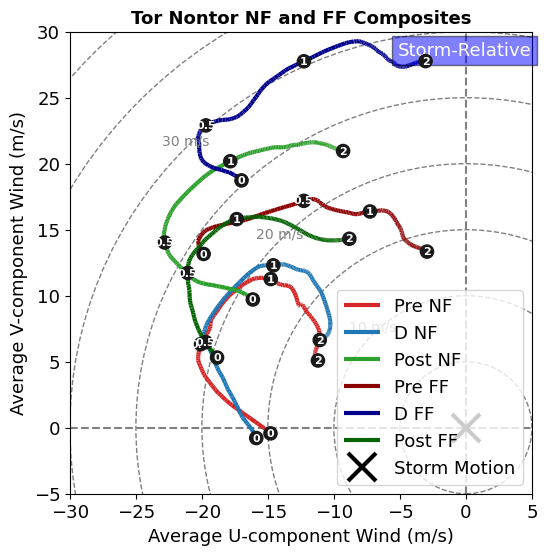

In [203]:
hodo_plot([preunf, dunf, postunf, preuff, duff, postuff], [prevnf, dvnf, postvnf, prevff, dvff, postvff], heights, 30, 
          'Tor Nontor NF and FF Composites', ['tab:red', 'tab:blue', 'tab:green', 'darkred', 'darkblue', 'darkgreen'],
          ['Pre NF', 'D NF', 'Post NF', 'Pre FF', 'D FF', 'Post FF'], 5, 30, 'lower right', 6,6)

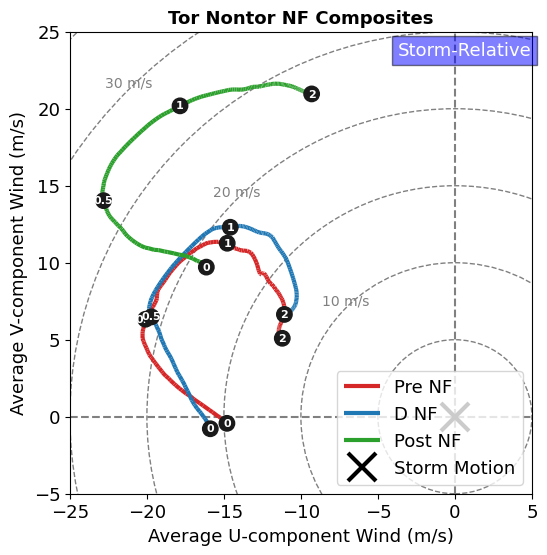

In [204]:
hodo_plot([preunf, dunf, postunf], [prevnf, dvnf, postvnf], heights, 25, 
          'Tor Nontor NF Composites', ['tab:red', 'tab:blue', 'tab:green'],
          ['Pre NF', 'D NF', 'Post NF'], 5, 25, 'lower right', 6,6)

In [ ]:
hodo_plot([preuff, duff, postuff], [prevff, dvff, postvff], heights, 30, 
          'Tor Nontor FF Composites', ['darkred', 'darkblue', 'darkgreen'],
          ['Pre FF', 'D FF', 'Post FF'], 5, 30, 'lower right', 6,6)

In [ ]:
hodo_plot([preunf, preuff], [prevnf, prevff], heights, 25, 
          'Tor NF Composites', ['tab:red', 'darkred'],
          ['Pre NF', 'Pre FF'], 5, 25, 'lower right', 6,6)

In [ ]:
hodo_plot([preu45, du45, postu45, preu90, du90, postu90], [prev45, dv45, postv45, prev90, dv90, postv90], heights, 40, 
          'Tor 0-45, 45-90 deg Composites', ['tab:red', 'tab:blue', 'tab:green', 'tab:orange', 'tab:purple', 'darkgreen'],
          ['Pre 0-45 deg', 'D 0-45 deg', 'Post 0-45 deg', 'Pre 45-90 deg', 'D 45-90 deg', 'Post 45-90 deg'], 5, 40, 'lower left', 8,8)

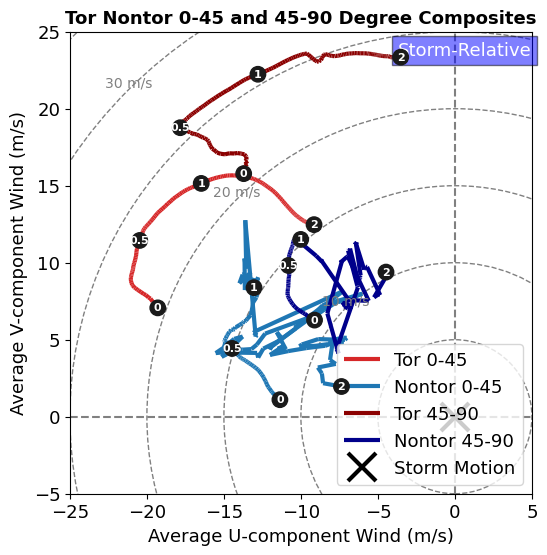

In [208]:
tor_u = uv_tor_all_avg_angle[uv_tor_all_avg_angle['u or v'] == 'u']
tor_v = uv_tor_all_avg_angle[uv_tor_all_avg_angle['u or v'] == 'v']

nontor_u = uv_nontor_all_avg_angle[uv_nontor_all_avg_angle['u or v'] == 'u']
nontor_v = uv_nontor_all_avg_angle[uv_nontor_all_avg_angle['u or v'] == 'v']
                     
hodo_plot([np.array(tor_u[tor_u['Angle'] == '0-45 deg'].iloc[:, 2:198]).flatten(), np.array(nontor_u[nontor_u['Angle'] == '0-45 deg'].iloc[:, 2:198]).flatten(), 
           np.array(tor_u[tor_u['Angle'] == '45-90 deg'].iloc[:, 2:198]).flatten(), np.array(nontor_u[nontor_u['Angle'] == '45-90 deg'].iloc[:, 2:198]).flatten()], 
          [np.array(tor_v[tor_v['Angle'] == '0-45 deg'].iloc[:, 2:198]).flatten(), np.array(nontor_v[nontor_v['Angle'] == '0-45 deg'].iloc[:, 2:198]).flatten(), 
           np.array(tor_v[tor_v['Angle'] == '45-90 deg'].iloc[:, 2:198]).flatten(), np.array(nontor_v[nontor_v['Angle'] == '45-90 deg'].iloc[:, 2:198]).flatten()], heights, 25, 
          'Tor Nontor 0-45 and 45-90 Degree Composites', ['tab:red', 'tab:blue', 'darkred', 'darkblue'],
          ['Tor 0-45', 'Nontor 0-45', 'Tor 45-90', 'Nontor 45-90'], 5, 25, 'lower right', 6,6)

In [218]:
tor_u

,u or v,Tor or Nontor,0,1,2,3,4,5,6,7,...,186,187,188,189,190,191,192,193,194,195
0,u,nontor,-10.894576,-11.030638,-11.154726,-11.264746,-11.303111,-11.516942,-11.629894,-11.828010,...,-5.956656,-5.990104,-6.319395,-6.206610,-6.217679,-5.501478,-5.927070,-6.031180,-5.376109,-5.129101
1,u,tor,-16.817841,-16.889763,-16.970405,-17.046216,-17.083343,-17.269948,-17.364335,-17.538616,...,-7.502586,-7.450438,-7.403864,-7.352391,-7.307546,-7.257311,-7.205513,-7.162679,-7.107051,-7.059286


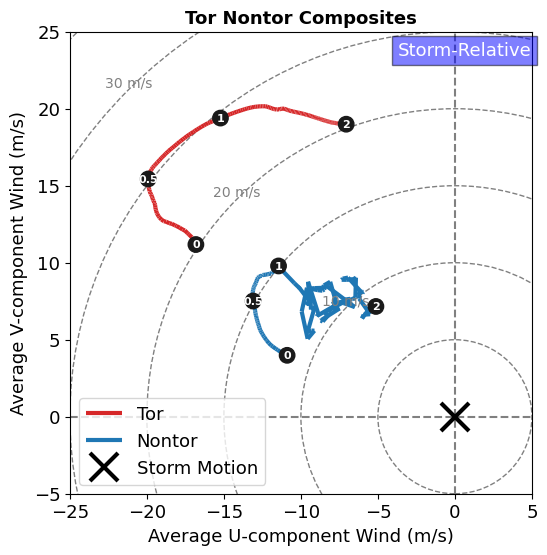

In [223]:
tor_u = tor_nontor_all[(tor_nontor_all['u or v'] == 'u') & (tor_nontor_all['Tor or Nontor'] == 'tor')]
tor_v = tor_nontor_all[(tor_nontor_all['u or v'] == 'v') & (tor_nontor_all['Tor or Nontor'] == 'tor')]

nontor_u = tor_nontor_all[(tor_nontor_all['u or v'] == 'u') & (tor_nontor_all['Tor or Nontor'] == 'nontor')]
nontor_v = tor_nontor_all[(tor_nontor_all['u or v'] == 'v') & (tor_nontor_all['Tor or Nontor'] == 'nontor')]
                     
hodo_plot([np.array(tor_u.iloc[:, 2:198]).flatten(), np.array(nontor_u.iloc[:, 2:198]).flatten()], 
           [np.array(tor_v.iloc[:, 2:198]).flatten(), np.array(nontor_v.iloc[:, 2:198]).flatten()], heights, 25, 
          'Tor Nontor Composites', ['tab:red', 'tab:blue'],
          ['Tor', 'Nontor'], 5, 25, 'lower left', 6,6)

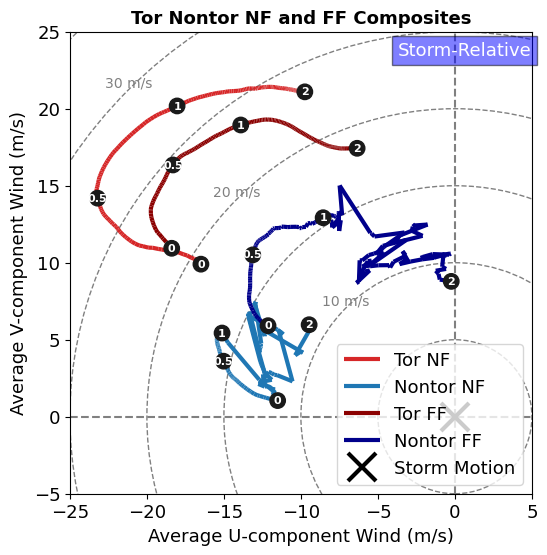

In [207]:
tor_u = uv_tor_all_avg_dist[uv_tor_all_avg_dist['u or v'] == 'u']
tor_v = uv_tor_all_avg_dist[uv_tor_all_avg_dist['u or v'] == 'v']

nontor_u = uv_nontor_all_avg_dist[uv_nontor_all_avg_dist['u or v'] == 'u']
nontor_v = uv_nontor_all_avg_dist[uv_nontor_all_avg_dist['u or v'] == 'v']
                     
hodo_plot([np.array(tor_u[tor_u['NF or FF'] == 'nf'].iloc[:, 2:198]).flatten(), np.array(nontor_u[nontor_u['NF or FF'] == 'nf'].iloc[:, 2:198]).flatten(), 
           np.array(tor_u[tor_u['NF or FF'] == 'ff'].iloc[:, 2:198]).flatten(), np.array(nontor_u[nontor_u['NF or FF'] == 'ff'].iloc[:, 2:198]).flatten()], 
          [np.array(tor_v[tor_v['NF or FF'] == 'nf'].iloc[:, 2:198]).flatten(), np.array(nontor_v[nontor_v['NF or FF'] == 'nf'].iloc[:, 2:198]).flatten(), 
           np.array(tor_v[tor_v['NF or FF'] == 'ff'].iloc[:, 2:198]).flatten(), np.array(nontor_v[nontor_v['NF or FF'] == 'ff'].iloc[:, 2:198]).flatten()], heights, 25, 
          'Tor Nontor NF and FF Composites', ['tab:red', 'tab:blue', 'darkred', 'darkblue'],
          ['Tor NF', 'Nontor NF', 'Tor FF', 'Nontor FF'], 5, 25, 'lower right', 6,6)

## uv_spec_comp old way (no pretor,dtor, posttor preavging)

In [ ]:
uv_spec_comp = pd.DataFrame()

for d in sorted(set(df_all_new['Date'])):
    test = comp_per_condition_avg_uv(df_all_new, d, nf_dist, minangle, midangle, maxangle)
    test['Date'] = d
    eep = df_all_new[df_all_new['Date'] == d]
    
    
    if eep['Tor or Nontor'].eq('tor').any():
        test['Tor or Nontor'] = 'tor'
    else:
        test['Tor or Nontor'] = 'nontor'
        
    uv_spec_comp = pd.concat([uv_spec_comp, test], ignore_index=True)

In [ ]:
uv_spec_comp['u or v'].value_counts()

In [ ]:
def uv_comp_sort_avg(uv_spec_comp, tor_or_nontor, col, col_value, u_or_v):
    sort = uv_spec_comp[(uv_spec_comp['Tor or Nontor'] == tor_or_nontor) & 
    (uv_spec_comp[col] == col_value) & (uv_spec_comp['u or v'] == u_or_v)]

    sort_avg = np.nanmean(sort.iloc[:, :196], axis=0)

    return sort, sort_avg

In [ ]:
tor_nf_u, tor_nf_u_avg = uv_comp_sort_avg(uv_spec_comp, 'tor', 'NF or FF', 'nf', 'u')
tor_nf_v, tor_nf_v_avg = uv_comp_sort_avg(uv_spec_comp, 'tor', 'NF or FF', 'nf', 'v')

tor_ff_u, tor_ff_u_avg = uv_comp_sort_avg(uv_spec_comp, 'tor', 'NF or FF', 'ff', 'u')
tor_ff_v, tor_ff_v_avg = uv_comp_sort_avg(uv_spec_comp, 'tor', 'NF or FF', 'ff', 'v')

tor_045_u, tor_045_u_avg = uv_comp_sort_avg(uv_spec_comp, 'tor', 'Angle', '0-45 deg', 'u')
tor_045_v, tor_045_v_avg = uv_comp_sort_avg(uv_spec_comp, 'tor', 'Angle', '0-45 deg', 'v')

tor_4590_u, tor_4590_u_avg = uv_comp_sort_avg(uv_spec_comp, 'tor', 'Angle', '45-90 deg', 'u')
tor_4590_v, tor_4590_v_avg = uv_comp_sort_avg(uv_spec_comp, 'tor', 'Angle', '45-90 deg', 'v')

nontor_nf_u, nontor_nf_u_avg = uv_comp_sort_avg(uv_spec_comp, 'nontor', 'NF or FF', 'nf', 'u')
nontor_nf_v, nontor_nf_v_avg = uv_comp_sort_avg(uv_spec_comp, 'nontor', 'NF or FF', 'nf', 'v')

nontor_ff_u, nontor_ff_u_avg = uv_comp_sort_avg(uv_spec_comp, 'nontor', 'NF or FF', 'ff', 'u')
nontor_ff_v, nontor_ff_v_avg = uv_comp_sort_avg(uv_spec_comp, 'nontor', 'NF or FF', 'ff', 'v')

nontor_045_u, nontor_045_u_avg = uv_comp_sort_avg(uv_spec_comp, 'nontor', 'Angle', '0-45 deg', 'u')
nontor_045_v, nontor_045_v_avg = uv_comp_sort_avg(uv_spec_comp, 'nontor', 'Angle', '0-45 deg', 'v')

nontor_4590_u, nontor_4590_u_avg = uv_comp_sort_avg(uv_spec_comp, 'nontor', 'Angle', '45-90 deg', 'u')
nontor_4590_v, nontor_4590_v_avg = uv_comp_sort_avg(uv_spec_comp, 'nontor', 'Angle', '45-90 deg', 'v')

In [ ]:
tor_4590_u

In [ ]:
hodo_plot([tor_nf_u_avg, nontor_nf_u_avg, tor_ff_u_avg, nontor_ff_u_avg], 
          [tor_nf_v_avg, nontor_nf_v_avg, tor_ff_v_avg, nontor_ff_v_avg], heights, 25, 
          'Tor Nontor NF and FF Composites', ['tab:red', 'tab:blue', 'darkred', 'darkblue'],
          ['Tor NF', 'Nontor NF', 'Tor FF', 'Nontor FF'], 5, 25, 'lower right', 6,6)

In [ ]:
hodo_plot([tor_045_u_avg, nontor_045_u_avg, tor_4590_u_avg, nontor_4590_u_avg], 
          [tor_045_v_avg, nontor_045_v_avg, tor_4590_v_avg, nontor_4590_v_avg], heights, 25, 
          'Tor Nontor 0-45 and 45-90 Deg Composites', ['tab:red', 'tab:blue', 'darkred', 'darkblue'],
          ['Tor 0-45 deg', 'Nontor 0-45 deg', 'Tor 45-90 deg', 'Nontor 45-90 deg'], 5, 25, 'lower right', 6,6)

## oldest way, but has best hodos

In [ ]:
#old_2ndtrip = averaging_u_and_v(comp_tor_all, comp_nontor_all)
new_2ndtrip = averaging_u_and_v(comp_tor_all_new, comp_nontor_all_new)
new_2ndtrip

In [ ]:
new_2ndtrip045 = averaging_u_and_v_nodist(comp_tor_all_nodist_new045, comp_nontor_all_nodist_new045)
new_2ndtrip4590 = averaging_u_and_v_nodist(comp_tor_all_nodist_new4590, comp_nontor_all_nodist_new4590)

In [ ]:
new_2ndtrip4590 

In [ ]:
new_2ndtrip045

In [ ]:
hodo_plot([old_2ndtrip['tor_u_nf'], old_2ndtrip['pretor_u_nf'], old_2ndtrip['dtor_u_nf'], old_2ndtrip['posttor_u_nf'], 
           old_2ndtrip['nontor_u_nf']], 
           [old_2ndtrip['tor_v_nf'], old_2ndtrip['pretor_v_nf'], old_2ndtrip['dtor_v_nf'], old_2ndtrip['posttor_v_nf'], old_2ndtrip['nontor_v_nf']], heights, 25, 
    'Near-Field Composites', ['black', 'tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['All Tornadic', 'Pre Tornadic', 'Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 25, 'lower right', 6, 6)

In [ ]:
hodo_plot([old_2ndtrip['tor_u_nf'], old_2ndtrip['nontor_u_nf']], [old_2ndtrip['tor_v_nf'], old_2ndtrip['nontor_v_nf']], heights, 25, 
    'Near-Field Composites', ['tab:red', 'tab:blue'], 
    ['All Tornadic', 'All Nontornadic'], 5, 25, 'lower right', 6,6)

In [ ]:
hodo_plot([old_2ndtrip['pretor_u_ff'], old_2ndtrip['dtor_u_ff'], old_2ndtrip['posttor_u_ff'], old_2ndtrip['nontor_u_ff']], 
           [old_2ndtrip['pretor_v_ff'], old_2ndtrip['dtor_v_ff'], old_2ndtrip['posttor_v_ff'], old_2ndtrip['nontor_v_ff']], heights, 25, 
    'Far-Field Composites', ['tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['Pre Tornadic', 'Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 30, 'lower right', 6,6)

In [ ]:
hodo_plot([old_2ndtrip['tor_u_ff'], old_2ndtrip['nontor_u_ff']], [old_2ndtrip['tor_v_ff'], old_2ndtrip['nontor_v_ff']], heights, 25, 
    'Far-Field Composites', ['tab:red', 'tab:blue'], 
    ['All Tornadic', 'Nontornadic'], 5, 25, 'lower left', 6,6)

In [ ]:
hodo_plot([new_2ndtrip['tor_u_nf'], new_2ndtrip['pretor_u_nf'], new_2ndtrip['dtor_u_nf'], new_2ndtrip['posttor_u_nf'], new_2ndtrip['nontor_u_nf']], 
           [new_2ndtrip['tor_v_nf'], new_2ndtrip['pretor_v_nf'], new_2ndtrip['dtor_v_nf'], new_2ndtrip['posttor_v_nf'], new_2ndtrip['nontor_v_nf']], heights, 25, 
    'Near-Field Composites (New 2ndTrip)', ['black', 'tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['All Tornadic', 'Pre Tornadic', 'Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 25, 'lower right', 6,6)

In [ ]:
hodo_plot([new_2ndtrip['tor_u_ff'], new_2ndtrip['pretor_u_ff'], new_2ndtrip['dtor_u_ff'], new_2ndtrip['posttor_u_ff'], new_2ndtrip['nontor_u_ff']], 
           [new_2ndtrip['tor_v_ff'], new_2ndtrip['pretor_v_ff'],new_2ndtrip['dtor_v_ff'], new_2ndtrip['posttor_v_ff'], new_2ndtrip['nontor_v_ff']], heights, 25, 
    'Far-Field Composites (New 2ndTrip)', ['black', 'tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['All Tornadic','Pre Tornadic', 'Tor', 'Post Tornadic', 'Nontornadic'], 5, 30, 'lower right',6,6)

In [ ]:
hodo_plot([new_2ndtrip['tor_u_nf'], new_2ndtrip['nontor_u_nf'], new_2ndtrip['tor_u_ff'], new_2ndtrip['nontor_u_ff']], 
          [new_2ndtrip['tor_v_nf'], new_2ndtrip['nontor_v_nf'], new_2ndtrip['tor_v_ff'], new_2ndtrip['nontor_v_ff']], heights, 25, 
    'Tor VS Nontor Composites NEW', ['tab:red', 'tab:blue', 'darkred', 'darkblue'], 
    ['All Tornadic NF', 'Nontornadic NF', 'All Tornadic FF', 'Nontornadic FF'], 5, 25, 'lower right', 6,6)

In [ ]:
hodo_plot([new_2ndtrip['tor_u_nf'], new_2ndtrip['nontor_u_nf']], 
          [new_2ndtrip['tor_v_nf'], new_2ndtrip['nontor_v_nf']], heights, 25, 
    'Tor VS Nontor NF Composites NEW', ['tab:red', 'tab:blue'], 
    ['All Tornadic NF', 'Nontornadic NF'], 5, 25, 'lower right', 6,6)

In [ ]:
hodo_plot([new_2ndtrip['tor_u_ff'], new_2ndtrip['nontor_u_ff']], 
          [new_2ndtrip['tor_v_ff'], new_2ndtrip['nontor_v_ff']], heights, 25, 
    'Tor VS Nontor FF Composites NEW', ['tab:red', 'tab:blue'], 
    ['All Tornadic FF', 'Nontornadic FF'], 5, 25, 'lower right', 6,6)

In [ ]:
hodo_plot([new_2ndtrip045['tor_u'], new_2ndtrip045['nontor_u']], 
          [new_2ndtrip045['tor_v'], new_2ndtrip045['nontor_v']], heights, 25, 
    'Tor VS Nontor 0-45 Degrees Composites NEW', ['tab:red', 'tab:blue'], 
    ['Tornadic', 'Nontornadic'], 5, 25, 'lower right', 6,6)

In [ ]:
hodo_plot([new_2ndtrip4590['tor_u'], new_2ndtrip4590['nontor_u']], 
          [new_2ndtrip4590['tor_v'], new_2ndtrip4590['nontor_v']], heights, 25, 
    'Tor VS Nontor 45-90 Degrees Composites NEW', ['tab:red', 'tab:blue'], 
    ['Tornadic', 'Nontornadic'], 5, 25, 'lower right', 6,6)

In [ ]:
784/196

In [ ]:
tor_winds_new

In [ ]:
tor_nf_u = tor_winds_new['NF_u_mean_0-2km']
tor_nf_v = tor_winds_new['NF_v_mean_0-2km']
tor_ff_u = tor_winds_new['FF_u_mean_0-2km']
tor_ff_v = tor_winds_new['FF_v_mean_0-2km']

avg_tor_nf_u = np.nansum([tor_nf_u.iloc[:196], tor_nf_u.iloc[196:392], tor_nf_u.iloc[392:588], tor_nf_u.iloc[588:]], axis=0) / 4
avg_tor_nf_v = np.nansum([tor_nf_v.iloc[:196], tor_nf_v.iloc[196:392], tor_nf_v.iloc[392:588], tor_nf_v.iloc[588:]], axis=0) / 4

avg_tor_ff_u = np.nansum([tor_ff_u.iloc[:196], tor_ff_u.iloc[196:392], tor_ff_u.iloc[392:588], tor_ff_u.iloc[588:]], axis=0) / 4
avg_tor_ff_v = np.nansum([tor_ff_v.iloc[:196], tor_ff_v.iloc[196:392], tor_ff_v.iloc[392:588], tor_ff_v.iloc[588:]], axis=0) / 4

In [ ]:
nontor_nf_u = nontor_winds_new['NF_u_mean_0-2km']
nontor_nf_v = nontor_winds_new['NF_v_mean_0-2km']
nontor_ff_u = nontor_winds_new['FF_u_mean_0-2km']
nontor_ff_v = nontor_winds_new['FF_v_mean_0-2km']

avg_nontor_nf_u = np.nansum([nontor_nf_u.iloc[:196], nontor_nf_u.iloc[196:392]], axis=0)/ 2
avg_nontor_nf_v = np.nansum([nontor_nf_v.iloc[:196],nontor_nf_v.iloc[196:392]], axis=0) / 2

avg_nontor_ff_u = np.nansum([nontor_ff_u.iloc[:196],nontor_ff_u.iloc[196:392]], axis=0) / 2
avg_nontor_ff_v = np.nansum([nontor_ff_v.iloc[:196],nontor_ff_v.iloc[196:392]], axis=0) / 2

In [ ]:
np.shape(avg_tor_nf_u)

In [ ]:
hodo_plot([avg_tor_nf_u, avg_nontor_nf_u, avg_tor_ff_u, avg_nontor_ff_u], 
          [avg_tor_nf_v, avg_nontor_nf_v, avg_tor_ff_v, avg_nontor_ff_v], heights, 25, 
    'Tor VS Nontor Composites NEW (Only For Cases with Both NF and FF)', ['tab:red', 'tab:blue', 'darkred', 'darkblue'], 
    ['All Tornadic NF', 'Nontornadic NF', 'All Tornadic FF', 'Nontornadic FF'], 5, 25, 'lower right', 5,5)

# Tor Time rate of change

In [ ]:
df_all_new

In [ ]:
import numpy as np
df = df_all_new.copy()

df['Time From Tor (min)'] = pd.to_numeric(df['Time From Tor (min)'], errors='coerce')

pt = df[df['Time From Tor (min)'] < 0]
# Compute time differences (in minutes) and SRH differences
dt = np.sum(pt['Time From Tor (min)'].values)  # time intervals (should be negative)
dSRH = np.diff(pt['0-2km SRH'].values)

# Calculate rate of change (ΔSRH / Δtime)
rate_of_change = dSRH / dt  # This will have length len(df) - 1

# Add it to the DataFrame (aligned with the midpoints of intervals)
df_midpoints = pt.iloc[1:].copy()
df_midpoints['SRH_rate_of_change'] = rate_of_change


In [ ]:
for d in sorted(set(df_midpoints['Date'])):
    df = df_midpoints[df_midpoints['Date'] == d]
    plt.scatter(df['Time From Tor (min)'], df['SRH_rate_of_change'])
    plt.title(f'{d} 0-2km SRH Rate of Change Time from tor')
    plt.show()

# KDE Distributions

In [ ]:
def mean_and_CI(data, confidence_level):
    
    x = np.nanmean(data, axis=0)
    degrees_freedom = len(data) - 1
    x_strd_error = stats.sem(data, nan_policy='omit')
    x_95conf = stats.t.interval(confidence_level, degrees_freedom, loc=x, scale=x_strd_error)
    return x, x_95conf

In [ ]:
def kde_plot(df, col, hue, figsize, label, title, color_tor, color_nontor, tor_mean, nontor_mean, tor_CI, nontor_CI, ci):
    
    fig = plt.figure(figsize=figsize)
    p = sns.kdeplot(df, x=col, hue=hue, common_norm=False, label = label)
                    
    plt.title(title)
    
    plt.axvspan(tor_CI[0], tor_CI[1], color=color_tor, alpha=0.2, label=f'Tor {ci}% CI')
    plt.axvspan(nontor_CI[0], nontor_CI[1], color=color_nontor, alpha=0.2, label=f'Nontor {ci}% CI')
    plt.axvline(tor_mean, color=color_tor, label=f'Mean Tor:{tor_mean:.2f}')
    plt.axvline(nontor_mean, color=color_nontor, label=f'Mean Nontor:{nontor_mean:.2f}')
    plt.grid()
    plt.tight_layout()
    plt.legend()
    plt.show()

In [ ]:
def kde_plot_plus(df, col, hue, figsize, title, colors, means, CIs, labels, c_i):
    
    fig, ax = plt.subplots(figsize=figsize)
    p = sns.kdeplot(df, x=col, hue=hue, common_norm=False, ax=ax)

    for c, m, ci, l in zip(colors, means, CIs, labels):
        torpltCI = ax.axvspan(ci[0], ci[1], color=c, alpha=0.2, label=f'{l} {c_i}% CI')
        #nontorpltCI = ax.axvspan(nontor_CI[0], nontor_CI[1], color=color_nontor, alpha=0.2, label='Nontor 95% CI')
        torline = ax.axvline(m, color=c, label=f'{l}: {m:.2f}')
        #nontorline = ax.axvline(nontor_mean, color=color_nontor, label='Mean Nontor')
        #handles, labels = ax.get_legend_handles_labels()
        #ax.legend(handles=handles, labels=labels)
    ax.grid(True)
    ax.set_title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

## df_all_new

In [ ]:
dftor = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
dfnontor = df_all_new[df_all_new['Time From Tor (min)'] == 'nontor']

In [ ]:
dftor

In [ ]:
#plt.figure(figsize = (12, 4))
df = df_all_new
p = so.Plot(df, x='0-2km SRH', color='Tor or Nontor').add(sns.objects.Area(), 
                                                          sns.objects.KDE(common_norm=False)).label(title = 'KDE Tor Nontor 0-2km SRH NEW').layout(size=(5,3))
p.show()

In [ ]:
tor_02_v_mean, tor_02_v_CI = mean_and_CI(dftor[dftor['u or v'] == 'v']['195'], 0.95)
nontor_02_v_mean, nontor_02_v_CI = mean_and_CI(dfnontor[dfnontor['u or v'] == 'v']['195'], 0.95)

In [ ]:
tor_02_v_mean

In [ ]:
def kde_plot(df, col, hue, figsize, title, color_tor, color_nontor, tor_mean, nontor_mean, tor_CI, nontor_CI):
    
    fig, ax = plt.subplots(figsize=figsize)
    p = sns.kdeplot(df, x=col, hue=hue, common_norm=False, ax=ax)
    
    torpltCI = ax.axvspan(tor_CI[0], tor_CI[1], color=color_tor, alpha=0.2, label='Tor 95% CI')
    nontorpltCI = ax.axvspan(nontor_CI[0], nontor_CI[1], color=color_nontor, alpha=0.2, label='Nontor 95% CI')
    torline = ax.axvline(tor_mean, color=color_tor, label='Mean Tor')
    nontorline = ax.axvline(nontor_mean, color=color_nontor, label='Mean Nontor')
    handles, labels = ax.get_legend_handles_labels()
    #ax.legend(handles=handles, labels=labels)
    ax.grid(True)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

## u and v

### uv_avg_comp (skews results because it has pretor, dtor, and posttor entries all as their own 'tor' labelled section, inflating the tor sample numbers)
good for plotting pretor, dtor, etc relationships though

In [ ]:
uv_avg_comp

In [ ]:
avg_pretor_02_v, pretorvCI = mean_and_CI(uv_avg_comp[(uv_avg_comp['Tor Time'] == 'pretor') & (uv_avg_comp['u or v']=='v') & ((uv_avg_comp['NF or FF'] == 'nf') | (uv_avg_comp['NF or FF'] == 'ff'))][195], 0.95)
avg_dtor_02_v, dtorvCI = mean_and_CI(uv_avg_comp[(uv_avg_comp['Tor Time'] == 'dtor') & (uv_avg_comp['u or v']=='v') & ((uv_avg_comp['NF or FF'] == 'nf') | (uv_avg_comp['NF or FF'] == 'ff'))][195], 0.95)
avg_posttor_02_v, posttorvCI = mean_and_CI(uv_avg_comp[(uv_avg_comp['Tor Time'] == 'posttor') & (uv_avg_comp['u or v']=='v') & ((uv_avg_comp['NF or FF'] == 'nf') | (uv_avg_comp['NF or FF'] == 'ff'))][195], 0.95)
avg_nontor_02_v, nontorvCI = mean_and_CI(uv_avg_comp[(uv_avg_comp['Tor Time'] == 'nontor') & (uv_avg_comp['u or v']=='v') & ((uv_avg_comp['NF or FF'] == 'nf') | (uv_avg_comp['NF or FF'] == 'ff'))][195], 0.95)
print(f'pretor:{avg_pretor_02_v}')
print(f'dtor:{avg_dtor_02_v}')
print(f'posttor:{avg_posttor_02_v}')
print(f'nontor:{avg_nontor_02_v}')

kde_plot_plus(uv_avg_comp, 195, 'Tor Time', (7,3), 'Tor Times 0-2km SRW v Component Averaged Per IOP', ['tab:blue', 'orange', 'green', 'tab:red'], 
         [avg_pretor_02_v, avg_dtor_02_v, avg_posttor_02_v, avg_nontor_02_v], [pretorvCI, dtorvCI, posttorvCI, nontorvCI])

In [ ]:
avg_pretor_02_v, pretorvCI = mean_and_CI(uv_avg_comp[(uv_avg_comp['Tor Time'] == 'pretor') & (uv_avg_comp['u or v']=='v') & ((uv_avg_comp['NF or FF'] == 'nf') | (uv_avg_comp['NF or FF'] == 'ff'))][0], 0.95)
avg_dtor_02_v, dtorvCI = mean_and_CI(uv_avg_comp[(uv_avg_comp['Tor Time'] == 'dtor') & (uv_avg_comp['u or v']=='v') & ((uv_avg_comp['NF or FF'] == 'nf') | (uv_avg_comp['NF or FF'] == 'ff'))][0], 0.95)
avg_posttor_02_v, posttorvCI = mean_and_CI(uv_avg_comp[(uv_avg_comp['Tor Time'] == 'posttor') & (uv_avg_comp['u or v']=='v') & ((uv_avg_comp['NF or FF'] == 'nf') | (uv_avg_comp['NF or FF'] == 'ff'))][0], 0.95)
avg_nontor_02_v, nontorvCI = mean_and_CI(uv_avg_comp[(uv_avg_comp['Tor Time'] == 'nontor') & (uv_avg_comp['u or v']=='v') & ((uv_avg_comp['NF or FF'] == 'nf') | (uv_avg_comp['NF or FF'] == 'ff'))][0], 0.95)
print(f'pretor:{avg_pretor_02_v}')
print(f'dtor:{avg_dtor_02_v}')
print(f'posttor:{avg_posttor_02_v}')
print(f'nontor:{avg_nontor_02_v}')

kde_plot_plus(uv_avg_comp, 0, 'Tor Time', (7,3), 'Tor Times SFC SRW v Component Averaged Per IOP', ['tab:blue', 'orange', 'green', 'tab:red'], 
         [avg_pretor_02_v, avg_dtor_02_v, avg_posttor_02_v, avg_nontor_02_v], [pretorvCI, dtorvCI, posttorvCI, nontorvCI])

In [ ]:
avg_tor_02_v, torvCI = mean_and_CI(uv_avg_comp[(uv_avg_comp['Tor or Nontor'] == 'tor') & (uv_avg_comp['u or v']=='v') & ((uv_avg_comp['NF or FF'] == 'nf') | (uv_avg_comp['NF or FF'] == 'ff'))][195], 0.95)
avg_nontor_02_v, nontorvCI = mean_and_CI(uv_avg_comp[(uv_avg_comp['Tor or Nontor'] == 'nontor') & (uv_avg_comp['u or v']=='v') & ((uv_avg_comp['NF or FF'] == 'nf') | (uv_avg_comp['NF or FF'] == 'ff'))][195], 0.95)
print(avg_tor_02_v)
print(avg_nontor_02_v)

kde_plot(uv_avg_comp, 195, 'Tor or Nontor', (7,3), 'Tor vs Nontor 0-2km SRW v Component Averaged Per IOP', 'red', 'blue', 
         avg_tor_02_v, avg_nontor_02_v, torvCI, nontorvCI)

In [ ]:
avg_tor_02_v, torvCI = mean_and_CI(uv_avg_comp[(uv_avg_comp['Tor or Nontor'] == 'tor') & (uv_avg_comp['u or v']=='u') & ((uv_avg_comp['NF or FF'] == 'nf') | (uv_avg_comp['NF or FF'] == 'ff'))][195], 0.95)
avg_nontor_02_v, nontorvCI = mean_and_CI(uv_avg_comp[(uv_avg_comp['Tor or Nontor'] == 'nontor') & (uv_avg_comp['u or v']=='u') & ((uv_avg_comp['NF or FF'] == 'nf') | (uv_avg_comp['NF or FF'] == 'ff'))][195], 0.95)
print(avg_tor_02_v)
print(avg_nontor_02_v)

kde_plot(uv_avg_comp, 195, 'Tor or Nontor', (7,3), 'Tor vs Nontor 0-2km SRW u Component Averaged Per IOP', 'red', 'blue', 
         avg_tor_02_v, avg_nontor_02_v, torvCI, nontorvCI)

In [ ]:
avg_tor_02_v, torvCI = mean_and_CI(uv_avg_comp[(uv_avg_comp['Tor or Nontor'] == 'tor') & (uv_avg_comp['u or v']=='v') & ((uv_avg_comp['NF or FF'] == 'nf') | (uv_avg_comp['NF or FF'] == 'ff'))][0], 0.95)
avg_nontor_02_v, nontorvCI = mean_and_CI(uv_avg_comp[(uv_avg_comp['Tor or Nontor'] == 'nontor') & (uv_avg_comp['u or v']=='v') & ((uv_avg_comp['NF or FF'] == 'nf') | (uv_avg_comp['NF or FF'] == 'ff'))][0], 0.95)
print(avg_tor_02_v)
print(avg_nontor_02_v)

kde_plot(uv_avg_comp, 195, 'Tor or Nontor', (7,3), 'Tor vs Nontor SFC SRW v Component Averaged Per IOP', 'red', 'blue', 
         avg_tor_02_v, avg_nontor_02_v, torvCI, nontorvCI)

### uv_avg_comp_dates (u and v components) (fixes skewness because it averages pretor etc per IOP before being composited)

In [ ]:
uv_avg_comp_dates

In [ ]:
tor_vs_nontor_perc_dif = pd.DataFrame()

In [ ]:
df = uv_avg_comp_dates
avg_tor_02_v, torvCI = mean_and_CI(df[(df['Tor or Nontor'] == 'tor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][195], 0.95)
avg_nontor_02_v, nontorvCI = mean_and_CI(df[(df['Tor or Nontor'] == 'nontor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][195], 0.95)
print(avg_tor_02_v)
print(avg_nontor_02_v)

kde_plot(df[(df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))], 195, 'Tor or Nontor', (7,3), '', 'Tor vs Nontor 0-2km SRW v Component Averaged Per IOP', 'red', 'blue', 
         avg_tor_02_v, avg_nontor_02_v, torvCI, nontorvCI, 95)

perc_diff = 100* (avg_tor_02_v - avg_nontor_02_v)/(avg_tor_02_v + avg_nontor_02_v)
print(f'{srw_or_srh} {h} % diff: {perc_diff}')

stat, p_value = mannwhitneyu(df[(df['Tor or Nontor'] == 'tor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][195].dropna(), 
                             df[(df['Tor or Nontor'] == 'nontor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][195].dropna(), use_continuity=False, 
                             alternative='greater')

stat, p = ttest_ind(df[(df['Tor or Nontor'] == 'tor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][195].dropna(), 
                             df[(df['Tor or Nontor'] == 'nontor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][195].dropna(), equal_var=False, 
                             alternative='greater')

eep = pd.DataFrame()
eep['u or v'] = ['v']
eep['Height'] = ['0-2km']
eep['% Diff'] = [perc_diff]

tor_vs_nontor_perc_dif = pd.concat([eep, tor_vs_nontor_perc_dif], ignore_index=True)
print(p_value)
print(f't-test: {p}')

In [ ]:
df = uv_avg_comp_dates
avg_tor_02_v, torvCI = mean_and_CI(df[(df['Tor or Nontor'] == 'tor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][100], 0.95)
avg_nontor_02_v, nontorvCI = mean_and_CI(df[(df['Tor or Nontor'] == 'nontor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][100], 0.95)
print(avg_tor_02_v)
print(avg_nontor_02_v)

kde_plot(df[(df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))], 100, 'Tor or Nontor', (7,3), '', 'Tor vs Nontor 0-1km SRW v Component Averaged Per IOP', 'red', 'blue', 
         avg_tor_02_v, avg_nontor_02_v, torvCI, nontorvCI, 95)

perc_diff = 100* (avg_tor_02_v - avg_nontor_02_v)/(avg_tor_02_v + avg_nontor_02_v)
print(f'{srw_or_srh} {h} % diff: {perc_diff}')

stat, p_value = mannwhitneyu(df[(df['Tor or Nontor'] == 'tor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][100].dropna(), 
                             df[(df['Tor or Nontor'] == 'nontor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][100].dropna(), use_continuity=False, 
                             alternative='greater') 

stat, p = ttest_ind(df[(df['Tor or Nontor'] == 'tor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][100].dropna(), 
                             df[(df['Tor or Nontor'] == 'nontor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][100].dropna(), equal_var=False, 
                             alternative='greater') 
print(f't-test: {p}')

eep = pd.DataFrame()
eep['u or v'] = ['v']
eep['Height'] = ['0-1km']
eep['% Diff'] = [perc_diff]

tor_vs_nontor_perc_dif = pd.concat([eep, tor_vs_nontor_perc_dif], ignore_index=True)
print(p_value)

In [ ]:
df = uv_avg_comp_dates
avg_tor_02_v, torvCI = mean_and_CI(df[(df['Tor or Nontor'] == 'tor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][0], 0.95)
avg_nontor_02_v, nontorvCI = mean_and_CI(df[(df['Tor or Nontor'] == 'nontor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][0], 0.95)
print(avg_tor_02_v)
print(avg_nontor_02_v)

kde_plot(df[(df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))], 0, 'Tor or Nontor', (7,3), '', 'Tor vs Nontor SFC SRW v Component Averaged Per IOP', 'red', 'blue', 
         avg_tor_02_v, avg_nontor_02_v, torvCI, nontorvCI, 95)

perc_diff = 100* (avg_tor_02_v - avg_nontor_02_v)/(avg_tor_02_v + avg_nontor_02_v)
print(f'{srw_or_srh} {h} % diff: {perc_diff}')

stat, p_value = mannwhitneyu(df[(df['Tor or Nontor'] == 'tor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][0].dropna(), 
                             df[(df['Tor or Nontor'] == 'nontor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][0].dropna(), use_continuity=False,
                            alternative='greater') 

stat, p = ttest_ind(df[(df['Tor or Nontor'] == 'tor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][0].dropna(), 
                             df[(df['Tor or Nontor'] == 'nontor') & (df['u or v']=='v') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][0].dropna(), equal_var=False,
                            alternative='greater') 
print(p_value)
print(f't-test: {p}')


eep = pd.DataFrame()
eep['u or v'] = ['v']
eep['Height'] = ['SFC']
eep['% Diff'] = [perc_diff]

tor_vs_nontor_perc_dif = pd.concat([eep, tor_vs_nontor_perc_dif], ignore_index=True)

In [ ]:
df = uv_avg_comp_dates
avg_tor_02_v, torvCI = mean_and_CI(df[(df['Tor or Nontor'] == 'tor') & (df['u or v']=='u') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][0], 0.95)
avg_nontor_02_v, nontorvCI = mean_and_CI(df[(df['Tor or Nontor'] == 'nontor') & (df['u or v']=='u') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][0], 0.95)
print(avg_tor_02_v)
print(avg_nontor_02_v)

kde_plot(df[(df['u or v']=='u') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))], 0, 'Tor or Nontor', (7,3), '', 'Tor vs Nontor SFC SRW u Component Averaged Per IOP', 'red', 'blue', 
         avg_tor_02_v, avg_nontor_02_v, torvCI, nontorvCI, 95)

perc_diff = 100* (avg_tor_02_v - avg_nontor_02_v)/(avg_tor_02_v + avg_nontor_02_v)
print(f'{srw_or_srh} {h} % diff: {perc_diff}')

stat, p_value = mannwhitneyu(df[(df['Tor or Nontor'] == 'tor') & (df['u or v']=='u') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][0].dropna(), 
                             df[(df['Tor or Nontor'] == 'nontor') & (df['u or v']=='u') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][0].dropna(), use_continuity=False,
                            alternative='greater') 

print(p_value)

eep = pd.DataFrame()
eep['u or v'] = ['u']
eep['Height'] = ['SFC']
eep['% Diff'] = [perc_diff]

tor_vs_nontor_perc_dif = pd.concat([eep, tor_vs_nontor_perc_dif], ignore_index=True)

In [ ]:
df = uv_avg_comp_dates
avg_tor_02_v, torvCI = mean_and_CI(df[(df['Tor or Nontor'] == 'tor') & (df['u or v']=='u') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][100], 0.95)
avg_nontor_02_v, nontorvCI = mean_and_CI(df[(df['Tor or Nontor'] == 'nontor') & (df['u or v']=='u') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][100], 0.95)
print(avg_tor_02_v)
print(avg_nontor_02_v)

kde_plot(df[(df['u or v']=='u') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))], 100, 'Tor or Nontor', (7,3), '', 'Tor vs Nontor 0-1km SRW u Component Averaged Per IOP', 'red', 'blue', 
         avg_tor_02_v, avg_nontor_02_v, torvCI, nontorvCI, 95)

perc_diff = 100* (avg_tor_02_v - avg_nontor_02_v)/(avg_tor_02_v + avg_nontor_02_v)
print(f'{srw_or_srh} {h} % diff: {perc_diff}')

stat, p_value = mannwhitneyu(df[(df['Tor or Nontor'] == 'tor') & (df['u or v']=='u') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][100].dropna(), 
                             df[(df['Tor or Nontor'] == 'nontor') & (df['u or v']=='u') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][100].dropna(), use_continuity=False,
                            alternative='greater') 

print(p_value)

eep = pd.DataFrame()
eep['u or v'] = ['u']
eep['Height'] = ['0-1km']
eep['% Diff'] = [perc_diff]

tor_vs_nontor_perc_dif = pd.concat([eep, tor_vs_nontor_perc_dif], ignore_index=True)

In [ ]:
df = uv_avg_comp_dates
avg_tor_02_v, torvCI = mean_and_CI(df[(df['Tor or Nontor'] == 'tor') & (df['u or v']=='u') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][195], 0.95)
avg_nontor_02_v, nontorvCI = mean_and_CI(df[(df['Tor or Nontor'] == 'nontor') & (df['u or v']=='u') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][195], 0.95)
print(avg_tor_02_v)
print(avg_nontor_02_v)

kde_plot(df[(df['u or v']=='u') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))], 195, 'Tor or Nontor', (7,3), '', 'Tor vs Nontor 0-2km SRW u Component Averaged Per IOP', 'red', 'blue', 
         avg_tor_02_v, avg_nontor_02_v, torvCI, nontorvCI, 95)

perc_diff = 100* (avg_tor_02_v - avg_nontor_02_v)/(avg_tor_02_v + avg_nontor_02_v)
print(f'{srw_or_srh} {h} % diff: {perc_diff}')

stat, p_value = mannwhitneyu(df[(df['Tor or Nontor'] == 'tor') & (df['u or v']=='u') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][195].dropna(), 
                             df[(df['Tor or Nontor'] == 'nontor') & (df['u or v']=='u') & ((df['NF or FF'] == 'nf') | (df['NF or FF'] == 'ff'))][195].dropna(), use_continuity=False,
                            alternative='greater') 

print(p_value)

eep = pd.DataFrame()
eep['u or v'] = ['u']
eep['Height'] = ['0-2km']
eep['% Diff'] = [perc_diff]

tor_vs_nontor_perc_dif = pd.concat([eep, tor_vs_nontor_perc_dif], ignore_index=True)

In [ ]:
tor_vs_nontor_perc_dif

In [ ]:
srw_all = []
srw_sfc = []

for d in set(uv_avg_comp_dates['Date']):

    
    df_u = uv_avg_comp_dates[(uv_avg_comp_dates['Date'] == d) & (uv_avg_comp_dates['u or v'] == 'u')]
    df_v = uv_avg_comp_dates[(uv_avg_comp_dates['Date'] == d) & (uv_avg_comp_dates['u or v'] == 'v')]

    bulkshear0500 = bulk_shear(df_u.iloc[:,3], df_v.iloc[:,3], df_u.iloc[:,54], df_v.iloc[:,54])
    bulkshear01 = bulk_shear(df_u.iloc[:,3], df_v.iloc[:,3], df_u.iloc[:,104], df_v.iloc[:,104])
    bulkshear02 = bulk_shear(df_u.iloc[:,3], df_v.iloc[:,3], df_u.iloc[:,198], df_v.iloc[:,198])

    uv_avg_comp_dates.loc[df_u.index, '0-500m Bulk Shear Mag'] = bulkshear0500
    uv_avg_comp_dates.loc[df_u.index, '0-1km Bulk Shear Mag'] = bulkshear01
    uv_avg_comp_dates.loc[df_u.index, '0-2km Bulk Shear Mag'] = bulkshear02
    
    uv_avg_comp_dates.loc[df_v.index, '0-500m Bulk Shear Mag'] = bulkshear0500
    uv_avg_comp_dates.loc[df_v.index, '0-1km Bulk Shear Mag'] = bulkshear01
    uv_avg_comp_dates.loc[df_v.index, '0-2km Bulk Shear Mag'] = bulkshear02
    
    srw_values_sfc = comp_srw(df_u, df_v, 0)
    
    uv_avg_comp_dates.loc[df_u.index, 'SFC SRW Mag'] = srw_values_sfc  # Assign to correct indices
    uv_avg_comp_dates.loc[df_v.index, 'SFC SRW Mag'] = srw_values_sfc

    srw_values_500 = comp_srw(df_u, df_v, 54)
    
    uv_avg_comp_dates.loc[df_u.index, '0-500m SRW Mag'] = srw_values_500  # Assign to correct indices
    uv_avg_comp_dates.loc[df_v.index, '0-500m SRW Mag'] = srw_values_500

    srw_values_1km = comp_srw(df_u, df_v, 104)
    
    uv_avg_comp_dates.loc[df_u.index, '0-1km SRW Mag'] = srw_values_1km  # Assign to correct indices
    uv_avg_comp_dates.loc[df_v.index, '0-1km SRW Mag'] = srw_values_1km

    srw_values_2km = comp_srw(df_u, df_v, 198)
    uv_avg_comp_dates.loc[df_u.index, '0-2km SRW Mag'] = srw_values_2km  # Assign to correct indices
    uv_avg_comp_dates.loc[df_v.index, '0-2km SRW Mag'] = srw_values_2km

## SRW SRH

### avg_all_comp_per_date (SRH, SRW) (fixes skewness because it averages pretor etc per IOP before being composited)

#### Tor vs Nontor

##### SRW

In [ ]:
srw_or_srh = 'SRW'
h = '0-2km'
df = avg_all_comp_per_date[(avg_all_comp_per_date['SRW or SRH'] == srw_or_srh) & (avg_all_comp_per_date['Height'] == h)]
dftor = df[df['Tor Time'] == 'tor']
dfnontor = df[df['Tor Time'] == 'nontor']
tor02srwmean, tor02srwCI = mean_and_CI(dftor['Dist avg'], 0.80)
nontor02srwmean, nontor02srwCI = mean_and_CI(dfnontor['Dist avg'], 0.80)
print(tor02srwmean)
print(nontor02srwmean)

perc_diff = 100* (tor02srwmean - nontor02srwmean)/(tor02srwmean + nontor02srwmean)
print(f'{srw_or_srh} {h} % diff: {perc_diff}')

eep = pd.DataFrame()
eep['SRW or SRH'] = [srw_or_srh]
eep['Height'] = [h]
eep['% Diff'] = [perc_diff]

tor_vs_nontor_perc_dif = pd.concat([eep, tor_vs_nontor_perc_dif], ignore_index=True)

In [ ]:
tor_vs_nontor_perc_dif

In [ ]:
kde_plot(df, 'Dist avg', 'Tor Time', (7,3), '', 'KDE Tor Nontor 0-2km SRW Mag',
         'red', 'blue', tor02srwmean, nontor02srwmean, tor02srwCI, nontor02srwCI, 80)

In [ ]:
srw_or_srh = 'SRW'
h = '0-1km'
df = avg_all_comp_per_date[(avg_all_comp_per_date['SRW or SRH'] == srw_or_srh) & (avg_all_comp_per_date['Height'] == h)]
dftor = df[df['Tor Time'] == 'tor']
dfnontor = df[df['Tor Time'] == 'nontor']
tor02srwmean, tor02srwCI = mean_and_CI(dftor['Dist avg'], 0.80)
nontor02srwmean, nontor02srwCI = mean_and_CI(dfnontor['Dist avg'], 0.80)
print(tor02srwmean)
print(nontor02srwmean)
perc_diff = 100* (tor02srwmean - nontor02srwmean)/(tor02srwmean + nontor02srwmean)
print(f'{srw_or_srh} {h} % diff: {perc_diff}')

eep = pd.DataFrame()
eep['SRW or SRH'] = [srw_or_srh]
eep['Height'] = [h]
eep['% Diff'] = [perc_diff]

tor_vs_nontor_perc_dif = pd.concat([eep, tor_vs_nontor_perc_dif], ignore_index=True)

In [ ]:
tor_vs_nontor_perc_dif

In [ ]:
kde_plot(df, 'Dist avg', 'Tor Time', (7,3), '', 'KDE Tor Nontor 0-1km SRW Mag',
         'red', 'blue', tor02srwmean, nontor02srwmean, tor02srwCI, nontor02srwCI, 80)

In [ ]:
srw_or_srh = 'SRW'
h = 'SFC'
df = avg_all_comp_per_date[(avg_all_comp_per_date['SRW or SRH'] == srw_or_srh) & (avg_all_comp_per_date['Height'] == h)]
dftor = df[df['Tor Time'] == 'tor']
dfnontor = df[df['Tor Time'] == 'nontor']
tor02srwmean, tor02srwCI = mean_and_CI(dftor['Dist avg'], 0.80)
nontor02srwmean, nontor02srwCI = mean_and_CI(dfnontor['Dist avg'], 0.80)
print(tor02srwmean)
print(nontor02srwmean)
perc_diff = 100* (tor02srwmean - nontor02srwmean)/(tor02srwmean + nontor02srwmean)
print(f'{srw_or_srh} {h} % diff: {perc_diff}')

eep = pd.DataFrame()
eep['SRW or SRH'] = [srw_or_srh]
eep['Height'] = [h]
eep['% Diff'] = [perc_diff]

tor_vs_nontor_perc_dif = pd.concat([eep, tor_vs_nontor_perc_dif], ignore_index=True)

In [ ]:
kde_plot(df, 'Dist avg', 'Tor Time', (7,3), '', 'KDE Tor Nontor SFC SRW',
         'red', 'blue', tor02srwmean, nontor02srwmean, tor02srwCI, nontor02srwCI, 80)

In [ ]:
srw_or_srh = 'SRW'
h = '0-500m'
df = avg_all_comp_per_date[(avg_all_comp_per_date['SRW or SRH'] == srw_or_srh) & (avg_all_comp_per_date['Height'] == h)]
dftor = df[df['Tor Time'] == 'tor']
dfnontor = df[df['Tor Time'] == 'nontor']
tor02srwmean, tor02srwCI = mean_and_CI(dftor['Dist avg'], 0.80)
nontor02srwmean, nontor02srwCI = mean_and_CI(dfnontor['Dist avg'], 0.80)
print(tor02srwmean)
print(nontor02srwmean)
perc_diff = 100* (tor02srwmean - nontor02srwmean)/(tor02srwmean + nontor02srwmean)
print(f'{srw_or_srh} {h} % diff: {perc_diff}')

eep = pd.DataFrame()
eep['SRW or SRH'] = [srw_or_srh]
eep['Height'] = [h]
eep['% Diff'] = [perc_diff]

tor_vs_nontor_perc_dif = pd.concat([eep, tor_vs_nontor_perc_dif], ignore_index=True)

In [ ]:
kde_plot(df, 'Dist avg', 'Tor Time', (7,3), '', 'KDE Tor Nontor 0-500m SRW',
         'red', 'blue', tor02srwmean, nontor02srwmean, tor02srwCI, nontor02srwCI, 80)

##### SRH

In [ ]:
srw_or_srh = 'SRH'
h = '0-2km'
df = avg_all_comp_per_date[(avg_all_comp_per_date['SRW or SRH'] == srw_or_srh) & (avg_all_comp_per_date['Height'] == h)]
dftor = df[df['Tor Time'] == 'tor']
dfnontor = df[df['Tor Time'] == 'nontor']
tor02srwmean, tor02srwCI = mean_and_CI(dftor['Dist avg'], 0.80)
nontor02srwmean, nontor02srwCI = mean_and_CI(dfnontor['Dist avg'], 0.80)
print(tor02srwmean)
print(nontor02srwmean)
perc_diff = 100* (tor02srwmean - nontor02srwmean)/(tor02srwmean + nontor02srwmean)
print(f'{srw_or_srh} {h} % diff: {perc_diff}')

eep = pd.DataFrame()
eep['SRW or SRH'] = [srw_or_srh]
eep['Height'] = [h]
eep['% Diff'] = [perc_diff]

tor_vs_nontor_perc_dif = pd.concat([eep, tor_vs_nontor_perc_dif], ignore_index=True)

In [ ]:
kde_plot(df, 'Dist avg', 'Tor Time', (7,3), '', 'KDE Tor Nontor 0-2km SRH',
         'red', 'blue', tor02srwmean, nontor02srwmean, tor02srwCI, nontor02srwCI, 80)

In [ ]:
srw_or_srh = 'SRH'
h = '0-1km'
df = avg_all_comp_per_date[(avg_all_comp_per_date['SRW or SRH'] == srw_or_srh) & (avg_all_comp_per_date['Height'] == h)]
dftor = df[df['Tor Time'] == 'tor']
dfnontor = df[df['Tor Time'] == 'nontor']
tor02srwmean, tor02srwCI = mean_and_CI(dftor['Dist avg'], 0.80)
nontor02srwmean, nontor02srwCI = mean_and_CI(dfnontor['Dist avg'], 0.80)
print(tor02srwmean)
print(nontor02srwmean)
perc_diff = 100* (tor02srwmean - nontor02srwmean)/(tor02srwmean + nontor02srwmean)
print(f'{srw_or_srh} {h} % diff: {perc_diff}')

eep = pd.DataFrame()
eep['SRW or SRH'] = [srw_or_srh]
eep['Height'] = [h]
eep['% Diff'] = [perc_diff]

tor_vs_nontor_perc_dif = pd.concat([eep, tor_vs_nontor_perc_dif], ignore_index=True)

In [ ]:
kde_plot(df, 'Dist avg', 'Tor Time', (7,3), '', 'KDE Tor Nontor 0-1km SRH',
         'red', 'blue', tor02srwmean, nontor02srwmean, tor02srwCI, nontor02srwCI, 80)

In [ ]:
srw_or_srh = 'SRH'
h = '0-500m'
df = avg_all_comp_per_date[(avg_all_comp_per_date['SRW or SRH'] == srw_or_srh) & (avg_all_comp_per_date['Height'] == h)]
dftor = df[df['Tor Time'] == 'tor']
dfnontor = df[df['Tor Time'] == 'nontor']
tor02srwmean, tor02srwCI = mean_and_CI(dftor['Dist avg'], 0.80)
nontor02srwmean, nontor02srwCI = mean_and_CI(dfnontor['Dist avg'], 0.80)
print(tor02srwmean)
print(nontor02srwmean)
perc_diff = 100* (tor02srwmean - nontor02srwmean)/(tor02srwmean + nontor02srwmean)
print(f'{srw_or_srh} {h} % diff: {perc_diff}')

eep = pd.DataFrame()
eep['SRW or SRH'] = [srw_or_srh]
eep['Height'] = [h]
eep['% Diff'] = [perc_diff]

tor_vs_nontor_perc_dif = pd.concat([eep, tor_vs_nontor_perc_dif], ignore_index=True)

In [ ]:
kde_plot(df, 'Dist avg', 'Tor Time', (7,3), '', 'KDE Tor Nontor 0-500m SRH',
         'red', 'blue', tor02srwmean, nontor02srwmean, tor02srwCI, nontor02srwCI, 80)

##### Bulk Shear

In [ ]:
srw_or_srh = 'Bulk Shear'
h = '0-500m'
df = avg_all_comp_per_date[(avg_all_comp_per_date['SRW or SRH'] == srw_or_srh) & (avg_all_comp_per_date['Height'] == h)]
dftor = df[df['Tor Time'] == 'tor']
dfnontor = df[df['Tor Time'] == 'nontor']
tor02srwmean, tor02srwCI = mean_and_CI(dftor['Dist avg'], 0.80)
nontor02srwmean, nontor02srwCI = mean_and_CI(dfnontor['Dist avg'], 0.80)
print(tor02srwmean)
print(nontor02srwmean)
perc_diff = 100* (tor02srwmean - nontor02srwmean)/(tor02srwmean + nontor02srwmean)
print(f'{srw_or_srh} {h} % diff: {perc_diff}')

eep = pd.DataFrame()
eep['SRW or SRH'] = [srw_or_srh]
eep['Height'] = [h]
eep['% Diff'] = [perc_diff]

tor_vs_nontor_perc_dif = pd.concat([eep, tor_vs_nontor_perc_dif], ignore_index=True)

In [ ]:
kde_plot(df, 'Dist avg', 'Tor Time', (7,3), '', 'KDE Tor Nontor 0-500m Bulk Shear',
         'red', 'blue', tor02srwmean, nontor02srwmean, tor02srwCI, nontor02srwCI, 80)

In [ ]:
srw_or_srh = 'Bulk Shear'
h = '0-1km'
df = avg_all_comp_per_date[(avg_all_comp_per_date['SRW or SRH'] == srw_or_srh) & (avg_all_comp_per_date['Height'] == h)]
dftor = df[df['Tor Time'] == 'tor']
dfnontor = df[df['Tor Time'] == 'nontor']
tor02srwmean, tor02srwCI = mean_and_CI(dftor['Dist avg'], 0.80)
nontor02srwmean, nontor02srwCI = mean_and_CI(dfnontor['Dist avg'], 0.80)
print(tor02srwmean)
print(nontor02srwmean)
perc_diff = 100* (tor02srwmean - nontor02srwmean)/(tor02srwmean + nontor02srwmean)
print(f'{srw_or_srh} {h} % diff: {perc_diff}')

eep = pd.DataFrame()
eep['SRW or SRH'] = [srw_or_srh]
eep['Height'] = [h]
eep['% Diff'] = [perc_diff]

tor_vs_nontor_perc_dif = pd.concat([eep, tor_vs_nontor_perc_dif], ignore_index=True)

In [ ]:
kde_plot(df, 'Dist avg', 'Tor Time', (7,3), '', 'KDE Tor Nontor 0-1km Bulk Shear',
         'red', 'blue', tor02srwmean, nontor02srwmean, tor02srwCI, nontor02srwCI, 80)

In [ ]:
srw_or_srh = 'Bulk Shear'
h = '0-2km'
df = avg_all_comp_per_date[(avg_all_comp_per_date['SRW or SRH'] == srw_or_srh) & (avg_all_comp_per_date['Height'] == h)]
dftor = df[df['Tor Time'] == 'tor']
dfnontor = df[df['Tor Time'] == 'nontor']
tor02srwmean, tor02srwCI = mean_and_CI(dftor['Dist avg'], 0.80)
nontor02srwmean, nontor02srwCI = mean_and_CI(dfnontor['Dist avg'], 0.80)
print(tor02srwmean)
print(nontor02srwmean)
perc_diff = 100* (tor02srwmean - nontor02srwmean)/(tor02srwmean + nontor02srwmean)
print(f'{srw_or_srh} {h} % diff: {perc_diff}')

eep = pd.DataFrame()
eep['SRW or SRH'] = [srw_or_srh]
eep['Height'] = [h]
eep['% Diff'] = [perc_diff]

tor_vs_nontor_perc_dif = pd.concat([eep, tor_vs_nontor_perc_dif], ignore_index=True)

In [ ]:
kde_plot(df, 'Dist avg', 'Tor Time', (7,3), '', 'KDE Tor Nontor 0-2km Bulk Shear',
         'red', 'blue', tor02srwmean, nontor02srwmean, tor02srwCI, nontor02srwCI, 80)

##### Critical Angle

In [ ]:
srw_or_srh = 'Critical Angle'
h = '0-500m'
df = avg_all_comp_per_date[(avg_all_comp_per_date['SRW or SRH'] == srw_or_srh) & (avg_all_comp_per_date['Height'] == h)]
dftor = df[df['Tor Time'] == 'tor']
dfnontor = df[df['Tor Time'] == 'nontor']
tor02srwmean, tor02srwCI = mean_and_CI(dftor['Dist avg'], 0.80)
nontor02srwmean, nontor02srwCI = mean_and_CI(dfnontor['Dist avg'], 0.80)
print(tor02srwmean)
print(nontor02srwmean)

perc_diff = 100* (tor02srwmean - nontor02srwmean)/(tor02srwmean + nontor02srwmean)
print(f'{srw_or_srh} {h} % diff: {perc_diff}')

eep = pd.DataFrame()
eep['SRW or SRH'] = [srw_or_srh]
eep['Height'] = [h]
eep['% Diff'] = [perc_diff]

tor_vs_nontor_perc_dif = pd.concat([eep, tor_vs_nontor_perc_dif], ignore_index=True)

In [ ]:
kde_plot(df, 'Dist avg', 'Tor Time', (7,3), '', 'KDE Tor Nontor 0-500m Critical Angle',
         'red', 'blue', tor02srwmean, nontor02srwmean, tor02srwCI, nontor02srwCI, 80)

In [ ]:
tor_vs_nontor_perc_dif.sort_values(by='% Diff')

#### NF vs FF

In [ ]:
dist_angle_avg_date

##### SRW

In [ ]:
srw_or_srh = 'SRW'
h = 'SFC'
col = 'Dist avg'
df = dist_angle_avg_date[(dist_angle_avg_date['SRW or SRH'] == srw_or_srh) & (dist_angle_avg_date['Height'] == h)]
dftor = df[df['Tor or Nontor'] == 'tor']
dfnontor = df[df['Tor or Nontor'] == 'nontor']

nftor02srwmean, nftor02srwCI = mean_and_CI(dftor[dftor['NF or FF'] == 'nf'][col], 0.85)
fftor02srwmean, fftor02srwCI = mean_and_CI(dftor[dftor['NF or FF'] == 'ff'][col], 0.85)

nfnontor02srwmean, nfnontor02srwCI = mean_and_CI(dfnontor[dfnontor['NF or FF'] == 'nf'][col], 0.85)
ffnontor02srwmean, ffnontor02srwCI = mean_and_CI(dfnontor[dfnontor['NF or FF'] == 'ff'][col], 0.85)

print(f' nf tor: {nftor02srwmean}')
print(f' ff tor: {fftor02srwmean}')
print(f' nf nontor: {nfnontor02srwmean}')
print(f' ff nontor: {ffnontor02srwmean}')

In [ ]:
kde_plot_plus(dftor, col, 'NF or FF', (7,3), 'KDE Tor NF vs FF SFC SRW 85% CI',
         ['red', 'blue'], [nftor02srwmean, fftor02srwmean], [nftor02srwCI, fftor02srwCI], ['nf', 'ff'], 85)

In [ ]:
kde_plot_plus(dfnontor, col, 'NF or FF', (7,3), 'KDE Nontor NF vs FF SFC SRW 85% CI',
         ['red', 'blue'], [nfnontor02srwmean, ffnontor02srwmean], [nfnontor02srwCI, ffnontor02srwCI], ['nf', 'ff'], 85)

In [ ]:
srw_or_srh = 'SRW'
h = '0-2km'
col = 'Dist avg'
df = dist_angle_avg_date[(dist_angle_avg_date['SRW or SRH'] == srw_or_srh) & (dist_angle_avg_date['Height'] == h)]
dftor = df[df['Tor or Nontor'] == 'tor']
dfnontor = df[df['Tor or Nontor'] == 'nontor']

nftor02srwmean, nftor02srwCI = mean_and_CI(dftor[dftor['NF or FF'] == 'nf'][col], 0.85)
fftor02srwmean, fftor02srwCI = mean_and_CI(dftor[dftor['NF or FF'] == 'ff'][col], 0.85)

nfnontor02srwmean, nfnontor02srwCI = mean_and_CI(dfnontor[dfnontor['NF or FF'] == 'nf'][col], 0.85)
ffnontor02srwmean, ffnontor02srwCI = mean_and_CI(dfnontor[dfnontor['NF or FF'] == 'ff'][col], 0.85)

print(f' nf tor: {nftor02srwmean}')
print(f' ff tor: {fftor02srwmean}')
print(f' nf nontor: {nfnontor02srwmean}')
print(f' ff nontor: {ffnontor02srwmean}')

In [ ]:
kde_plot_plus(dftor, col, 'NF or FF', (7,3), 'KDE Tor NF vs FF 0-2km SRW 85% CI',
         ['red', 'blue'], [nftor02srwmean, fftor02srwmean], [nftor02srwCI, fftor02srwCI], ['nf', 'ff'], 85)

In [ ]:
kde_plot_plus(dfnontor, col, 'NF or FF', (7,3), 'KDE Nontor NF vs FF 0-2km SRW 85% CI',
         ['red', 'blue'], [nfnontor02srwmean, ffnontor02srwmean], [nfnontor02srwCI, ffnontor02srwCI], ['nf', 'ff'], 85)

##### SRH

In [ ]:
srw_or_srh = 'SRH'
h = '0-2km'
col = 'Dist avg'
df = dist_angle_avg_date[(dist_angle_avg_date['SRW or SRH'] == srw_or_srh) & (dist_angle_avg_date['Height'] == h)]
dftor = df[df['Tor or Nontor'] == 'tor']
dfnontor = df[df['Tor or Nontor'] == 'nontor']

nftor02srwmean, nftor02srwCI = mean_and_CI(dftor[dftor['NF or FF'] == 'nf'][col], 0.85)
fftor02srwmean, fftor02srwCI = mean_and_CI(dftor[dftor['NF or FF'] == 'ff'][col], 0.85)

nfnontor02srwmean, nfnontor02srwCI = mean_and_CI(dfnontor[dfnontor['NF or FF'] == 'nf'][col], 0.85)
ffnontor02srwmean, ffnontor02srwCI = mean_and_CI(dfnontor[dfnontor['NF or FF'] == 'ff'][col], 0.85)

print(nftor02srwmean)
print(fftor02srwmean)
print(nfnontor02srwmean)
print(ffnontor02srwmean)

In [ ]:
kde_plot_plus(dftor, col, 'NF or FF', (7,3), 'KDE Tor NF vs FF 0-2km SRH 85% CI',
         ['red', 'blue'], [nftor02srwmean, fftor02srwmean], [nftor02srwCI, fftor02srwCI], ['nf', 'ff'], 85)

In [ ]:
kde_plot_plus(dfnontor, col, 'NF or FF', (7,3), 'KDE Nontor NF vs FF 0-2km SRH 85% CI',
         ['red', 'blue'], [nfnontor02srwmean, ffnontor02srwmean], [nfnontor02srwCI, ffnontor02srwCI], ['nf', 'ff'], 85)

##### Critical Angle

In [ ]:
srw_or_srh = 'Critical Angle'
h = '0-500m'
col = 'Dist avg'
df = dist_angle_avg_date[(dist_angle_avg_date['SRW or SRH'] == srw_or_srh) & (dist_angle_avg_date['Height'] == h)]
dftor = df[df['Tor or Nontor'] == 'tor']
dfnontor = df[df['Tor or Nontor'] == 'nontor']

nftor02srwmean, nftor02srwCI = mean_and_CI(dftor[dftor['NF or FF'] == 'nf'][col], 0.85)
fftor02srwmean, fftor02srwCI = mean_and_CI(dftor[dftor['NF or FF'] == 'ff'][col], 0.85)

nfnontor02srwmean, nfnontor02srwCI = mean_and_CI(dfnontor[dfnontor['NF or FF'] == 'nf'][col], 0.85)
ffnontor02srwmean, ffnontor02srwCI = mean_and_CI(dfnontor[dfnontor['NF or FF'] == 'ff'][col], 0.85)

print(nftor02srwmean)
print(fftor02srwmean)
print(nfnontor02srwmean)
print(ffnontor02srwmean)

In [ ]:
kde_plot_plus(dftor, col, 'NF or FF', (7,3), 'KDE TOR NF vs FF 0-500m Critical Angle 85% CI',
         ['red', 'blue'], [nftor02srwmean, fftor02srwmean], [nftor02srwCI, fftor02srwCI], ['nf', 'ff'], 85)

In [ ]:
kde_plot_plus(dfnontor, col, 'NF or FF', (7,3), 'KDE NONTOR NF vs FF 0-500m Critical Angle 85% CI',
         ['red', 'blue'], [nfnontor02srwmean, ffnontor02srwmean], [nfnontor02srwCI, ffnontor02srwCI], ['nf', 'ff'], 85)

#### 0-45 vs 45-90

##### Critical Angle

In [ ]:
srw_or_srh = 'Critical Angle'
h = '0-500m'
col = 'Angle avg'
df = dist_angle_avg_date[(dist_angle_avg_date['SRW or SRH'] == srw_or_srh) & (dist_angle_avg_date['Height'] == h)]
dftor = df[df['Tor or Nontor'] == 'tor']
dfnontor = df[df['Tor or Nontor'] == 'nontor']

nftor02srwmean, nftor02srwCI = mean_and_CI(dftor[dftor['Angle'] == '0-45'][col], 0.85)
fftor02srwmean, fftor02srwCI = mean_and_CI(dftor[dftor['Angle'] == '45-90'][col], 0.85)

nfnontor02srwmean, nfnontor02srwCI = mean_and_CI(dfnontor[dfnontor['Angle'] == '0-45'][col], 0.85)
ffnontor02srwmean, ffnontor02srwCI = mean_and_CI(dfnontor[dfnontor['Angle'] == '45-90'][col], 0.85)

print(nftor02srwmean)
print(fftor02srwmean)
print(nfnontor02srwmean)
print(ffnontor02srwmean)

In [ ]:
kde_plot_plus(dftor, col, 'Angle', (7,3), 'KDE TOR 0-45 vs 45-90 0-500m Critical Angle 85% CI',
         ['red', 'blue'], [nftor02srwmean, fftor02srwmean], [nftor02srwCI, fftor02srwCI], ['0-45', '45-90'], 85)

In [ ]:
kde_plot_plus(dfnontor, col, 'Angle', (7,3), 'KDE NONTOR 0-45 vs 45-90 0-500m Critical Angle 85% CI',
         ['red', 'blue'], [nfnontor02srwmean, ffnontor02srwmean], [nfnontor02srwCI, ffnontor02srwCI], ['0-45', '45-90'], 85)

### avg_comp df (SRW, SRH), skews results because it has pretor, dtor, and posttor entries all as their own 'tor' labelled section, inflating the tor sample numbers
Good for plotting the pretor, dtor, posttor relationships though

In [ ]:
avg_comp

#### SRW

In [ ]:
kde_plot(avg_comp, 'Dist avg', 'Tor Time', (7,3), 'KDE Tor Nontor SFC NF SRW NEW',
         'blue', 'red', tor02srwmean, nontor02srwmean, tor02srwCI, nontor02srwCI)

In [ ]:
srw_or_srh = 'SRW'
h = 'SFC'
nforff = 'nf'
df = avg_comp
df = df[(df['SRW or SRH'] == srw_or_srh) & (df['Height'] == h) & (df['NF or FF'] == 'nf')]
dftor = df[df['Tor or Nontor'] == 'tor']
dfnontor = df[df['Tor or Nontor'] == 'nontor']
tor02srwmean, tor02srwCI = mean_and_CI(dftor['Dist avg'], 0.95)
nontor02srwmean, nontor02srwCI = mean_and_CI(dfnontor['Dist avg'], 0.95)
print(tor02srwmean)
print(nontor02srwmean)

In [ ]:
kde_plot(df, 'Dist avg', 'Tor or Nontor', (7,3), 'KDE Tor Nontor SFC NF SRW NEW',
         'blue', 'red', tor02srwmean, nontor02srwmean, tor02srwCI, nontor02srwCI)

In [ ]:
srw_or_srh = 'SRW'
h = '0-2km'
nforff = 'nf'
df = avg_comp
df = df[(df['SRW or SRH'] == srw_or_srh) & (df['Height'] == h)]
dftor = df[df['Tor or Nontor'] == 'tor']
dfnontor = df[df['Tor or Nontor'] == 'nontor']
tor02srwmean, tor02srwCI = mean_and_CI(dftor['Dist avg'], 0.95)
nontor02srwmean, nontor02srwCI = mean_and_CI(dfnontor['Dist avg'], 0.95)
print(tor02srwmean)
print(nontor02srwmean)

In [ ]:
kde_plot(df, 'Dist avg', 'Tor or Nontor', (7,3), 'KDE Tor Nontor 0-2km SRW NEW',
         'blue', 'red', tor02srwmean, nontor02srwmean, tor02srwCI, nontor02srwCI)

In [ ]:
srw_or_srh = 'SRW'
h = '0-2km'
nforff = 'nf'
df = avg_comp
df = df[(df['SRW or SRH'] == srw_or_srh) & (df['Height'] == h) & (df['NF or FF'] == 'nf')]
dftor = df[df['Tor or Nontor'] == 'tor']
dfnontor = df[df['Tor or Nontor'] == 'nontor']
tor02srwmean, tor02srwCI = mean_and_CI(dftor['Dist avg'], 0.95)
nontor02srwmean, nontor02srwCI = mean_and_CI(dfnontor['Dist avg'], 0.95)
print(tor02srwmean)
print(nontor02srwmean)

In [ ]:
kde_plot(df, 'Dist avg', 'Tor or Nontor', (7,3), 'KDE Tor Nontor 0-2km NF SRW NEW',
         'blue', 'red', tor02srwmean, nontor02srwmean, tor02srwCI, nontor02srwCI)

In [ ]:
toronly = summary[summary['Tor Time'] != 'nontor']

In [ ]:
toronly

In [ ]:
srw_or_srh = 'SRW'
h = '0-2km'
#nforff = 'nf'
df = toronly
df = df[(df['SRW or SRH'] == srw_or_srh) & (df['Height'] == h)]
dfpretor = df[df['Tor Time'] == 'pretor']
dfdtor = df[df['Tor Time'] == 'dtor']
dfposttor = df[df['Tor Time'] == 'posttor']
#dfnontor = df[df['Tor or Nontor'] == 'nontor']
tor02premean, tor02preCI = mean_and_CI(dfpretor['Dist avg'], 0.95)
tor02dmean, tor02dCI = mean_and_CI(dfdtor['Dist avg'], 0.95)
tor02postmean, tor02postCI = mean_and_CI(dfposttor['Dist avg'], 0.95)
# nontor02srwmean, nontor02srwCI = mean_and_CI(dfnontor['Dist avg'], 0.95)
#print(tor02srwmean)
#print(nontor02srwmean)

In [ ]:
tor02premean

In [ ]:
tor02dmean

In [ ]:
tor02postmean

In [ ]:
kde_plot(toronly, 'Dist avg', 'Tor Time', (7,3), 'KDE Tor Time 0-2km SRH', 'red', 'blue', tor02premean, tor02dmean, tor02preCI, tor02dCI)

## df_all_new (not composited beforehand stats)

In [ ]:
tor_02_v_mean, tor_02_v_CI = mean_and_CI(dftor[dftor['u or v'] == 'v']['195'], 0.95)
nontor_02_v_mean, nontor_02_v_CI = mean_and_CI(dfnontor[dfnontor['u or v'] == 'v']['195'], 0.95)

In [ ]:
kde_plot(df_all_new[df_all_new['u or v'] == 'v'], '195', 'Tor or Nontor', (7,3), 'SRW v component (m/s)', 'KDE Tor Nontor 0-2km SRW v NEW',
         'blue', 'red', tor_02_v_mean, nontor_02_v_mean, tor_02_v_CI, nontor_02_v_CI)

In [ ]:
#plt.figure(figsize = (12, 4))
df = df_all_new
df = df[df['u or v'] == 'v']
fig = plt.figure(figsize=(10, 4))
p = sns.kdeplot(df, x='195', hue='Tor or Nontor', common_norm=False, label = 'SRW v component (m/s)')
                
plt.title('KDE Tor Nontor 0-2km SRW v NEW')

plt.axvspan(tor_02_v_CI[0], tor_02_v_CI[1], color='blue', alpha=0.2, label='Tor 95% CI')
plt.axvspan(nontor_02_v_CI[0], nontor_02_v_CI[1], color='red', alpha=0.2, label='Nontor 95% CI')
plt.axvline(tor_02_v_mean, color='blue', label='Mean Tor')
plt.axvline(nontor_02_v_mean, color='red', label='Mean Nontor')
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
tor_02_srh_mean, tor_02_srh_CI = mean_and_CI(dftor['0-2km SRH'], 0.95)
nontor_02_srh_mean, nontor_02_srh_CI = mean_and_CI(dfnontor['0-2km SRH'], 0.95)

In [ ]:
kde_plot(df_all_new, '0-2km SRH', 'Tor or Nontor', (7,3), '0-2km SRH (m2/s2)', 'KDE Tor Nontor 0-2km SRH NEW',
         'blue', 'red', tor_02_srh_mean, nontor_02_srh_mean, tor_02_srh_CI, nontor_02_srh_CI)

## Older comp way

In [ ]:
spec_comp

In [ ]:
srw_or_srh = 'SRW'
#spec_comp_date = spec_comp[spec_comp['Date'] == date]
spec_comp_date = spec_comp
col = 'Dist avg'
#nforff = 'nf'
h = '0-2km'
spec_comp_date = spec_comp_date[spec_comp_date['SRW or SRH'] == srw_or_srh]
#spec_comp_date = spec_comp_date[spec_comp_date['NF or FF'] == nforff]
spec_comp_date = spec_comp_date[spec_comp_date['Height'] == h]
spec_comp_datetor = spec_comp_date[spec_comp_date['Tor or Nontor'] == 'tor']
spec_comp_datenontor = spec_comp_date[spec_comp_date['Tor or Nontor'] == 'nontor']

comp_tor_02_srh_mean, torCI = mean_and_CI(spec_comp_datetor[col], 0.95)
comp_nontor_02_srh_mean, nontorCI = mean_and_CI(spec_comp_datenontor[col], 0.95)

print(f'tor {srw_or_srh} mean: {comp_tor_02_srh_mean}')
print(f'nontor {srw_or_srh} mean: {comp_nontor_02_srh_mean}')

kde_plot(spec_comp_date, col, 'Tor or Nontor', (7,3), f'Tor vs Nontor {h} {srw_or_srh} Avergaed Per IOP', 
         'red', 'blue', 
         comp_tor_02_srh_mean, comp_nontor_02_srh_mean, torCI, nontorCI)

In [ ]:
srw_or_srh = 'SRH'
#spec_comp_date = spec_comp[spec_comp['Date'] == date]
spec_comp_date = spec_comp
col = 'Dist avg'
#nforff = 'nf'
h = '0-2km'
spec_comp_date = spec_comp_date[spec_comp_date['SRW or SRH'] == srw_or_srh]
#spec_comp_date = spec_comp_date[spec_comp_date['NF or FF'] == nforff]
spec_comp_date = spec_comp_date[spec_comp_date['Height'] == h]
spec_comp_datetor = spec_comp_date[spec_comp_date['Tor or Nontor'] == 'tor']
spec_comp_datenontor = spec_comp_date[spec_comp_date['Tor or Nontor'] == 'nontor']

comp_tor_02_srh_mean, torCI = mean_and_CI(spec_comp_datetor[col], 0.95)
comp_nontor_02_srh_mean, nontorCI = mean_and_CI(spec_comp_datenontor[col], 0.95)
print(f'tor {srw_or_srh} mean: {comp_tor_02_srh_mean}')
print(f'nontor {srw_or_srh} mean: {comp_nontor_02_srh_mean}')
kde_plot(spec_comp_date, col, 'Tor or Nontor', (7,3), f'Tor vs Nontor {h} {srw_or_srh} Avergaed Per IOP', 
         'red', 'blue', 
         comp_tor_02_srh_mean, comp_nontor_02_srh_mean, torCI, nontorCI)

In [ ]:
srw_or_srh = 'SRH'
#spec_comp_date = spec_comp[spec_comp['Date'] == date]
spec_comp_date = spec_comp
col = 'Dist avg'
nforff = 'nf'
h = '0-2km'
spec_comp_date = spec_comp_date[spec_comp_date['SRW or SRH'] == srw_or_srh]
spec_comp_date = spec_comp_date[spec_comp_date['NF or FF'] == nforff]
spec_comp_date = spec_comp_date[spec_comp_date['Height'] == h]
spec_comp_datetor = spec_comp_date[spec_comp_date['Tor or Nontor'] == 'tor']
spec_comp_datenontor = spec_comp_date[spec_comp_date['Tor or Nontor'] == 'nontor']

comp_tor_02_srh_mean, torCI = mean_and_CI(spec_comp_datetor[col], 0.95)
comp_nontor_02_srh_mean, nontorCI = mean_and_CI(spec_comp_datenontor[col], 0.95)

print(f'tor {nforff} {srw_or_srh} mean: {comp_tor_02_srh_mean}')
print(f'nontor {nforff} {srw_or_srh} mean: {comp_nontor_02_srh_mean}')

kde_plot(spec_comp_date, col, 'Tor or Nontor', (7,3), f'Tor vs Nontor {nforff} {h} {srw_or_srh} Avergaed Per IOP', 
         'red', 'blue', 
         comp_tor_02_srh_mean, comp_nontor_02_srh_mean, torCI, nontorCI)

In [ ]:
spec_comp_datetor

In [ ]:
np.shape(spec_comp_datetor[col])

DOF are number of IOPs (assuming one supercell per IOP), like CP2020.

In [ ]:
comp_tor_02_srh_mean

In [ ]:
comp_nontor_02_srh_mean

In [ ]:
srw_or_srh = 'SRW'
#spec_comp_date = spec_comp[spec_comp['Date'] == date]
spec_comp_date = spec_comp
col = 'Dist avg'
nforff = 'nf'
h = '0-2km'
spec_comp_date = spec_comp_date[spec_comp_date['SRW or SRH'] == srw_or_srh]
spec_comp_date = spec_comp_date[spec_comp_date['NF or FF'] == nforff]
spec_comp_date = spec_comp_date[spec_comp_date['Height'] == h]
spec_comp_datetor = spec_comp_date[spec_comp_date['Tor or Nontor'] == 'tor']
spec_comp_datenontor = spec_comp_date[spec_comp_date['Tor or Nontor'] == 'nontor']

comp_tor_02_srh_mean, torCI = mean_and_CI(spec_comp_datetor[col], 0.95)
comp_nontor_02_srh_mean, nontorCI = mean_and_CI(spec_comp_datenontor[col], 0.95)

print(f'tor {nforff} {srw_or_srh} mean: {comp_tor_02_srh_mean}')
print(f'nontor {nforff} {srw_or_srh} mean: {comp_nontor_02_srh_mean}')

kde_plot(spec_comp_date, col, 'Tor or Nontor', (7,3), f'Tor vs Nontor {nforff} {h} {srw_or_srh} Mag Avergaed Per IOP', 
         'red', 'blue', 
         comp_tor_02_srh_mean, comp_nontor_02_srh_mean, torCI, nontorCI)

In [ ]:
comp_tor_02_srh_mean

In [ ]:
comp_nontor_02_srh_mean

In [ ]:
srw_or_srh = 'SRH'
#spec_comp_date = spec_comp[spec_comp['Date'] == date]
spec_comp_date = spec_comp
col = 'Dist avg'
nforff = 'ff'
h = '0-2km'
spec_comp_date = spec_comp_date[spec_comp_date['SRW or SRH'] == srw_or_srh]
spec_comp_date = spec_comp_date[spec_comp_date['NF or FF'] == nforff]
spec_comp_date = spec_comp_date[spec_comp_date['Height'] == h]
spec_comp_datetor = spec_comp_date[spec_comp_date['Tor or Nontor'] == 'tor']
spec_comp_datenontor = spec_comp_date[spec_comp_date['Tor or Nontor'] == 'nontor']

comp_tor_02_srh_mean, torCI = mean_and_CI(spec_comp_datetor[col], 0.95)
comp_nontor_02_srh_mean, nontorCI = mean_and_CI(spec_comp_datenontor[col], 0.95)

print(f'tor {nforff} {srw_or_srh} mean: {comp_tor_02_srh_mean}')
print(f'nontor {nforff} {srw_or_srh} mean: {comp_nontor_02_srh_mean}')

kde_plot(spec_comp_date, col, 'Tor or Nontor', (7,3), f'Tor vs Nontor {nforff} {h} {srw_or_srh} Mag Avergaed Per IOP', 
         'red', 'blue', 
         comp_tor_02_srh_mean, comp_nontor_02_srh_mean, torCI, nontorCI)

In [ ]:
srw_or_srh = 'SRW'
#spec_comp_date = spec_comp[spec_comp['Date'] == date]
spec_comp_date = spec_comp
col = 'Dist avg'
nforff = 'ff'
h = '0-2km'
spec_comp_date = spec_comp_date[spec_comp_date['SRW or SRH'] == srw_or_srh]
spec_comp_date = spec_comp_date[spec_comp_date['NF or FF'] == nforff]
spec_comp_date = spec_comp_date[spec_comp_date['Height'] == h]
spec_comp_datetor = spec_comp_date[spec_comp_date['Tor or Nontor'] == 'tor']
spec_comp_datenontor = spec_comp_date[spec_comp_date['Tor or Nontor'] == 'nontor']

comp_tor_02_srh_mean, torCI = mean_and_CI(spec_comp_datetor[col], 0.95)
comp_nontor_02_srh_mean, nontorCI = mean_and_CI(spec_comp_datenontor[col], 0.95)

print(f'tor {nforff} {srw_or_srh} mean: {comp_tor_02_srh_mean}')
print(f'nontor {nforff} {srw_or_srh} mean: {comp_nontor_02_srh_mean}')

kde_plot(spec_comp_date, col, 'Tor or Nontor', (7,3), f'Tor vs Nontor {nforff} {h} {srw_or_srh} Mag Avergaed Per IOP', 
         'red', 'blue', 
         comp_tor_02_srh_mean, comp_nontor_02_srh_mean, torCI, nontorCI)

# Permutation tests and p-values 

In [ ]:
def test_stat(x, y):
    return np.nanmean(x) - np.nanmean(y)

from scipy.stats import permutation_test

## tor vs nontor

#### u test

In [ ]:
avg_all_comp_per_date

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

df = avg_all_comp_per_date
# Assume your DataFrame is called df

# Create a list to hold results
results = []

# Group by the two variables: Height and SRW or SRH
grouped = df.groupby(['Height', 'SRW or SRH'])

# Loop over each group
for (height, param), group in grouped:
    # Split into tornadic and nontornadic
    tor = group[group['Tor Time'] == 'tor']['Dist avg'].dropna()
    nontor = group[group['Tor Time'] == 'nontor']['Dist avg'].dropna()

    # Only run test if both groups have enough data
    if len(tor) > 1 and len(nontor) > 1:
        stat, p_value = mannwhitneyu(tor, nontor, use_continuity=False, alternative='greater')  # Whitney u-test
        results.append({
            'Height': height,
            'SRW or SRH': param,
            'Tornadic Mean': tor.mean(),
            'Nontornadic Mean': nontor.mean(),
            'p-value': p_value,
            'n_tor': len(tor),
            'n_nontor': len(nontor)
        })
    else:
        results.append({
            'Height': height,
            'SRW or SRH': param,
            'Tornadic Mean': tor.mean() if len(tor) > 0 else None,
            'Nontornadic Mean': nontor.mean() if len(nontor) > 0 else None,
            'p-value': None,
            'n_tor': len(tor),
            'n_nontor': len(nontor)
        })

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Optional: sort by p-value
results_df = results_df.sort_values(by='p-value')


In [ ]:
results_df

In [ ]:
# p-values are the same for some rows, checking to make sure its not from duplicate values in the data itself
# Are the actual values identical across different label groups?
grouped = df.groupby(['Height', 'SRW or SRH', 'Tor Time'])['Dist avg'].apply(list).reset_index()

# Check for identical lists across rows
grouped['Dist avg'] = grouped['Dist avg'].apply(lambda x: sorted([round(v, 6) for v in x]))  # rounding to clean float noise
dupes = grouped.duplicated(['Dist avg'], keep=False)
grouped[dupes]

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

df = avg_all_comp_per_date
# Assume your DataFrame is called df

# Create a list to hold results
results = []

# Group by the two variables: Height and SRW or SRH
grouped = df.groupby(['Height', 'SRW or SRH'])

# Loop over each group
for (height, param), group in grouped:
    # Split into tornadic and nontornadic
    tor = group[group['Tor Time'] == 'tor']['Dist avg'].dropna()
    nontor = group[group['Tor Time'] == 'nontor']['Dist avg'].dropna()

    # Only run test if both groups have enough data
    if len(tor) > 1 and len(nontor) > 1:
        stat, p_value = mannwhitneyu(tor, nontor, use_continuity=False)  # Whitney u-test
        results.append({
            'Height': height,
            'SRW or SRH': param,
            'Tornadic Mean': tor.mean(),
            'Nontornadic Mean': nontor.mean(),
            'p-value': p_value,
            'n_tor': len(tor),
            'n_nontor': len(nontor)
        })
    else:
        results.append({
            'Height': height,
            'SRW or SRH': param,
            'Tornadic Mean': tor.mean() if len(tor) > 0 else None,
            'Nontornadic Mean': nontor.mean() if len(nontor) > 0 else None,
            'p-value': None,
            'n_tor': len(tor),
            'n_nontor': len(nontor)
        })

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Optional: sort by p-value
results_dfnogreater = results_df.sort_values(by='p-value')


In [ ]:
results_dfnogreater # how much different are the datasets from each other (checking mostly for critical angle since larger doesnt necessarily mean better)

#### t test

In [ ]:
from scipy.stats import ttest_ind

results = []

df = avg_all_comp_per_date

grouped = df.groupby(['Height', 'SRW or SRH'])

for (height, param), group in grouped:
    tor = group[group['Tor Time'] == 'tor']['Dist avg'].dropna()
    nontor = group[group['Tor Time'] == 'nontor']['Dist avg'].dropna()

    if len(tor) > 1 and len(nontor) > 1:
        # Two-sample t-test (Welch’s, unequal variances)
        stat, p = ttest_ind(tor, nontor, equal_var=False, alternative='greater')

        # Convert to one-tailed p-value: testing if tor > nontor
        #if stat > 0:
           # p_one_tailed = p_two_tailed / 2
        #else:
           # p_one_tailed = 1 - (p_two_tailed / 2)

        results.append({
            'Height': height,
            'SRW or SRH': param,
            'Tornadic Mean': tor.mean(),
            'Nontornadic Mean': nontor.mean(),
            'p (tor > nontor)': p,
            'Significant at 90%+?': p < 0.10,
            'n_tor': len(tor),
            'n_nontor': len(nontor)
        })

welch_results_df = pd.DataFrame(results)


In [ ]:
welch_results_df.sort_values(by = 'p (tor > nontor)')

In [ ]:
from scipy.stats import ttest_ind

results = []

df = avg_all_comp_per_date

grouped = df.groupby(['Height', 'SRW or SRH'])

for (height, param), group in grouped:
    tor = group[group['Tor Time'] == 'tor']['Dist avg'].dropna()
    nontor = group[group['Tor Time'] == 'nontor']['Dist avg'].dropna()

    if len(tor) > 1 and len(nontor) > 1:
        # Two-sample t-test (Welch’s, unequal variances)
        stat, p = ttest_ind(tor, nontor, equal_var=False)

        # Convert to one-tailed p-value: testing if tor > nontor
        #if stat > 0:
           # p_one_tailed = p_two_tailed / 2
        #else:
           # p_one_tailed = 1 - (p_two_tailed / 2)

        results.append({
            'Height': height,
            'SRW or SRH': param,
            'Tornadic Mean': tor.mean(),
            'Nontornadic Mean': nontor.mean(),
            'p': p,
            'Significant at 90%+?': p < 0.10,
            'n_tor': len(tor),
            'n_nontor': len(nontor)
        })

welch_results_df_nogreater = pd.DataFrame(results)


In [ ]:
welch_results_df_nogreater.sort_values(by='p')

#### mixed lm

In [ ]:
df_all_new[(df_all_new['u or v'] == 'v') & (df_all_new['Distance'] < 50) & (df_all_new['Angle'] <= 90)].iloc[:, 197:]

In [162]:
# Identify the metadata (non-measurement) columns
id_vars = ['Date', 'Datetime', 'Tor or Nontor', 'Distance', 'Angle', 'Time From Tor (min)', 'NF or FF', '0-45 or 45-90']
df = df_all_new[(df_all_new['u or v'] == 'v') & (df_all_new['Distance'] < 50) & (df_all_new['Angle'] <= 90)].iloc[:, 197:]
# Automatically find all columns that are not metadata
value_vars = [col for col in df.columns if col not in id_vars]

# Melt the dataframe
df_long = pd.melt(
    df,
    id_vars=id_vars,
    value_vars=value_vars,
    var_name='variable',
    value_name='value'
)


In [163]:
df_long

,Date,Datetime,Tor or Nontor,Distance,Angle,Time From Tor (min),NF or FF,0-45 or 45-90,variable,value
0,20220523,2022-05-23 23:49:42,tor,29.031666,18.046089,-0.3,ff,045,0-100m Critical_Angle,2.249307
1,20220523,2022-05-23 23:50:43,tor,33.744618,28.770428,0.0,ff,045,0-100m Critical_Angle,103.377710
2,20220523,2022-05-23 23:51:12,tor,33.759376,30.398566,0.0,ff,045,0-100m Critical_Angle,21.335205
3,20220523,2022-05-23 23:51:43,tor,33.806243,32.189466,0.0,ff,045,0-100m Critical_Angle,109.578578
4,20220524,2022-05-24 20:56:12,nontor,6.804281,88.516141,nontor,nf,4590,0-100m Critical_Angle,95.970961
...,...,...,...,...,...,...,...,...,...,...
10343,20230615,2023-06-16 00:34:34,tor,17.730159,10.589711,63.566667,nf,045,0-2km SRH,244.074307
10344,20230615,2023-06-16 00:34:47,tor,17.730159,5.589711,63.783333,nf,045,0-2km SRH,226.896842
10345,20230615,2023-06-16 00:35:00,tor,17.730159,5.589711,64.0,nf,045,0-2km SRH,206.528619
10346,20230615,2023-06-16 00:37:02,tor,17.730194,5.590613,66.033333,nf,045,0-2km SRH,218.595898


In [164]:
import statsmodels.formula.api as smf

# Convert to categories just in case
df_long['TorNontor'] = df_long['Tor or Nontor'].astype('category')
df_long['variable'] = df_long['variable'].astype('category')
df_long['Date'] = pd.to_datetime(df_long['Date'])

# Run one model per variable
results = {}

for var in df_long['variable'].unique():
    df_sub = df_long[df_long['variable'] == var]
    
    try:
        model = smf.mixedlm("value ~ TorNontor", data=df_sub, groups="Date")
        result = model.fit()
        results[var] = result
        print(f"\n=== {var} ===")
        print(result.summary())
    except Exception as e:
        print(f"\n=== {var} ===")
        print(f"Model failed: {e}")



=== 0-100m Critical_Angle ===
            Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  value     
No. Observations:    796      Method:              REML      
No. Groups:          10       Scale:               1311.8418 
Min. group size:     10       Log-Likelihood:      -3989.2088
Max. group size:     286      Converged:           Yes       
Mean group size:     79.6                                    
-------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
-------------------------------------------------------------
Intercept         44.586    5.143  8.669 0.000  34.505 54.667
TorNontor[T.tor]  -7.548    7.831 -0.964 0.335 -22.897  7.801
Date Var         114.519    1.893                            


=== 0-250m Critical_Angle ===
           Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  value     
No. Observations:   796      Meth

In [54]:
summary_data = []

for var in df_long['variable'].unique():
    df_sub = df_long[df_long['variable'] == var]
    
    try:
        model = smf.mixedlm("value ~ TorNontor", data=df_sub, groups="Date")
        result = model.fit()

        intercept = result.params['Intercept']
        coef = result.params.get('TorNontor[T.tor]', 0)  # fallback if only one group
        pval = result.pvalues.get('TorNontor[T.tor]', float('nan'))

        summary_data.append({
            'variable': var,
            'nontornadic_mean': intercept,
            'tornadic_mean': intercept + coef,
            'mean_difference': coef,
            '%diff': 100* (coef/((intercept + coef) + intercept)),
            'p_value': pval
        })

    except Exception as e:
        print(f"Model failed for {var}: {e}")


In [190]:
summary_data = []

for var in df_long['variable'].unique():
    df_sub = df_long[df_long['variable'] == var]

    try:
        model = smf.mixedlm("value ~ TorNontor", data=df_sub, groups="Date")
        result = model.fit()

        intercept = result.params['Intercept']
        coef = result.params.get('TorNontor[T.tor]', 0)
        pval = result.pvalues.get('TorNontor[T.tor]', float('nan'))

        # Confidence interval
        ci = result.conf_int()
        lower = ci.loc['TorNontor[T.tor]', 0] if 'TorNontor[T.tor]' in ci.index else float('nan')
        upper = ci.loc['TorNontor[T.tor]', 1] if 'TorNontor[T.tor]' in ci.index else float('nan')

        summary_data.append({
            'variable': var,
            'nontornadic_mean': intercept,
            'tornadic_mean': intercept + coef,
            'mean_difference': coef,
            '%diff': 100 * (coef / ((intercept + coef) + intercept)),
            'p_value': pval,
            'ci_lower': lower,
            'ci_upper': upper
        })

    except Exception as e:
        print(f"Model failed for {var}: {e}")


In [191]:
summary_data = pd.DataFrame(summary_data)

In [192]:
summary_data

,variable,nontornadic_mean,tornadic_mean,mean_difference,%diff,p_value,ci_lower,ci_upper
0,0-100m Critical_Angle,44.586236,37.037779,-7.548458,-9.247839,0.335102,-22.897429,7.800513
1,0-250m Critical_Angle,46.647191,48.320647,1.673456,1.762129,0.866319,-17.810850,21.157761
2,0-500m Critical_Angle,56.114345,58.989442,2.875096,2.497829,0.802684,-19.676559,25.426752
3,0-500m Bulk Shear Mag,6.851832,8.028592,1.176760,7.908109,0.437515,-1.793895,4.147415
4,0-1km Bulk Shear Mag,8.709075,11.154110,2.445035,12.309381,0.310190,-2.277143,7.167213
5,0-2km Bulk Shear Mag,9.855244,15.590141,5.734897,22.538065,0.163399,-2.329932,13.799726
6,SFC SRW Mag,16.236208,23.774162,7.537953,18.839999,0.036106,0.488330,14.587577
7,0-500m SRW Mag,20.767950,28.122072,7.354121,15.042172,0.073614,-0.702768,15.411011
8,0-1km SRW Mag,18.387471,26.337542,7.950071,17.775447,0.101571,-1.566812,17.466954
9,0-2km SRW Mag,14.118061,21.822708,7.704647,21.437067,0.260766,-5.723296,21.132590


In [193]:
a = summary_data.sort_values(by='p_value').round(5)

In [194]:
a.to_csv('/Users/juliabman/Desktop/torvsnontor.csv', sep='\t', index=False)

#### confidence interval plots

In [ ]:
avg_all_comp_per_date

In [169]:
summary_data

,variable,nontornadic_mean,tornadic_mean,mean_difference,%diff,p_value,ci_lower_0.025,ci_upper_0.975
0,0-100m Critical_Angle,44.586236,37.037779,-7.548458,-9.247839,0.335102,-22.897429,7.800513
1,0-250m Critical_Angle,46.647191,48.320647,1.673456,1.762129,0.866319,-17.810850,21.157761
2,0-500m Critical_Angle,56.114345,58.989442,2.875096,2.497829,0.802684,-19.676559,25.426752
3,0-500m Bulk Shear Mag,6.851832,8.028592,1.176760,7.908109,0.437515,-1.793895,4.147415
4,0-1km Bulk Shear Mag,8.709075,11.154110,2.445035,12.309381,0.310190,-2.277143,7.167213
5,0-2km Bulk Shear Mag,9.855244,15.590141,5.734897,22.538065,0.163399,-2.329932,13.799726
6,SFC SRW Mag,16.236208,23.774162,7.537953,18.839999,0.036106,0.488330,14.587577
7,0-500m SRW Mag,20.767950,28.122072,7.354121,15.042172,0.073614,-0.702768,15.411011
8,0-1km SRW Mag,18.387471,26.337542,7.950071,17.775447,0.101571,-1.566812,17.466954
9,0-2km SRW Mag,14.118061,21.822708,7.704647,21.437067,0.260766,-5.723296,21.132590


In [ ]:
srw_or_srh = 'SRW'
h = '0-2km'
df = avg_all_comp_per_date[(avg_all_comp_per_date['SRW or SRH'] == srw_or_srh) & (avg_all_comp_per_date['Height'] == h)]
dftor = df[df['Tor Time'] == 'tor']
dfnontor = df[df['Tor Time'] == 'nontor']

kde_plot(df, 'Dist avg', 'Tor Time', (7,3), '', 'KDE Tor Nontor 0-2km SRW Mag',
         'red', 'blue', tor02srwmean, nontor02srwmean, tor02srwCI, nontor02srwCI, 80)

In [ ]:
srw_or_srh = 'SRH'
col = 'Dist avg'
hue = 'Tor Time'
figsize= (7,3)
title = f'{srw_or_srh} Tor vs Nontor'
colors = ['red', 'blue']
#var = ['0-500m SRH', '0-1km SRH', '0-2km SRH']
hi = ['0-500m', '0-1km', '0-2km']
for h in hi:
    v = f'{h} {srw_or_srh}'
    df_mean = summary_data[summary_data['variable'] == v]
    df = avg_all_comp_per_date[(avg_all_comp_per_date['SRW or SRH'] == srw_or_srh) & (avg_all_comp_per_date['Height'] == h)]
    means = [df_mean['tornadic_mean'], df_mean['nontornadic_mean']]
    CIs = [[
    kde_plot_plus(df, col, hue, figsize, title, colors, means, CIs, labels, c_i)

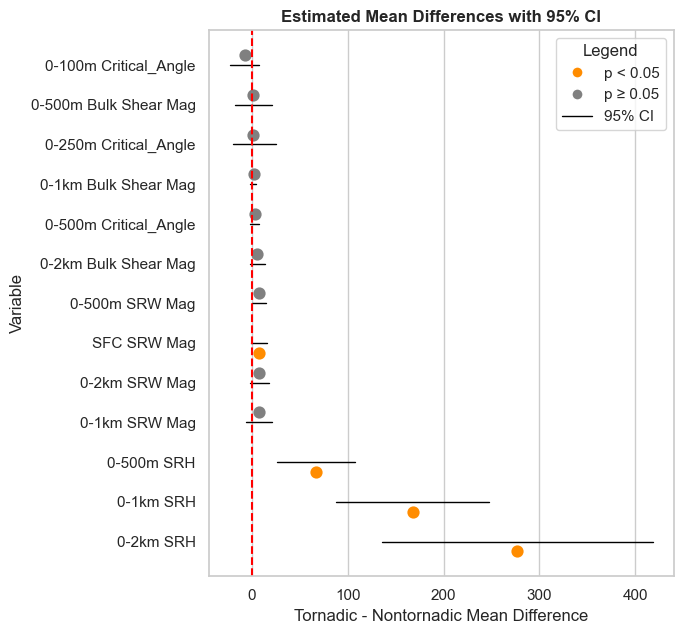

In [197]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert to DataFrame
summary_df = pd.DataFrame(summary_data)

# Sort for better visuals
summary_df = summary_df.sort_values('mean_difference')

# Add a column for significance
summary_df['significant'] = summary_df['p_value'] < 0.05

# Set seaborn theme
sns.set(style='whitegrid')

# Plot
plt.figure(figsize=(7, len(summary_df) * 0.5))
ax = sns.pointplot(
    data=summary_df,
    x='mean_difference',
    y='variable',
    join=False,
    hue='significant',
    palette={True: 'darkorange', False: 'gray'},
    dodge=0.5,
    markers='o',
    ci=None
)

# Add error bars manually (95% CI)
for i, row in summary_df.iterrows():
    plt.plot(
        [row['ci_lower'], row['ci_upper']],
        [i, i],
        color='black',
        linewidth=1,
    )

# Add a vertical line at zero
plt.axvline(0, color='red', linestyle='--')

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='p < 0.05',
           markerfacecolor='darkorange', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='p ≥ 0.05',
           markerfacecolor='gray', markersize=8),
    Line2D([0], [0], color='black', lw=1, label='95% CI')
]

# Add legend
plt.legend(handles=legend_elements, loc='upper right', title='Legend')

plt.tight_layout()

# Labels and title
plt.xlabel('Tornadic - Nontornadic Mean Difference')
plt.ylabel('Variable')
plt.title('Estimated Mean Differences with 95% CI', fontweight='bold')
#plt.legend(title='p < 0.05', loc='lower right')

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert to DataFrame
summary_df = pd.DataFrame(summary_data[summary_data['variable'] != 'Critical_Angle'])
summary_df = summary_df[~summary_df['variable'].str.contains('SRH', case=False, na=False)]

# Sort for better visuals
#summary_df = summary_df.sort_values('mean_difference')

# Add a column for significance
summary_df['significant'] = summary_df['p_value'] < 0.05

# Set seaborn theme
sns.set(style='whitegrid')

# Plot
plt.figure(figsize=(7, len(summary_df) * 0.5))
ax = sns.pointplot(
    data=summary_df,
    x='mean_difference',
    y='variable',
    join=False,
    hue='significant',
    palette={True: 'darkorange', False: 'gray'},
    dodge=0.5,
    markers='o',
    ci=None
)

# Add error bars manually (95% CI)
for i, row in summary_df.iterrows():
    plt.plot(
        [row['ci_lower_0.025'], row['ci_upper_0.975']],
        [i, i],
        color='black',
        linewidth=1
    )

# Add a vertical line at zero
plt.axvline(0, color='red', linestyle='--')

# Labels and title
plt.xlabel('Tornadic - Nontornadic Mean Difference')
plt.ylabel('Variable')
plt.title('Estimated Mean Differences with 95% CI')
plt.legend(title='p < 0.05', loc='lower right')

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert to DataFrame
summary_df = pd.DataFrame(summary_data[summary_data['variable'] != 'Critical_Angle'])
summary_df = summary_df[summary_df['variable'].str.contains('SRH', case=False, na=False)]

# Sort for better visuals
#summary_df = summary_df.sort_values('mean_difference')

# Add a column for significance
summary_df['significant'] = summary_df['p_value'] < 0.05

# Set seaborn theme
sns.set(style='whitegrid')

# Plot
plt.figure(figsize=(7, len(summary_df) * 0.5))
ax = sns.pointplot(
    data=summary_df,
    x='mean_difference',
    y='variable',
    join=False,
    hue='significant',
    palette={True: 'darkorange', False: 'gray'},
    dodge=0.5,
    markers='o',
    ci=None
)

# Add error bars manually (95% CI)
for i, row in summary_df.iterrows():
    plt.plot(
        [row['ci_lower_0.025'], row['ci_upper_0.975']],
        [i, i],
        color='black',
        linewidth=1
    )

# Add a vertical line at zero
plt.axvline(0, color='red', linestyle='--')

# Labels and title
plt.xlabel('Tornadic - Nontornadic Mean Difference')
plt.ylabel('Variable')
plt.title('Estimated Mean Differences with 95% CI')
plt.legend(title='p < 0.05', loc='lower right')

plt.tight_layout()
plt.show()


In [ ]:
summary_df

## nf vs ff

In [67]:
dist_angle_avg_date

,Date,Height,SRW or SRH,NF or FF,Dist avg,Tor or Nontor,Angle,Angle avg
0,20220523,0-100m,Critical Angle,ff,36.466110,tor,NaN,NaN
1,20220523,0-100m,Critical Angle,nf,41.978222,tor,NaN,NaN
2,20220523,0-1km,Bulk Shear,ff,10.784651,tor,NaN,NaN
3,20220523,0-1km,Bulk Shear,nf,15.319742,tor,NaN,NaN
4,20220523,0-1km,SRH,ff,220.519750,tor,NaN,NaN
...,...,...,...,...,...,...,...,...
619,20240528,0-500m,SRH,NaN,NaN,nontor,4590,50.858425
620,20240528,0-500m,SRW,NaN,NaN,nontor,045,8.048753
621,20240528,0-500m,SRW,NaN,NaN,nontor,4590,16.562429
622,20240528,SFC,SRW,NaN,NaN,nontor,045,11.658108


In [ ]:
# Filter to only 'tor' and only pretor and dtor
nfff_only = dist_angle_avg_date[
                     (dist_angle_avg_date['NF or FF'].isin(['nf', 'ff']))]

# Pivot the data to have 'pretor' and 'dtor' as columns
pivotednfff = nfff_only.pivot_table(index=['Date', 'SRW or SRH', 'Height', 'Tor or Nontor'],
                                columns='NF or FF',
                                values='Dist avg').reset_index()

# Drop rows where either pretor or dtor is missing
pivotednfff = pivotednfff.dropna(subset=['nf', 'ff'])

# Compute the difference
pivotednfff['nf_minus_ff'] = pivotednfff['nf'] - pivotednffff['ff']


In [ ]:
pivotednfff['Date'].value_counts()

In [ ]:
dist_both[dist_both['Tor or Nontor'] == 'nontor']['Date'].value_counts()

In [ ]:
dist_angle_avg_date[dist_angle_avg_date['Tor or Nontor'] == 'nontor']['Date'].value_counts()

In [71]:
mean_locs_nodate

,Tor or Nontor,NF or FF,Mean Distance,Angle,Mean Angle
0,nontor,ff,29.843661,NaN,NaN
1,nontor,nf,12.543805,NaN,NaN
2,tor,ff,32.105736,NaN,NaN
3,tor,nf,13.370220,NaN,NaN
4,nontor,NaN,NaN,045,19.943058
5,nontor,NaN,NaN,4590,69.753625
6,tor,NaN,NaN,045,14.151529
7,tor,NaN,NaN,4590,73.658999


In [95]:
a = dist_angle_avg_date.groupby(['Height', 'SRW or SRH', 'NF or FF', 'Tor or Nontor'])['Dist avg'].mean().reset_index()

<Axes: xlabel='Height', ylabel='Dist avg'>

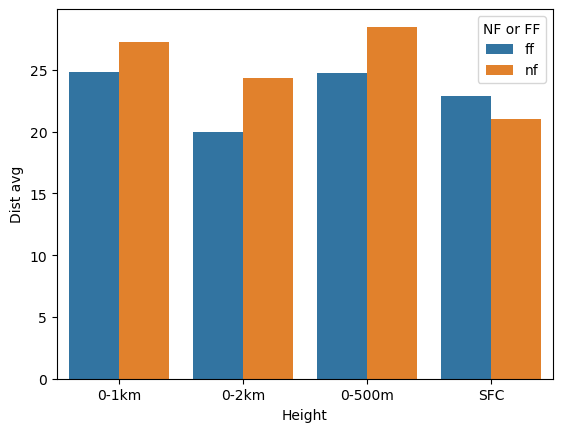

In [99]:
sns.barplot(a[(a['Tor or Nontor'] == 'tor') & (a['SRW or SRH'] == 'SRW')], x='Height', y='Dist avg', hue='NF or FF')

### boxplots

In [ ]:
sns.boxplot(dist_both[(dist_both['SRW or SRH'] == 'SRH')&(dist_both['Tor or Nontor'] == 'tor')], x='Height', y='Dist avg', hue='NF or FF', fill=False)
plt.ylabel('SRH (m2/s2)')
plt.title('Tor SRH For NF vs FF')

In [146]:
def nf_ff_boxplot(df, srw_srh, tor_nontor, x, y, hue, fill, ylabel, title, ax, cmap):
    sns.boxplot(df[(df['SRW or SRH'] == srw_srh)&(df['Tor or Nontor'] == tor_nontor)], x=x, y=y, hue=hue, fill=fill, ax=ax, palette=cmap)
    plt.ylabel(ylabel)
    ax.set_title(title)

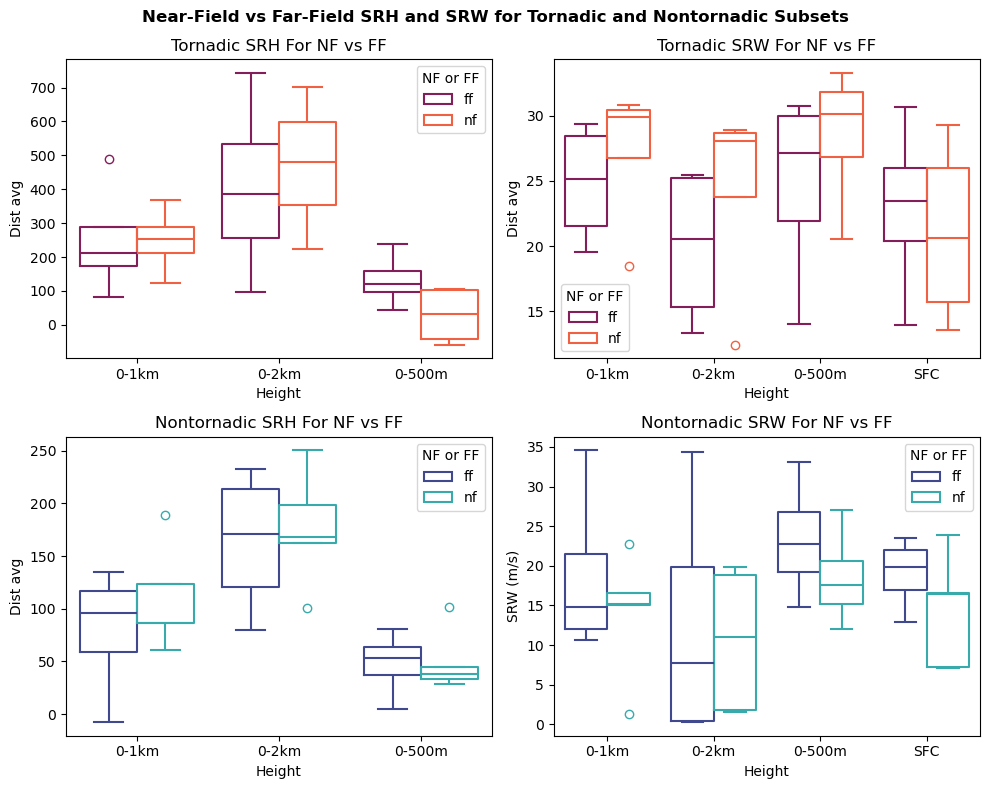

In [139]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

nf_ff_boxplot(dist_angle_avg_date, 'SRH', 'tor', 'Height', 'Dist avg', 'NF or FF', False, 'SRH (m2/s2)', 'Tornadic SRH For NF vs FF', axes[0,0], 'rocket')
nf_ff_boxplot(dist_angle_avg_date, 'SRW', 'tor', 'Height', 'Dist avg', 'NF or FF', False, 'SRW (m/s)', 'Tornadic SRW For NF vs FF', axes[0,1], 'rocket')
nf_ff_boxplot(dist_angle_avg_date, 'SRH', 'nontor', 'Height', 'Dist avg', 'NF or FF', False, 'SRH (m2/s2)', 'Nontornadic SRH For NF vs FF', axes[1,0], 'mako')
nf_ff_boxplot(dist_angle_avg_date, 'SRW', 'nontor', 'Height', 'Dist avg', 'NF or FF', False, 'SRW (m/s)', 'Nontornadic SRW For NF vs FF', axes[1,1], 'mako')

plt.suptitle('Near-Field vs Far-Field SRH and SRW for Tornadic and Nontornadic Subsets', fontweight='bold')
plt.tight_layout()
plt.show()

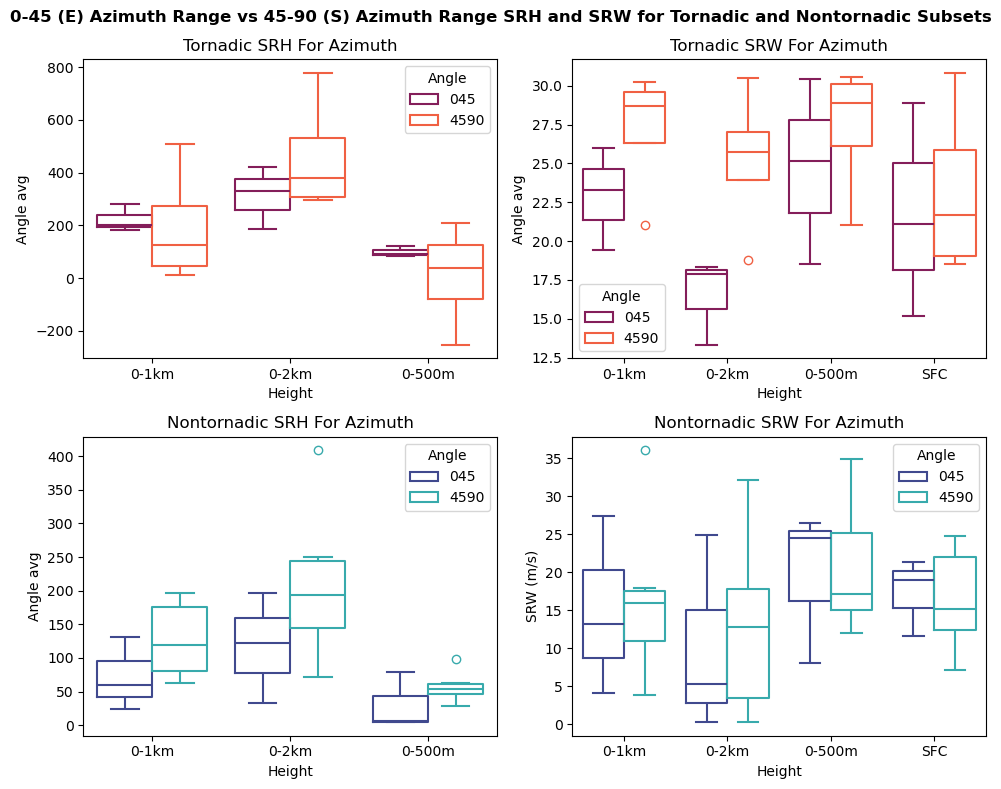

In [140]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

nf_ff_boxplot(dist_angle_avg_date, 'SRH', 'tor', 'Height', 'Angle avg', 'Angle', False, 'SRH (m2/s2)', 'Tornadic SRH For Azimuth', axes[0,0], 'rocket')
nf_ff_boxplot(dist_angle_avg_date, 'SRW', 'tor', 'Height', 'Angle avg', 'Angle', False, 'SRW (m/s)', 'Tornadic SRW For Azimuth', axes[0,1], 'rocket')
nf_ff_boxplot(dist_angle_avg_date, 'SRH', 'nontor', 'Height', 'Angle avg', 'Angle', False, 'SRH (m2/s2)', 'Nontornadic SRH For Azimuth', axes[1,0], 'mako')
nf_ff_boxplot(dist_angle_avg_date, 'SRW', 'nontor', 'Height', 'Angle avg', 'Angle', False, 'SRW (m/s)', 'Nontornadic SRW For Azimuth', axes[1,1], 'mako')

plt.suptitle('0-45 (E) Azimuth Range vs 45-90 (S) Azimuth Range SRH and SRW for Tornadic and Nontornadic Subsets', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
sns.boxplot(dist_angle_avg_date[(dist_angle_avg_date['SRW or SRH'] == 'SRH')&(dist_angle_avg_date['Tor or Nontor'] == 'tor')], x='Height', y='Dist avg', hue='NF or FF', fill=False)
plt.ylabel('SRH (m2/s2)')
plt.title('Tor SRH For NF vs FF')

In [ ]:
sns.boxplot(dist_angle_avg_date[(dist_angle_avg_date['SRW or SRH'] == 'SRH')&(dist_angle_avg_date['Tor or Nontor'] == 'nontor')], x='Height', y='Dist avg', hue='NF or FF', fill=False)
plt.ylabel('SRH (m2/s2)')
plt.title('Nontor SRH For NF vs FF')

In [ ]:
sns.boxplot(dist_angle_avg_date[(dist_angle_avg_date['SRW or SRH'] == 'SRW')&(dist_angle_avg_date['Tor or Nontor'] == 'tor')], x='Height', y='Dist avg', hue='NF or FF', fill=False)
plt.ylabel('SRW (m/s)')
plt.title('Tor SRW For NF vs FF')

In [ ]:
sns.boxplot(dist_both[(dist_both['SRW or SRH'] == 'SRW')&(dist_both['Tor or Nontor'] == 'tor')], x='Height', y='Dist avg', hue='NF or FF', fill=False)
plt.ylabel('SRW (m/s)')
plt.title('Tor SRW For NF vs FF')

In [ ]:
sns.boxplot(dist_angle_avg_date[(dist_angle_avg_date['SRW or SRH'] == 'SRW')&(dist_angle_avg_date['Tor or Nontor'] == 'nontor')], x='Height', y='Dist avg', hue='NF or FF', fill=False)
plt.ylabel('SRW (m/s)')
plt.title('Nontor SRW For NF vs FF')

In [ ]:
sns.boxplot(dist_angle_avg_date[(dist_angle_avg_date['SRW or SRH'] == 'Bulk Shear')&(dist_angle_avg_date['Tor or Nontor'] == 'tor')], x='Height', y='Dist avg', hue='NF or FF', fill=False)
plt.ylabel('Bulk Shear (m/s)')
plt.title('Tor Bulk Shear For NF vs FF')

In [ ]:
sns.boxplot(dist_angle_avg_date[(dist_angle_avg_date['SRW or SRH'] == 'Bulk Shear')&(dist_angle_avg_date['Tor or Nontor'] == 'nontor')], x='Height', y='Dist avg', hue='NF or FF', fill=False)
plt.ylabel('Bulk Shear (m/s)')
plt.title('Nontor Bulk Shear For NF vs FF')

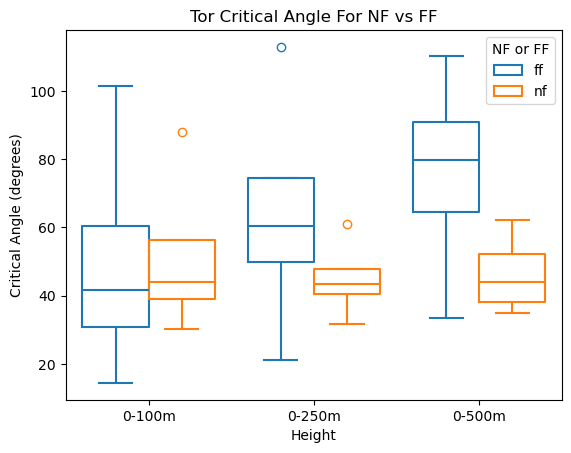

In [58]:
sns.boxplot(dist_angle_avg_date[(dist_angle_avg_date['SRW or SRH'] == 'Critical Angle')&(dist_angle_avg_date['Tor or Nontor'] == 'tor')], x='Height', y='Dist avg', hue='NF or FF', fill=False)
plt.ylabel('Critical Angle (degrees)')
plt.title('Tor Critical Angle For NF vs FF')
plt.show()

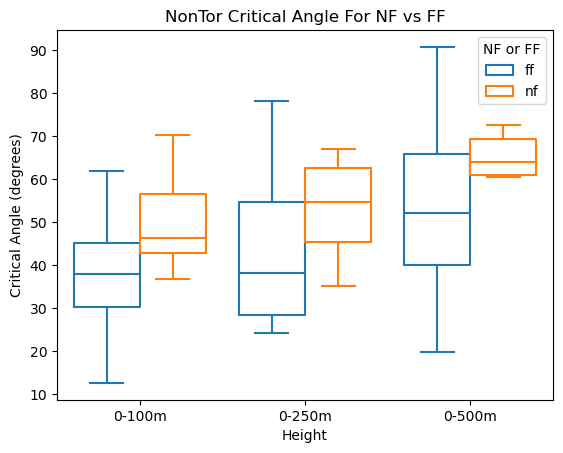

In [59]:
sns.boxplot(dist_angle_avg_date[(dist_angle_avg_date['SRW or SRH'] == 'Critical Angle')&(dist_angle_avg_date['Tor or Nontor'] == 'nontor')], x='Height', y='Dist avg', hue='NF or FF', fill=False)
plt.ylabel('Critical Angle (degrees)')
plt.title('NonTor Critical Angle For NF vs FF')
plt.show()

### mixed lm

In [117]:
df_all_new['NF or FF'] = np.where((df_all_new['Distance'] <= 20), 'nf',
                       np.where((df_all_new['Distance'] < 50), 'ff', np.nan))

df_all_new['0-45 or 45-90'] = np.where((df_all_new['Angle'] <= 45), '045',
                       np.where((df_all_new['Angle'] <= 90), '4590', np.nan))

In [118]:
# Identify the metadata (non-measurement) columns
id_vars = ['Date', 'Datetime', 'Tor or Nontor', 'Distance', 'Angle', 'Time From Tor (min)', 'NF or FF', '0-45 or 45-90']
df = df_all_new[(df_all_new['u or v'] == 'v') & (df_all_new['Distance'] < 50) & (df_all_new['Angle'] <= 90)].iloc[:, 197:]
# Automatically find all columns that are not metadata
value_vars = [col for col in df.columns if col not in id_vars]

# Melt the dataframe
df_long = pd.melt(
    df,
    id_vars=id_vars,
    value_vars=value_vars,
    var_name='variable',
    value_name='value'
)

df_long['NForFF'] = df_long['NF or FF'].astype('category')
df_long['Angle'] = df_long['0-45 or 45-90'].astype('category')
df_long['variable'] = df_long['variable'].astype('category')

In [107]:
predictors = ['NForFF', 'Angle']

results = []

for tor_type in df_long['Tor or Nontor'].unique():
    df_tor = df_long[df_long['Tor or Nontor'] == tor_type]

    for var in df_tor['variable'].unique():
        df_sub = df_tor[df_tor['variable'] == var]

        for predictor in predictors:
            try:
                model = smf.mixedlm(
                    f"value ~ {predictor}",
                    data=df_long,
                    groups="Date"
                )
                result = model.fit()

                # Match the correct name for the coefficient
                if predictor == 'NForFF':
                    term = 'NForFF[T.nf]'
                elif predictor == "Angle":
                    term = 'Angle[T.4590]'

                coef = result.params.get(term, float('nan'))
                pval = result.pvalues.get(term, float('nan'))

                results.append({
                    'tornado_type': tor_type,
                    'variable': var,
                    'predictor': predictor,
                    'effect': coef,
                    'p_value': pval
                })

            except Exception as e:
                print(f"Failed: {tor_type} - {var} - {predictor} -> {e}")


In [108]:
pd.DataFrame(results)

,tornado_type,variable,predictor,effect,p_value
0,tor,0-100m Critical_Angle,NForFF,0.382593,0.916422
1,tor,0-100m Critical_Angle,Angle,6.426531,0.095794
2,tor,0-250m Critical_Angle,NForFF,0.382593,0.916422
3,tor,0-250m Critical_Angle,Angle,6.426531,0.095794
4,tor,0-500m Critical_Angle,NForFF,0.382593,0.916422
5,tor,0-500m Critical_Angle,Angle,6.426531,0.095794
6,tor,0-500m Bulk Shear Mag,NForFF,0.382593,0.916422
7,tor,0-500m Bulk Shear Mag,Angle,6.426531,0.095794
8,tor,0-1km Bulk Shear Mag,NForFF,0.382593,0.916422
9,tor,0-1km Bulk Shear Mag,Angle,6.426531,0.095794


In [ ]:
results = []

df_long['NForFF'] = df_long['NF or FF'].astype('category')
df_long['0-45or45-90'] = df_long['0-45 or 45-90'].astype('category')
df_long['variable'] = df_long['variable'].astype('category')

for tor_type in df_long['Tor or Nontor'].unique():
    df_tor = df_long[df_long['Tor or Nontor'] == tor_type]

    for var in df_tor['variable'].unique():
        df_sub = df_tor[df_tor['variable'] == var]

        try:
            model = smf.mixedlm(
                "value ~ NForFF + Q('0-45or45-90')",
                data=df_sub,
                groups="Date"
            )
            result = model.fit()

            # Extract info
            intercept = result.params['Intercept']
            coef_nf_ff = result.params.get('NForFF[T.nf]', float('nan'))
            coef_angle = result.params.get("Q('0-45or45-90')[T.45-90]", float('nan'))

            results.append({
                'tornado_type': tor_type,
                'variable': var,
                'intercept': intercept,
                'NForFF_effect': coef_nf_ff,
                'angle_effect': coef_angle,
                'NForFF_p': result.pvalues.get('NForFF[T.nf]', float('nan')),
                'angle_p': result.pvalues.get("Q('0-45or45-90')[T.45-90]", float('nan'))
            })

        except Exception as e:
            print(f"Model failed for {tor_type} - {var}: {e}")


In [ ]:
pd.DataFrame(results)

In [ ]:
df_sub

In [ ]:
import seaborn as sns
sns.boxplot(data=df_sub, x='NForFF', y='value', hue="0-45or45-90")

In [120]:
df_long

,Date,Datetime,Tor or Nontor,Distance,Angle,Time From Tor (min),NF or FF,0-45 or 45-90,variable,value,NForFF
0,20220523,2022-05-23 23:49:42,tor,29.031666,045,-0.3,ff,045,0-100m Critical_Angle,2.249307,ff
1,20220523,2022-05-23 23:50:43,tor,33.744618,045,0.0,ff,045,0-100m Critical_Angle,103.377710,ff
2,20220523,2022-05-23 23:51:12,tor,33.759376,045,0.0,ff,045,0-100m Critical_Angle,21.335205,ff
3,20220523,2022-05-23 23:51:43,tor,33.806243,045,0.0,ff,045,0-100m Critical_Angle,109.578578,ff
4,20220524,2022-05-24 20:56:12,nontor,6.804281,4590,nontor,nf,4590,0-100m Critical_Angle,95.970961,nf
...,...,...,...,...,...,...,...,...,...,...,...
10343,20230615,2023-06-16 00:34:34,tor,17.730159,045,63.566667,nf,045,0-2km SRH,244.074307,nf
10344,20230615,2023-06-16 00:34:47,tor,17.730159,045,63.783333,nf,045,0-2km SRH,226.896842,nf
10345,20230615,2023-06-16 00:35:00,tor,17.730159,045,64.0,nf,045,0-2km SRH,206.528619,nf
10346,20230615,2023-06-16 00:37:02,tor,17.730194,045,66.033333,nf,045,0-2km SRH,218.595898,nf


In [121]:
summary_data = []

df_long['NForFF'] = df_long['NF or FF'].astype('category')
df_long['variable'] = df_long['variable'].astype('category')
#df_long['Date'] = pd.to_datetime(df_long['Date'])


#for i in df_long['Tor or Nontor'].unique():
df_long = df_long[df_long['Tor or Nontor'] == 'tor']
    
for var in df_long['variable'].unique():
    df_sub = df_long[df_long['variable'] == var]
    
    try:
        model = smf.mixedlm("value ~ NForFF", data=df_sub, groups="Date")
        result = model.fit()

        intercept = result.params['Intercept']
        coef = result.params.get('NForFF[T.nf]', 0)  # fallback if only one group
        pvall = result.pvalues.get('NForFF[T.nf]', float('nan'))

        summary_data.append({
            'variable': var,
            'ff_mean': intercept,
            'nf_mean': intercept + coef,
            'mean_difference': coef,
            'p_value': pvall
        })

    except Exception as e:
        print(f"Model failed for {var}: {e}")


In [122]:
result.pvalues

Intercept       4.506307e-09
NForFF[T.nf]    1.697921e-08
Date Var        2.283802e-01
dtype: float64

In [123]:
summary_data = pd.DataFrame(summary_data)

In [124]:
summary_data

,variable,ff_mean,nf_mean,mean_difference,p_value
0,0-100m Critical_Angle,39.821368,29.465176,-10.356193,4.971402e-03
1,0-250m Critical_Angle,54.947514,30.058156,-24.889358,1.102675e-11
2,0-500m Critical_Angle,64.791199,42.261186,-22.530014,3.212990e-09
3,0-500m Bulk Shear Mag,7.789943,7.216574,-0.573369,2.304659e-01
4,0-1km Bulk Shear Mag,10.663096,12.326358,1.663262,5.730860e-05
5,0-2km Bulk Shear Mag,15.665961,15.378663,-0.287298,4.565652e-01
6,SFC SRW Mag,24.302203,22.273639,-2.028564,5.265639e-09
7,0-500m SRW Mag,27.771997,29.243190,1.471193,5.322214e-03
8,0-1km SRW Mag,25.755024,28.133585,2.378561,1.951575e-04
9,0-2km SRW Mag,20.405381,26.069833,5.664452,2.970927e-14


### u test

In [101]:
dist_angle_avg_date

,Date,Height,SRW or SRH,NF or FF,Dist avg,Tor or Nontor,Angle,Angle avg
0,20220523,0-100m,Critical Angle,ff,36.466110,tor,NaN,NaN
1,20220523,0-100m,Critical Angle,nf,41.978222,tor,NaN,NaN
2,20220523,0-1km,Bulk Shear,ff,10.784651,tor,NaN,NaN
3,20220523,0-1km,Bulk Shear,nf,15.319742,tor,NaN,NaN
4,20220523,0-1km,SRH,ff,220.519750,tor,NaN,NaN
...,...,...,...,...,...,...,...,...
619,20240528,0-500m,SRH,NaN,NaN,nontor,4590,50.858425
620,20240528,0-500m,SRW,NaN,NaN,nontor,045,8.048753
621,20240528,0-500m,SRW,NaN,NaN,nontor,4590,16.562429
622,20240528,SFC,SRW,NaN,NaN,nontor,045,11.658108


In [102]:
import pandas as pd
from scipy.stats import mannwhitneyu

df = dist_angle_avg_date
# Assume your DataFrame is called df

# Create a list to hold results
results = []

# Group by the two variables: Height and SRW or SRH
grouped = df.groupby(['Height', 'SRW or SRH', 'Tor or Nontor'])

# Loop over each group
for (height, param, tnt), group in grouped:
    # Split into tornadic and nontornadic
    nf = group[group['NF or FF'] == 'nf']['Dist avg'].dropna()
    ff = group[group['NF or FF'] == 'ff']['Dist avg'].dropna()

    a045 = group[group['Angle'] == '045']['Angle avg'].dropna()
    a4590 = group[group['Angle'] == '4590']['Angle avg'].dropna()

    # Only run test if both groups have enough data
    if len(nf) > 1 and len(ff) > 1:
        stat, p_value = mannwhitneyu(nf, ff, use_continuity=False)  # Whitney u-test
        stat_a, p_value_a = mannwhitneyu(a045, a4590, use_continuity=False)  # Whitney u-test
        results.append({
            'Height': height,
            'SRW or SRH': param,
            'Tor or Nontor': tnt,
            'NF Mean': nf.mean(),
            'FF Mean': ff.mean(),
            '0-45 Mean': a045.mean(),
            '45-90 Mean': a4590.mean(),
            'NF-FF % Diff': 100* (nf.mean() - ff.mean())/(nf.mean() + ff.mean()),
            '045-4590 % Diff': 100* (a045.mean() - a4590.mean())/(a045.mean() + a4590.mean()),
            'p-value (nf vs ff)': p_value,
            'p-value (0-45 vs 45-90)': p_value_a,
            'n_nf': len(nf),
            'n_ff': len(ff),
            'n_0-45': len(a045),
            'n_45-90': len(a4590),
        })
    else:
        results.append({
            'Height': height,
            'SRW or SRH': param,
            'Tornadic Mean': tor.mean() if len(tor) > 0 else None,
            'Nontornadic Mean': nontor.mean() if len(nontor) > 0 else None,
            'p-value': None,
            'n_tor': len(tor),
            'n_nontor': len(nontor)
        })

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Optional: sort by p-value
results_df_dist_angle = results_df.sort_values(by='p-value (nf vs ff)')


In [103]:
results_df_dist_angle

,Height,SRW or SRH,Tor or Nontor,NF Mean,FF Mean,0-45 Mean,45-90 Mean,NF-FF % Diff,045-4590 % Diff,p-value (nf vs ff),p-value (0-45 vs 45-90),n_nf,n_ff,n_0-45,n_45-90
21,0-500m,SRH,tor,28.113006,131.775047,98.531555,7.531678,-64.834138,85.797759,0.114286,0.857143,4,4,3,4
10,0-2km,Bulk Shear,nontor,9.773188,6.591103,7.833674,10.313851,19.445294,-13.666750,0.190476,0.380952,5,4,3,6
0,0-100m,Critical Angle,nontor,50.524688,37.535549,65.138428,46.045930,14.750288,17.171929,0.285714,1.000000,5,4,3,6
18,0-500m,Critical Angle,nontor,65.473414,53.683474,72.103624,61.148680,9.894468,8.221205,0.285714,1.000000,5,4,3,6
7,0-1km,SRW,tor,27.270806,24.808764,22.899987,27.155489,4.727463,-8.501571,0.342857,0.228571,4,4,3,4
19,0-500m,Critical Angle,tor,46.330819,75.758358,72.510721,58.740457,-24.103316,10.491536,0.342857,0.400000,4,4,3,4
15,0-2km,SRW,tor,24.354999,19.979973,16.525249,25.191095,9.868116,-20.773261,0.342857,0.057143,4,4,3,4
22,0-500m,SRW,nontor,18.494923,23.331681,19.675126,20.581074,-11.563830,-2.250456,0.412698,0.904762,5,4,3,6
24,SFC,SRW,nontor,14.231320,19.025652,17.371367,16.327557,-14.416023,3.097460,0.412698,1.000000,5,4,3,6
23,0-500m,SRW,tor,28.492260,24.747507,24.685256,27.343056,7.033750,-5.108374,0.485714,0.628571,4,4,3,4


In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

df = dist_angle_avg_date
# Assume your DataFrame is called df

# Create a list to hold results
results = []

# Group by the two variables: Height and SRW or SRH
grouped = df.groupby(['Height', 'SRW or SRH', 'Tor or Nontor'])

# Loop over each group
for (height, param, tnt), group in grouped:
    # Split into tornadic and nontornadic
    nf = group[group['NF or FF'] == 'nf']['Dist avg'].dropna()
    ff = group[group['NF or FF'] == 'ff']['Dist avg'].dropna()

    a045 = group[group['Angle'] == '0-45']['Angle avg'].dropna()
    a4590 = group[group['Angle'] == '45-90']['Angle avg'].dropna()

    # Only run test if both groups have enough data
    if len(nf) > 1 and len(ff) > 1:
        stat, p_value = mannwhitneyu(nf, ff, use_continuity=False, alternative='greater')  # Whitney u-test
        stat_a, p_value_a = mannwhitneyu(a045, a4590, use_continuity=False, alternative='greater')  # Whitney u-test
        results.append({
            'Height': height,
            'SRW or SRH': param,
            'Tor or Nontor': tnt,
            'NF Mean': nf.mean(),
            'FF Mean': ff.mean(),
            '0-45 Mean': a045.mean(),
            '45-90 Mean': a4590.mean(),
            'NF-FF % Diff': 100* (nf.mean() - ff.mean())/(nf.mean() + ff.mean()),
            '045-4590 % Diff': 100* (a045.mean() - a4590.mean())/(a045.mean() + a4590.mean()),
            'p-value (nf>ff)': p_value,
            'p-value (0-45>45-90)': p_value_a,
            'n_nf': len(nf),
            'n_ff': len(ff),
            'n_0-45': len(a045),
            'n_45-90': len(a4590),
        })
    else:
        results.append({
            'Height': height,
            'SRW or SRH': param,
            'Tornadic Mean': tor.mean() if len(tor) > 0 else None,
            'Nontornadic Mean': nontor.mean() if len(nontor) > 0 else None,
            'p-value': None,
            'n_tor': len(tor),
            'n_nontor': len(nontor)
        })

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Optional: sort by p-value
results_df_dist_angle = results_df.sort_values(by='p-value (nf>ff)')


In [ ]:
results_df_dist_angle

In [ ]:
results_df_dist_angle.sort_values(by='p-value (0-45>45-90)')

In [ ]:
results_df_dist_angle.sort_values(by='NF-FF % Diff')

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

df = dist_angle_avg_date
# Assume your DataFrame is called df

# Create a list to hold results
results = []

# Group by the two variables: Height and SRW or SRH
grouped = df.groupby(['Height', 'SRW or SRH', 'Tor or Nontor'])

# Loop over each group
for (height, param, tnt), group in grouped:
    # Split into tornadic and nontornadic
    nf = group[group['NF or FF'] == 'nf']['Dist avg'].dropna()
    ff = group[group['NF or FF'] == 'ff']['Dist avg'].dropna()

    a045 = group[group['Angle'] == '0-45']['Angle avg'].dropna()
    a4590 = group[group['Angle'] == '45-90']['Angle avg'].dropna()

    # Only run test if both groups have enough data
    if len(nf) > 1 and len(ff) > 1:
        stat, p_value = mannwhitneyu(nf, ff, use_continuity=False, alternative='less')  # Whitney u-test
        stat_a, p_value_a = mannwhitneyu(a045, a4590, use_continuity=False, alternative='less')  # Whitney u-test
        results.append({
            'Height': height,
            'SRW or SRH': param,
            'Tor or Nontor': tnt,
            'NF Mean': nf.mean(),
            'FF Mean': ff.mean(),
            '0-45 Mean': a045.mean(),
            '45-90 Mean': a4590.mean(),
            'NF-FF % Diff': 100* (nf.mean() - ff.mean())/(nf.mean() + ff.mean()),
            '045-4590 % Diff': 100* (a045.mean() - a4590.mean())/(a045.mean() + a4590.mean()),
            'p-value (nf<ff)': p_value,
            'p-value (0-45<45-90)': p_value_a,
            'n_nf': len(nf),
            'n_ff': len(ff),
            'n_0-45': len(a045),
            'n_45-90': len(a4590),
        })
    else:
        results.append({
            'Height': height,
            'SRW or SRH': param,
            'Tornadic Mean': tor.mean() if len(tor) > 0 else None,
            'Nontornadic Mean': nontor.mean() if len(nontor) > 0 else None,
            'p-value': None,
            'n_tor': len(tor),
            'n_nontor': len(nontor)
        })

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Optional: sort by p-value
results_df_dist_angle = results_df.sort_values(by='p-value (nf<ff)')


In [ ]:
results_df_dist_angle

### ttest

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

df = dist_angle_avg_date
# Assume your DataFrame is called df

# Create a list to hold results
results = []

# Group by the two variables: Height and SRW or SRH
grouped = df.groupby(['Height', 'SRW or SRH', 'Tor or Nontor'])

# Loop over each group
for (height, param, tnt), group in grouped:
    # Split into tornadic and nontornadic
    nf = group[group['NF or FF'] == 'nf']['Dist avg'].dropna()
    ff = group[group['NF or FF'] == 'ff']['Dist avg'].dropna()

    a045 = group[group['Angle'] == '0-45']['Angle avg'].dropna()
    a4590 = group[group['Angle'] == '45-90']['Angle avg'].dropna()

    # Only run test if both groups have enough data
    if len(nf) > 1 and len(ff) > 1:
        stat, p_value = ttest_ind(nf, ff, equal_var=False, alternative='greater')  # Whitney u-test
        stat_a, p_value_a = ttest_ind(a045, a4590, equal_var=False, alternative='greater')  # Whitney u-test
        results.append({
            'Height': height,
            'SRW or SRH': param,
            'Tor or Nontor': tnt,
            'NF Mean': nf.mean(),
            'FF Mean': ff.mean(),
            '0-45 Mean': a045.mean(),
            '45-90 Mean': a4590.mean(),
            'p-value (nf>ff)': p_value,
            'p-value (0-45>45-90)': p_value_a,
            'n_nf': len(nf),
            'n_ff': len(ff),
            'n_0-45': len(a045),
            'n_45-90': len(a4590),
        })
    else:
        results.append({
            'Height': height,
            'SRW or SRH': param,
            'Tornadic Mean': tor.mean() if len(tor) > 0 else None,
            'Nontornadic Mean': nontor.mean() if len(nontor) > 0 else None,
            'p-value': None,
            'n_tor': len(tor),
            'n_nontor': len(nontor)
        })

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Optional: sort by p-value
results_df_dist_angle_ttest = results_df.sort_values(by='p-value (nf>ff)')


In [ ]:
results_df_dist_angle_ttest

In [ ]:
results_df_dist_angle_ttest.sort_values(by='p-value (0-45>45-90)')

### df_all_new

In [ ]:
label = '0-2km SRH'
result = permutation_test((dftor[label], dfnontor[label]), test_stat, permutation_type='independent')

In [ ]:
result

In [ ]:
plt.hist(result.null_distribution, bins=50)
plt.title('Permutation Distribution of Difference in Tor vs Nontor 0-2km SRH Means')
plt.xlabel('Value of Tor - Nontor 0-2km SRH Mean')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# comparing if CDF of dfnontor is less than CDF of dftor

from scipy import stats
label = '0-2km SRH'
ks_statistic, p_value = stats.ks_2samp(dftor[label], dfnontor[label], alternative='less')

In [ ]:
p_value

In [ ]:
ks_statistic

"Note that the alternative hypotheses describe the CDFs of the underlying distributions, not the observed values of the data. For example, suppose x1 ~ F and x2 ~ G. If F(x) > G(x) for all x, the values in x1 tend to be less than those in x2." (stats.ks_2samp)

--> Whichever one is greater than the other has smaller values in its distribution

so for ours it's saying G(x) (nontor) > F(x) (tor), meaning G(x) has smaller values

In [ ]:
# comparing if CDF of dfnontor is greater than CDF of dftor

from scipy import stats
label = '0-2km SRH'
ks_statistic2, p_value2 = stats.ks_2samp(dftor[label], dfnontor[label], alternative='greater')

In [ ]:
ks_statistic2

In [ ]:
p_value2

In [ ]:
from scipy.stats import permutation_test
label = '0-2km SRW Mag'
result_02_srw = permutation_test((dftor[label], dfnontor[label]), test_stat, permutation_type='independent')

In [ ]:
from scipy.stats import permutation_test
srw_or_srh = 'SRW'
#spec_comp_date = spec_comp[spec_comp['Date'] == date]
spec_comp_date = spec_comp
col = 'Dist avg'
nforff = 'nf'
h = '0-2km'
spec_comp_date = spec_comp_date[spec_comp_date['SRW or SRH'] == srw_or_srh]
spec_comp_date = spec_comp_date[spec_comp_date['NF or FF'] == nforff]
spec_comp_date = spec_comp_date[spec_comp_date['Height'] == h]
spec_comp_datetor = spec_comp_date[spec_comp_date['Tor or Nontor'] == 'tor']
spec_comp_datenontor = spec_comp_date[spec_comp_date['Tor or Nontor'] == 'nontor']

testpair = permutation_test((spec_comp_datetor[col], spec_comp_datenontor[col]), test_stat, permutation_type='pairings')
testindep = permutation_test((spec_comp_datetor[col], spec_comp_datenontor[col]), test_stat, permutation_type='independent')

In [ ]:
testpair

In [ ]:
testindep

In [ ]:
result_02_srw

In [ ]:
plt.hist(result_02_srw.null_distribution, bins=50)
plt.title('Permutation Distribution of Difference in Tor vs Nontor 0-2km SRW Mag Means')
plt.xlabel('Value of Tor - Nontor 0-2km SRW Mag Mean')
plt.ylabel('Frequency')
plt.show()

In [ ]:
dftor

Determine 97.5th percentile and 2.5th percentile for data and exclude all outliers (as in Potvin et al 2010, Assessing the Impacts of Proximity Soundings...)

In [ ]:
col = '0-2km SRW Mag'
tor_02_srw_975percentile = np.percentile(dftor[col], 97.5)
tor_02_srw_25percentile = np.percentile(dftor[col], 2.5)

nontor_02_srw_975percentile = np.percentile(dfnontor[col], 97.5)
nontor_02_srw_25percentile = np.percentile(dfnontor[col], 2.5)

In [ ]:
tor_02_srw_975percentile

In [ ]:
tor_02_srw_25percentile

In [ ]:
nontor_02_srw_975percentile

In [ ]:
nontor_02_srw_25percentile

In [ ]:
col = '0-2km SRH'
tor_02_srh_975percentile = np.percentile(dftor[col], 97.5)
tor_02_srh_25percentile = np.percentile(dftor[col], 2.5)

nontor_02_srh_975percentile = np.percentile(dfnontor[col], 97.5)
nontor_02_srh_25percentile = np.percentile(dfnontor[col], 2.5)

In [ ]:
tor_02_srw_975percentile

In [ ]:
tor_02_srw_25percentile 

In [ ]:
np.shape(dfnontor)

In [ ]:
dftor[dftor['0-2km SRW Mag'] > nontor_02_srw_975percentile]

In [ ]:
dfnontor[dfnontor['0-2km SRH'] > nontor_02_srh_975percentile]

In [ ]:
dfnontor[dfnontor['0-2km SRH'] < nontor_02_srh_25percentile]

In [ ]:
nontor_02_srw_25percentile 

### angle

In [ ]:
dist_angle_avg_date

In [ ]:
sns.boxplot(dist_angle_avg_date[(dist_angle_avg_date['SRW or SRH'] == 'SRH')&(dist_angle_avg_date['Tor or Nontor'] == 'tor')], x='Height', y='Angle avg', hue='Angle', fill=False)
plt.ylabel('SRH (m2/s2)')
plt.title('Tor SRH For Angle')

In [ ]:
sns.boxplot(dist_angle_avg_date[(dist_angle_avg_date['SRW or SRH'] == 'SRW')&(dist_angle_avg_date['Tor or Nontor'] == 'tor')], x='Height', y='Angle avg', hue='Angle', fill=False)
plt.ylabel('SRW (m/s)')
plt.title('Tor SRW For Angle')

In [ ]:
sns.boxplot(dist_angle_avg_date[(dist_angle_avg_date['SRW or SRH'] == 'Bulk Shear')&(dist_angle_avg_date['Tor or Nontor'] == 'tor')], x='Height', y='Angle avg', hue='Angle', fill=False)
plt.ylabel('Bulk Shear (m/s)')
plt.title('Tor Bulk Shear For Angle')

Text(0.5, 1.0, 'Tor Critical Angle For Angle')

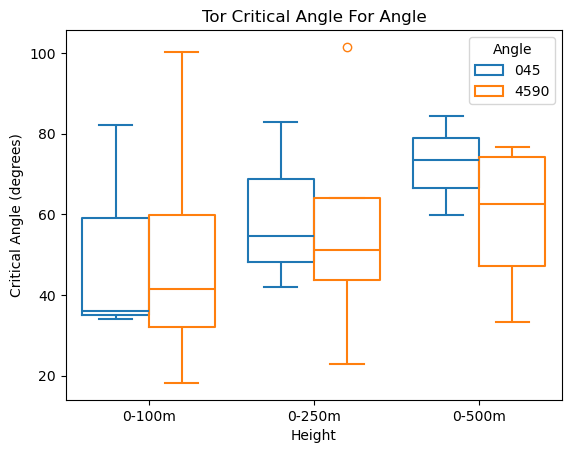

In [65]:
sns.boxplot(dist_angle_avg_date[(dist_angle_avg_date['SRW or SRH'] == 'Critical Angle')&(dist_angle_avg_date['Tor or Nontor'] == 'tor')], x='Height', y='Angle avg', hue='Angle', fill=False)
plt.ylabel('Critical Angle (degrees)')
plt.title('Tor Critical Angle For Angle')

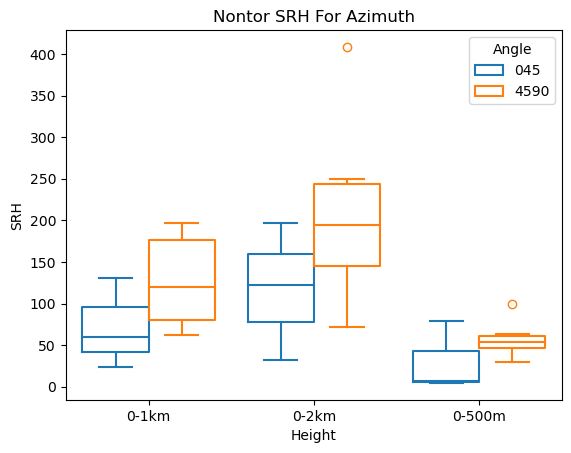

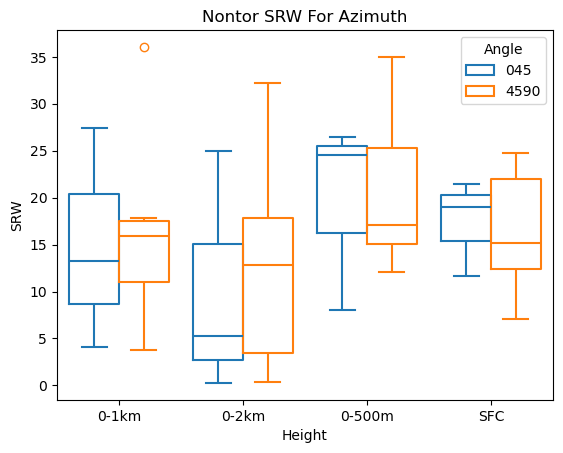

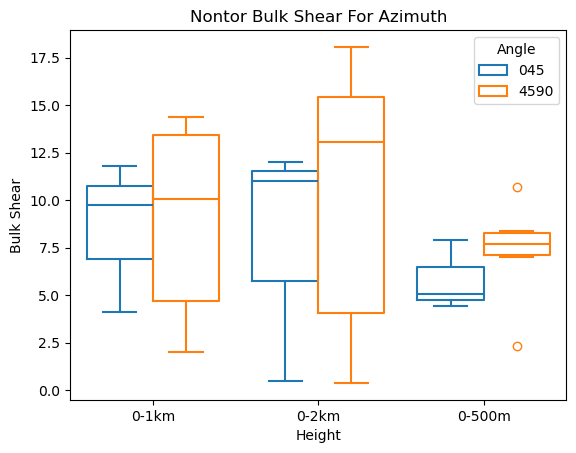

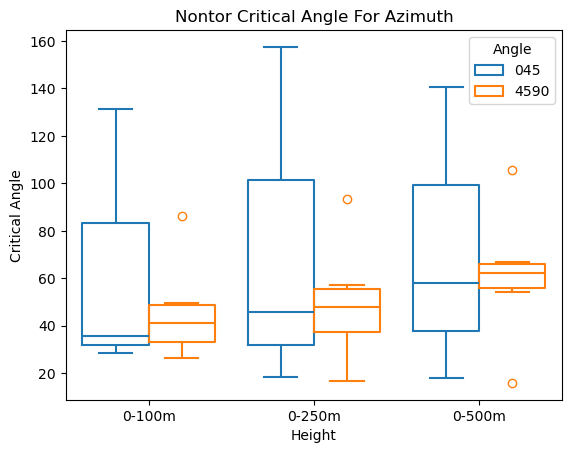

In [66]:
label = ['SRH', 'SRW', 'Bulk Shear', 'Critical Angle']
for l in label:
    sns.boxplot(dist_angle_avg_date[(dist_angle_avg_date['SRW or SRH'] == l)&(dist_angle_avg_date['Tor or Nontor'] == 'nontor')], x='Height', y='Angle avg', hue='Angle', fill=False)
    plt.ylabel(l)
    plt.title(f'Nontor {l} For Azimuth')
    plt.show()

## Tor Times

In [ ]:
summary[summary['Tor Time'] != 'posttor']

In [144]:
pred_dist

,Date,Tor Time,Height,SRW or SRH,Dist avg
0,20220523,dtor,0-100m,Critical Angle,78.097164
1,20220523,dtor,0-1km,Bulk Shear,10.566191
2,20220523,dtor,0-1km,SRH,97.509175
3,20220523,dtor,0-1km,SRW,23.093634
4,20220523,dtor,0-250m,Critical Angle,93.394096
...,...,...,...,...,...
190,20240602,pretor,0-500m,Bulk Shear,NaN
191,20240602,pretor,0-500m,Critical Angle,NaN
192,20240602,pretor,0-500m,SRH,NaN
193,20240602,pretor,0-500m,SRW,NaN


In [94]:
pred_dist.groupby(['Tor Time', 'Height', 'SRW or SRH'])['Dist avg'].mean().reset_index()

,Tor Time,Height,SRW or SRH,Dist avg
0,dtor,0-100m,Critical Angle,50.351948
1,dtor,0-1km,Bulk Shear,13.884096
2,dtor,0-1km,SRH,316.482117
3,dtor,0-1km,SRW,26.992725
4,dtor,0-250m,Critical Angle,52.862444
5,dtor,0-2km,Bulk Shear,15.709003
6,dtor,0-2km,SRH,499.213910
7,dtor,0-2km,SRW,23.378986
8,dtor,0-500m,Bulk Shear,7.434546
9,dtor,0-500m,Critical Angle,57.883861


### box plots

In [148]:
def pretor_boxplot(df, srw_srh, x, y, hue, fill, ylabel, title, ax, cmap):
    sns.boxplot(df[(df['SRW or SRH'] == srw_srh)], x=x, y=y, hue=hue, fill=fill, ax=ax, palette=cmap)
    plt.ylabel(ylabel)
    ax.set_title(title)

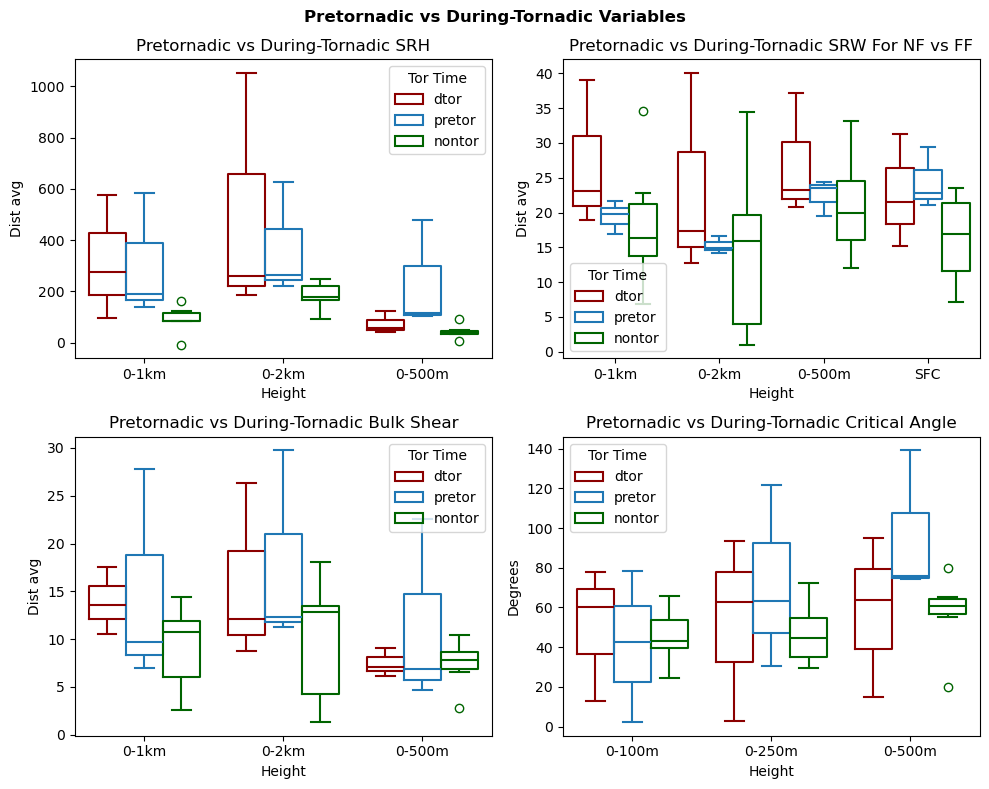

In [153]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

dfs = pred_dist
cmap= ['darkred', 'tab:blue', 'darkgreen']

pretor_boxplot(dfs, 'SRH', 'Height', 'Dist avg', 'Tor Time', False, 'SRH (m2/s2)', 'Pretornadic vs During-Tornadic SRH', axes[0,0], cmap)
pretor_boxplot(dfs, 'SRW', 'Height', 'Dist avg', 'Tor Time', False, 'SRW (m/s)', 'Pretornadic vs During-Tornadic SRW For NF vs FF', axes[0,1], cmap)
pretor_boxplot(dfs, 'Bulk Shear', 'Height', 'Dist avg', 'Tor Time', False, 'Bulk Shear (m/s)', 'Pretornadic vs During-Tornadic Bulk Shear', axes[1,0], cmap)
pretor_boxplot(dfs, 'Critical Angle', 'Height', 'Dist avg', 'Tor Time', False, 'Degrees', 'Pretornadic vs During-Tornadic Critical Angle', axes[1,1], cmap)

plt.suptitle('Pretornadic vs During-Tornadic Variables', fontweight='bold')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, '0-2km Variable for Pretor vs Dtor')

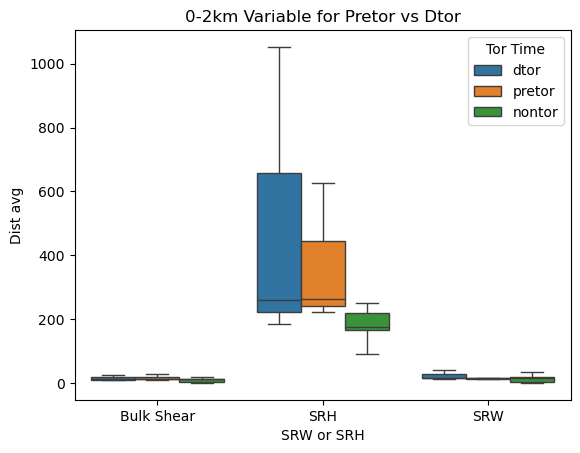

In [60]:
sns.boxplot(pred_dist[pred_dist['Height'] == '0-2km'], x='SRW or SRH', y='Dist avg', hue='Tor Time')
plt.title('0-2km Variable for Pretor vs Dtor')

Text(0.5, 1.0, '0-2km SRH For Pretornadic and During Tornadic Periods')

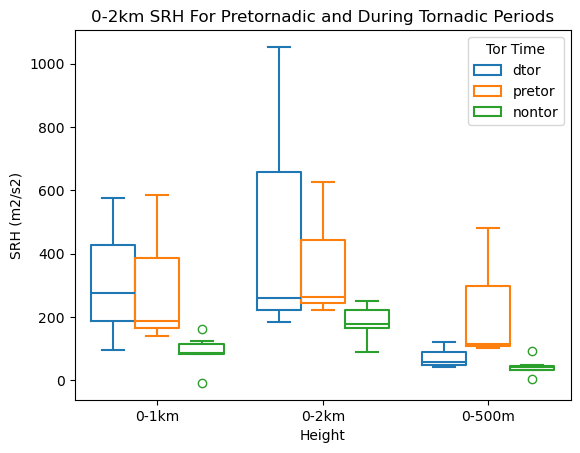

In [89]:
sns.boxplot(pred_dist[(pred_dist['SRW or SRH'] == 'SRH')], x='Height', y='Dist avg', hue='Tor Time', fill=False)
plt.ylabel('SRH (m2/s2)')
plt.title('0-2km SRH For Pretornadic and During Tornadic Periods')

Text(0.5, 1.0, '0-2km SRW Magnitude For Pretornadic and During Tornadic Periods')

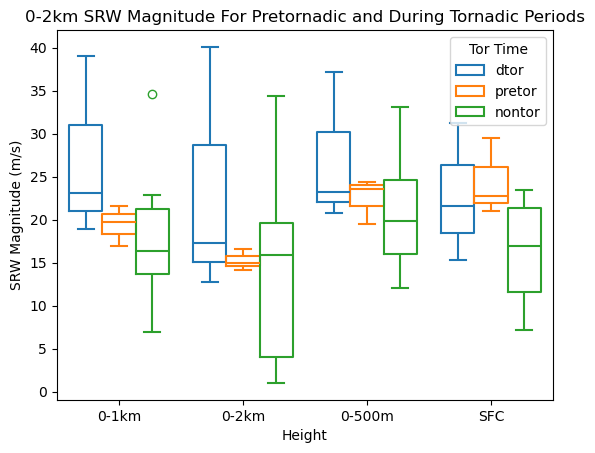

In [90]:
sns.boxplot(pred_dist[pred_dist['SRW or SRH'] == 'SRW'], x='Height', y='Dist avg', hue='Tor Time', fill=False)
plt.ylabel('SRW Magnitude (m/s)')
plt.title('0-2km SRW Magnitude For Pretornadic and During Tornadic Periods')
#plt.grid()

Text(0.5, 1.0, 'Bulk Shear Magnitude For Pretornadic and During Tornadic Periods')

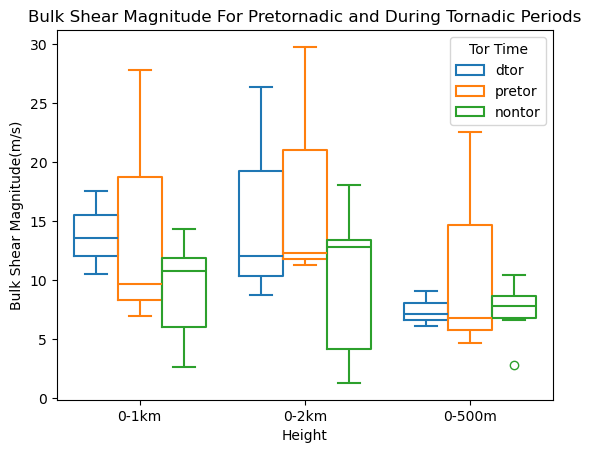

In [63]:
sns.boxplot(pred_dist[pred_dist['SRW or SRH'] == 'Bulk Shear'], x='Height', y='Dist avg', hue='Tor Time', fill=False)
plt.ylabel('Bulk Shear Magnitude(m/s)')
plt.title('Bulk Shear Magnitude For Pretornadic and During Tornadic Periods')
#plt.grid()

Text(0.5, 1.0, 'Critical Angle For Pretornadic and During Tornadic Periods')

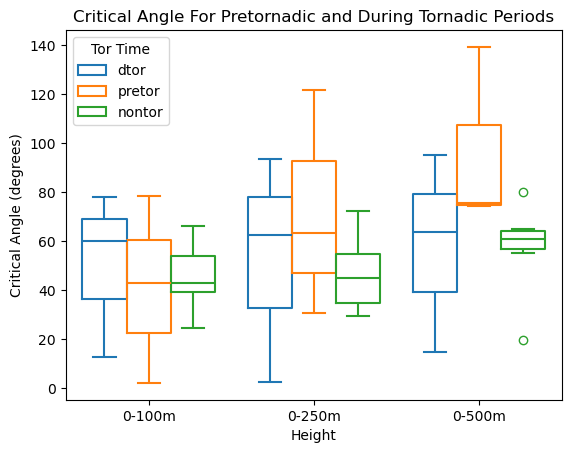

In [64]:
sns.boxplot(pred_dist[pred_dist['SRW or SRH'] == 'Critical Angle'], x='Height', y='Dist avg', hue='Tor Time', fill=False)
plt.ylabel('Critical Angle (degrees)')
plt.title('Critical Angle For Pretornadic and During Tornadic Periods')

#### dtor - pretor

In [ ]:
# Filter to only 'tor' and only pretor and dtor
tor_only = pred_dist[ 
                    (pred_dist['Tor Time'].isin(['pretor', 'dtor']))]

# Pivot the data to have 'pretor' and 'dtor' as columns
pivoted = tor_only.pivot_table(index=['Date', 'SRW or SRH', 'Height'],
                                columns='Tor Time',
                                values='Dist avg').reset_index()

# Drop rows where either pretor or dtor is missing
pivoted = pivoted.dropna(subset=['pretor', 'dtor'])

# Compute the difference
pivoted['dtor_minus_pretor'] = pivoted['dtor'] - pivoted['pretor']
pivoted['% Diff'] = 100* (pivoted['dtor'] - pivoted['pretor'])/(pivoted['dtor'] + pivoted['pretor'])


In [ ]:
pivoted.sort_values(by='% Diff')

In [ ]:
sns.boxplot(pivoted[pivoted['SRW or SRH'] == 'SRH'], x='SRW or SRH', y='dtor_minus_pretor', hue='Height', fill=False)
plt.title('Dtor - Pretor Per IOP Values')

In [ ]:
sns.boxplot(pivoted[pivoted['SRW or SRH'] == 'SRW'], x='SRW or SRH', y='dtor_minus_pretor', hue='Height', fill=False)
plt.title('Dtor - Pretor Per IOP Values')

In [ ]:
sns.boxplot(pivoted[pivoted['SRW or SRH'] == 'Bulk Shear'], x='SRW or SRH', y='dtor_minus_pretor', hue='Height', fill=False)
plt.title('Dtor - Pretor Per IOP Values')

In [ ]:
sns.boxplot(pivoted[pivoted['SRW or SRH'] == 'Critical Angle'], x='SRW or SRH', y='dtor_minus_pretor', hue='Height', fill=False)
plt.title('Dtor - Pretor Per IOP Values')

In [ ]:
sns.boxplot(pivoted[pivoted['SRW or SRH'] == 'SRH'], x='SRW or SRH', y='dtor_minus_pretor', hue='Height')
plt.title('Dtor - Pretor Per IOP Values')

### u test

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

df = pred_dist
# Assume your DataFrame is called df

# Create a list to hold results
results = []

# Group by the two variables: Height and SRW or SRH
grouped = df.groupby(['Height', 'SRW or SRH'])

# Loop over each group
for (height, param), group in grouped:
    # Split into tornadic and nontornadic
    pretor = group[group['Tor Time'] == 'pretor']['Dist avg'].dropna()
    dtor = group[group['Tor Time'] == 'dtor']['Dist avg'].dropna()
    #posttor = group[group['Tor Time'] == 'posttor']['Dist avg'].dropna()

    #a045 = group[group['Angle'] == '0-45']['Angle avg'].dropna()
    #a4590 = group[group['Angle'] == '45-90']['Angle avg'].dropna()

    # Only run test if both groups have enough data
    if len(pretor) > 1 and len(dtor) > 1 and len(posttor) > 1:
        stat_0, p_value_0 = mannwhitneyu(pretor, dtor, use_continuity=False)  # Whitney u-test
        #stat_1, p_value_1 = mannwhitneyu(dtor, posttor, use_continuity=False)  # Whitney u-test
        #stat_2, p_value_2 = mannwhitneyu(pretor, posttor, use_continuity=False)  # Whitney u-test
        results.append({
            'Height': height,
            'SRW or SRH': param,
            #'Tor Time': tnt,
            'Pretor Mean': pretor.mean(),
            'Dtor Mean': dtor.mean(),
            'Posttor Mean': posttor.mean(),
            # '0-45 Mean': a045.mean(),
            # '45-90 Mean': a4590.mean(),
            'Pretor-Dtor % Diff': 100* (pretor.mean() - dtor.mean())/(pretor.mean() + dtor.mean()),
            #'Dtor-Posttor % Diff': 100* (dtor.mean() - posttor.mean())/(dtor.mean() + posttor.mean()),
            #'Pretor-Posttor % Diff': 100* (pretor.mean() - posttor.mean())/(pretor.mean() + posttor.mean()),
            'p-value (pretor vs dtor)': p_value_0,
            #'p-value (dtor vs posttor)': p_value_1,
            #'p-value (pretor vs posttor)': p_value_2,
            'n_pretor': len(pretor),
            'n_dtor': len(dtor),
            #'n_posttor': len(posttor),
            #'n_0-45': len(a045),
            #'n_45-90': len(a4590),
        })
    else:
        results.append({
            'Height': height,
            'SRW or SRH': param,
            'Tornadic Mean': tor.mean() if len(tor) > 0 else None,
            'Nontornadic Mean': nontor.mean() if len(nontor) > 0 else None,
            'p-value': None,
            'n_tor': len(tor),
            'n_nontor': len(nontor)
        })

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Optional: sort by p-value
results_df_dist_angle = results_df.sort_values(by='p-value (pretor vs dtor)')


In [ ]:
results_df_dist_angle

## Composites statistical analysis (unsure whether to use this...)

In [ ]:
comp_tor_all_new_copy = comp_tor_all_new.copy()
comp_tor_all_new_copy['Tor or Nontor'] = 'tor'

comp_nontor_all_new_copy = comp_nontor_all_new.copy()
comp_nontor_all_new_copy['Tor or Nontor'] = 'nontor'

In [ ]:
comp_a = pd.DataFrame()
comp_ALL = pd.concat([comp_a, comp_tor_all_new_copy, comp_nontor_all_new_copy])

In [ ]:
#plt.figure(figsize = (12, 4))
df = comp_ALL
df = df[df['wind'] == 'v']
p = so.Plot(df, x=195, color='Tor or Nontor').add(
    sns.objects.Area(), sns.objects.KDE(common_norm=False), so.Stack()).label(
    x = 'Avg 0-2km v SRW', title = 'KDE Composite Tor Nontor 0-2km v SRW NEW').scale(x = so.Continuous().tick(every=5)).layout(size=(5,3))
p.show()

In [ ]:
comptor_02_v_mean, comptor_02_v_CI = mean_and_CI(comp_tor_all_new_copy[comp_tor_all_new_copy['wind'] == 'v'][195], 0.95)
compnontor_02_v_mean, compnontor_02_v_CI = mean_and_CI(comp_nontor_all_new_copy[comp_nontor_all_new_copy['wind'] == 'v'][195], 0.95)

In [ ]:
kde_plot(comp_ALL[comp_ALL['wind'] == 'v'], 195, 'Tor or Nontor', (7,3), 'SRW v component (m/s)', 'KDE Comp Tor Nontor 0-2km SRW v NEW',
         'blue', 'red', comptor_02_v_mean, compnontor_02_v_mean, comptor_02_v_CI, compnontor_02_v_CI)

In [ ]:
comptor_02_u_mean, comptor_02_u_CI = mean_and_CI(comp_tor_all_new_copy[comp_tor_all_new_copy['wind'] == 'u'][195], 0.95)
compnontor_02_u_mean, compnontor_02_u_CI = mean_and_CI(comp_nontor_all_new_copy[comp_nontor_all_new_copy['wind'] == 'u'][195], 0.95)

In [ ]:
kde_plot(comp_ALL[comp_ALL['wind'] == 'u'], 195, 'Tor or Nontor', (7,3), 'SRW u component (m/s)', 'KDE Comp Tor Nontor 0-2km SRW u NEW',
         'blue', 'red', comptor_02_u_mean, compnontor_02_u_mean, comptor_02_u_CI, compnontor_02_u_CI)

In [ ]:
pd.Series(sorted(set(comp_tor_all_new_copy['date'])))

In [ ]:
comp_tor_all_new_copy

Something is not right about this composite srh method...

In [ ]:
comp_tor_srh = pd.DataFrame()
srh_level = '0-2km SRH'

for d in sorted(set(comp_tor_all_new_copy['date'])):
    comp_tor_date = comp_tor_all_new_copy[comp_tor_all_new_copy['date'] == d]
    comp_tor_date_nf = comp_tor_date[comp_tor_date['label'].isin(['tor nf'])]

    comp_tor_date_ff = comp_tor_date[comp_tor_date['label'].isin(['tor ff'])]
    
    comptor02srh_nf = composite_srh_nan(comp_tor_date_nf[comp_tor_date_nf['wind'] == 'u'], 
                                     comp_tor_date_nf[comp_tor_date_nf['wind'] == 'v'])

    comptor02srh_ff = composite_srh_nan(comp_tor_date_ff[comp_tor_date_ff['wind'] == 'u'], 
                                     comp_tor_date_ff[comp_tor_date_ff['wind'] == 'v'])
    comp_tor_df = pd.DataFrame()
    comp_tor_df['Date'] = [d]
    comp_tor_df[srh_level + '_nf'] = [comptor02srh_nf]
    comp_tor_df[srh_level + '_ff'] = [comptor02srh_ff]

    comp_tor_srh = pd.concat([comp_tor_srh, comp_tor_df])

In [ ]:
comp_tor_srh

In [ ]:
comp_nontor_srh = pd.DataFrame()
srh_level = '0-2km SRH'

for d in sorted(set(comp_nontor_all_new_copy['date'])):
    comp_nontor_date = comp_nontor_all_new_copy[comp_nontor_all_new_copy['date'] == d]
    
    comp_nontor_date_nf = comp_nontor_date[comp_nontor_date['label'].isin(['nontor nf'])]

    comp_nontor_date_ff = comp_nontor_date[comp_nontor_date['label'].isin(['nontor ff'])]
    
    compnontor02srh_nf = composite_srh_nan(comp_nontor_date_nf[comp_nontor_date_nf['wind'] == 'u'], 
                                     comp_nontor_date_nf[comp_nontor_date_nf['wind'] == 'v'])

    compnontor02srh_ff = composite_srh_nan(comp_nontor_date_ff[comp_nontor_date_ff['wind'] == 'u'], 
                                     comp_nontor_date_ff[comp_nontor_date_ff['wind'] == 'v'])
    comp_nontor_df = pd.DataFrame()
    comp_nontor_df['Date'] = [d]
    comp_nontor_df[srh_level + '_nf'] = [compnontor02srh_nf]
    comp_nontor_df[srh_level + '_ff'] = [compnontor02srh_ff]

    comp_nontor_srh = pd.concat([comp_nontor_srh, comp_nontor_df])

In [ ]:
comp_nontor_srh

## Hodos

In [ ]:
def comp_srw(u,v, height):
    '''
    Computes storm-relative wind/inflow at every height
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srw = []
    for i in np.arange(0, 195):
        srw0 = np.sqrt(np.nansum([(u.iloc[i]**2), (v.iloc[i]**2)], axis=0)) # srw at each height
        srw.append(srw0)

    srw_array = np.array(srw)
    srw_at_target_height = srw_array[height]
        
    return srw_at_target_height

In [ ]:
def comp_srh(u,v):
    '''
    Computes storm-relative helicity at every height then takes the sum for total SRH
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srh = []
    for i in np.arange(0, 194):
        
        a = np.nanprod([u.iloc[i+1], v.iloc[i]], axis=0)
        b = -np.nanprod([u.iloc[i], v.iloc[i+1]],axis=0)
        
        srh0 = np.nansum([a, b], axis=0)
        srh.append(srh0)
        
    srh_array = np.array(srh)
    srh_total = np.nansum(srh_array) # total srh
        
    return srh

In [ ]:
def comp_srh_nan(u,v):
    '''
    Computes storm-relative helicity at every height then takes the sum for total SRH
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srh = []
    for i in range(len(u)-1):
        a = np.nanprod([u[i+1], v[i]], axis=0) 
        b = -np.nanprod([u[i], v[i+1]], axis=0)
        srh0 = np.nansum([a,b], axis=0)
        srh.append(srh0) # srh at each height

    srh_array = np.array(srh)
    srh_total = np.nansum(srh_array) # total srh
        
    return srh_total

In [ ]:
def srh_spatial_pert(comp_nontor_all_new, label):
    
    dates_eh = sorted(set(comp_nontor_all_new['date'].values))
    print(np.shape(dates_eh))
    print(dates_eh)
    nontor_srh_df_new = pd.DataFrame()
    nontor_winds_new = pd.DataFrame()
    nontor_both_date = []
    
    for d in dates_eh:
        print(d)
        comp_date = comp_nontor_all_new[comp_nontor_all_new['date'] == d]
        
        #if (comp_date['label'].eq('nontor nf').any()) or (comp_date['label'].eq('nontor ff').any()):
        if (comp_date['label'].eq(f'{label} ff').any()) and (comp_date['label'].eq(f'{label} nf').any()):
    
            nontor_nf_ff = pd.DataFrame()
    
            #print(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'nontor nf')].iloc[:, :50].values)

            u_nf0 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == f'{label} nf')].iloc[:, :1].values, axis=0)
            v_nf0 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == f'{label} nf')].iloc[:, :1].values, axis=0)
            u_ff0 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == f'{label} ff')].iloc[:, :1].values, axis=0)
            v_ff0 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == f'{label} ff')].iloc[:, :1].values, axis=0)
    
            u_nf500 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == f'{label} nf')].iloc[:, :50].values, axis=0)
            v_nf500 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == f'{label} nf')].iloc[:, :50].values, axis=0)
            u_ff500 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == f'{label} ff')].iloc[:, :50].values, axis=0)
            v_ff500 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == f'{label} ff')].iloc[:, :50].values, axis=0)
    
            u_nf1 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == f'{label} nf')].iloc[:, :100].values, axis=0)
            v_nf1 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == f'{label} nf')].iloc[:, :100].values, axis=0)
            u_ff1 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == f'{label} ff')].iloc[:, :100].values, axis=0)
            v_ff1 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == f'{label} ff')].iloc[:, :100].values, axis=0)
            
            u_nf = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == f'{label} nf')].iloc[:, :196].values, axis=0)
            v_nf = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == f'{label} nf')].iloc[:, :196].values, axis=0)
            u_ff = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == f'{label} ff')].iloc[:, :196].values, axis=0)
            v_ff = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == f'{label} ff')].iloc[:, :196].values, axis=0)
    
            #nontor_nf_ff = pd.DataFrame([d, u_nf, v_nf, u_ff, v_ff], columns = ['Date', 'NF_u_mean', 'NF_v_mean', 'FF_u_mean', 'FF_v_mean']).T
    
            #nontor_nf_ff = pd.DataFrame([d], [u_nf], [v_nf], [u_ff], [v_ff], index = [0,1,2,3,4])#, columns = ['Date', 'NF_u_mean', 'NF_v_mean', 'FF_u_mean', 'FF_v_mean'])
            
            #nontor_nf_ff['Date'] = [d]
            # nontor_nf_ff['NF_u_mean'] = [u_nf]
            # nontor_nf_ff['NF_v_mean'] = [v_nf]
            # nontor_nf_ff['FF_u_mean'] = [u_ff]
            # nontor_nf_ff['FF_v_mean'] = [v_ff]
    
    
            nontor_nf_ff['Date'] = [d] * len(u_nf)
    
            nontor_nf_ff['NF_u_mean_0-500m'] = pd.Series(u_nf500)
            nontor_nf_ff['NF_v_mean_0-500m'] = pd.Series(v_nf500)
            nontor_nf_ff['FF_u_mean_0-500m'] = pd.Series(u_ff500)
            nontor_nf_ff['FF_v_mean_0-500m'] = pd.Series(v_ff500)
    
            nontor_nf_ff['NF_u_mean_0-1km'] = pd.Series(u_nf1)
            nontor_nf_ff['NF_v_mean_0-1km'] = pd.Series(v_nf1)
            nontor_nf_ff['FF_u_mean_0-1km'] = pd.Series(u_ff1)
            nontor_nf_ff['FF_v_mean_0-1km'] = pd.Series(v_ff1)
            
            nontor_nf_ff['NF_u_mean_0-2km'] = pd.Series(u_nf)
            nontor_nf_ff['NF_v_mean_0-2km'] = pd.Series(v_nf)
            nontor_nf_ff['FF_u_mean_0-2km'] = pd.Series(u_ff)
            nontor_nf_ff['FF_v_mean_0-2km'] = pd.Series(v_ff)
    
            nontor_winds_new = pd.concat([nontor_winds_new, nontor_nf_ff])
            #nontor_both_date.append(d)

            # delta_u_sfc = u_nf0 - u_ff0
            # delta_v_sfc = v_nf0 - v_ff0

            # delta_u_500 = u_nf500 - u_ff500
            # delta_v_500 = v_nf500 - v_ff500

            # delta_u_1 = u_nf1 - u_ff1
            # delta_v_1 = v_nf1 - v_ff1
            print(np.shape(u_nf))
            delta_u_2 = pd.Series(u_nf - u_ff)
            delta_v_2 = pd.Series(v_nf - v_ff)

            u_nfser = pd.Series(u_nf)
            u_ffser = pd.Series(u_ff)

            v_nfser = pd.Series(v_nf)
            v_ffser = pd.Series(v_ff)

            
            
            hodo_plot([u_nf, u_ff, delta_u_2], [v_nf, v_ff, delta_v_2], heights, 25, f'{label} Composites Pert {d}', 
                      ['tab:blue', 'tab:red', 'tab:purple'], ['NF', 'FF', 'Diff'], 10, 30, 'upper left',5,5)
    
            nf_srh500 = comp_srh_nan(u_nf500, v_nf500)
            ff_srh500 = comp_srh_nan(u_ff500, v_ff500)
    
            nf_srh1 = comp_srh_nan(u_nf1, v_nf1)
            ff_srh1 = comp_srh_nan(u_ff1, v_ff1)
    
            nf_srh = comp_srh_nan(u_nf, v_nf)
            ff_srh = comp_srh_nan(u_ff, v_ff)

            
            delta_srh500 = nf_srh500 - ff_srh500
            delta_srh1 = nf_srh1 - ff_srh1
            delta_srh2 = nf_srh - ff_srh
            
            print(f'nf_srh-ff_srh = {delta_srh2}')



            # srw_sfc = comp_srw(delta_u_2, delta_v_2, 0)

            # srw_500 = comp_srw(delta_u_2, delta_v_2, 50)

            # srw_1 = comp_srw(delta_u_2, delta_v_2, 100)

            # srw_2 = comp_srw(delta_u_2, delta_v_2, 194)
            
            nf_srw0 = comp_srw(u_nfser, v_nfser, 0)
            ff_srw0 = comp_srw(u_ffser, v_ffser, 0)

            nf_srw500 = comp_srw(u_nfser, v_nfser, 50)
            ff_srw500 = comp_srw(u_ffser, v_ffser, 50)

            nf_srw1 = comp_srw(u_nfser, v_nfser, 100)
            ff_srw1 = comp_srw(u_ffser, v_ffser, 100)

            nf_srw2 = comp_srw(u_nfser, v_nfser, 194)
            ff_srw2 = comp_srw(u_ffser, v_ffser, 194)

            srw_sfc = nf_srw0 - ff_srw0
            srw_500 = nf_srw500 - ff_srw500
            srw_1 = nf_srw1 - ff_srw1
            srw_2 = nf_srw2 - ff_srw2
            
            # delta_srh = nf_srh - ff_srh
            # print(f'nf_srh-ff_srh = {delta_srh}')
    
            nontor_srh = pd.DataFrame()
    
            
            nontor_srh['Date'] = [d]
            
            nontor_srh['NF_SRH_0-500m'] = [nf_srh500]
            nontor_srh['FF_SRH_0-500m'] = [ff_srh500]
            
            nontor_srh['NF_SRH_0-1km'] = [nf_srh1]
            nontor_srh['FF_SRH_0-1km'] = [ff_srh1]
            
            nontor_srh['NF_SRH_0-2km'] = [nf_srh]
            nontor_srh['FF_SRH_0-2km'] = [ff_srh]
    
            nontor_srh['delta_SRH_0-500m'] = [delta_srh500]
            nontor_srh['delta_SRH_0-1km'] = [delta_srh1]
            nontor_srh['delta_SRH_0-2km'] = [delta_srh2]

            nontor_srh['delta_SRW_SFC'] = [srw_sfc]
            nontor_srh['delta_SRW_0-500m'] = [srw_500]
            nontor_srh['delta_SRW_0-1km'] = [srw_1]
            nontor_srh['delta_SRW_0-2km'] = [srw_2]
            
            nontor_srh_df_new = pd.concat([nontor_srh_df_new, nontor_srh])
            
    
        else:
            continue

    return nontor_winds_new, nontor_srh_df_new

In [ ]:
nontor_winds, nontor_srh_df = srh_spatial_pert(comp_nontor_all, 'nontor')

In [ ]:
nontor_winds_new, nontor_srh_df_new = srh_spatial_pert(comp_nontor_all_new, 'nontor')

In [ ]:
nontor_winds_new

In [ ]:
nontor_srh_df_new

In [ ]:
comp_tor_all_new

In [ ]:
tor_winds, tor_srh_df = srh_spatial_pert(comp_tor_all, 'tor')

In [ ]:
tor_srh_df

In [ ]:
tor_winds_new, tor_srh_df_new = srh_spatial_pert(comp_tor_all_new, 'tor')

In [ ]:
tor_winds_new

In [ ]:
tor_srh_df_new 

In [ ]:
dates_eh = sorted(set(comp_tor_all_nodist['date'].values))
#print(np.shape(dates_eh))
#print(dates_eh)
septor_srh_df = pd.DataFrame()

for d in dates_eh:
    #print(d)
    comp_date = comp_tor_all_nodist[comp_tor_all_nodist['date'] == d]
    
    if (comp_date['label'].eq('pretor').any()) and (comp_date['label'].eq('dtor').any()):

    #if ((comp_date['label'].eq('pretor nf').any()) and (comp_date['label'].eq('pretor ff').any())):

        print(d)

        pre_u0 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'pretor')].iloc[:, :1].values, axis=0)
        pre_v0 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'pretor')].iloc[:, :1].values, axis=0)
        
        pre_u500 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'pretor')].iloc[:, :50].values, axis=0)
        pre_v500 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'pretor')].iloc[:, :50].values, axis=0)
        
        pre_u1 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'pretor')].iloc[:, :100].values, axis=0)
        pre_v1 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'pretor')].iloc[:, :100].values, axis=0)
        
        pre_u = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'pretor')].iloc[:, :196].values, axis=0)
        pre_v = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'pretor')].iloc[:, :196].values, axis=0)

        d_u0 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'dtor')].iloc[:, :1].values, axis=0)
        d_v0 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'dtor')].iloc[:, :1].values, axis=0)

        d_u500 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'dtor')].iloc[:, :50].values, axis=0)
        d_v500 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'dtor')].iloc[:, :50].values, axis=0)

        d_u1 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'dtor')].iloc[:, :100].values, axis=0)
        d_v1 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'dtor')].iloc[:, :100].values, axis=0)

        d_u = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'dtor')].iloc[:, :196].values, axis=0)
        d_v = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'dtor')].iloc[:, :196].values, axis=0)
    
        # pre_delta_u = pre_u_ff - pre_u_nf
        # pre_delta_v = pre_v_ff - pre_v_nf

        # d_delta_u = d_u_ff - d_u_nf
        # d_delta_v = d_v_ff - d_v_nf
        
        # hodo_plot([pre_u_nf, pre_u_ff, predelta_u], [v_nf, v_ff, delta_v], heights, 25, f'Tor Composites Pert {d} NEW', 
        #           ['tab:blue', 'tab:red', 'tab:purple'], ['NF', 'FF', 'Diff'], 10, 30, 'lower left')

        pre_u_ser = pd.Series(pre_u)
        pre_v_ser = pd.Series(pre_v)

        d_u_ser = pd.Series(d_u)
        d_v_ser = pd.Series(d_v)

        pre_srw0 = comp_srw(pre_u_ser, pre_v_ser, 0)
        pre_srw500 = comp_srw(pre_u_ser, pre_v_ser, 50)
        pre_srw1 = comp_srw(pre_u_ser, pre_v_ser, 100)
        pre_srw2 = comp_srw(pre_u_ser, pre_v_ser, 194)

        d_srw0 = comp_srw(d_u_ser, d_v_ser, 0)
        d_srw500 = comp_srw(d_u_ser, d_v_ser, 50)
        d_srw1 = comp_srw(d_u_ser, d_v_ser, 100)
        d_srw2 = comp_srw(d_u_ser, d_v_ser, 194)
        
        pre_srh0 = comp_srh_nan(pre_u0, pre_v0)
        pre_srh500 = comp_srh_nan(pre_u500, pre_v500)
        pre_srh1 = comp_srh_nan(pre_u1, pre_v1)
        pre_srh2 = comp_srh_nan(pre_u, pre_v)
        #pre_ff_srh = comp_srh_nan(pre_u_ff, pre_v_ff)

        d_srh0 = comp_srh_nan(d_u0, d_v0)
        d_srh500 = comp_srh_nan(d_u500, d_v500)
        d_srh1 = comp_srh_nan(d_u1, d_v1)
        d_srh2 = comp_srh_nan(d_u, d_v)
        #d_ff_srh = comp_srh_nan(d_u_ff, d_v_ff)
        
        #pre_delta_srh = pre_nf_srh - pre_ff_srh
        #d_delta_srh = d_nf_srh - d_ff_srh

        pre_d_delta_srw0 = d_srw0 - pre_srw0
        pre_d_delta_srw500 = d_srw500 - pre_srw500
        pre_d_delta_srw1 = d_srw1 - pre_srw1
        pre_d_delta_srw2 = d_srw2 - pre_srw2
        
        pre_d_delta_srh0 = d_srh0 - pre_srh0
        pre_d_delta_srh500 = d_srh500 - pre_srh500
        pre_d_delta_srh1 = d_srh1 - pre_srh1
        pre_d_delta_srh2 = d_srh2 - pre_srh2
        #print(f'nf_srh-ff_srh = {delta_srh}')

        tor_srh = pd.DataFrame()
        
        tor_srh['Date'] = [d]

        tor_srh['PRE_SFC_SRW'] = [pre_srw0]
        tor_srh['PRE_0-500m_SRW'] = [pre_srw500]
        tor_srh['PRE_0-1km_SRW'] = [pre_srw1]
        tor_srh['PRE_0-2km_SRW'] = [pre_srw2]

        tor_srh['PRE_0-500m_SRH'] = [pre_srh500]
        tor_srh['PRE_0-1km_SRH'] = [pre_srh1]
        tor_srh['PRE_0-2km_SRH'] = [pre_srh2]
        #tor_srh['PRE_FF_SRH'] = [pre_ff_srh]

        tor_srh['D_SFC_SRW'] = [d_srw0]
        tor_srh['D_0-500m_SRW'] = [d_srw500]
        tor_srh['D_0-1km_SRW'] = [d_srw1]
        tor_srh['D_0-2km_SRW'] = [d_srw2]

        tor_srh['D_0-500m_SRH'] = [d_srh500]
        tor_srh['D_0-1km_SRH'] = [d_srh1]
        tor_srh['D_0-2km_SRH'] = [d_srh2]
        #tor_srh['D_0-2km_SRH'] = [d_srh2]
        #tor_srh['D_FF_SRH'] = [d_ff_srh]
        
        #tor_srh['PRE_delta_SRH'] = [pre_delta_srh]
        #tor_srh['D_delta_SRH'] = [d_delta_srh]
        
        tor_srh['D_minus_PRE_SFC_SRW'] = [pre_d_delta_srw0]
        tor_srh['D_minus_PRE_0-500m_SRW'] = [pre_d_delta_srw500]
        tor_srh['D_minus_PRE_0-1km_SRW'] = [pre_d_delta_srw1]
        tor_srh['D_minus_PRE_0-2km_SRW'] = [pre_d_delta_srw2]

        tor_srh['D_minus_PRE_0-500m_SRH'] = [pre_d_delta_srh500]
        tor_srh['D_minus_PRE_0-1km_SRH'] = [pre_d_delta_srh1]
        tor_srh['D_minus_PRE_0-2km_SRH'] = [pre_d_delta_srh2]
        
        septor_srh_df = pd.concat([septor_srh_df, tor_srh])
        

    else:
        continue

## Box and Bar Plots

In [ ]:
#label = 'D_minus_PRE_SRH'
plt.boxplot([septor_srh_df['D_minus_PRE_SFC_SRW'], septor_srh_df['D_minus_PRE_0-500m_SRW'], 
             septor_srh_df['D_minus_PRE_0-1km_SRW'], septor_srh_df['D_minus_PRE_0-2km_SRW']],
           labels = ['D_minus_PRE_SFC_SRW','D_minus_PRE_0-500m_SRW', 'D_minus_PRE_0-1km_SRW', 'D_minus_PRE_0-2km_SRW'])

plt.ylabel('D-PRE SRW Perturbation (m/s)')
plt.xticks(rotation = 45)
plt.title(f'D - PRE SRH Per Level')
plt.grid()
plt.show()

In [ ]:
dates_eh = sorted(set(comp_tor_all['date'].values))
#print(np.shape(dates_eh))
#print(dates_eh)
septor_srh_df = pd.DataFrame()

for d in dates_eh:
    #print(d)
    comp_date = comp_tor_all[comp_tor_all['date'] == d]
    
    if ((comp_date['label'].eq('pretor nf').any()) or (comp_date['label'].eq('pretor ff').any())) and ((comp_date['label'].eq('dtor nf').any()) or (comp_date['label'].eq('dtor ff').any())):

    #if ((comp_date['label'].eq('pretor nf').any()) and (comp_date['label'].eq('pretor ff').any())):

        print(d)
        
        pre_u_nf = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'pretor nf')].iloc[:, :196].values, axis=0)
        pre_v_nf = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'pretor nf')].iloc[:, :196].values, axis=0)
        pre_u_ff = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'pretor ff')].iloc[:, :196].values, axis=0)
        pre_v_ff = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'pretor ff')].iloc[:, :196].values, axis=0)

        d_u_nf = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'dtor nf')].iloc[:, :196].values, axis=0)
        d_v_nf = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'dtor nf')].iloc[:, :196].values, axis=0)
        d_u_ff = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'dtor ff')].iloc[:, :196].values, axis=0)
        d_v_ff = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'dtor ff')].iloc[:, :196].values, axis=0)
    
        pre_delta_u = pre_u_ff - pre_u_nf
        pre_delta_v = pre_v_ff - pre_v_nf

        d_delta_u = d_u_ff - d_u_nf
        d_delta_v = d_v_ff - d_v_nf
        
        # hodo_plot([pre_u_nf, pre_u_ff, predelta_u], [v_nf, v_ff, delta_v], heights, 25, f'Tor Composites Pert {d} NEW', 
        #           ['tab:blue', 'tab:red', 'tab:purple'], ['NF', 'FF', 'Diff'], 10, 30, 'lower left')

        pre_nf_srh = comp_srh_nan(pre_u_nf, pre_v_nf)
        pre_ff_srh = comp_srh_nan(pre_u_ff, pre_v_ff)

        d_nf_srh = comp_srh_nan(d_u_nf, d_v_nf)
        d_ff_srh = comp_srh_nan(d_u_ff, d_v_ff)
        
        pre_delta_srh = pre_nf_srh - pre_ff_srh
        d_delta_srh = d_nf_srh - d_ff_srh
        
        #print(f'nf_srh-ff_srh = {delta_srh}')

        tor_srh = pd.DataFrame()
        
        tor_srh['Date'] = [d]
        tor_srh['PRE_NF_SRH'] = [pre_nf_srh]
        tor_srh['PRE_FF_SRH'] = [pre_ff_srh]
        
        tor_srh['D_NF_SRH'] = [d_nf_srh]
        tor_srh['D_FF_SRH'] = [d_ff_srh]
        
        tor_srh['PRE_delta_SRH'] = [pre_delta_srh]
        tor_srh['D_delta_SRH'] = [d_delta_srh]
        
        septor_srh_df = pd.concat([septor_srh_df, tor_srh])
        

    else:
        continue

In [ ]:
nontor_srh_df_new

In [ ]:
tor_srh_df_new

In [ ]:
comp_tor_all

In [ ]:
comp_tor_all[comp_tor_all['date'] == '20220523']['label'].value_counts()

In [ ]:
comp_tor_all[comp_tor_all['date'] == '20230524']['label'].value_counts()

In [ ]:
comp_tor_all[comp_tor_all['date'] == '20230527']['label'].value_counts()

In [ ]:
comp_tor_all[comp_tor_all['date'] == '20230615']['label'].value_counts()

In [ ]:
tor_srh_df_new

In [ ]:
sns.barplot(x='Date', y='delta_SRH_0-2km' , data=tor_srh_df_new)
plt.show()

In [ ]:
sns.barplot(x='Date', y='delta_SRH_0-2km' , data=nontor_srh_df_new)
plt.show()

In [ ]:
label = 'delta_SRH_0-500m'
plt.boxplot([nontor_srh_df_new[label], tor_srh_df_new[label]],
           labels = ['NF-FF New Nontor', 'NF-FF New Tor'])
plt.ylabel('NF-FF SRH Perturbation (m2/s2)')
plt.title(f'NF-FF {label} Per Deployment')
plt.grid()
plt.show()

In [ ]:
label = 'delta_SRH_0-1km'
plt.boxplot([nontor_srh_df_new[label], tor_srh_df_new[label]],
           labels = ['NF-FF New Nontor', 'NF-FF New Tor'])
plt.ylabel('NF-FF SRH Perturbation (m2/s2)')
plt.title(f'NF-FF {label} Per Deployment')
plt.grid()
plt.show()

In [ ]:
label = 'delta_SRH_0-2km'
plt.boxplot([nontor_srh_df_new[label], tor_srh_df_new[label]],
           labels = ['NF-FF New Nontor', 'NF-FF New Tor'])
plt.ylabel('NF-FF SRH Perturbation (m2/s2)')
plt.title(f'NF-FF {label} Per Deployment')
plt.grid()
plt.show()

In [ ]:
label = 'delta_SRW_SFC'
plt.boxplot([nontor_srh_df_new[label], tor_srh_df_new[label]],
           labels = ['NF-FF New Nontor', 'NF-FF New Tor'])
plt.ylabel('NF-FF SRW Perturbation (m/s)')
plt.title(f'NF-FF {label} Per Deployment')
plt.grid()
plt.show()

In [ ]:
label = 'delta_SRW_0-500m'
plt.boxplot([nontor_srh_df_new[label], tor_srh_df_new[label]],
           labels = ['NF-FF New Nontor', 'NF-FF New Tor'])
plt.ylabel('NF-FF SRW Perturbation (m/s)')
plt.title(f'NF-FF {label} Per Deployment')
plt.grid()
plt.show()

In [ ]:
label = 'delta_SRW_0-1km'
plt.boxplot([nontor_srh_df_new[label], tor_srh_df_new[label]],
           labels = ['NF-FF New Nontor', 'NF-FF New Tor'])
plt.ylabel('NF-FF SRW Perturbation (m/s)')
plt.title(f'NF-FF {label} Per Deployment')
plt.grid()
plt.show()

In [ ]:
label = 'delta_SRW_0-2km'
plt.boxplot([nontor_srh_df_new[label], tor_srh_df_new[label]],
           labels = ['NF-FF New Nontor', 'NF-FF New Tor'])
plt.ylabel('NF-FF SRW Perturbation (m/s)')
plt.title(f'NF-FF {label} Per Deployment')
plt.grid()
plt.show()

## Permutation Test (test for statistical significance)

Doing a permutation test shuffles the data randomly to see if the calculated test result is similar or not regardless of how the data is sorted (meaning there is not much difference in the data itself). For us, the test result that we're checking is the difference between the means of our nontornadic and tornadic nf-ff perturbation datasets.

In [ ]:
from scipy.stats import permutation_test

In [ ]:
np.array(nontor_srh_df_new[label])

Sample size too small

In [ ]:
label = 'delta_SRW_0-2km'
result = permutation_test((tor_srh_df_new[label], nontor_srh_df_new[label]), test_stat, permutation_type='independent')

In [ ]:
result

# Noncomposited avg hodographs

In [ ]:
def noncomposite_avg_uv(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, height, minangle, maxangle):

    '''
    max height = 196
    '''
    
    tor_u_nf = np.nanmean(nf_u_categories['tor'].iloc[:, :height], axis=0)
    tor_v_nf = np.nanmean(nf_v_categories['tor'].iloc[:, :height], axis=0)
    
    pretor_u_nf = np.nanmean(nf_u_categories['pretor'].iloc[:, :height], axis=0)
    pretor_v_nf = np.nanmean(nf_v_categories['pretor'].iloc[:, :height], axis=0)
    
    dtor_u_nf = np.nanmean(nf_u_categories['dtor'].iloc[:, :height], axis=0)
    dtor_v_nf = np.nanmean(nf_v_categories['dtor'].iloc[:, :height], axis=0)
    
    posttor_u_nf = np.nanmean(nf_u_categories['posttor'].iloc[:, :height], axis=0)
    posttor_v_nf = np.nanmean(nf_v_categories['posttor'].iloc[:, :height], axis=0)
    
    nontor_u_nf = np.nanmean(nf_u_categories['nontor'].iloc[:, :height], axis=0)
    nontor_v_nf = np.nanmean(nf_v_categories['nontor'].iloc[:, :height], axis=0)

    tor_u_ff = np.nanmean(ff_u_categories['tor'].iloc[:, :height], axis=0)
    tor_v_ff = np.nanmean(ff_v_categories['tor'].iloc[:, :height], axis=0)
    
    pretor_u_ff = np.nanmean(ff_u_categories['pretor'].iloc[:, :height], axis=0)
    pretor_v_ff = np.nanmean(ff_v_categories['pretor'].iloc[:, :height], axis=0)
    
    dtor_u_ff = np.nanmean(ff_u_categories['dtor'].iloc[:, :height], axis=0)
    dtor_v_ff = np.nanmean(ff_v_categories['dtor'].iloc[:, :height], axis=0)
    
    posttor_u_ff = np.nanmean(ff_u_categories['posttor'].iloc[:, :height], axis=0)
    posttor_v_ff = np.nanmean(ff_v_categories['posttor'].iloc[:, :height], axis=0)
    
    nontor_u_ff = np.nanmean(ff_u_categories['nontor'].iloc[:, :height], axis=0)
    nontor_v_ff = np.nanmean(ff_v_categories['nontor'].iloc[:, :height], axis=0)

    return locals()

In [ ]:
avg_noncomp_uv_02km = noncomposite_avg_uv(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 196)

In [ ]:
tor_u_nf = np.nanmean(nf_u_categories['tor'].iloc[:, :196], axis=0)
tor_v_nf = np.nanmean(nf_v_categories['tor'].iloc[:, :196], axis=0)

pretor_u_nf = np.nanmean(nf_u_categories['pretor'].iloc[:, :196], axis=0)
pretor_v_nf = np.nanmean(nf_v_categories['pretor'].iloc[:, :196], axis=0)

dtor_u_nf = np.nanmean(nf_u_categories['dtor'].iloc[:, :196], axis=0)
dtor_v_nf = np.nanmean(nf_v_categories['dtor'].iloc[:, :196], axis=0)

posttor_u_nf = np.nanmean(nf_u_categories['posttor'].iloc[:, :196], axis=0)
posttor_v_nf = np.nanmean(nf_v_categories['posttor'].iloc[:, :196], axis=0)

nontor_u_nf = np.nanmean(nf_u_categories['nontor'].iloc[:, :196], axis=0)
nontor_v_nf = np.nanmean(nf_v_categories['nontor'].iloc[:, :196], axis=0)

In [ ]:
tor_u_ff = np.nanmean(ff_u_categories['tor'].iloc[:, :196], axis=0)
tor_v_ff = np.nanmean(ff_v_categories['tor'].iloc[:, :196], axis=0)

pretor_u_ff = np.nanmean(ff_u_categories['pretor'].iloc[:, :196], axis=0)
pretor_v_ff = np.nanmean(ff_v_categories['pretor'].iloc[:, :196], axis=0)

dtor_u_ff = np.nanmean(ff_u_categories['dtor'].iloc[:, :196], axis=0)
dtor_v_ff = np.nanmean(ff_v_categories['dtor'].iloc[:, :196], axis=0)

posttor_u_ff = np.nanmean(ff_u_categories['posttor'].iloc[:, :196], axis=0)
posttor_v_ff = np.nanmean(ff_v_categories['posttor'].iloc[:, :196], axis=0)

nontor_u_ff = np.nanmean(ff_u_categories['nontor'].iloc[:, :196], axis=0)
nontor_v_ff = np.nanmean(ff_v_categories['nontor'].iloc[:, :196], axis=0)

In [ ]:
tor_u_nf_new = np.nanmean(nf_u_categories_new['tor'].iloc[:, :196], axis=0)
tor_v_nf_new = np.nanmean(nf_v_categories_new['tor'].iloc[:, :196], axis=0)

pretor_u_nf_new = np.nanmean(nf_u_categories_new['pretor'].iloc[:, :196], axis=0)
pretor_v_nf_new = np.nanmean(nf_v_categories_new['pretor'].iloc[:, :196], axis=0)

dtor_u_nf_new = np.nanmean(nf_u_categories_new['dtor'].iloc[:, :196], axis=0)
dtor_v_nf_new = np.nanmean(nf_v_categories_new['dtor'].iloc[:, :196], axis=0)

posttor_u_nf_new = np.nanmean(nf_u_categories_new['posttor'].iloc[:, :196], axis=0)
posttor_v_nf_new = np.nanmean(nf_v_categories_new['posttor'].iloc[:, :196], axis=0)

nontor_u_nf_new = np.nanmean(nf_u_categories_new['nontor'].iloc[:, :196], axis=0)
nontor_v_nf_new = np.nanmean(nf_v_categories_new['nontor'].iloc[:, :196], axis=0)

In [ ]:
tor_u_ff_new = np.nanmean(ff_u_categories_new['tor'].iloc[:, :196], axis=0)
tor_v_ff_new = np.nanmean(ff_v_categories_new['tor'].iloc[:, :196], axis=0)

pretor_u_ff_new = np.nanmean(ff_u_categories_new['pretor'].iloc[:, :196], axis=0)
pretor_v_ff_new = np.nanmean(ff_v_categories_new['pretor'].iloc[:, :196], axis=0)

dtor_u_ff_new = np.nanmean(ff_u_categories_new['dtor'].iloc[:, :196], axis=0)
dtor_v_ff_new = np.nanmean(ff_v_categories_new['dtor'].iloc[:, :196], axis=0)

posttor_u_ff_new = np.nanmean(ff_u_categories_new['posttor'].iloc[:, :196], axis=0)
posttor_v_ff_new = np.nanmean(ff_v_categories_new['posttor'].iloc[:, :196], axis=0)

nontor_u_ff_new = np.nanmean(ff_u_categories_new['nontor'].iloc[:, :196], axis=0)
nontor_v_ff_new = np.nanmean(ff_v_categories_new['nontor'].iloc[:, :196], axis=0)

In [ ]:
hodo_plot([tor_u_nf, pretor_u_nf, dtor_u_nf, posttor_u_nf, nontor_u_nf], [tor_u_ff, pretor_v_nf, dtor_v_nf, posttor_v_nf, 
                                                                             nontor_v_nf], heights, 25, 
    'Near-Field Composites (No Comp Prior)', ['black', 'tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['All Tor', 'Pre Tornadic', 'Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 30, 'lower left', 8,8)

In [ ]:
hodo_plot([tor_u_ff, pretor_u_ff, dtor_u_ff, posttor_u_ff, nontor_u_ff], [tor_v_ff, pretor_v_ff, dtor_v_ff, posttor_v_ff, 
                                                                             nontor_v_ff], heights, 25, 
    'Far-Field Composites', ['black', 'tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['All Tor', 'Pre Tornadic', 'Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 30, 'lower left', 8,8)

In [ ]:
hodo_plot([pretor_u_nf_new, dtor_u_nf_new, posttor_u_nf_new, nontor_u_nf_new], [pretor_v_nf_new, dtor_v_nf_new, posttor_v_nf_new, 
                                                                             nontor_v_nf_new], heights, 25, 
    'Near-Field Composites (No Comp Prior) New 2ndTrip', ['tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['Pre Tornadic', 'Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 25, 'lower left', 8,8)

In [ ]:
hodo_plot([pretor_u_ff_new, dtor_u_ff_new, posttor_u_ff_new, nontor_u_ff_new], [pretor_v_ff_new, dtor_v_ff_new, posttor_v_nf_new, 
                                                                             nontor_v_nf_new], heights, 25, 
    'Far-Field Composites (No Comp Prior) New 2ndTrip', ['tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['Pre Tornadic', 'During Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 25, 'lower right', 8,8)

# Same day NF - FF SRH and SRW Pert

In [ ]:
df_all_new[(df_all_new['Date'] == '20230615') & (df_all_new['Time From Tor (min)'] == 0)]['Datetime']

In [ ]:
avg_comp

In [ ]:
df = avg_comp[(avg_comp['SRW or SRH'] == 'SRH') & (avg_comp['Height'] == '0-2km') & (avg_comp['Tor or Nontor'] == 'tor')]
ax = sns.barplot(df, x='Date', y= 'Dist avg', hue='NF or FF')
plt.xticks(rotation=45, ha='right')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Tor 0-2km SRH')

In [ ]:
df = avg_comp[(avg_comp['SRW or SRH'] == 'SRH') & (avg_comp['Height'] == '0-2km') & (avg_comp['Tor or Nontor'] == 'nontor')]
ax = sns.barplot(df, x='Date', y= 'Dist avg', hue='NF or FF')
plt.xticks(rotation=45, ha='right')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Nontor 0-2km SRH')

In [ ]:
df = avg_comp[(avg_comp['SRW or SRH'] == 'SRW') & (avg_comp['Height'] == '0-2km') & (avg_comp['Tor or Nontor'] == 'tor')]
ax = sns.barplot(df, x='Date', y= 'Dist avg', hue='NF or FF')
plt.xticks(rotation=45, ha='right')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Tor 0-2km SRW')

In [ ]:
df = avg_comp[(avg_comp['SRW or SRH'] == 'SRW') & (avg_comp['Height'] == '0-1km') & (avg_comp['Tor or Nontor'] == 'nontor')]
ax = sns.barplot(df, x='Date', y= 'Dist avg', hue='NF or FF')
plt.xticks(rotation=45, ha='right')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Nontor 0-2km SRW')

In [ ]:
# First, group by date and check if both 'nf' and 'ff' are present
nonan = avg_comp.dropna(subset=['Dist avg'])
dates_with_both = (
    nonan.groupby('Date')['NF or FF']
    .apply(lambda x: set(x) >= {'nf', 'ff'})
)

# Get the dates where both 'nf' and 'ff' are present
valid_dates = dates_with_both[dates_with_both].index

# Filter the original DataFrame to include only these dates
filtered_df = avg_comp[avg_comp['Date'].isin(valid_dates)]

In [ ]:
valid_dates

In [ ]:
avg_comp

In [ ]:
avg_all_comp_per_date

In [ ]:
# Filter out rows with missing 'Dist avg' values
df = avg_comp

df_valid = df.dropna(subset=['Dist avg'])

# Pivot the table so 'nf' and 'ff' become columns
pivoted = avg_comp.pivot_table(
    index=['Date', 'SRW or SRH', 'Height', 'Tor or Nontor'],
    columns='NF or FF',
    values='Dist avg',
    aggfunc='first'
)

# Drop rows where either nf or ff is missing
pivoted = pivoted.dropna(subset=['nf', 'ff'])

# Compute the difference: nf - ff
pivoted['nf_minus_ff'] = np.nansum([pivoted['nf'], - pivoted['ff']], axis=0)
pivoted['%_diff'] = ((np.nansum([pivoted['nf'], - pivoted['ff']], axis=0))/(np.nansum([pivoted['ff'], pivoted['nf']], axis=0))/2) * 100

# If you want it back in a flat DataFrame:
result = pivoted.reset_index()

In [ ]:
pivoted

In [ ]:
result

In [ ]:
sns.barplot(result[(result['Tor or Nontor'] == 'tor') & (result['Height'] == '0-2km')], x='SRW or SRH', y='%_diff', hue='Date')

In [ ]:
sns.barplot(result[(result['Tor or Nontor'] == 'tor') & (result['Height'] == '0-2km')], x='SRW or SRH', y='%_diff')

In [ ]:
sns.barplot(result[(result['Tor or Nontor'] == 'nontor') & (result['Height'] == '0-2km')], x='SRW or SRH', y='%_diff', hue='Date')

In [ ]:
sns.barplot(result[(result['Tor or Nontor'] == 'nontor') & (result['Height'] == '0-2km')], x='SRW or SRH', y='%_diff')

In [ ]:
avg_comp

In [ ]:
dist_angle_avg_date

In [ ]:
# Filter out rows with missing 'Dist avg' values
df = dist_angle_avg_date

#df_valid = df.dropna(subset=['Dist avg'])

# Pivot the table so 'nf' and 'ff' become columns
pivoted = dist_angle_avg_date.pivot_table(
    index=['Date', 'SRW or SRH', 'Height', 'Tor or Nontor'],
    columns='NF or FF',
    values='Dist avg',
    aggfunc='first'
)

# Drop rows where either nf or ff is missing
#pivoted = pivoted.dropna(subset=['nf', 'ff'])

# Compute the difference: nf - ff
pivoted['nf_minus_ff'] = np.nansum([pivoted['nf'], - pivoted['ff']], axis=0)
pivoted['%_diff'] = ((np.nansum([pivoted['nf'], - pivoted['ff']], axis=0))/(np.nansum([pivoted['nf'], pivoted['ff']], axis=0))/2) * 100

# If you want it back in a flat DataFrame:
result = pivoted.reset_index()

In [ ]:
result[result['%_diff'] != 50]

In [ ]:
df = result[result['%_diff'] != 50]
sns.boxplot(df[(df['Height'] == '0-2km')], x='SRW or SRH', y='%_diff', hue='Tor or Nontor')

In [ ]:
# Filter out rows with missing 'Dist avg' values
df = avg_comp

df_valid = df.dropna(subset=['Dist avg'])

# Pivot the table so 'nf' and 'ff' become columns
pivoted = avg_comp.pivot_table(
    index=['Date', 'SRW or SRH', 'Height'],
    columns='Tor Time',
    values='Dist avg',
    aggfunc='first'
)

# Drop rows where either nf or ff is missing
#pivoted = pivoted.dropna(subset=['nf', 'ff'])

# Compute the difference: nf - ff
pivoted['pretor_minus_posttor'] = np.nansum([pivoted['pretor'], - pivoted['posttor']], axis=0)
pivoted['%_diff'] = ((np.nansum([pivoted['pretor'], - pivoted['posttor']], axis=0))/(np.nansum([pivoted['pretor'], pivoted['posttor']], axis=0))/2) * 100

# If you want it back in a flat DataFrame:
result = pivoted.reset_index()

In [ ]:
result

In [ ]:
sns.barplot(result[(result['Height'] == '0-2km')], x='SRW or SRH', y='%_diff', hue='Date')

In [ ]:
sns.barplot(result[(result['Height'] == '0-2km')], x='SRW or SRH', y='%_diff')

# Avg u and v SRW and SRH per VAD

SRW

Does this even mean anything? The average u and v component from 0-2km?

In [ ]:
def avg_u_and_v_per_vad(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, h0, htop):
    '''
    h0: height you want to get the u and v of
    htop: an area around that point to take the average of to make sure the selected point isnt messed up
    '''
        
    tor_u_nf_per = np.nanmean(nf_u_categories['tor'].iloc[:, h0:htop], axis=1)
    tor_v_nf_per = np.nanmean(nf_v_categories['tor'].iloc[:, h0:htop], axis=1)
    
    pretor_u_nf_per = np.nanmean(nf_u_categories['pretor'].iloc[:, h0:htop], axis=1)
    pretor_v_nf_per = np.nanmean(nf_v_categories['pretor'].iloc[:, h0:htop], axis=1)
    
    dtor_u_nf_per = np.nanmean(nf_u_categories['dtor'].iloc[:, h0:htop], axis=1)
    dtor_v_nf_per = np.nanmean(nf_v_categories['dtor'].iloc[:, h0:htop], axis=1)
    
    posttor_u_nf_per = np.nanmean(nf_u_categories['posttor'].iloc[:, h0:htop], axis=1)
    posttor_v_nf_per = np.nanmean(nf_v_categories['posttor'].iloc[:, h0:htop], axis=1)
    
    nontor_u_nf_per = np.nanmean(nf_u_categories['nontor'].iloc[:, h0:htop], axis=1)
    nontor_v_nf_per = np.nanmean(nf_v_categories['nontor'].iloc[:, h0:htop], axis=1)

    tor_u_ff_per = np.nanmean(ff_u_categories['tor'].iloc[:, h0:htop], axis=1)
    tor_v_ff_per = np.nanmean(ff_v_categories['tor'].iloc[:, h0:htop], axis=1)

    pretor_u_ff_per = np.nanmean(ff_u_categories['pretor'].iloc[:, h0:htop], axis=1)
    pretor_v_ff_per = np.nanmean(ff_v_categories['pretor'].iloc[:, h0:htop], axis=1)
    
    dtor_u_ff_per = np.nanmean(ff_u_categories['dtor'].iloc[:, h0:htop], axis=1)
    dtor_v_ff_per = np.nanmean(ff_v_categories['dtor'].iloc[:, h0:htop], axis=1)
    
    posttor_u_ff_per = np.nanmean(ff_u_categories['posttor'].iloc[:, h0:htop], axis=1)
    posttor_v_ff_per = np.nanmean(ff_v_categories['posttor'].iloc[:, h0:htop], axis=1)
    
    nontor_u_ff_per = np.nanmean(ff_u_categories['nontor'].iloc[:, h0:htop], axis=1)
    nontor_v_ff_per = np.nanmean(ff_v_categories['nontor'].iloc[:, h0:htop], axis=1)

    return locals()

In [ ]:
avg_sfc_wind = avg_u_and_v_per_vad(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 0, 5)
avg_500m_wind = avg_u_and_v_per_vad(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 50, 55)
avg_1km_wind = avg_u_and_v_per_vad(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 100, 105)
avg_2km_wind = avg_u_and_v_per_vad(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 191, 196)

In [ ]:
avg_sfc_wind_new = avg_u_and_v_per_vad(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 0, 5)
avg_500m_wind_new = avg_u_and_v_per_vad(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 50, 55)
avg_1km_wind_new = avg_u_and_v_per_vad(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 100, 105)
avg_2km_wind_new = avg_u_and_v_per_vad(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 191, 196)

In [ ]:
np.shape(avg_sfc_wind['pretor_u_nf_per'])

In [ ]:
def tor_boxplot_uandv(data_dict, title_height):
    
    labels = ['NonTor', 'TorAll','PreTor', 'DuringTor', 'PostTor']
    height = data_dict
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
    
    ax0.boxplot([height['nontor_u_nf_per'], height['tor_u_nf_per'], height['pretor_u_nf_per'], height['dtor_u_nf_per'], 
                 height['posttor_u_nf_per']], labels = labels)
    
    #ax0.set_xticks(ticks = labels)
    #ax0.set_yticks(fontsize=13)
    ax0.set_ylabel('Wind Velocity (m/s)', fontweight='bold', fontsize=10)
    ax0.grid()
    ax0.set_title(f'{title_height} Storm-Relative Wind u Component Per Near-Field VAD', fontweight='bold', fontsize=10, wrap= True)
    
    ax1.boxplot([height['nontor_v_nf_per'], height['tor_v_nf_per'], height['pretor_v_nf_per'], height['dtor_v_nf_per'], 
                 height['posttor_v_nf_per']], labels = labels)
    
    ax1.set_ylabel('Wind Velocity (m/s)', fontweight='bold', fontsize=10)
    ax1.grid()
    ax1.set_title(f'{title_height} Storm-Relative Wind v Component Per Near-Field VAD', fontweight='bold', fontsize=10, wrap=True)
    
    fig.tight_layout()
    plt.show()

In [ ]:
tor_boxplot_uandv(avg_sfc_wind, '50m')

In [ ]:
tor_boxplot_uandv(avg_sfc_wind_new, '50m NEW')

In [ ]:
tor_boxplot_uandv(avg_500m_wind, '500m')

In [ ]:
tor_boxplot_uandv(avg_500m_wind_new, '500m NEW')

In [ ]:
tor_boxplot_uandv(avg_1km_wind, '1km')

In [ ]:
tor_boxplot_uandv(avg_1km_wind_new, '1km NEW')

In [ ]:
tor_boxplot_uandv(avg_2km_wind, '2km')

In [ ]:
tor_boxplot_uandv(avg_2km_wind_new, '2km NEW')

0-xkm Shear Vector Magnitudes

# SRH and SRW of u and v categories big breakdown (with boxplots)

In [ ]:
def avg_u_and_v_per_vad(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, h0, htop):
    '''
    h0: height you want to get the u and v of
    htop: an area around that point to take the average of to make sure the selected point isnt messed up
    '''
    pretor_u_nf_per = np.nanmean(nf_u_categories['pretor'].iloc[:, h0:htop], axis=1)
    pretor_v_nf_per = np.nanmean(nf_v_categories['pretor'].iloc[:, h0:htop], axis=1)
    
    dtor_u_nf_per = np.nanmean(nf_u_categories['dtor'].iloc[:, h0:htop], axis=1)
    dtor_v_nf_per = np.nanmean(nf_v_categories['dtor'].iloc[:, h0:htop], axis=1)
    
    posttor_u_nf_per = np.nanmean(nf_u_categories['posttor'].iloc[:, h0:htop], axis=1)
    posttor_v_nf_per = np.nanmean(nf_v_categories['posttor'].iloc[:, h0:htop], axis=1)
    
    nontor_u_nf_per = np.nanmean(nf_u_categories['nontor'].iloc[:, h0:htop], axis=1)
    nontor_v_nf_per = np.nanmean(nf_v_categories['nontor'].iloc[:, h0:htop], axis=1)

    pretor_u_ff_per = np.nanmean(ff_u_categories['pretor'].iloc[:, h0:htop], axis=1)
    pretor_v_ff_per = np.nanmean(ff_v_categories['pretor'].iloc[:, h0:htop], axis=1)
    
    dtor_u_ff_per = np.nanmean(ff_u_categories['dtor'].iloc[:, h0:htop], axis=1)
    dtor_v_ff_per = np.nanmean(ff_v_categories['dtor'].iloc[:, h0:htop], axis=1)
    
    posttor_u_ff_per = np.nanmean(ff_u_categories['posttor'].iloc[:, h0:htop], axis=1)
    posttor_v_ff_per = np.nanmean(ff_v_categories['posttor'].iloc[:, h0:htop], axis=1)
    
    nontor_u_ff_per = np.nanmean(ff_u_categories['nontor'].iloc[:, h0:htop], axis=1)
    nontor_v_ff_per = np.nanmean(ff_v_categories['nontor'].iloc[:, h0:htop], axis=1)

    return locals()

In [ ]:
def shear_magnitude(u, v, vector_height):
    delta_u = u.iloc[:, vector_height] - u.iloc[:, 0]
    delta_v = v.iloc[:, vector_height] - v.iloc[:, 0]
    mag = np.sqrt(np.nansum([(delta_u**2), (delta_v**2)], axis=0))

    return mag

In [ ]:
def shear_mag_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, vector_height):

    nf_tor = shear_magnitude(nf_u_categories['tor'], nf_v_categories['tor'], vector_height)
    ff_tor = shear_magnitude(ff_u_categories['tor'], ff_v_categories['tor'], vector_height)

    nf_pretor = shear_magnitude(nf_u_categories['pretor'], nf_v_categories['pretor'], vector_height)
    ff_pretor = shear_magnitude(ff_u_categories['pretor'], ff_v_categories['pretor'], vector_height)

    nf_dtor = shear_magnitude(nf_u_categories['dtor'], nf_v_categories['dtor'], vector_height)
    ff_dtor = shear_magnitude(ff_u_categories['dtor'], ff_v_categories['dtor'], vector_height)

    nf_posttor = shear_magnitude(nf_u_categories['posttor'], nf_v_categories['posttor'], vector_height)
    ff_posttor = shear_magnitude(ff_u_categories['posttor'], ff_v_categories['posttor'], vector_height)

    nf_nontor = shear_magnitude(nf_u_categories['nontor'], nf_v_categories['nontor'], vector_height)
    ff_nontor = shear_magnitude(ff_u_categories['nontor'], ff_v_categories['nontor'], vector_height)

    return locals()

In [ ]:
def comp_srw(u,v, height):
    '''
    Computes storm-relative wind/inflow at every height
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srw = []
    for i in np.arange(0, 195):
        srw0 = np.sqrt(np.nansum([(u.iloc[:, i]**2), (v.iloc[:,i]**2)], axis=0)) # srw at each height
        srw.append(srw0)

    srw_array = np.array(srw)
    srw_at_target_height = srw_array[height]
        
    return srw_at_target_height

In [ ]:
def comp_srh(u,v):
    '''
    Computes storm-relative helicity at every height then takes the sum for total SRH
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srh = []
    for i in np.arange(0, 194):
        
        a = np.nanprod([u.iloc[:, i+1], v.iloc[:, i]], axis=0)
        b = -np.nanprod([u.iloc[:, i], v.iloc[:, i+1]],axis=0)
        
        srh0 = np.nansum([a, b], axis=0)
        srh.append(srh0)
        
    srh_array = np.array(srh)
    srh_total = np.nansum(srh_array) # total srh
        
    return srh

In [ ]:
def srh_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories):

    # angle0to30_nf = nf_u_categories_new['Angle'] < 31
    # angle0to30_ff = ff_u_categories_new['Angle'] < 31
    # angle30to60_nf = [nf_u_categories_new['Angle'] > 31][nf_u_categories_new['Angle'] < 61]
    # angle30to60_ff = [ff_u_categories_new['Angle'] > 31][ff_u_categories_new['Angle'] < 61]
    # angle600to90_nf = [nf_u_categories_new['Angle'] > 31][nf_u_categories_new['Angle'] < 61]
    # angle60to90_ff = [ff_u_categories_new['Angle'] > 61][ff_u_categories_new['Angle'] < 91]
    
    #nf_pretor = comp_srh(nf_u_categories['pretor'][angle0to30_nf], nf_v_categories['pretor'][angle0to30_nf])

    nf_tor = comp_srh(nf_u_categories['tor'], nf_v_categories['tor'])
    ff_tor = comp_srh(ff_u_categories['tor'], ff_v_categories['tor'])

    nf_pretor = comp_srh(nf_u_categories['pretor'], nf_v_categories['pretor'])
    ff_pretor = comp_srh(ff_u_categories['pretor'], ff_v_categories['pretor'])

    nf_dtor = comp_srh(nf_u_categories['dtor'], nf_v_categories['dtor'])
    ff_dtor = comp_srh(ff_u_categories['dtor'], ff_v_categories['dtor'])

    nf_posttor = comp_srh(nf_u_categories['posttor'], nf_v_categories['posttor'])
    ff_posttor = comp_srh(ff_u_categories['posttor'], ff_v_categories['posttor'])

    nf_nontor = comp_srh(nf_u_categories['nontor'], nf_v_categories['nontor'])
    ff_nontor = comp_srh(ff_u_categories['nontor'], ff_v_categories['nontor'])

    return locals()

In [ ]:
def srw_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories):

    # angle0to30_nf = nf_u_categories_new['Angle'] < 31
    # angle0to30_ff = ff_u_categories_new['Angle'] < 31
    # angle30to60_nf = [nf_u_categories_new['Angle'] > 31][nf_u_categories_new['Angle'] < 61]
    # angle30to60_ff = [ff_u_categories_new['Angle'] > 31][ff_u_categories_new['Angle'] < 61]
    # angle600to90_nf = [nf_u_categories_new['Angle'] > 31][nf_u_categories_new['Angle'] < 61]
    # angle60to90_ff = [ff_u_categories_new['Angle'] > 61][ff_u_categories_new['Angle'] < 91]
    
    #nf_pretor = comp_srh(nf_u_categories['pretor'][angle0to30_nf], nf_v_categories['pretor'][angle0to30_nf])

    nf_tor = comp_srw(nf_u_categories['tor'], nf_v_categories['tor'])
    ff_tor = comp_srw(ff_u_categories['tor'], ff_v_categories['tor'])

    nf_pretor = comp_srw(nf_u_categories['pretor'], nf_v_categories['pretor'])
    ff_pretor = comp_srw(ff_u_categories['pretor'], ff_v_categories['pretor'])

    nf_dtor = comp_srw(nf_u_categories['dtor'], nf_v_categories['dtor'])
    ff_dtor = comp_srw(ff_u_categories['dtor'], ff_v_categories['dtor'])

    nf_posttor = comp_srw(nf_u_categories['posttor'], nf_v_categories['posttor'])
    ff_posttor = comp_srw(ff_u_categories['posttor'], ff_v_categories['posttor'])

    nf_nontor = comp_srw(nf_u_categories['nontor'], nf_v_categories['nontor'])
    ff_nontor = comp_srw(ff_u_categories['nontor'], ff_v_categories['nontor'])

    return locals()

In [ ]:
angle0to30_nf = np.array(nf_u_categories_new['Angle']) < 31
a = nf_u_categories['pretor'][angle0to30_nf]

In [ ]:
srh_all = srh_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories)

In [ ]:
srh_all_new = srh_all_cats(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new)

In [ ]:
def srh_per_level(srh_all):

    nf_tor_sfcto500 = np.nansum(srh_all['nf_tor'][:50], axis=0)
    nf_tor_sfcto1km = np.nansum(srh_all['nf_tor'][:100], axis=0)
    nf_tor_sfcto1halfkm = np.nansum(srh_all['nf_tor'][:150], axis=0)
    nf_tor_sfcto2km = np.nansum(srh_all['nf_tor'][:196], axis=0)

    ff_tor_sfcto500 = np.nansum(srh_all['ff_tor'][:50], axis=0)
    ff_tor_sfcto1km = np.nansum(srh_all['ff_tor'][:100], axis=0)
    ff_tor_sfcto1halfkm = np.nansum(srh_all['ff_tor'][:150], axis=0)
    ff_tor_sfcto2km = np.nansum(srh_all['ff_tor'][:196], axis=0)
    
    nf_pretor_sfcto500 = np.nansum(srh_all['nf_pretor'][:50], axis=0)
    nf_pretor_sfcto1km = np.nansum(srh_all['nf_pretor'][:100], axis=0)
    nf_pretor_sfcto1halfkm = np.nansum(srh_all['nf_pretor'][:150], axis=0)
    nf_pretor_sfcto2km = np.nansum(srh_all['nf_pretor'][:196], axis=0)

    ff_pretor_sfcto500 = np.nansum(srh_all['ff_pretor'][:50], axis=0)
    ff_pretor_sfcto1km = np.nansum(srh_all['ff_pretor'][:100], axis=0)
    ff_pretor_sfcto1halfkm = np.nansum(srh_all['ff_pretor'][:150], axis=0)
    ff_pretor_sfcto2km = np.nansum(srh_all['ff_pretor'][:196], axis=0)

    nf_dtor_sfcto500 = np.nansum(srh_all['nf_dtor'][:50], axis=0)
    nf_dtor_sfcto1km = np.nansum(srh_all['nf_dtor'][:100], axis=0)
    nf_dtor_sfcto1halfkm = np.nansum(srh_all['nf_dtor'][:150], axis=0)
    nf_dtor_sfcto2km = np.nansum(srh_all['nf_dtor'][:196], axis=0)

    ff_dtor_sfcto500 = np.nansum(srh_all['ff_dtor'][:50], axis=0)
    ff_dtor_sfcto1km = np.nansum(srh_all['ff_dtor'][:100], axis=0)
    ff_dtor_sfcto1halfkm = np.nansum(srh_all['ff_dtor'][:150], axis=0)
    ff_dtor_sfcto2km = np.nansum(srh_all['ff_dtor'][:196], axis=0)

    nf_posttor_sfcto500 = np.nansum(srh_all['nf_posttor'][:50], axis=0)
    nf_posttor_sfcto1km = np.nansum(srh_all['nf_posttor'][:100], axis=0)
    nf_posttor_sfcto1halfkm = np.nansum(srh_all['nf_posttor'][:150], axis=0)
    nf_posttor_sfcto2km = np.nansum(srh_all['nf_posttor'][:196], axis=0)

    ff_posttor_sfcto500 = np.nansum(srh_all['ff_posttor'][:50], axis=0)
    ff_posttor_sfcto1km = np.nansum(srh_all['ff_posttor'][:100], axis=0)
    ff_posttor_sfcto1halfkm = np.nansum(srh_all['ff_posttor'][:150], axis=0)
    ff_posttor_sfcto2km = np.nansum(srh_all['ff_posttor'][:196], axis=0)

    nf_nontor_sfcto500 = np.nansum(srh_all['nf_nontor'][:50], axis=0)
    nf_nontor_sfcto1km = np.nansum(srh_all['nf_nontor'][:100], axis=0)
    nf_nontor_sfcto1halfkm = np.nansum(srh_all['nf_nontor'][:150], axis=0)
    nf_nontor_sfcto2km = np.nansum(srh_all['nf_nontor'][:196], axis=0)

    ff_nontor_sfcto500 = np.nansum(srh_all['ff_nontor'][:50], axis=0)
    ff_nontor_sfcto1km = np.nansum(srh_all['ff_nontor'][:100], axis=0)
    ff_nontor_sfcto1halfkm = np.nansum(srh_all['ff_nontor'][:150], axis=0)
    ff_nontor_sfcto2km = np.nansum(srh_all['ff_nontor'][:196], axis=0)

    return locals()

In [ ]:
srh_sum_all = srh_per_level(srh_all)

In [ ]:
srh_sum_all_new = srh_per_level(srh_all_new)

In [ ]:
mag_all_500m = shear_mag_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 51)
mag_all_1km = shear_mag_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 101)
mag_all_2km = shear_mag_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 195)

In [ ]:
mag_all_500m_new = shear_mag_all_cats(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 51)
mag_all_1km_new = shear_mag_all_cats(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 101)
mag_all_2km_new = shear_mag_all_cats(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 195)

In [ ]:
srw_all_new = srw_all_cats(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new)

In [ ]:
angle0to30_nf = nf_u_categories_new['Angle'] < 31
angle0to30_ff = ff_u_categories_new['Angle'] < 31
angle30to60_nf = [nf_u_categories_new['Angle'] > 31][nf_u_categories_new['Angle'] < 61]
angle30to60_ff = [ff_u_categories_new['Angle'] > 31][ff_u_categories_new['Angle'] < 61]
angle600to90_nf = [nf_u_categories_new['Angle'] > 31][nf_u_categories_new['Angle'] < 61]
angle60to90_ff = [ff_u_categories_new['Angle'] > 61][ff_u_categories_new['Angle'] < 91]

mag_all_500m_new_0to30 = shear_mag_all_cats(nf_u_categories_new[angle0to30_nf] , 
                                            nf_v_categories_new[angle0to30_nf], 
                                            ff_u_categories_new[angle0to30_ff], 
                                            ff_v_categories_new[angle0to30_ff], 51)

mag_all_500m_new_30to60 = shear_mag_all_cats(nf_u_categories_new[angle30to60_nf], nf_v_categories_new[angle30to60_nf], 
                                            ff_u_categories_new[angle30to60_ff], ff_v_categories_new[angle30to60_ff], 51)

mag_all_2km_new_60to90 = shear_mag_all_cats(nf_u_categories_new[angle600to90_nf], nf_v_categories_new[angle600to90_nf], 
                                            ff_u_categories_new[angle600to90_ff], ff_v_categories_new[angle600to90_ff], 51)

In [ ]:
def tor_boxplot_srh(data_dict, title_height, srh_height):
    
    labels = ['NonTor', 'TorAll','PreTor', 'DuringTor', 'PostTor']
    height = data_dict
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
    
    ax0.boxplot([height[f'nf_nontor_sfcto{srh_height}'], height[f'nf_tor_sfcto{srh_height}'], height[f'nf_pretor_sfcto{srh_height}'], 
                 height[f'nf_dtor_sfcto{srh_height}'], height[f'nf_posttor_sfcto{srh_height}']], labels = labels)
    
    #ax0.set_xticks(ticks = labels)
    #ax0.set_yticks(fontsize=13)
    ax0.set_ylabel('SRH (m$^{2}$s$^{-2})$', fontweight='bold', fontsize=10)
    ax0.grid()
    ax0.set_title(f'0-{title_height} Storm-Relative Helicity Per Near-Field VAD', fontweight='bold', fontsize=10, wrap= True)
    
    ax1.boxplot([height[f'ff_nontor_sfcto{srh_height}'], height[f'ff_tor_sfcto{srh_height}'], height[f'ff_pretor_sfcto{srh_height}'], 
                 height[f'ff_dtor_sfcto{srh_height}'], height[f'ff_posttor_sfcto{srh_height}']], labels = labels)
    
    ax1.set_ylabel('SRH (m$^{2}$s$^{-2})$', fontweight='bold', fontsize=10)
    ax1.grid()
    ax1.set_title(f'0-{title_height} Storm-Relative Helicity Per Far-Field VAD', fontweight='bold', fontsize=10, wrap=True)
    
    fig.tight_layout()
    plt.show()

In [ ]:
tor_boxplot_srh(srh_sum_all, '500m', 500)

In [ ]:
tor_boxplot_srh(srh_sum_all_new, '500m NEW', 500)

In [ ]:
tor_boxplot_srh(srh_sum_all, '1km', '1km')

In [ ]:
tor_boxplot_srh(srh_sum_all_new, '1km NEW', '1km')

In [ ]:
tor_boxplot_srh(srh_sum_all, '2km', '2km')

In [ ]:
tor_boxplot_srh(srh_sum_all_new, '2km NEW', '2km')

# Seaborn Plots (SRH, SRW distributions)

## VAD Counts Per Value, Distance, etc.

In [ ]:
plt.figure(figsize = (12, 4))
sns.histplot(df_all_new, x = df_all_new['0-2km SRH'], hue = 'Tor or Nontor')
plt.title('0-2km SRH Distribution for ALL VADs')
plt.show()

In [ ]:
df = df_all_new
df = df[df['Distance'] <= 100]
df = df[df['Angle'] <= 90]

df['Rounded_Distance'] = df['Distance'].round(-1)
plt.figure(figsize = (12, 4))

ax = sns.histplot(df, x = df['Rounded_Distance'], hue = 'Tor or Nontor') #multiple='stack')
ax.bar_label(ax.containers[0])
plt.title('Rounded Distance Distribution for ALL VADs')
plt.show()

In [ ]:
df = df_all_new
df['Rounded_Angle'] = df['Angle'].round(-1)
plt.figure(figsize = (12, 4))

ax = sns.histplot(df, x = df['Rounded_Angle'], hue = 'Tor or Nontor') #multiple='stack')
ax.bar_label(ax.containers[0])
plt.title('Rounded Angle Distribution for ALL VADs')
plt.show()

## VAD SRH and SRW Distribution Based on Time from Tor

In [ ]:
df = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_Time_From_Tor_(min)'] = df['Time From Tor (min)'].astype(float).round(-1)
# Group by rounded angles and distances
grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Rounded_Time_From_Tor_(min)', y='Rounded_SRH', data=df, hue='Rounded_Time_From_Tor_(min)', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Time From Tor (min) (-:before, +: after, 0:during)")
plt.ylabel("Total 0-2km SRH")
plt.title("Time From Tor 0-2km SRH Distribution by Rounded Angle")
plt.show()

In [ ]:
df = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_SFC_SRW_Mag'] = df['SFC SRW Mag'].round(-1)
df['Rounded_Time_From_Tor_(min)'] = df['Time From Tor (min)'].astype(float).round(-1)
# Group by rounded angles and distances
#grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Rounded_Time_From_Tor_(min)', y='Rounded_SFC_SRW_Mag', data=df, hue='Rounded_Time_From_Tor_(min)', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Time From Tor (min) (-:before, +: after, 0:during)")
plt.ylabel("Total SFC SRW Mag")
plt.title("Time From Tor 0-2km SRH Distribution by Rounded Angle")
plt.show()

This may not be a good indication of wind speed differences; should look for the CHANGE in wind speed up to torgen, not just the raw srw speed because some days just have faster wind than others.

In [ ]:
df = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
df = df[df['Time From Tor (min)'].astype(float) < 0]

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_SFC_SRW_Mag'] = df['SFC SRW Mag'].round(-1)
df['Rounded_Time_From_Tor_(min)'] = df['Time From Tor (min)'].astype(float).round(-1)

a = df['Rounded_Angle'].value_counts() >= 20
filtered_values = df['Rounded_Angle'].loc[df['Rounded_Angle'].isin(a[a].index)]
df['Rounded_Angle'] = filtered_values
# Group by rounded angles and distances
#grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Rounded_Angle', y='Rounded_SFC_SRW_Mag', data=df, hue='Rounded_Angle', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Rounded Angle")
plt.ylabel("Total SFC SRW Mag")
plt.title("PreTor SFC SRW Mag Distribution by Rounded Angle")
plt.show()

In [ ]:
df = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
df = df[df['Time From Tor (min)'].astype(float) < 0]

df['Rounded_Distance'] = df['Distance'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_SFC_SRW_Mag'] = df['SFC SRW Mag'].round(-1)
df['Rounded_Time_From_Tor_(min)'] = df['Time From Tor (min)'].astype(float).round(-1)

a = df['Rounded_Distance'].value_counts() >= 20
filtered_values = df['Rounded_Distance'].loc[df['Rounded_Distance'].isin(a[a].index)]
df['Rounded_Distance'] = filtered_values
# Group by rounded angles and distances
#grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Rounded_Distance', y='Rounded_SRH', data=df, hue='Rounded_Distance', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Rounded Angle")
plt.ylabel("Total 0-2km SRH")
plt.title("PreTor 0-2km SRH Distribution by Rounded Distance")
plt.show()

In [ ]:
df = df_all_new[df_all_new['Time From Tor (min)'] == 0]

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_SFC_SRW_Mag'] = df['SFC SRW Mag'].round(-1)
df['Rounded_Time_From_Tor_(min)'] = df['Time From Tor (min)'].astype(float).round(-1)
a = df['Rounded_Angle'].value_counts() >= 5
filtered_values = df['Rounded_Angle'].loc[df['Rounded_Angle'].isin(a[a].index)]
df['Rounded_Angle'] = filtered_values
# Group by rounded angles and distances
#grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Rounded_Angle', y='Rounded_SFC_SRW_Mag', data=df, hue='Rounded_Angle', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Rounded Angle")
plt.ylabel("Total SFC SRW Mag")
plt.title("DTor SFC SRW Mag Distribution by Rounded Angle")
plt.show()

In [ ]:
df = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
df = df[df['Time From Tor (min)'].astype(float) > 0]

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_SFC_SRW_Mag'] = df['SFC SRW Mag'].round(-1)
df['Rounded_Time_From_Tor_(min)'] = df['Time From Tor (min)'].astype(float).round(-1)

a = df['Rounded_Angle'].value_counts() >= 20
filtered_values = df['Rounded_Angle'].loc[df['Rounded_Angle'].isin(a[a].index)]
df['Rounded_Angle'] = filtered_values
# Group by rounded angles and distances
#grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Rounded_Angle', y='Rounded_SFC_SRW_Mag', data=df, hue='Rounded_Angle', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Rounded Angle")
plt.ylabel("Total SFC SRW Mag")
plt.title("PostTor SFC SRW Mag Distribution by Rounded Angle")
plt.show()

In [ ]:
df = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
df = df[df['Time From Tor (min)'].astype(float) < 0]

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_SFC_SRW_Mag'] = df['SFC SRW Mag'].round(-1)
df['Rounded_Time_From_Tor_(min)'] = df['Time From Tor (min)'].astype(float).round(-1)
a = df['Rounded_Angle'].value_counts() >= 20
filtered_values = df['Rounded_Angle'].loc[df['Rounded_Angle'].isin(a[a].index)]
df['Rounded_Angle'] = filtered_values
# Group by rounded angles and distances
#grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Rounded_Angle', y='Rounded_SRH', data=df, hue='Rounded_Angle', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Rounded Angle")
plt.ylabel("Total 0-2km SRH Mag")
plt.title("PreTor 0-2km SRH Distribution by Rounded Angle")
plt.show()

In [ ]:
df = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
df = df[df['Time From Tor (min)'].astype(float) == 0]

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_SFC_SRW_Mag'] = df['SFC SRW Mag'].round(-1)
df['Rounded_Time_From_Tor_(min)'] = df['Time From Tor (min)'].astype(float).round(-1)
# Group by rounded angles and distances
#grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Rounded_Angle', y='Rounded_SRH', data=df, hue='Rounded_Angle', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Rounded Angle")
plt.ylabel("Total SFC SRW Mag")
plt.title("DTor SFC SRW Mag Distribution by Rounded Angle")
plt.show()

In [ ]:
df = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
df = df[df['Time From Tor (min)'].astype(float) > 0]

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_SFC_SRW_Mag'] = df['SFC SRW Mag'].round(-1)
df['Rounded_Time_From_Tor_(min)'] = df['Time From Tor (min)'].astype(float).round(-1)
# Group by rounded angles and distances
#grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Rounded_Angle', y='Rounded_SRH', data=df, hue='Rounded_Angle', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Rounded Angle")
plt.ylabel("Total SFC SRW Mag")
plt.title("PostTor SFC SRW Mag Distribution by Rounded Angle")
plt.show()

## Barplots of SRH, SRW Relative to Tor Time Per IOP

In [ ]:
def barplot_tortimes(d, df_all_new, col, srw_or_srh, dist_or_ang):
    
    labels = ['Pretor', 'Dtor', 'Posttor', 'Pretor', 'Dtor', 'Posttor']
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey= True)
    axes = axes.flatten()
    #plt.figure(figsize=(8, 4))
    
    df = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
    df = df[df['Date'] == d]
    pretor = df[df['Time From Tor (min)'].astype(float) < 0]
    dtor = df[df['Time From Tor (min)'].astype(float) == 0]
    posttor = df[df['Time From Tor (min)'].astype(float) > 0]
              
    tortimes = [pretor, dtor, posttor]
    
    #print(t)
    for i, l, t in zip(np.arange(0,3), labels, tortimes):
        df = t
        ax = axes[i]
        if dist_or_ang == 'Distance':
            df['Rounded_Distance'] = df['Distance'].round(-1)

        elif dist_or_ang == 'Angle':
            df['Rounded_Angle'] = df['Angle'].round(-1)
            
        if srw_or_srh == 'SRH':
            df[f'Rounded_{col}'] = df[col].round(-2)

        elif srw_or_srh == 'SRW':
            df[f'Rounded_{col}'] = df[col].round(-1)
            
        df['Rounded_Time_From_Tor_(min)'] = df['Time From Tor (min)'].astype(float).round(-1)
        
        sns.barplot(x=f'Rounded_{dist_or_ang}', y=f'Rounded_{col}', data=df, hue=f'Rounded_{dist_or_ang}', 
                    palette = "Spectral", legend=False, ax=ax)
        
        #ax.set_xticks(rotation=45, ha='right')  # Rotate labels for readability
        ax.set_xlabel(f"Rounded {dist_or_ang}")
        ax.set_ylabel(f"Total {col}")
        ax.set_title(f"{l} {col}", wrap=True, fontsize=10.5)
    
    plt.suptitle(f'{col} Distribution by Rounded {dist_or_ang} {d}')
    plt.tight_layout()
    plt.show()

In [ ]:
barplot_tortimes('20220523', df_all_new, '0-2km SRH', 'SRH', 'Distance')

In [ ]:
barplot_tortimes('20220523', df_all_new, 'SFC SRW Mag', 'SRW', 'Distance')

In [ ]:
barplot_tortimes('20220523', df_all_new, '0-2km SRW Mag', 'SRW', 'Distance')

In [ ]:
barplot_tortimes('20220523', df_all_new, '0-2km SRH', 'SRH', 'Angle')

In [ ]:
barplot_tortimes('20220523', df_all_new, 'SFC SRW Mag', 'SRW', 'Angle')

In [ ]:
barplot_tortimes('20220523', df_all_new, '0-2km SRW Mag', 'SRW', 'Angle')

In [ ]:
barplot_tortimes('20230524', df_all_new, '0-2km SRH', 'SRH', 'Distance')

In [ ]:
barplot_tortimes('20230524', df_all_new, 'SFC SRW Mag', 'SRW', 'Distance')

In [ ]:
barplot_tortimes('20230524', df_all_new, '0-2km SRW Mag', 'SRW', 'Distance')

In [ ]:
barplot_tortimes('20230524', df_all_new, '0-2km SRH', 'SRH', 'Angle')

In [ ]:
barplot_tortimes('20230524', df_all_new, 'SFC SRW Mag', 'SRW', 'Angle')

In [ ]:
barplot_tortimes('20230527', df_all_new, '0-2km SRH', 'SRH', 'Distance')

In [ ]:
barplot_tortimes('20230527', df_all_new, 'SFC SRW Mag', 'SRW', 'Distance')

In [ ]:
barplot_tortimes('20230527', df_all_new, '0-2km SRH', 'SRH', 'Angle')

In [ ]:
barplot_tortimes('20230527', df_all_new, 'SFC SRW Mag', 'SRW', 'Angle')

In [ ]:
barplot_tortimes('20230615', df_all_new, '0-2km SRH', 'SRH', 'Distance')

In [ ]:
barplot_tortimes('20230615', df_all_new, 'SFC SRW Mag', 'SRW', 'Distance')

In [ ]:
barplot_tortimes('20230615', df_all_new, '0-2km SRH', 'SRH', 'Angle')

In [ ]:
barplot_tortimes('20230615', df_all_new, 'SFC SRW Mag', 'SRW', 'Angle')

## VAD Distribution Based on Distance, Angle: Tor vs Nontor

In [ ]:
def sns_barplot(df_all_new, field, tor_or_nontor, distance_or_angle, srw_or_srh, palette, figsize):
        
    df = df_all_new[df_all_new['Tor or Nontor'] == tor_or_nontor]

    df = df[df['Distance'] <= 100]
    df['Rounded_Angle'] = df['Angle'].round(-1)
    df['Rounded_Distance'] = df['Distance'].round(-1)
    
    if srw_or_srh == 'SRH':
        df[f'Rounded_{field}'] = df[field].round(-2)

    elif srw_or_srh == 'SRW':
        df[f'Rounded_{field}'] = df[field].round(-1)

    if distance_or_angle == 'Rounded_Distance':
        df = df[df['Angle'] <= 90]
        a = df['Rounded_Distance'].value_counts() >= 20
        filtered_values = df['Rounded_Distance'].loc[df['Rounded_Distance'].isin(a[a].index)]
        df['Rounded_Distance'] = filtered_values
        
    # Plot
    plt.figure(figsize=figsize)
    sns.barplot(x=distance_or_angle, y= f'Rounded_{field}', data=df, palette = palette)
    
    plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
    plt.xlabel(distance_or_angle)
    plt.ylabel(f'Rounded {field}')
    plt.title(f'{tor_or_nontor} {field} Distribution by {distance_or_angle}')
    plt.show()

In [ ]:
def sns_barplot_both(df_all_new, field, distance_or_angle, srw_or_srh, palette, figsize):
        
    df = df_all_new

    df = df[df['Distance'] <= 100]
    df['Rounded_Angle'] = df['Angle'].round(-1)
    df['Rounded_Distance'] = df['Distance'].round(-1)
    
    if srw_or_srh == 'SRH':
        df[f'Rounded_{field}'] = df[field].round(-2)

    elif srw_or_srh == 'SRW':
        df[f'Rounded_{field}'] = df[field].round(-1)

    if distance_or_angle == 'Rounded_Distance':
        df = df[df['Angle'] <= 90]
        a = df['Rounded_Distance'].value_counts() >= 20
        filtered_values = df['Rounded_Distance'].loc[df['Rounded_Distance'].isin(a[a].index)]
        df['Rounded_Distance'] = filtered_values
        
    # Plot
    plt.figure(figsize=figsize)
    ax = sns.barplot(x=distance_or_angle, y= f'Rounded_{field}', data=df, hue = 'Tor or Nontor', palette = palette)
    plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
    plt.xlabel(distance_or_angle)
    plt.ylabel(f'Rounded {field}')
    plt.title(f'Tor vs Nontor {field} Distribution by {distance_or_angle}')
    plt.show()

In [ ]:
sns_barplot_both(df_all_new, '0-1km SRH', 'Rounded_Distance', 'SRH', 'rocket', (8,4))

In [ ]:
sns_barplot_both(df_all_new, '0-2km SRH', 'Rounded_Distance', 'SRH', 'rocket', (8,4))

In [ ]:
sns_barplot_both(df_all_new, '0-1km SRW Mag', 'Rounded_Distance', 'SRW', 'ch:start=-.1,rot=-.3_r', (8,4))

In [ ]:
sns_barplot_both(df_all_new, '0-2km SRW Mag', 'Rounded_Distance', 'SRW', 'ch:start=-.1,rot=-.3_r', (8,4))

In [ ]:
sns_barplot(df_all_new, '0-1km SRH', 'tor', 'Rounded_Distance', 'SRH', 'rocket_r', (8,4))

In [ ]:
sns_barplot(df_all_new, '0-1km SRH', 'nontor', 'Rounded_Distance', 'SRH', 'rocket_r', (8,4))

In [ ]:
sns_barplot(df_all_new, '0-2km SRH', 'tor', 'Rounded_Distance', 'SRH', 'rocket_r', (8,4))

In [ ]:
sns_barplot(df_all_new, '0-2km SRH', 'nontor', 'Rounded_Distance', 'SRH', 'rocket_r', (8,4))

In [ ]:
sns_barplot(df_all_new, 'SFC SRW Mag', 'tor', 'Rounded_Distance', 'SRW', 'ch:start=-.1,rot=-.3', (8,4))

In [ ]:
sns_barplot(df_all_new, 'SFC SRW Mag', 'nontor', 'Rounded_Distance', 'SRW', "ch:start=.2,rot=-.3", (8,4))

In [ ]:
sns_barplot(df_all_new, 'SFC SRW Mag', 'tor', 'Rounded_Angle', 'SRW', 'Spectral', (12,6))

In [ ]:
sns_barplot(df_all_new, 'SFC SRW Mag', 'nontor', 'Rounded_Angle', 'SRW', 'Spectral', (12,6))

In [ ]:
sns_barplot(df_all_new, '0-2km SRH', 'tor', 'Rounded_Angle', 'SRH', 'Spectral', (12,6))

In [ ]:
sns_barplot(df_all_new, '0-2km SRH', 'nontor', 'Rounded_Angle', 'SRH', 'Spectral', (12,6))

# SRW SRH Boxplots for NF FF and Angle Per IOP

In [ ]:
for d in sorted(set(df_all_new['Date'])):
    
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
    ax0.boxplot([df_all_new[(df_all_new['Date'] == d) & (df_all_new['Distance'] < 21)]['0-2km SRH'],
               df_all_new[(df_all_new['Date'] == d) & (df_all_new['Distance'] >= 21)]['0-2km SRH']], labels=['NF', 'FF'])
    ax0.set_xlabel('Distance')
    ax0.set_title(f'{d} 0-2km SRH per VAD NEW')

    ax1.boxplot([df_all_new[(df_all_new['Date'] == d) & (df_all_new['Angle'] < 45)]['0-2km SRH'],
               df_all_new[(df_all_new['Date'] == d) & (df_all_new['Angle'] >= 45) & (df_all_new['Angle'] <= 90)]['0-2km SRH']], labels=['0-45 Deg', '45-90 Deg'])
    ax1.set_xlabel('Angle')
    ax1.set_title(f'{d} 0-2km SRH per VAD NEW')

    plt.show()

In [ ]:
column = 'SFC SRW Mag'
for d in sorted(set(df_all_new['Date'])):
    
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(10,3))
    ax0.boxplot([df_all_new[(df_all_new['Date'] == d) & (df_all_new['Distance'] < 21)][f'{column}'],
               df_all_new[(df_all_new['Date'] == d) & (df_all_new['Distance'] >= 21)][f'{column}']], labels=['NF', 'FF'])
    ax0.set_xlabel('Distance')
    ax0.set_title(f'{d} SFC SRW Mag per VAD NEW')

    ax1.boxplot([df_all_new[(df_all_new['Date'] == d) & (df_all_new['Angle'] < 45)][f'{column}'],
               df_all_new[(df_all_new['Date'] == d) & (df_all_new['Angle'] >= 45) & (df_all_new['Angle'] <= 90)][f'{column}']], labels=['0-45 Deg', '45-90 Deg'])
    ax1.set_xlabel('Angle')
    ax1.set_title(f'{d} SFC SRW Mag per VAD NEW')

    plt.show()

# SRW SRH Polar Plots

In [ ]:
def srw_srh_polar_plot(field, vmax, vmin, max_radius, cbar_label):
    #title = f'{d} 0-2km SRH Per VAD'
    from matplotlib import rcParams, rcParamsDefault
    rcParams.update(rcParamsDefault)
    
    # Create two subplots side by side
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, subplot_kw={'projection': 'polar'}, figsize=(13, 5))
    plt.subplots_adjust(wspace=0.3)  # Adjust space between subplots
    
    # ========== First Subplot (Tornadic VADs) ==========
    ax0.set_rlabel_position(-22.5)
    ax0.grid(True, linestyle=':')
    # ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    ax0.set_theta_zero_location('E')
    ax0.set_theta_direction(-1)
    ax0.set_ylim([0, max_radius])
    
    # Shade regions
    nf0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
    ff0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')
    
    df_all_new_tor = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
    
    # Tornadic points
    tor_points = ax0.scatter(df_all_new_tor['Angle'] * (np.pi/180), df_all_new_tor['Distance'], 
                             c=df_all_new_tor[field], s=20, cmap='pyart_BuDRd18', vmin=vmin, vmax=vmax)
    
    ax0.set_title(f'All Tor {field} Per VAD')
    
    ax1.set_rlabel_position(-22.5)
    ax1.grid(True, linestyle=':')
    # ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    ax1.set_theta_zero_location('E')
    ax1.set_theta_direction(-1)
    ax1.set_ylim([0, max_radius])
    # Shade regions
    nf1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
    ff1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')
    
    
    df_all_new_nontor = df_all_new[df_all_new['Time From Tor (min)'] == 'nontor']
    
    nontor_points = ax1.scatter(df_all_new_nontor['Angle'] * (np.pi/180), df_all_new_nontor['Distance'], 
                             c=df_all_new_nontor['0-2km SRH'], s=20, cmap='pyart_BuDRd18', vmin=vmin, vmax=vmax)
    ax1.set_title(f'All Nontor {field} Per VAD')
    
    # nf = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='orange', alpha=0.5, label='Near-field')
    # ff = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='pink', alpha=0.3, label='Far-field')
    
    theta_start = np.deg2rad(100)
    ax0.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    ax0.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
    
    ax1.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    ax1.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
        
    # Colorbar
    cbar = fig.colorbar(tor_points, ax=[ax1], pad=0.1, shrink=0.8)
    cbar.set_label(cbar_label)
    
    #plt.suptitle(title, fontsize=13, fontweight='bold', ha='center')
    # Legend
    #plt.legend([nf, ff], ['Near-Field', 'Far-Field'], loc='upper left', fontsize=11)
    # plt.legend([storm_motion, nf, ff, meso], 
               #['Storm Motion', 'Near-Field', 'Far-Field', 'Mesocyclone'], loc = 'upper right', fontsize=11)
    
    #plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/NontorvsTorPolarPlotsSRW', bbox_inches='tight')
    #fig.tight_layout()
    plt.show()

In [ ]:
tor_srh_points = []
nontor_srh_points = []
for d in sorted(set(df_all_new['Date'])):
    title = f'{d} 0-2km SRH Per VAD'
    vmax = 900
    vmin = -900
    from matplotlib import rcParams, rcParamsDefault
    rcParams.update(rcParamsDefault)
    
    max_radius = 60
    #vmin = 0
    #vmax = 30
    
    # Create two subplots side by side
    fig, (ax0) = plt.subplots(nrows=1, ncols=1, subplot_kw={'projection': 'polar'}, figsize=(13, 5))
    plt.subplots_adjust(wspace=0.3)  # Adjust space between subplots
    
    # ========== First Subplot (Tornadic VADs) ==========
    ax0.set_rlabel_position(-22.5)
    ax0.grid(True, linestyle=':')
   # ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    ax0.set_theta_zero_location('E')
    ax0.set_theta_direction(-1)
    ax0.set_ylim([0, max_radius])
    
    # Shade regions
    nf = ax0.fill_between(np.linspace(0, np.pi/2), 0, 20, color='orange', alpha=0.5, label='Near-field')
    ff = ax0.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='pink', alpha=0.3, label='Far-field')
    
    df_all_new_date = df_all_new[(df_all_new['Date'] == d)]

    if df_all_new_date['Time From Tor (min)'].ne('nontor').any():
        
        # Tornadic points
        tor_points = ax0.scatter(df_all_new_date['Angle'] * (np.pi/180), df_all_new_date['Distance'], 
                                 c=df_all_new_date['0-2km SRH'], s=40, cmap='pyart_BuDRd12', vmin=vmin, vmax=vmax)
        tor_srh_points.append(tor_points)
        
        plt.title(f'Tor {d} SRH Per VAD')

    if df_all_new_date['Time From Tor (min)'].eq('nontor').any():
    
        nontor_points = ax0.scatter(df_all_new_date['Angle'] * (np.pi/180), df_all_new_date['Distance'], 
                                 c=df_all_new_date['0-2km SRH'], s=40, cmap='pyart_BuDRd12', vmin=vmin, vmax=vmax)
        nontor_srh_points.append(nontor_points)
        
        plt.title(f'Nontor {d} SRH Per VAD')
        
    theta_start = np.deg2rad(100)
    ax0.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    ax0.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
        
    # Colorbar
    cbar = fig.colorbar(tor_points, ax=[ax0], pad=0.1, shrink=0.8)
    cbar.set_label('0-2km SRH (m$^{2}$s$^{-2})$')
    
    #plt.suptitle(title, fontsize=13, fontweight='bold', ha='center')
    # Legend
    #plt.legend([nf, ff], ['Near-Field', 'Far-Field'], loc='upper left', fontsize=11)
   # plt.legend([storm_motion, nf, ff, meso], 
               #['Storm Motion', 'Near-Field', 'Far-Field', 'Mesocyclone'], loc = 'upper right', fontsize=11)
    
    
    #plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/NontorvsTorPolarPlotsSRW', bbox_inches='tight')
    #fig.tight_layout()
    plt.show()

In [ ]:
srw_srh_polar_plot('0-2km SRH', 900, -900, 60, '0-2km SRH (m$^{2}$s$^{-2})$')

In [ ]:
srw_srh_polar_plot('SFC SRW Mag', 30, 0, 60, 'SRW (ms$^{-1})$')

In [ ]:
srw_srh_polar_plot('0-500m SRW Mag', 30, 0, 60, 'SRW (ms$^{-1})$')

In [ ]:
srw_srh_polar_plot('0-1km SRW Mag', 30, 0, 60, 'SRW (ms$^{-1})$')

In [ ]:
srw_srh_polar_plot('0-2km SRW Mag', 30, 0, 60, 'SRW (ms$^{-1})$')

Would I have to do Barnes analysis for the wind barb distributions?

In [ ]:
def srw_srh_polar_plots_barbs(field, vmax, vmin, max_radius, cbar_label, col, skipby, title):
    import matplotlib.colors as mcolors
    #title = f'{d} 0-2km SRH Per VAD'
    from matplotlib import rcParams, rcParamsDefault
    rcParams.update(rcParamsDefault)
    
    # Create two subplots side by side
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, subplot_kw={'projection': 'polar'}, figsize=(13, 5))
    plt.subplots_adjust(wspace=0.3)  # Adjust space between subplots
    
    # ========== First Subplot (Tornadic VADs) ==========
    ax0.set_rlabel_position(-22.5)
    ax0.grid(True, linestyle=':')
    # ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    ax0.set_theta_zero_location('E')
    ax0.set_theta_direction(-1)
    ax0.set_ylim([0, max_radius])
    
    # Shade regions
    nf0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
    ff0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')
    
    df_all_new_tor = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
    t_u = df_all_new_tor[df_all_new_tor['u or v'] == 'u']
    t_v = df_all_new_tor[df_all_new_tor['u or v'] == 'v']
    
    # Compute wind speed
    ta = np.nansum([t_u[col]**2, t_v[col]**2], axis=0)
    tspeed = np.sqrt(ta)
    
    # Get Py-ART colormap
    #cmap = pyart.graph.cm.pyart_BuDRd18
    
    # Normalize speed for colormap (adjust vmin/vmax as needed)
    norm = mcolors.Normalize(vmin=np.min(tspeed), vmax=np.max(tspeed))
    sm = plt.cm.ScalarMappable(cmap='pyart_BuDRd18', norm=norm)  # For colorbar
    tcolors = sm.to_rgba(tspeed)
    # Tornadic points
    tor_points = ax0.barbs(t_u['Angle'][::skipby] * (np.pi/180), t_u['Distance'][::skipby], 
                              t_u[col][::skipby], t_v[col][::skipby], t_u[field][::skipby], cmap='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))
    
    ax0.set_title(f'All Tor {col} Per VAD')
    
    ax1.set_rlabel_position(-22.5)
    ax1.grid(True, linestyle=':')
    # ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    ax1.set_theta_zero_location('E')
    ax1.set_theta_direction(-1)
    ax1.set_ylim([0, max_radius])
    # Shade regions
    nf1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
    ff1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')
    
    
    df_all_new_nontor = df_all_new[df_all_new['Time From Tor (min)'] == 'nontor']
    nt_u = df_all_new_nontor[df_all_new_nontor['u or v'] == 'u']
    nt_v = df_all_new_nontor[df_all_new_nontor['u or v'] == 'v']
    
    # Compute wind speed
    nta = np.nansum([nt_u[col]**2, nt_v[col]**2], axis=0)
    ntspeed = np.sqrt(nta)
    
    nontor_points = ax1.barbs(nt_u['Angle'][::skipby] * (np.pi/180), nt_u['Distance'][::skipby], 
                             nt_u[col][::skipby], nt_v[col][::skipby], ntspeed[::skipby], cmap ='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))
    ax1.set_title(f'All Nontor {col} Per VAD')
    
    # nf = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='orange', alpha=0.5, label='Near-field')
    # ff = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='pink', alpha=0.3, label='Far-field')
    
    theta_start = np.deg2rad(100)
    ax0.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    ax0.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
    
    ax1.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    ax1.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
        
    # Colorbar
    cbar = fig.colorbar(tor_points, ax=[ax1], pad=0.1, shrink=0.8)
    cbar.set_label(f'{field} ' + cbar_label)
    
    #plt.suptitle(title, fontsize=13, fontweight='bold', ha='center')
    # Legend
    #plt.legend([nf, ff], ['Near-Field', 'Far-Field'], loc='upper left', fontsize=11)
    # plt.legend([storm_motion, nf, ff, meso], 
               #['Storm Motion', 'Near-Field', 'Far-Field', 'Mesocyclone'], loc = 'upper right', fontsize=11)
    
    #plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/NontorvsTorPolarPlotsSRW', bbox_inches='tight')
    #fig.tight_layout()
    #plt.tight_layout()
    plt.suptitle(f'{field} ' + title)
    plt.show()

In [ ]:
srw_srh_polar_plots_barbs('SFC SRW Mag', 30, 0, 60, '(ms$^{-1})$', '0', 10, 'Every 10 VADs')

In [ ]:
srw_srh_polar_plots_barbs('0-2km SRH', 30, 0, 60, '(ms$^{-1})$', '0', 10, 'and SFC SRW Every 10 VADs')

In [ ]:
srw_srh_polar_plots_barbs('0-2km SRH', 30, 0, 60, '(ms$^{-1})$', '194', 10, 'and 0-2km SRW Every 10 VADs')

In [ ]:
import matplotlib.colors as mcolors
#title = f'{d} 0-2km SRH Per VAD'
vmax = 30
vmin = 0
from matplotlib import rcParams, rcParamsDefault
rcParams.update(rcParamsDefault)

max_radius = 60
#vmin = 0
#vmax = 30

col = '0'
# Create two subplots side by side
fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, subplot_kw={'projection': 'polar'}, figsize=(13, 5))
plt.subplots_adjust(wspace=0.3)  # Adjust space between subplots

# ========== First Subplot (Tornadic VADs) ==========
ax0.set_rlabel_position(-22.5)
ax0.grid(True, linestyle=':')
# ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
ax0.set_theta_zero_location('E')
ax0.set_theta_direction(-1)
ax0.set_ylim([0, max_radius])

# Shade regions
nf0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
ff0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')

df0 = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']#[df_all_new['Date'] == '20230527']
df = df0[df0['Date'] == '20230615']
df_all_new_tor = df.iloc[np.where(df['Time From Tor (min)'].astype(int) < 0)]
t_u = df_all_new_tor[df_all_new_tor['u or v'] == 'u']
t_v = df_all_new_tor[df_all_new_tor['u or v'] == 'v']

# Compute wind speed
ta = np.nansum([t_u[col]**2, t_v[col]**2], axis=0)
tspeed = np.sqrt(ta)

# Get Py-ART colormap
#cmap = pyart.graph.cm.pyart_BuDRd18

# Normalize speed for colormap (adjust vmin/vmax as needed)
norm = mcolors.Normalize(vmin=np.min(tspeed), vmax=np.max(tspeed))
sm = plt.cm.ScalarMappable(cmap='pyart_BuDRd18', norm=norm)  # For colorbar
tcolors = sm.to_rgba(tspeed)
# Tornadic points
# tor_points = ax0.barbs(t_u['Angle'][::10] * (np.pi/180), t_u['Distance'][::10], 
#                           t_u[col][::10], t_v[col][::10], t_u['0-2km SRH'][::10], cmap='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))

tor_points = ax0.barbs(t_u['Angle'] * (np.pi/180), t_u['Distance'], 
                          t_u[col], t_v[col], t_u['0-2km SRH'], cmap='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))

ax0.set_title(f'All PreTor Per VAD')

ax1.set_rlabel_position(-22.5)
ax1.grid(True, linestyle=':')
# ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
ax1.set_theta_zero_location('E')
ax1.set_theta_direction(-1)
ax1.set_ylim([0, max_radius])
# Shade regions
nf1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
ff1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')


df_all_new_nontor = df.iloc[np.where(df['Time From Tor (min)'].astype(int) == 0)]
nt_u = df_all_new_nontor[df_all_new_nontor['u or v'] == 'u']
nt_v = df_all_new_nontor[df_all_new_nontor['u or v'] == 'v']

# Compute wind speed
nta = np.nansum([nt_u[col]**2, nt_v[col]**2], axis=0)
ntspeed = np.sqrt(nta)

# nontor_points = ax1.barbs(nt_u['Angle'][::10] * (np.pi/180), nt_u['Distance'][::10], 
#                          nt_u[col][::10], nt_v[col][::10], ntspeed[::10], cmap ='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))

nontor_points = ax1.barbs(nt_u['Angle'] * (np.pi/180), nt_u['Distance'], 
                         nt_u[col], nt_v[col], ntspeed, cmap ='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))
ax1.set_title(f'All During Tor Per VAD')

# nf = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='orange', alpha=0.5, label='Near-field')
# ff = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='pink', alpha=0.3, label='Far-field')

theta_start = np.deg2rad(100)
ax0.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion', alpha=0.5)
ax0.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)

ax1.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion', alpha=0.5)
ax1.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
    
# Colorbar
cbar = fig.colorbar(tor_points, ax=[ax1], pad=0.1, shrink=0.8)
cbar.set_label('SRH (m$^{2}$s$^{-1})$')

#plt.suptitle(title, fontsize=13, fontweight='bold', ha='center')
# Legend
#plt.legend([nf, ff], ['Near-Field', 'Far-Field'], loc='upper left', fontsize=11)
# plt.legend([storm_motion, nf, ff, meso], 
           #['Storm Motion', 'Near-Field', 'Far-Field', 'Mesocyclone'], loc = 'upper right', fontsize=11)

#plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/NontorvsTorPolarPlotsSRW', bbox_inches='tight')
#fig.tight_layout()
#plt.tight_layout()
plt.suptitle('SFC SRW Pretor vs During Tor 20220523')
plt.show()

In [ ]:
import matplotlib.colors as mcolors
#title = f'{d} 0-2km SRH Per VAD'
vmax = 30
vmin = 0
from matplotlib import rcParams, rcParamsDefault
rcParams.update(rcParamsDefault)

max_radius = 60
#vmin = 0
#vmax = 30

col = '0'
# Create two subplots side by side
fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, subplot_kw={'projection': 'polar'}, figsize=(13, 5))
plt.subplots_adjust(wspace=0.3)  # Adjust space between subplots

# ========== First Subplot (Tornadic VADs) ==========
ax0.set_rlabel_position(-22.5)
ax0.grid(True, linestyle=':')
# ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
ax0.set_theta_zero_location('E')
ax0.set_theta_direction(-1)
ax0.set_ylim([0, max_radius])

# Shade regions
nf0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
ff0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')

df_all_new_tor = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
t_u = df_all_new_tor[df_all_new_tor['u or v'] == 'u']
t_v = df_all_new_tor[df_all_new_tor['u or v'] == 'v']

t_u_02km = np.nansum([t_u['195'], - t_u['0']], axis=0)
t_v_02km = np.nansum([t_v['195'], - t_v['0']], axis=0)
# Compute wind speed
ta = np.nansum([t_u_02km**2, t_v_02km**2], axis=0)
tspeed = np.sqrt(ta)

# Get Py-ART colormap
#cmap = pyart.graph.cm.pyart_BuDRd18

# Normalize speed for colormap (adjust vmin/vmax as needed)
norm = mcolors.Normalize(vmin=np.min(tspeed), vmax=np.max(tspeed))
sm = plt.cm.ScalarMappable(cmap='pyart_BuDRd18', norm=norm)  # For colorbar
tcolors = sm.to_rgba(tspeed)
# Tornadic points
tor_points = ax0.barbs(t_u['Angle'][::10] * (np.pi/180), t_u['Distance'][::10], 
                          t_u_02km[::10], t_v_02km[::10], tspeed[::10], cmap='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))

ax0.set_title(f'All Tor {col} Per VAD')

ax1.set_rlabel_position(-22.5)
ax1.grid(True, linestyle=':')
# ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
ax1.set_theta_zero_location('E')
ax1.set_theta_direction(-1)
ax1.set_ylim([0, max_radius])
# Shade regions
nf1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
ff1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')


df_all_new_nontor = df_all_new[df_all_new['Time From Tor (min)'] == 'nontor']
nt_u = df_all_new_nontor[df_all_new_nontor['u or v'] == 'u']
nt_v = df_all_new_nontor[df_all_new_nontor['u or v'] == 'v']

nt_u_02km = np.nansum([nt_u['195'], - nt_u['0']], axis=0)
nt_v_02km = np.nansum([nt_v['195'], - nt_v['0']], axis=0)
# Compute wind speed
nta = np.nansum([nt_u_02km**2, nt_v_02km**2], axis=0)
ntspeed = np.sqrt(nta)

nontor_points = ax1.barbs(nt_u['Angle'][::10] * (np.pi/180), nt_u['Distance'][::10], 
                         nt_u_02km[::10], nt_v_02km[::10], ntspeed[::10], cmap ='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))
ax1.set_title(f'All Nontor 0-2km Vertical Shear Per VAD')

# nf = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='orange', alpha=0.5, label='Near-field')
# ff = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='pink', alpha=0.3, label='Far-field')

theta_start = np.deg2rad(100)
ax0.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
ax0.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)

ax1.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
ax1.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
    
# Colorbar
cbar = fig.colorbar(tor_points, ax=[ax1], pad=0.1, shrink=0.8)
cbar.set_label('Shear (ms$^{-1})$')

#plt.suptitle(title, fontsize=13, fontweight='bold', ha='center')
# Legend
#plt.legend([nf, ff], ['Near-Field', 'Far-Field'], loc='upper left', fontsize=11)
# plt.legend([storm_motion, nf, ff, meso], 
           #['Storm Motion', 'Near-Field', 'Far-Field', 'Mesocyclone'], loc = 'upper right', fontsize=11)

#plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/NontorvsTorPolarPlotsSRW', bbox_inches='tight')
#fig.tight_layout()
#plt.tight_layout()
plt.suptitle('0-2km Vertical Wind Shear Every 10 points', style='oblique')
plt.show()

# Shear mag boxplots

In [ ]:
def tor_boxplot(data_dict, title):
    
    labels = ['NonTor', 'TorAll', 'PreTor', 'DuringTor', 'PostTor']

    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
    
    ax0.boxplot([data_dict['nf_nontor'], data_dict['nf_tor'], data_dict['nf_pretor'], data_dict['nf_dtor'], 
                 data_dict['nf_posttor']], labels = labels)
    
    #ax0.set_xticks(ticks = labels)
    #ax0.set_yticks(fontsize=13)
    ax0.set_ylabel('Shear Magnitude (m/s)', fontweight='bold', fontsize=10)
    ax0.grid()
    ax0.set_title(f'{title} Per Near-Field VAD', fontweight='bold', fontsize=10, wrap= True)
    
    ax1.boxplot([data_dict['ff_nontor'], data_dict['ff_tor'], data_dict['ff_pretor'], data_dict['ff_dtor'], 
                 data_dict['ff_posttor']], labels = labels)
    
    ax1.set_ylabel('Shear Magnitude (m/s)', fontweight='bold', fontsize=10)
    ax1.grid()
    ax1.set_title(f'{title} Per Far-Field VAD', fontweight='bold', fontsize=10, wrap=True)
    
    fig.tight_layout()
    plt.show()

In [ ]:
tor_boxplot(mag_all_500m, '0-500m Shear Magnitude')

In [ ]:
tor_boxplot(mag_all_500m_new, '0-500m Shear Magnitude NEW')

In [ ]:
tor_boxplot(mag_all_1km, '0-1km Shear Magnitude')

In [ ]:
tor_boxplot(mag_all_1km_new, '0-1km Shear Magnitude NEW')

In [ ]:
tor_boxplot(mag_all_2km, '0-2km Shear Magnitude')

In [ ]:
tor_boxplot(mag_all_2km_new, '0-2km Shear Magnitude NEW')

# Case Metadata

Per Case

In [ ]:
for d in sorted(set(df_all_new['Date'])):
    counts_dist, bins_dist = np.histogram(df_all_new[df_all_new['Date'] == d]['Distance'])
    counts_angle, bins_angle = np.histogram(df_all_new[df_all_new['Date'] == d]['Angle'])
    
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
    ax0.hist(bins_dist[:-1], bins_dist, weights=counts_dist)
    ax0.set_xlabel('Distance From Meso (km)')
    ax0.set_ylabel('VADs Count')
    ax0.set_title(f'Tornadic Case VADs Count per Distance {d} NEW')
    ax1.hist(bins_angle[:-1], bins_angle, weights=counts_angle)
    ax1.set_xlabel('VAD Bearing Relative to Meso (Degrees from East)')
    ax1.set_title(f'Case VADs Count per Angle {d} NEW')
    fig.suptitle(f'{d} VADs Distance and Angle Relative to Meso NEW')
    plt.show()

All Cases

In [ ]:
counts_dist, bins_dist = np.histogram(df_all[df_all['Time From Tor (min)'] != 'nontor']['Distance'])

counts_angle, bins_angle = np.histogram(df_all[df_all['Time From Tor (min)'] != 'nontor']['Angle'])

fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
ax0.hist(bins_dist[:-1], bins_dist, weights=counts_dist)
ax0.set_xlabel('Distance From Meso (km)')
ax0.set_ylabel('VADs Count')
ax0.set_title('Tornadic Case VADs Count per Distance')
ax1.hist(bins_angle[:-1], bins_angle, weights=counts_angle)
ax1.set_xlabel('VAD Bearing Relative to Meso (Degrees from East)')
ax1.set_title('Tornadic Case VADs Count per Angle')
plt.show()

In [ ]:
counts_dist, bins_dist = np.histogram(df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']['Distance'])

counts_angle, bins_angle = np.histogram(df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']['Angle'])

fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
ax0.hist(bins_dist[:-1], bins_dist, weights=counts_dist)
ax0.set_xlabel('Distance From Meso (km)')
ax0.set_ylabel('VADs Count')
ax0.set_title('Tornadic Case VADs Count per Distance (New 2ndTrip)')
ax1.hist(bins_angle[:-1], bins_angle, weights=counts_angle)
ax1.set_xlabel('VAD Bearing Relative to Meso (Degrees from East)')
ax1.set_title('Tornadic Case VADs Count per Angle (New 2ndTrip)')
plt.show()

# Temporal SRH and SRW?

In [ ]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')

for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df = df_all_new[df_all_new['Date'] == d]
        fig = plt.figure(figsize=(6,4))
        p = sns.objects.Plot(data = df, x="Time From Tor (min)", y="0-2km SRH").add(sns.objects.Line()).label(title=f'{d} 0-2km SRH relative to torgen')
        p.show()

In [ ]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')

for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df = df_all_new[df_all_new['Date'] == d]
        fig = plt.figure(figsize=(6,4))
        p = sns.objects.Plot(data = df, x="Time From Tor (min)", y="SFC SRW Mag").add(sns.objects.Line()).label(title=f'{d} SFC SRW relative to torgen')
        p.show()

In [ ]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')

for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df = df_all_new[df_all_new['Date'] == d]
        fig = plt.figure(figsize=(6,4))
        p = sns.objects.Plot(data = df, x="Datetime", y="SFC SRW Mag").add(sns.objects.Line()).label(title=f'{d} SFC SRW relative to torgen')
        p.show()

In [ ]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')

for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df0 = df_all_new[df_all_new['Date'] == d]
        df = df0[df0['Time From Tor (min)'] == 0]
        fig = plt.figure(figsize=(6,4))
        p = sns.objects.Plot(data = df, x="Datetime", y="SFC SRW Mag").add(sns.objects.Line()).label(title=f'{d} SFC SRW During Tor')
        p.show()

In [ ]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')

for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df0 = df_all_new[df_all_new['Date'] == d]
        df = df0[df0['Time From Tor (min)'] > 0]
        fig = plt.figure(figsize=(6,4))
        p = sns.objects.Plot(data = df, x="Datetime", y="SFC SRW Mag").add(sns.objects.Line()).label(title=f'{d} SFC SRW Pre Tor')
        p.show()

In [ ]:
df_all_new

In [ ]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')
col = 'SFC SRW Mag'
n = 10

for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df = df_all_new[df_all_new['Date'] == d]
        
        if not df[df['Time From Tor (min)'] == 0].empty:
            tor_start_idx = np.where(df['Time From Tor (min)'] == 0)
            #tor_end_idx = np.where(df['Time From Tor (min)'] == 0)
            tor_start = df['Datetime'].iloc[tor_start_idx[0]].reset_index(drop=True)
            #tor_end = df['Datetime'].iloc[tor_start_idx[0][-1]]
            
            # ax0.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            # ax0.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            # ax0.set_ylabel(col)
            # ax0.set_xlabel('Time (UTC)')
            # plt.suptitle(f'{d} {col} Tor')
            
            #df = df_all_new[df_all_new['Date'] == d]
            fig, (ax0, ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=4, figsize=(16,4))
            #p = sns.objects.Plot(data = df, x="Datetime", y="0-2km SRH").add(sns.objects.Line()).label(title=f'{d} 0-2km SRH Nontor')
            ax0.plot(df['Datetime'], df['SFC SRW Mag'])
            #ax0.xticks(df['Datetime'][::20], rotation=45, ha='right')
            ax0.set_title('SFC SRW Mag')
        
            ax1.plot(df['Datetime'], df['0-500m SRW Mag'])
            #ax1.xticks(df['Datetime'][::20], rotation=45, ha='right')
            ax1.set_title('0-500m SRW Mag')
        
            ax2.plot(df['Datetime'], df['0-1km SRW Mag'])
            #ax2.xticks(df['Datetime'][::20], rotation=45, ha='right')
            ax2.set_title('0-1km SRW Mag')
        
            ax3.plot(df['Datetime'], df['0-2km SRW Mag'])
            ax3.set_title('0-2km SRW Mag')
            #ax3.xticks(df['Datetime'][::20], rotation=45, ha='right')
            #plt.setp(plot.axes.get_xticklabels(), visible=False)
            #plt.setp(plot.axes.get_xticklabels()[::5], visible=True)

            ax0.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            ax0.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            ax0.set_ylabel('SRW')
            ax0.set_xlabel('Time (UTC)')

            ax1.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            ax1.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            
            ax2.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            ax2.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)

            ax3.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            ax3.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            
            plt.suptitle(f'{d} {col} Tor')

            plt.show()
            
        # if not df[df['Time From Tor (min)'] == 0].empty:
        #     tor_start_idx = np.where(df['Time From Tor (min)'] == 0)
        #     #tor_end_idx = np.where(df['Time From Tor (min)'] == 0)
        #     tor_start = df['Datetime'].iloc[tor_start_idx[0]].reset_index(drop=True)
        #     #tor_end = df['Datetime'].iloc[tor_start_idx[0][-1]]
            
        #     plt.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
        #     plt.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
        #     plt.ylabel(col)
        #     plt.xlabel('Time (UTC)')
        #     plt.title(f'{d} {col} Tor')
            
        #     plt.show()
            
        # else:
        #     plt.show()

In [ ]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')
n = 10

for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df = df_all_new[df_all_new['Date'] == d]
        
        if not df[df['Time From Tor (min)'] == 0].empty:
            tor_start_idx = np.where(df['Time From Tor (min)'] == 0)
            #tor_end_idx = np.where(df['Time From Tor (min)'] == 0)
            tor_start = df['Datetime'].iloc[tor_start_idx[0]].reset_index(drop=True)
            #tor_end = df['Datetime'].iloc[tor_start_idx[0][-1]]
            
            # ax0.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            # ax0.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            # ax0.set_ylabel(col)
            # ax0.set_xlabel('Time (UTC)')
            # plt.suptitle(f'{d} {col} Tor')
            
            #df = df_all_new[df_all_new['Date'] == d]
            fig, (ax0, ax1, ax2) = plt.subplots(nrows=1, ncols=3, figsize=(16,4))
            #p = sns.objects.Plot(data = df, x="Datetime", y="0-2km SRH").add(sns.objects.Line()).label(title=f'{d} 0-2km SRH Nontor')
            ax0.plot(df['Datetime'], df['0-500m SRH'])
            #ax0.xticks(df['Datetime'][::20], rotation=45, ha='right')
            ax0.set_title('0-500m SRH')
        
            ax1.plot(df['Datetime'], df['0-1km SRH'])
            #ax1.xticks(df['Datetime'][::20], rotation=45, ha='right')
            ax1.set_title('0-1km SRH')
        
            ax2.plot(df['Datetime'], df['0-2km SRH'])
            #ax2.xticks(df['Datetime'][::20], rotation=45, ha='right')
            ax2.set_title('0-2km SRH')
        
            # ax3.plot(df['Datetime'], df['0-2km SRW Mag'])
            # ax3.set_title('0-2km SRW Mag')
            #ax3.xticks(df['Datetime'][::20], rotation=45, ha='right')
            #plt.setp(plot.axes.get_xticklabels(), visible=False)
            #plt.setp(plot.axes.get_xticklabels()[::5], visible=True)

            ax0.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            ax0.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            ax0.set_ylabel('SRH')
            ax0.set_xlabel('Time (UTC)')

            ax1.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            ax1.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)

            ax2.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            ax2.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            
            # ax2.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            # ax2.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)

            # ax3.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            # ax3.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            
            plt.suptitle(f'{d} SRH Over Time')

            plt.show()
            
        # if not df[df['Time From Tor (min)'] == 0].empty:
        #     tor_start_idx = np.where(df['Time From Tor (min)'] == 0)
        #     #tor_end_idx = np.where(df['Time From Tor (min)'] == 0)
        #     tor_start = df['Datetime'].iloc[tor_start_idx[0]].reset_index(drop=True)
        #     #tor_end = df['Datetime'].iloc[tor_start_idx[0][-1]]
            
        #     plt.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
        #     plt.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
        #     plt.ylabel(col)
        #     plt.xlabel('Time (UTC)')
        #     plt.title(f'{d} {col} Tor')
            
        #     plt.show()
            
        # else:
        #     plt.show()

In [ ]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')
col = '0-500m SRW Mag'
n = 10
for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df = df_all_new[df_all_new['Date'] == d]
        fig = plt.figure(figsize=(6,4))
        #p = sns.objects.Plot(data = df, x="Datetime", y="0-2km SRH").add(sns.objects.Line()).label(title=f'{d} 0-2km SRH Nontor')
        plot = plt.plot(df['Datetime'], df[col])
        plt.xticks(df['Datetime'][::20], rotation=45, ha='right')
        #plt.setp(plot.axes.get_xticklabels(), visible=False)
        #plt.setp(plot.axes.get_xticklabels()[::5], visible=True)
        if not df[df['Time From Tor (min)'] == 0].empty:
            tor_start_idx = np.where(df['Time From Tor (min)'] == 0)
            #tor_end_idx = np.where(df['Time From Tor (min)'] == 0)
            tor_start = df['Datetime'].iloc[tor_start_idx[0]].reset_index(drop=True)
            #tor_end = df['Datetime'].iloc[tor_start_idx[0][-1]]
            
            plt.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            plt.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            plt.ylabel(col)
            plt.xlabel('Time (UTC)')
            plt.title(f'{d} {col} Tor')
            
            plt.show()
            
        else:
            plt.show()

# Mesocyclone strength

In [ ]:
def meso_stats_get(meso_stats, features_shear_xr, d, meso_id, df_all_new):
    meso_max = []
    dates = []
    if not isinstance(meso_id, (list, set)):
        meso_id = [meso_id]
        
        meso_indeces = tobac_features_xr_shear['cell'].where(tobac_features_xr_shear['cell'].isin(meso_id), drop=True)
    
    meso_ids = meso_indeces.index
    
    if not isinstance(meso_ids, (list, set)):
        meso_ids = [meso_ids]
        
        meso_indeces2 = meso_stats['idx'].index.where(meso_stats['idx'].index.isin(meso_ids), drop=True)
    
    meso_ids_stats = meso_indeces2.index

    nearest_vad_time_idx = []
    
    df_all_new_date = df_all_new[df_all_new['Date'] == d]

    #df_datetime = pd.to_datetime(df_all_new_date['Datetime'])
    
    for i in df_all_new_date['Datetime']:
        timet = meso_stats['time'].to_pandas()    
        time = pd.to_datetime(timet)
        dt_df = pd.Series(i)
        dta = pd.to_datetime(dt_df)
        dt = np.array(dta)
        nearest_vad_time = find_nearest(time, dt)
        nearest_vad_time_idx.append(nearest_vad_time)

    # timet = meso_stats['time'].to_pandas()
    # for i in timet:
    #     #timet = meso_stats['time'].to_pandas()
    #     # for t in timet:
    #     #     t0 = datetime.strptime(t, '%Y-%m-%d %H:%M:%S')
    #     #     t1 = np.array(t0)
    #     #     t2 = t1.astype('datetime64[ns]')
            
    #     #time = pd.to_datetime(i)
    #     #dt = datetime.fromtimestamp(dt_ts)
    #     #dt = to_dt[i]
    #     #dt_strp = datetime.strptime(i, '%Y-%m-%d %H:%M:%S')
    #     #dt_array = np.array(dt_strp)
    #     #dt = dt_array.astype('datetime64[ns]')
    #     time_df = pd.Series(i)
    #     timea = pd.to_datetime(time_df)
    #     time = np.array(timea)
    #     #dta = pd.to_datetime(dt_df)
    #     #dt = np.array(dta)
    #     df_datetime = pd.to_datetime(df_all_new_date['Datetime'])
    #     #print(f'i dtype: {dt.dtype}')
    #     #print((df_datetime).dtype)
    #     #print(f'time dtype: {(time).dtype}')
        
    #     #print(f'time shape:{np.shape(time)}')
    #     #print(f'i shape:{np.shape(dt)}')
    #     nearest_vad_time = find_nearest(df_datetime, time)
        #nearest_vad_time_idx.append(nearest_vad_time)
    
    wanted_meso_max = meso_stats['max'][meso_ids_stats].values
    meso_max.append(wanted_meso_max)
    wanted_meso_max_nearest = meso_stats['max'][nearest_vad_time_idx].values
    dates.append(d)

    time = meso_stats['time'][nearest_vad_time_idx]

    fig = plt.figure()
    plt.plot(meso_stats['time'][meso_ids_stats], wanted_meso_max)
    plt.title(f'Maximum Azimuthal Shear Over Time Of Target Mesocyclones {d}')
    plt.xlabel('Time')
    plt.ylabel('Azshear')
    plt.show()

    return wanted_meso_max_nearest, dates, time

In [ ]:
dates = ['20220523', '20220524','20220611','20230524', '20230527', '20230601', '20230609',
        '20230611', '20230612', '20230613','20230615', '20240427', '20240501', '20240502', '20240504', '20240506', '20240519'
          '20240523', '20240528', '20240602']

In [ ]:
meso_ids_dict = {
    
    '20220523': [8, 24, 44, 10, 26],
    '20220524': [1, 11],
    '20220611': [9, 18, 59, 119, 186, 236, 289, 427],
    '20230524': [8, 27],
    '20230527': [8,16, 36, 57],
    '20230601': [3, 5],
    '20230609': [1, 13, 15],
    '20230611': [13, 27, 43,55, 80, 82, 84, 145, 162],
    '20230612': [21, 32, 81, 106, 136],
    '20230613': [1],
    '20230615': [201, 481, 749, 1178],
    '20240427': [15, 191, 506],
    '20240502': [1, 23, 38, 58],
    '20240504': [15, 192, 224, 311],
    '20240519': [3, 9, 12, 27, 29, 43],
    '20240523': [1, 10, 17, 20],
    '20240528': [49, 194, 237, 308],
    '20240602': [1, 5, 8]
}
    


In [ ]:
meso_azshear_df = pd.DataFrame()

for key in meso_ids_dict:
    d = key
    print(d)
    meso_id = np.array(meso_ids_dict[d])
    print(meso_id)
    meso_stats = xr.open_dataset(f'/Users/juliabman/Desktop/research2024/tobac_Save/{d}_tobac_Plot/{d}_Features_shear.nc')
    tobac_features_xr_shear = xr.open_dataset(f'/Users/juliabman/Desktop/research2024/tobac_Save/{d}_tobac_Plot/{d}_Track_shear.nc')
    # tobac_df_shear = tobac_id(tobac_features_xr_shear, meso_id)
    # latitude_weighted_tobac_meso, longitude_weighted_tobac_meso, meso_bearing, meso_speed, meso_times = storm_speed_and_bearing(tobac_df_shear, weights)
    # meso_vad_times, meso_times, meso_indeces, meso_lats, meso_lons = nearest_tobac_time(easterlies_vads, 
    #                                                                            np.array(latitude_weighted_tobac_meso),
    #                                                                            np.array(longitude_weighted_tobac_meso),
    #                                                                            meso_times[:-1])
    meso_max, dates, time = meso_stats_get(meso_stats, tobac_features_xr_shear, d, meso_id, df_all_new)

    df = pd.DataFrame()
    df['Time'] = time
    print(np.shape(time))
    df['Meso_Max'] = pd.Series(np.array(meso_max).flatten())
    print(np.shape(df['Meso_Max']))
    df['Date'] = dates * np.size(df['Meso_Max'])

    meso_azshear_df = pd.concat([meso_azshear_df, df])

In [ ]:
meso_azshear_df

In [ ]:
df_all_new

In [ ]:
import matplotlib.colors as mcolors
#title = f'{d} 0-2km SRH Per VAD'
vmax = 30
vmin = 0
from matplotlib import rcParams, rcParamsDefault
rcParams.update(rcParamsDefault)

max_radius = 60
#vmin = 0
#vmax = 30
for d in sorted(set(meso_azshear_df['Date'])):
    
    col = '0'
    # Create two subplots side by side
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, subplot_kw={'projection': 'polar'}, figsize=(13, 5))
    plt.subplots_adjust(wspace=0.3)  # Adjust space between subplots
    
    # ========== First Subplot (Tornadic VADs) ==========
    ax0.set_rlabel_position(-22.5)
    ax0.grid(True, linestyle=':')
    # ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    ax0.set_theta_zero_location('E')
    ax0.set_theta_direction(-1)
    ax0.set_ylim([0, max_radius])
    
    # Shade regions
    nf0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
    ff0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')

    df_all_new_d = df_all_new[df_all_new['Date'] == d]
    #df_all_new_tor = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
    u = df_all_new_d[df_all_new_d['u or v'] == 'u']
    v = df_all_new_d[df_all_new_d['u or v'] == 'v']

    print(f'u shape: {np.shape(u)}')

    meso_d = meso_azshear_df[meso_azshear_df['Date'] == d]
    meso_max = meso_d['Meso_Max']
    
    print(f' meso shape: {np.shape(meso_max)}')
    
    # Compute wind speed
    ta = np.nansum([t_u[col]**2, t_v[col]**2], axis=0)
    tspeed = np.sqrt(ta)
    
    # Get Py-ART colormap
    #cmap = pyart.graph.cm.pyart_BuDRd18
    
    # Normalize speed for colormap (adjust vmin/vmax as needed)
    norm = mcolors.Normalize(vmin=np.min(tspeed), vmax=np.max(tspeed))
    sm = plt.cm.ScalarMappable(cmap='pyart_BuDRd18', norm=norm)  # For colorbar
    tcolors = sm.to_rgba(tspeed)
    # Tornadic points
    points = ax0.barbs(u['Angle'][::10] * (np.pi/180), u['Distance'][::10], 
                              u[col][::10], v[col][::10], meso_d['Meso_Max'][::10], cmap='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))

    if df_all_new_d['Time From Tor (min)'].ne('nontor').any():
        ax0.set_title(f'All Tor {d} Per VAD')

    else:
        ax0.set_title(f'All NonTor {d} Per VAD')
    
    # ax1.set_rlabel_position(-22.5)
    # ax1.grid(True, linestyle=':')
    # # ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    # ax1.set_theta_zero_location('E')
    # ax1.set_theta_direction(-1)
    # ax1.set_ylim([0, max_radius])
    # # Shade regions
    # nf1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
    # ff1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')
    
    
    # df_all_new_nontor = df_all_new[df_all_new['Time From Tor (min)'] == 'nontor']
    # nt_u = df_all_new_nontor[df_all_new_nontor['u or v'] == 'u']
    # nt_v = df_all_new_nontor[df_all_new_nontor['u or v'] == 'v']
    
    # # Compute wind speed
    # nta = np.nansum([nt_u[col]**2, nt_v[col]**2], axis=0)
    # ntspeed = np.sqrt(nta)
    
    # nontor_points = ax1.barbs(nt_u['Angle'][::10] * (np.pi/180), nt_u['Distance'][::10], 
    #                          nt_u[col][::10], nt_v[col][::10], ntspeed[::10], cmap ='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))
    # ax1.set_title(f'All Nontor {col} Per VAD')
    
    # nf = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='orange', alpha=0.5, label='Near-field')
    # ff = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='pink', alpha=0.3, label='Far-field')
    
    theta_start = np.deg2rad(100)
    ax0.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    ax0.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
    
    # ax1.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    # ax1.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
        
    # Colorbar
    cbar = fig.colorbar(tor_points, ax=[ax1], pad=0.1, shrink=0.8)
    cbar.set_label('Meso AzShear (s$^{-1})$')
    
    #plt.suptitle(title, fontsize=13, fontweight='bold', ha='center')
    # Legend
    #plt.legend([nf, ff], ['Near-Field', 'Far-Field'], loc='upper left', fontsize=11)
    # plt.legend([storm_motion, nf, ff, meso], 
               #['Storm Motion', 'Near-Field', 'Far-Field', 'Mesocyclone'], loc = 'upper right', fontsize=11)
    
    #plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/NontorvsTorPolarPlotsSRW', bbox_inches='tight')
    #fig.tight_layout()
    #plt.tight_layout()
    plt.suptitle('SFC SRW Every 10 points')
    plt.show()